# Milestone1

In [1]:
# CELL 1: TILTROTOR DESIGNER & AEROMECHANICS ENGINE (DYNAMIC STALL LINKED)

import glob
import os
import urllib.request
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
from IPython.display import HTML, display
import ipywidgets as widgets
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d.art3d as art3d
import numpy as np
import pandas as pd
from scipy.interpolate import RectBivariateSpline
from scipy.optimize import brentq, curve_fit

FUSE_LEN, FUSE_W, FUSE_H, N_ROTORS = 15.20, 2.15, 2.05, 2
d_eq = np.sqrt((4.0 / np.pi) * FUSE_W * FUSE_H)
fineness = max(FUSE_LEN / d_eq, 3.0)
S_WET_FUSE = np.pi * d_eq * FUSE_LEN * (1.0 - 2.0 / fineness) ** (2 / 3) * (1.0 + 1.0 / (fineness**2))


def isa_atmosphere(altitude_m: float, delta_t: float = 0.0) -> Tuple[float, float, float, float]:
    alt = np.clip(altitude_m, 0.0, 11000.0)
    T_std = 288.15 - 0.0065 * alt
    T = T_std + delta_t
    P = 101325.0 * ((T_std / 288.15) ** 5.2561)
    rho = P / (287.058 * T)
    a = np.sqrt(1.4 * 287.058 * T)
    mu = 1.789e-5 * ((T / 288.15) ** 1.5) * ((288.15 + 110.4) / (T + 110.4))
    return rho, a, T, mu


benchmarks = pd.DataFrame(
    {
        "Aircraft": ["Bell XV-3", "Curtiss-Wright X-19", "CL-84 Dynavert", "Bell XV-15", "Leonardo AW609", "Bell V-280 Valor", "LTV XC-142", "Bell Boeing V-22"],
        "MTOW_kg": [2177.0, 6196.0, 5715.0, 6000.0, 8165.0, 14000.0, 20185.0, 23982.0],
        "Empty_kg": [1648.0, 4527.0, 3818.0, 4570.0, 4765.0, 8200.0, 10250.0, 15032.0],
        "Disc_Loading": [32.5, 145.0, 102.0, 73.2, 88.4, 95.0, 135.0, 102.5],
        "Solidity": [0.053, 0.115, 0.102, 0.089, 0.096, 0.100, 0.110, 0.105],
        "Installed_PW": [0.154, 0.410, 0.440, 0.385, 0.354, 0.533, 0.450, 0.380],
        "Service_Ceiling_m": [3600.0, 5330.0, 4880.0, 8840.0, 7620.0, 8500.0, 7600.0, 7620.0],
    }
)
benchmarks["We_W0"] = benchmarks["Empty_kg"] / benchmarks["MTOW_kg"]


def power_law(x, a, b):
    return a * (x**b)


def linear_law(x, a, b):
    return a * x + b


popt_we, _ = curve_fit(power_law, benchmarks["MTOW_kg"].values, benchmarks["We_W0"].values, p0=[1.5, -0.09])
popt_pw, _ = curve_fit(power_law, benchmarks["Disc_Loading"].values, benchmarks["Installed_PW"].values, p0=[0.05, 0.5])
popt_sol, _ = curve_fit(linear_law, benchmarks["Disc_Loading"].values, benchmarks["Solidity"].values, p0=[0.001, 0.02])
popt_ceil, _ = curve_fit(linear_law, benchmarks["Service_Ceiling_m"].values, benchmarks["Installed_PW"].values, p0=[5e-5, 0.1])

_COORDS_CACHE: Dict[str, Tuple[np.ndarray, np.ndarray]] = {}


def to_airfoiltools_slug(name: str) -> str:
    clean = name.lower().strip().replace(" ", "").replace("-", "").replace("_", "").replace("(", "").replace(")", "")
    known_mappings = {
        "clarky": "clarky-il",
        "clarkyh": "clarkyh-il",
        "goe398": "goe398-il",
        "goe535": "goe535-il",
        "usa35b": "usa35b-il",
        "boeingvertolvr12": "vr12-il",
        "nasasc20010": "sc20010-il",
        "nasasc20012": "sc20012-il",
        "nasasc20410": "sc20410-il",
        "nasasc20412": "sc20412-il",
        "naca64a010": "naca64a010-il",
        "naca64a012": "n64012a-il",
        "oneraoa209": "oa209-il",
        "oneraoa212": "oa212-il",
        "sikorskysc1095": "sc1095-il",
    }
    if clean in known_mappings:
        return known_mappings[clean]
    if clean.startswith("naca"):
        return f"n{clean.replace('naca', '')}-il"
    return f"{clean}-il" if not (clean.endswith("il") or clean.endswith("sa")) else clean


def ensure_airfoil_data(airfoil_name: str, airfoil_dir: str = "airfoils"):
    os.makedirs(airfoil_dir, exist_ok=True)
    slug = to_airfoiltools_slug(airfoil_name)
    target_dir = os.path.join(airfoil_dir, slug)
    os.makedirs(target_dir, exist_ok=True)
    dat_path = os.path.join(target_dir, f"{slug}.dat")
    if not os.path.exists(dat_path):
        try:
            url_dat = f"http://airfoiltools.com/airfoil/seligdatfile?airfoil={slug}"
            req = urllib.request.Request(url_dat, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=3) as resp:
                content = resp.read().decode("utf-8")
                if len(content) > 100 and "<html>" not in content.lower():
                    with open(dat_path, "w") as f:
                        f.write(content)
        except Exception:
            pass
    for re_v in [50000, 100000, 200000, 500000, 1000000]:
        for nc_str, nc_tag in [("", ""), ("-n5", "-n5")]:
            csv_path = os.path.join(target_dir, f"xf-{slug}-{re_v}{nc_tag}.csv")
            if not os.path.exists(csv_path):
                try:
                    url_csv = f"http://airfoiltools.com/polar/csv?polar=xf-{slug}-{re_v}{nc_str}"
                    req = urllib.request.Request(url_csv, headers={"User-Agent": "Mozilla/5.0"})
                    with urllib.request.urlopen(req, timeout=3) as resp:
                        content = resp.read().decode("utf-8")
                        if "alpha" in content.lower() and "cl" in content.lower():
                            with open(csv_path, "w") as f:
                                f.write(content)
                except Exception:
                    pass


def load_airfoil_coords(airfoil_name: str) -> Tuple[np.ndarray, np.ndarray]:
    if airfoil_name in _COORDS_CACHE:
        return _COORDS_CACHE[airfoil_name]
    ensure_airfoil_data(airfoil_name)
    slug = to_airfoiltools_slug(airfoil_name)
    for d in ["airfoils", "."]:
        for fpath in glob.glob(os.path.join(d, "**", "*.dat"), recursive=True):
            if slug.replace("-il", "") in os.path.basename(fpath).lower():
                raw_x, raw_y = [], []
                with open(fpath, "r") as f:
                    for line in f.readlines()[1:]:
                        p = line.strip().split()
                        if len(p) == 2:
                            try:
                                raw_x.append(float(p[0]))
                                raw_y.append(float(p[1]))
                            except ValueError:
                                continue
                if len(raw_x) > 10:
                    coords = (np.array(raw_x), np.array(raw_y))
                    _COORDS_CACHE[airfoil_name] = coords
                    return coords
    beta = np.linspace(0, np.pi, 30)
    x = 0.5 * (1.0 - np.cos(beta))
    yt = 5.0 * 0.12 * (0.2969 * np.sqrt(x) - 0.1260 * x - 0.3516 * (x**2) + 0.2843 * (x**3) - 0.1015 * (x**4))
    coords = (np.concatenate([x[::-1], x[1:]]), np.concatenate([yt[::-1], -yt[1:]]))
    _COORDS_CACHE[airfoil_name] = coords
    return coords


class AirfoilModel:
    def __init__(self, airfoil_name: str = "NACA 0012", ncrit: int = 9):
        self.airfoil_name = airfoil_name
        self.ncrit = ncrit
        self.has_polars = False
        self.re_list = []
        self.raw_data = {}
        self.alpha_stall_deg = 14.0  # Dynamic fallback
        self.cl_max = 1.2
        ensure_airfoil_data(airfoil_name)
        self._build_polar_interpolators()

    def _build_polar_interpolators(self):
        slug = to_airfoiltools_slug(self.airfoil_name).replace("-il", "")
        for fpath in glob.glob(os.path.join("airfoils", "**", "*.csv"), recursive=True):
            if slug in os.path.basename(fpath).lower():
                try:
                    df = pd.read_csv(fpath, skiprows=10)
                    df.columns = [c.strip().lower() for c in df.columns]
                    if "alpha" in df.columns and "cl" in df.columns and "cd" in df.columns:
                        re_val = float(os.path.basename(fpath).split("-")[-1].replace(".csv", "").replace("n5", ""))
                        self.raw_data[re_val] = df[["alpha", "cl", "cd"]].rename(columns={"cl": "CL", "cd": "CD"})
                except Exception:
                    pass
        if self.raw_data:
            self.re_list = sorted(self.raw_data.keys())
            
            # Dynamically identify stall angle & CL_max from the reference Re=500k polar
            ref_re = min(self.re_list, key=lambda x: abs(x - 500000))
            ref_df = self.raw_data[ref_re]
            idx_cl_max = ref_df["CL"].astype(float).idxmax()
            self.alpha_stall_deg = float(ref_df.loc[idx_cl_max, "alpha"])
            self.cl_max = float(ref_df.loc[idx_cl_max, "CL"])

            alpha_common = np.linspace(np.radians(-15.0), np.radians(20.0), 71)
            cl_grid = np.zeros((len(alpha_common), len(self.re_list)))
            cd_grid = np.zeros((len(alpha_common), len(self.re_list)))
            for j, re_v in enumerate(self.re_list):
                df = self.raw_data[re_v]
                a_rad = np.radians(df["alpha"].values.astype(float))
                cl_grid[:, j] = np.interp(alpha_common, a_rad, df["CL"].values.astype(float))
                cd_grid[:, j] = np.interp(alpha_common, a_rad, df["CD"].values.astype(float))
            self.spline_cl = RectBivariateSpline(alpha_common, np.log10(self.re_list), cl_grid, kx=2, ky=min(len(self.re_list) - 1, 2))
            self.spline_cd = RectBivariateSpline(alpha_common, np.log10(self.re_list), cd_grid, kx=2, ky=min(len(self.re_list) - 1, 2))
            self.has_polars = True

    def evaluate(self, alpha_rad: np.ndarray, re_arr: np.ndarray, mach_arr: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        alpha_deg = np.degrees(alpha_rad)
        valid_mask = (alpha_deg >= -15.0) & (alpha_deg <= 20.0)
        if self.has_polars:
            log_re = np.log10(np.clip(re_arr, 1e4, 1e7))
            cl = self.spline_cl.ev(alpha_rad, log_re)
            cd = self.spline_cd.ev(alpha_rad, log_re)
            cl_stall = (self.cl_max * 0.95) * np.sin(2.0 * alpha_rad)
            cd_stall = 0.015 + 1.25 * (np.sin(alpha_rad) ** 2)
            cl = np.where(valid_mask, cl, cl_stall)
            cd = np.where(valid_mask, cd, cd_stall)
        else:
            cl = 5.75 * np.sin(alpha_rad)
            cd = 0.011 + 1.25 * (np.sin(alpha_rad) ** 2)
        mach_clipped = np.clip(mach_arr, 0.0, 0.88)
        beta = np.sqrt(np.maximum(0.20, 1.0 - mach_clipped**2))
        return cl / beta, cd / beta, valid_mask


@dataclass
class BEMTResult:
    thrust_N: float
    torque_Nm: float
    power_kW: float
    CT: float
    CP: float
    FM: float
    eta_prop: float
    r_stations: np.ndarray
    chords: np.ndarray
    thetas_deg: np.ndarray
    phi_deg: np.ndarray
    alpha_deg: np.ndarray
    lambda_i: np.ndarray
    dCT_dr: np.ndarray
    dCP_dr: np.ndarray
    lambda_tot: np.ndarray = None
    cl: np.ndarray = None
    cd: np.ndarray = None
    re_r: np.ndarray = None
    dt_dr: np.ndarray = None
    dp_dr: np.ndarray = None
    dq_dr: np.ndarray = None
    mach_helical: float = 0.0
    valid_fraction: float = 1.0


def run_bemt_solver(
    radius: float,
    root_cutout: float,
    num_blades: int,
    c_root: float,
    taper: float,
    pitch_75_deg: float,
    twist_deg: float,
    rpm: float,
    v_axial_ms: float,
    airfoil: AirfoilModel,
    rho: float = 1.225,
    a_sound: float = 340.3,
    mu: float = 1.789e-5,
    num_elements: int = 30,
) -> BEMTResult:
    r_edges = np.linspace(root_cutout, radius, num_elements + 1)
    r_stations = 0.5 * (r_edges[:-1] + r_edges[1:])
    dr = np.diff(r_edges)
    r_norm = r_stations / radius
    chords = c_root + (c_root * taper - c_root) * ((r_stations - root_cutout) / max(1e-4, radius - root_cutout))
    thetas = np.radians(pitch_75_deg + twist_deg * (r_norm - 0.75))
    omega = rpm * 2.0 * np.pi / 60.0
    v_tip = omega * radius
    lambda_c = v_axial_ms / max(v_tip, 1e-4)
    sigma_r = (num_blades * chords) / (np.pi * radius)
    mach_r = np.sqrt((omega * r_stations)**2 + v_axial_ms**2) / a_sound
    lambda_tot = np.full_like(r_stations, max(lambda_c, 1e-4) + 0.02)
    relax = 0.25

    for _ in range(70):
        f = (num_blades / 2.0) * (1.0 - r_norm) / np.maximum(np.abs(lambda_tot), 1e-4)
        f_loss = np.maximum((2.0 / np.pi) * np.arccos(np.exp(-np.clip(f, 0.0, 30.0))), 1e-3)
        u_t = omega * r_stations
        u_p = lambda_tot * v_tip
        phi = np.arctan2(u_p, np.maximum(u_t, 1e-4))
        alpha = thetas - phi
        u_res_sq = u_t**2 + u_p**2
        re_r = (rho * np.sqrt(u_res_sq) * chords) / max(mu, 1e-6)
        cl, cd, valid_mask = airfoil.evaluate(alpha, re_r, mach_r)
        C_y = cl * np.cos(phi) - cd * np.sin(phi)
        K = ((sigma_r / (8.0 * f_loss * np.maximum(r_norm, 0.05)))* (u_res_sq / max(v_tip**2, 1e-4))* C_y)
        discriminant = (lambda_c / 2.0) ** 2 + K
        lambda_i_new = np.where(discriminant >= 0.0, -lambda_c / 2.0 + np.sqrt(np.maximum(0.0, discriminant)), -lambda_c / 2.0)
        lambda_tot_new = np.clip(lambda_c + lambda_i_new, 1e-4, 3.5)
        err = np.max(np.abs(lambda_tot_new - lambda_tot))
        if err < 1e-5:
            lambda_tot = lambda_tot_new
            break
        lambda_tot = (1.0 - relax) * lambda_tot + relax * lambda_tot_new

    dt_dr = num_blades * 0.5 * rho * u_res_sq * chords * (cl * np.cos(phi) - cd * np.sin(phi))
    dfx_dr = num_blades * 0.5 * rho * u_res_sq * chords * (cd * np.cos(phi) + cl * np.sin(phi))
    thrust = np.sum(dt_dr * dr)
    torque = np.sum(r_stations * dfx_dr * dr)
    power = omega * torque
    disk_area = np.pi * (radius**2)
    n_rps = rpm / 60.0
    d_prop = 2.0 * radius
    ct = thrust / max(rho * (n_rps**2) * (d_prop**4), 1e-6)
    cp = power / max(rho * (n_rps**3) * (d_prop**5), 1e-6)
    if thrust > 10.0 and power > 10.0 and v_axial_ms == 0.0:
        p_ideal_w = (max(thrust, 0.0) ** 1.5) / np.sqrt(2.0 * rho * disk_area)
        fm = p_ideal_w / max(power, 1e-3)
    else:
        fm = 0.0
    if v_axial_ms > 1.0 and thrust > 10.0 and power > 50.0:
        eta = float(np.clip((thrust * v_axial_ms) / power, 0.0, 1.00))
    else:
        eta = float("nan")
    return BEMTResult(
        thrust_N=thrust,
        torque_Nm=torque,
        power_kW=power * 1e-3,
        CT=ct,
        CP=cp,
        FM=fm,
        eta_prop=eta,
        r_stations=r_stations,
        chords=chords,
        thetas_deg=np.degrees(thetas),
        phi_deg=np.degrees(phi),
        alpha_deg=np.degrees(alpha),
        lambda_i=(lambda_tot - lambda_c),
        lambda_tot=lambda_tot,
        cl=cl,
        cd=cd,
        re_r=re_r,
        dt_dr=dt_dr,
        dp_dr=(omega * r_stations * dfx_dr),
        dq_dr=(r_stations * dfx_dr),
        dCT_dr=dt_dr / (rho * (omega**2) * (radius**4) * np.pi * dr / radius),
        dCP_dr=((omega * r_stations * dfx_dr) / (rho * (omega**3) * (radius**5) * np.pi * dr / radius)),
        mach_helical=mach_r,
        valid_fraction=float(np.mean(valid_mask)),
    )

def trim_rotor_collective(
    target_thrust_n: float,
    radius: float,
    root_cutout: float,
    num_blades: int,
    c_root: float,
    taper: float,
    twist_deg: float,
    rpm: float,
    v_axial_ms: float,
    airfoil: AirfoilModel,
    rho: float,
    a_sound: float,
    mu: float,
    pitch_bounds: Tuple[float, float] = (-10.0, 70.0),
) -> Tuple[float, Optional[BEMTResult], bool]:
    def residual(th_guess):
        res = run_bemt_solver(
            radius, root_cutout, num_blades, c_root, taper, th_guess, 
            twist_deg, rpm, v_axial_ms, airfoil, rho, a_sound, mu, num_elements=30
        )
        if np.isnan(res.thrust_N):
            # Penalty proportional to pitch distance rather than flat 1e9
            return -target_thrust_n
        return res.thrust_N - target_thrust_n

    f_a, f_b = residual(pitch_bounds[0]), residual(pitch_bounds[1])
    th_opt = float("nan")
    is_exact = False

    # Attempt root-finding if signs differ
    if f_a * f_b <= 0:
        try:
            th_opt = brentq(residual, pitch_bounds[0], pitch_bounds[1], xtol=0.01, maxiter=50)
            is_exact = True
        except Exception:
            th_opt = float("nan")

    # Fallback fine grid search
    if np.isnan(th_opt):
        th_coarse = np.linspace(pitch_bounds[0], pitch_bounds[1], 100)
        errs = [abs(residual(p)) for p in th_coarse]
        best_idx = np.argmin(errs)
        th_opt = float(th_coarse[best_idx])

    trimmed_bemt = run_bemt_solver(
        radius, root_cutout, num_blades, c_root, taper, th_opt, 
        twist_deg, rpm, v_axial_ms, airfoil, rho, a_sound, mu, num_elements=30
    )
    
    if not np.isnan(trimmed_bemt.thrust_N):
        err_rel = abs(trimmed_bemt.thrust_N - target_thrust_n) / max(target_thrust_n, 1.0)
        if err_rel <= 0.05:
            is_exact = True

    return th_opt, trimmed_bemt, is_exact

style_w = {"description_width": "160px"}
layout_w = widgets.Layout(width="340px", margin="1px 0px")
full_airfoil_catalog = [
    "Boeing-Vertol VR-12",
    "NASA SC(2)-0010",
    "NASA SC(2)-0012",
    "NASA SC(2)-0410",
    "NASA SC(2)-0412",
    "NACA 0009",
    "NACA 0012",
    "NACA 23012",
    "NACA 23015",
    "NACA 64-A010",
    "NACA 64-A012",
    "ONERA OA209",
    "ONERA OA212",
    "Sikorsky SC1095",
    "NACA 0015",
    "NACA 0018",
    "NACA 2412",
    "NACA 4412",
    "NACA 4415",
    "Clark Y",
    "Clark YH",
    "USA 35B",
]
w_airfoil = widgets.Dropdown(options=full_airfoil_catalog, value="Boeing-Vertol VR-12", description="Rotor Airfoil:", style=style_w, layout=layout_w)
w_re_explore = widgets.FloatLogSlider(value=500000, base=10, min=4.7, max=6.0, step=0.05, description="Explore Re:", style=style_w, layout=layout_w, continuous_update=False)
w_radius = widgets.FloatSlider(value=4.60, min=2.5, max=6.5, step=0.01, description="Rotor Radius R [m]:", style=style_w, layout=layout_w, continuous_update=False)
w_root_pct = widgets.FloatSlider(value=10.0, min=5.0, max=30.0, step=0.5, description="Root Cutout [% R]:", style=style_w, layout=layout_w, continuous_update=False)
w_nblades = widgets.IntSlider(value=3, min=2, max=6, step=1, description="Number of Blades Nb:", style=style_w, layout=layout_w, continuous_update=False)
w_chord = widgets.FloatSlider(value=0.50, min=0.15, max=0.85, step=0.01, description="Root Chord c_0 [m]:", style=style_w, layout=layout_w, continuous_update=False)
w_taper = widgets.FloatSlider(value=0.75, min=0.30, max=1.00, step=0.05, description="Blade Taper (c_tip/c_root):", style=style_w, layout=layout_w, continuous_update=False)
w_twist = widgets.FloatSlider(value=-30.0, min=-45.0, max=0.0, step=0.5, description="Blade Twist [°]:", style=style_w, layout=layout_w, continuous_update=False)
w_rpm_hov = widgets.FloatSlider(value=535.0, min=200.0, max=800.0, step=5.0, description="Hover RPM:", style=style_w, layout=layout_w, continuous_update=False)
w_rpm_cr = widgets.FloatSlider(value=200.0, min=100.0, max=600.0, step=5.0, description="Cruise RPM:", style=style_w, layout=layout_w, continuous_update=False)
w_s_wing = widgets.FloatSlider(value=43.0, min=12.0, max=50.0, step=0.5, description="Wing Area [m²]:", style=style_w, layout=layout_w, continuous_update=False)
w_ar = widgets.FloatSlider(value=9.3, min=4.0, max=14.0, step=0.1, description="Wing Aspect Ratio:", style=style_w, layout=layout_w, continuous_update=False)
w_taper_w = widgets.FloatSlider(value=0.65,min=0.30,max=1.00,step=0.05,description="Wing Taper (c_tip/c_root):",style=style_w,layout=layout_w,continuous_update=False)
# Tail Volume & Aspect Ratio Sliders
w_vh = widgets.FloatSlider(value=0.85,min=0.50,max=1.30,step=0.05,description="Horiz Tail Vh:",style=style_w,layout=layout_w, continuous_update=False)
w_vv = widgets.FloatSlider(value=0.075,min=0.03,max=0.12,step=0.005,description="Vert Tail Vv:",style=style_w,layout=layout_w,continuous_update=False)
w_ar_ht = widgets.FloatSlider(value=4.2,min=2.5,max=6.5,step=0.1,description="Horiz Tail AR:",style=style_w,layout=layout_w,continuous_update=False)
w_ar_vt = widgets.FloatSlider(value=1.6,min=1.0,max=3.0,step=0.1,description="Vert Tail AR:",style=style_w,layout=layout_w,continuous_update=False)


w_payload = widgets.FloatSlider(value=1500.0, min=500.0, max=4000.0, step=50.0, description="Payload Mass [kg]:", style=style_w, layout=layout_w, continuous_update=False)
w_v_max = widgets.FloatSlider(value=450.0, min=350.0, max=450.0, step=10.0, description="Max Speed Vmax [km/h]:", style=style_w, layout=layout_w, continuous_update=False)
w_v_cruise = widgets.FloatSlider(value=400.0, min=150.0, max=450.0, step=10.0, description="Cruise Speed Vcr [km/h]:", style=style_w, layout=layout_w, continuous_update=False)
w_h_cruise = widgets.FloatSlider(value=3000.0, min=0.0, max=7000.0, step=100.0, description="Cruise Altitude [m]:", style=style_w, layout=layout_w, continuous_update=False)
w_range = widgets.FloatSlider(value=1000.0, min=500.0, max=2000.0, step=50.0, description="Mission Range [km]:", style=style_w, layout=layout_w, continuous_update=False)
w_ceiling = widgets.FloatSlider(value=7000.0, min=4000.0, max=9000.0, step=250.0, description="Service Ceiling [m]:", style=style_w, layout=layout_w, continuous_update=False)
w_delta_t = widgets.FloatSlider(value=0.0, min=-20.0, max=50.0, step=1.0, description="ISA Temp Offset [°C]:", style=style_w, layout=layout_w, continuous_update=False)
w_p_inst = widgets.FloatSlider(value=4300.0, min=2000.0, max=9000.0, step=100.0, description="Installed Power [kW]:", style=style_w, layout=layout_w, continuous_update=False)
w_sfc = widgets.FloatSlider(value=0.285, min=0.18, max=0.45, step=0.005, description="Engine SFC [kg/kW/hr]:", style=style_w, layout=layout_w, continuous_update=False)
w_bemt_mode = widgets.ToggleButtons(options=["Hover", "Cruise", "Both"], value="Both", description="Plot Mode:", style={"description_width": "80px", "button_width": "80px"}, layout=widgets.Layout(margin="2px 0px 6px 0px"))



out_cad, out_airfoil_tab, out_blade_3d = (widgets.Output(), widgets.Output(), widgets.Output())
out_stats, out_hover_maps, out_cruise_maps, out_comparisons = (widgets.Output(), widgets.Output(), widgets.Output(), widgets.Output())

tabs_designer = widgets.Tab(children=[out_cad, out_airfoil_tab, out_blade_3d, out_stats, out_hover_maps, out_cruise_maps, out_comparisons], layout=widgets.Layout(flex="1 1 auto", min_width="800px", margin="0 0 0 16px"))
tabs_designer.set_title(0, "General Arrangement & Card")
tabs_designer.set_title(1, "Airfoil Polars & Geometry")
tabs_designer.set_title(2, "3D Lofted Blade & BEMT Analysis")
tabs_designer.set_title(3, "Statistical Regressions")
tabs_designer.set_title(4, "6.1 Hover Performance Maps")
tabs_designer.set_title(5, "6.2 Forward-Flight Propeller Maps")
tabs_designer.set_title(6, "6.3 Comparable Rotor Benchmarks")

_airfoil_cache = {}
plt.ioff()


def update_designer_dashboard(*args):
    plt.ioff()
    if w_v_cruise.value > w_v_max.value:
        w_v_cruise.value = w_v_max.value

    selected_af = w_airfoil.value
    if selected_af not in _airfoil_cache:
        _airfoil_cache[selected_af] = AirfoilModel(airfoil_name=selected_af, ncrit=9)
    af_model = _airfoil_cache[selected_af]

    R, root_cutout_pct = float(w_radius.value), float(w_root_pct.value)
    r_root = (root_cutout_pct / 100.0) * R
    Nb, c_0, taper, twist = (int(w_nblades.value), float(w_chord.value), float(w_taper.value), float(w_twist.value))
    rpm_hov, rpm_cr = float(w_rpm_hov.value), float(w_rpm_cr.value)
    S_w, AR = (float(w_s_wing.value), float(w_ar.value))
    taper_w = float(w_taper_w.value)
    
    payload_mass = float(w_payload.value)

    v_cr_kmh = float(w_v_cruise.value)
    v_cr_ms = v_cr_kmh / 3.6
    v_max_kmh = float(w_v_max.value)
    v_max_ms = v_max_kmh / 3.6
    h_cr_m = float(w_h_cruise.value)

    range_m = float(w_range.value) * 1000.0
    Ceiling_m, delta_t_celsius, P_inst_kW = (float(w_ceiling.value), float(w_delta_t.value), float(w_p_inst.value))
    sfc_si, g = (float(w_sfc.value)) / 3.6e6, 9.80665

    rho_sl, a_sl, _, mu_sl = isa_atmosphere(0.0, delta_t_celsius)
    rho_cr, a_cr, _, mu_cr = isa_atmosphere(h_cr_m, delta_t_celsius)
    rho_ceil, a_ceil, _, mu_ceil = isa_atmosphere(Ceiling_m, delta_t_celsius)

    b_wing = np.sqrt(S_w * AR)
    c_root_w = (2.0 * S_w) / (b_wing * (1.0 + taper_w))
    c_tip_w = c_root_w * taper_w
    mac = (2.0 / 3.0) * c_root_w * (1.0 + taper_w + taper_w**2) / (1.0 + taper_w)
    fuse_clearance = (0.5 * b_wing - R) - (0.5 * FUSE_W)
    
    # Empennage Parameters
    V_h = float(w_vh.value)
    V_v = float(w_vv.value)
    ar_ht = float(w_ar_ht.value)
    ar_vt = float(w_ar_vt.value)
    taper_t = 0.70

    l_arm = 0.45 * FUSE_LEN

    # Horizontal Tail Sizing
    s_htail = (V_h * S_w * mac) / l_arm
    b_ht = np.sqrt(s_htail * ar_ht)
    c_ht = s_htail / b_ht
    c_root_ht = (2.0 * s_htail) / (b_ht * (1.0 + taper_t))
    c_tip_ht = c_root_ht * taper_t

    # Vertical Tail Sizing (Single fin)
    s_vtail = (V_v * S_w * b_wing) / l_arm
    b_vt = np.sqrt(s_vtail * ar_vt)  # fin height
    c_vt = s_vtail / b_vt
    c_root_vt = (2.0 * s_vtail) / (b_vt * (1.0 + taper_t))
    c_tip_vt = c_root_vt * taper_t

    # Update Wetted Area with both tails
    C_fe = 0.0030
    S_wet_total = S_WET_FUSE + 2.05 * S_w + 2.0 * s_htail + 2.0 * s_vtail
    cd0_dyn = C_fe * (S_wet_total / S_w)
    oswald_e = 0.85

    W0_cur = 9000.0
    eta_prop_est = 0.80
    for _ in range(20):
        q_cr_iter = 0.5 * rho_cr * (v_cr_ms**2)
        cl_cr_iter = (W0_cur * g) / max(q_cr_iter * S_w, 1.0)
        cd_ind_iter = (cl_cr_iter**2) / (np.pi * AR * oswald_e)
        cd_total_iter = cd0_dyn + cd_ind_iter
        ld_cr = cl_cr_iter / max(cd_total_iter, 1e-4)

        m_f = np.exp(-(range_m * sfc_si * g) / (eta_prop_est * ld_cr))
        ff = 1.06 * (1.0 - (0.985 * 0.990 * 0.975 * m_f * 0.990 * 0.985))
        we_base = power_law(W0_cur, *popt_we)
        w_blade_penalty = 0.035 * (4.20 / R) ** (-0.5)
        we_total = we_base + w_blade_penalty - 0.035
        denom = 1.0 - ff - we_total
        if denom <= 0.05:
            W0_cur = 35000.0
            break
        W_next = payload_mass / denom
        if abs(W_next - W0_cur) / W0_cur < 1e-4:
            W0_cur = W_next
            break
        W0_cur = W_next

    q_cr = 0.5 * rho_cr * (v_cr_ms**2)
    cl_cr = (W0_cur * g) / max(q_cr * S_w, 1.0)
    cd_ind = (cl_cr**2) / (np.pi * AR * oswald_e)
    cd_total_cr = cd0_dyn + cd_ind
    ld_cr = cl_cr / max(cd_total_cr, 1e-4)
    total_drag_cruise = q_cr * S_w * cd_total_cr

    thrust_hover_target = (W0_cur * g * 1.08) / N_ROTORS
    thrust_cruise_target = total_drag_cruise / N_ROTORS

    th_hov_trimmed, bemt_hov, hov_exact = trim_rotor_collective(thrust_hover_target, R, r_root, Nb, c_0, taper, twist, rpm_hov, 0.0, af_model, rho_sl, a_sl, mu_sl, pitch_bounds=(-2.0, 20.0))
    th_cr_trimmed, bemt_cr, cr_exact = trim_rotor_collective(thrust_cruise_target, R, r_root, Nb, c_0, taper, twist, rpm_cr, v_cr_ms, af_model, rho_cr, a_cr, mu_cr, pitch_bounds=(15.0, 75.0))

    eta_prop = max(bemt_cr.eta_prop, 0.50) if not np.isnan(bemt_cr.eta_prop) else 0.50
    fm_hov = max(bemt_hov.FM, 0.50) if not np.isnan(bemt_hov.FM) else 0.50

    m_empty = W0_cur * power_law(W0_cur, *popt_we)
    m_fuel = W0_cur * ff
    A_disc_total = N_ROTORS * np.pi * (R**2)
    disc_loading = W0_cur / A_disc_total
    solidity = (Nb * c_0 * (1.0 + taper) * 0.5) / (np.pi * R)
    cur_pw = P_inst_kW / W0_cur

    v_tip_hov = (rpm_hov * (np.pi / 30.0)) * R
    v_tip_cr = (rpm_cr * (np.pi / 30.0)) * R
    m_tip_hov = v_tip_hov / a_sl
    m_tip_cr_helical = np.sqrt(v_tip_cr**2 + v_cr_ms**2) / a_cr
    m_tip_vmax_helical = np.sqrt(v_tip_cr**2 + v_max_ms**2) / a_cr

    p_hov_total_req = (2.0 * bemt_hov.power_kW) / 0.95
    p_cr_total_req = (2.0 * bemt_cr.power_kW) / 0.95

    global SIZED_VEHICLE
    SIZED_VEHICLE = {
        "MTOW": W0_cur,
        "Empty_Mass": m_empty,
        "Fuel_Mass": m_fuel,
        "Payload": payload_mass,
        "Range_km": w_range.value,
        "V_max_kmh": v_max_kmh,
        "V_cruise_kmh": v_cr_kmh,
        "H_cruise_m": h_cr_m,
        "Ceiling_m": Ceiling_m,
        "Rotor_Radius": R,
        "Num_Blades": Nb,
        "Blade_Chord": c_0,
        "Twist_deg": twist,
        "Pitch_Hover": th_hov_trimmed,
        "Pitch_Cruise": th_cr_trimmed,
        "Wing_Area": S_w,
        "Aspect_Ratio": AR,
        "Wing_Taper": taper_w,
        "Wingspan": b_wing,
        "S_htail": s_htail,
        "S_vtail": s_vtail,
        "b_htail": b_ht,
        "b_vtail": b_vt,
        "Installed_Power": P_inst_kW,
        "CD0": cd0_dyn,
        "SFC": w_sfc.value,
        "Oswald_e": oswald_e,
        "Airfoil": af_model,
        "BEMT_Hover": bemt_hov,
        "BEMT_Cruise": bemt_cr,
    }

    out_cad.clear_output(wait=True)
    with out_cad:
        fig_c = plt.figure(figsize=(16.5, 9.6), dpi=200)
        gs_cad = fig_c.add_gridspec(2, 2, width_ratios=[1.3, 1.0])
        ax_top = fig_c.add_subplot(gs_cad[0, 0])
        ax_front = fig_c.add_subplot(gs_cad[1, 0])
        ax_card = fig_c.add_subplot(gs_cad[:, 1])

        collision_warn = fuse_clearance < 0.25
        fx = np.array([0, 0.15 * FUSE_LEN, 0.75 * FUSE_LEN, FUSE_LEN, 0.75 * FUSE_LEN, 0.15 * FUSE_LEN, 0])
        fy = np.array([0, 0.5 * FUSE_W, 0.5 * FUSE_W, 0, -0.5 * FUSE_W, -0.5 * FUSE_W, 0])
        ax_top.fill(fx, fy, color="#dc3545" if collision_warn else "#ced4da", alpha=0.85, edgecolor="k", lw=1.3)

        wx_le = 0.35 * FUSE_LEN
        wx = [wx_le, wx_le, wx_le + c_tip_w, wx_le + c_root_w, wx_le + c_tip_w, wx_le, wx_le]
        wy = [0, 0.5 * b_wing, 0.5 * b_wing, 0, -0.5 * b_wing, -0.5 * b_wing, 0]
        ax_top.fill(wx, wy, color="#9ec5fe", alpha=0.8, edgecolor="blue", lw=1.3)

        
        hx_le = wx_le + l_arm
        ax_top.fill([hx_le, hx_le, hx_le + c_ht, hx_le + c_ht], [-0.5 * b_ht, 0.5 * b_ht, 0.5 * b_ht, -0.5 * b_ht], color="#6c757d", alpha=0.85, edgecolor="k")

        rcs = [(wx_le, 0.5 * b_wing), (wx_le, -0.5 * b_wing)]
        for rx, ry in rcs:
            col = "crimson" if collision_warn else "darkgreen"
            ax_top.add_patch(plt.Circle((rx, ry), R, color=col, fill=True, alpha=0.12, linestyle="--", lw=1.4))
            ax_top.add_patch(plt.Circle((rx, ry), R, color=col, fill=False, linestyle="--", lw=1.4))
            ax_top.plot(rx, ry, "o", color=col, ms=4)

        ax_top.set_aspect("equal")
        ax_top.set_xlim(-1, FUSE_LEN + 2)
        ax_top.set_ylim(-0.55 * b_wing - R, 0.55 * b_wing + R)
        ax_top.set_title("Top View: Helicopter Mode" + (f" [!] TIP CLEARANCE: {fuse_clearance:.2f}m" if collision_warn else f" (Clearance: {fuse_clearance:.2f}m)"), fontsize=10, fontweight="bold")
        ax_top.set_xlabel("X [m]", fontsize=9)
        ax_top.set_ylabel("Y [m]", fontsize=9)
        ax_top.grid(True, linestyle=":", alpha=0.5)

        th_fuse = np.linspace(0, 2 * np.pi, 60)
        fx_front = (0.5 * FUSE_W) * np.cos(th_fuse)
        fz_front = (0.5 * FUSE_H) * np.sin(th_fuse)
        ax_front.fill(fx_front, fz_front, color="#ced4da", alpha=0.9, edgecolor="k", lw=1.4)
        wing_z = 0.35 * FUSE_H
        ax_front.fill([-0.5 * b_wing, 0.5 * b_wing, 0.5 * b_wing, -0.5 * b_wing], [wing_z, wing_z, wing_z + 0.2 * c_root_w, wing_z + 0.2 * c_root_w], color="#9ec5fe", alpha=0.85, edgecolor="blue", lw=1.3)
        for ny in [-0.5 * b_wing, 0.5 * b_wing]:
            p_col = "crimson" if collision_warn else "#198754"
            ax_front.add_patch(plt.Circle((ny, wing_z), R, color=p_col, fill=True, alpha=0.15, linestyle="-", lw=1.8))
            ax_front.add_patch(plt.Circle((ny, wing_z), R, color=p_col, fill=False, linestyle="-", lw=1.8))
            ax_front.plot(ny, wing_z, "o", color="black", ms=4.5)

        ax_front.set_aspect("equal")
        ax_front.set_xlim(-0.55 * b_wing - R, 0.55 * b_wing + R)
        ax_front.set_ylim(-R - 0.5, R + 2.0)
        ax_front.set_title(f"Front View: Cruise Mode (R={R:.2f}m)", fontsize=10, fontweight="bold")
        ax_front.set_xlabel("Y [m]", fontsize=9)
        ax_front.set_ylabel("Z [m]", fontsize=9)
        ax_front.grid(True, linestyle=":", alpha=0.5)

        ax_card.axis("off")
        P_avail_cr = P_inst_kW * ((rho_cr / rho_sl) ** 1.05)
        power_margin_hov = P_inst_kW - p_hov_total_req
        power_margin_cr = P_avail_cr - p_cr_total_req
        tip_mach_hov = v_tip_hov / a_sl
        is_feasible = (power_margin_hov >= 0.0) and (power_margin_cr >= 0.0) and (not collision_warn) and hov_exact and cr_exact and (tip_mach_hov <= 0.78) and (m_tip_vmax_helical <= 0.86) and (bemt_cr.eta_prop >= 0.60)
        status_tag = "[+] SIZING FEASIBLE" if is_feasible else "[-] DEFICIT / RECOVERY TRIM ACTIVE"
        supersonic_warn = " [!] TRANSONIC/SUPERSONIC TIP @ VMAX" if (m_tip_vmax_helical >= 0.85) else ""

        card_str = (
            "TROOP TRANSPORTER SIZING & ENVELOPE AUDIT\n"
            "===================================================\n"
            f"STATUS: {status_tag}{supersonic_warn}\n"
            f"ROTOR AIRFOIL:        {af_model.airfoil_name} (Stall AoA: {af_model.alpha_stall_deg:.1f}°)\n"
            "---------------------------------------------------\n"
            "WEIGHT & PACKAGING BREAKDOWN:\n"
            f"  • Takeoff Weight (MTOW): {W0_cur:8.1f} kg\n"
            f"  • Operating Empty (We):  {m_empty:8.1f} kg ({m_empty / W0_cur * 100:.1f}%)\n"
            f"  • Mission Fuel (Wf):     {m_fuel:8.1f} kg ({m_fuel / W0_cur * 100:.1f}%)\n"
            f"  • Design Payload:        {payload_mass:8.1f} kg\n"
            f"  • Wingspan (b):          {b_wing:8.2f} m\n"
            f"  • Fuselage Clearance:    {fuse_clearance:8.2f} m\n\n"
            "SPEED & ENVELOPE PERFORMANCE:\n"
            f"  • Cruise Altitude (Hcr): {h_cr_m:8.0f} m (ρ={rho_cr:.3f} kg/m³)\n"
            f"  • Max Speed (V_max):     {v_max_kmh:8.1f} km/h ({v_max_ms:.1f} m/s)\n"
            f"  • Cruise Speed (V_cr):   {v_cr_kmh:8.1f} km/h ({v_cr_ms:.1f} m/s)\n"
            f"  • Vmax Tip Helical Mach: {m_tip_vmax_helical:8.2f} {'[!] HIGH MACH' if m_tip_vmax_helical >= 0.85 else ''}\n\n"
            "ROTOR & PROPULSION PERFORMANCE (LOCKED T=D):\n"
            f"  • Rotor Radius (R):      {R:6.2f} m (Blades: {Nb})\n"
            f"  • Disc Loading (DL):     {disc_loading:6.1f} kg/m²\n"
            f"  • Hover Pitch (θ₀.₇₅):   {th_hov_trimmed:6.2f}° ({'Exact Trim' if hov_exact else 'Best-Effort'}) -> Thrust: {bemt_hov.thrust_N:.0f} N\n"
            f"  • Cruise Pitch (θ₀.₇₅):  {th_cr_trimmed:6.2f}° ({'Exact Trim' if cr_exact else 'Best-Effort'}) -> Thrust: {bemt_cr.thrust_N:.0f} N (Target D/2: {thrust_cruise_target:.0f} N)\n"
            f"  • Hover Tip Mach:        {m_tip_hov:6.2f} (RPM: {rpm_hov:.0f})\n"
            f"  • Cruise Helical Mach:   {m_tip_cr_helical:6.2f} (RPM: {rpm_cr:.0f})\n"
            f"  • Hover Total Power:     {p_hov_total_req:6.1f} kW\n"
            f"  • Cruise Total Power:    {p_cr_total_req:6.1f} kW\n"
            f"  • Cruise Prop Efficiency:{eta_prop * 100:6.1f} %\n"
            f"  • Power Margin (Hover):  {power_margin_hov:6.1f} kW\n"
            f"  • Power Margin (Cruise): {power_margin_cr:6.1f} kW (Avail @ Hcr: {P_avail_cr:.0f} kW)\n"
            "EMPENNAGE GEOMETRY (VOLUME SIZED):\n"
            f"  • Horiz. Tail (Vh={V_h:.2f}):  Area={s_htail:5.2f} m² | Span={b_ht:4.2f} m | MAC={c_ht:4.2f} m\n"
            f"  • Vert. Tail  (Vv={V_v:.3f}): Area={s_vtail:5.2f} m² | Height={b_vt:4.2f} m | MAC={c_vt:4.2f} m\n"
            f"  • Tail Arm (l_t):           {l_arm:5.2f} m\n\n"
        )
        ax_card.text(
            0.02, 0.98, card_str, fontfamily="monospace", fontsize=9.2, verticalalignment="top", bbox=dict(boxstyle="round,pad=0.6", facecolor="#f8fff9" if is_feasible else "#fff8f8", edgecolor="#198754" if is_feasible else "#dc3545", lw=1.4)
        )
        plt.show()
        plt.close(fig_c)

    out_airfoil_tab.clear_output(wait=True)
    with out_airfoil_tab:
        fig_af, ((ax_geo, ax_cl), (ax_cd, ax_polar)) = plt.subplots(2, 2, figsize=(16.5, 9.6), dpi=200)
        x_coords, y_coords = load_airfoil_coords(af_model.airfoil_name)
        ax_geo.plot(x_coords, y_coords, "b-", lw=2.2, label=af_model.airfoil_name)
        ax_geo.fill(x_coords, y_coords, color="skyblue", alpha=0.3)
        ax_geo.set_aspect("equal")
        ax_geo.set_xlim(-0.05, 1.05)
        ax_geo.set_ylim(-0.25, 0.25)
        ax_geo.set_xlabel("x / c", fontsize=9)
        ax_geo.set_ylabel("y / c", fontsize=9)
        ax_geo.set_title(f"Airfoil Profile: {af_model.airfoil_name}", fontsize=10.5, fontweight="bold")
        ax_geo.grid(True, ls=":", alpha=0.6)
        ax_geo.legend(loc="upper right", fontsize=8)

        alpha_vec = np.linspace(np.radians(-10.0), np.radians(18.0), 120)
        re_sel = float(w_re_explore.value)
        re_arr_const, mach_dummy = (np.full_like(alpha_vec, re_sel), np.zeros_like(alpha_vec))
        cl_vals, cd_vals, _ = af_model.evaluate(alpha_vec, re_arr_const, mach_dummy)
        alpha_deg_vec = np.degrees(alpha_vec)
        for re_comp, col in zip([1e5, 3e5, 5e5, 1e6], ["gray", "orange", "blue", "green"]):
            cl_c, _, _ = af_model.evaluate(alpha_vec, np.full_like(alpha_vec, re_comp), mach_dummy)
            ax_cl.plot(alpha_deg_vec, cl_c, "--", color=col, lw=1.2, alpha=0.6, label=f"Re={re_comp / 1e3:.0f}k")

        ax_cl.plot(alpha_deg_vec, cl_vals, "b-", lw=2.2, label=f"Selected Re={re_sel / 1e3:.0f}k")
        ax_cl.axvline(af_model.alpha_stall_deg, color="red", ls=":", lw=1.3, label=rf"$\alpha_{{stall}}={af_model.alpha_stall_deg:.1f}^\circ$")
        ax_cl.set_xlabel("Angle of Attack α [deg]", fontsize=9)
        ax_cl.set_ylabel("Lift Coefficient $C_l$", fontsize=9)
        ax_cl.set_title(r"$C_l$ vs $\alpha$ (Lift Slope)", fontsize=10.5, fontweight="bold")
        ax_cl.grid(True, ls=":", alpha=0.6)
        ax_cl.legend(fontsize=7.5, loc="upper left")

        ax_cd.plot(alpha_deg_vec, cd_vals, "r-", lw=2.2, label=f"Re={re_sel / 1e3:.0f}k Drag Polar")
        ax_cd.set_xlabel("Angle of Attack α [deg]", fontsize=9)
        ax_cd.set_ylabel("Drag Coefficient $C_d$", fontsize=9)
        ax_cd.set_ylim(0.0, 0.08)
        ax_cd.set_title(r"$C_d$ vs $\alpha$ (Drag Polar)", fontsize=10.5, fontweight="bold")
        ax_cd.grid(True, ls=":", alpha=0.6)
        ax_cd.legend(fontsize=7.5, loc="upper center")

        ld_ratio = cl_vals / np.maximum(cd_vals, 1e-4)
        ax_polar.plot(cd_vals, cl_vals, "purple", lw=2.2, label=f"Max L/D = {np.nanmax(ld_ratio):.1f}")
        ax_polar.set_xlabel("Drag Coefficient $C_d$", fontsize=9)
        ax_polar.set_ylabel("Lift Coefficient $C_l$", fontsize=9)
        ax_polar.set_xlim(0.0, 0.06)
        ax_polar.set_title(r"$C_l$ vs $C_d$ Drag Polar", fontsize=10.5, fontweight="bold")
        ax_polar.grid(True, ls=":", alpha=0.6)
        ax_polar.legend(fontsize=8, loc="lower right")

        plt.suptitle(f"Airfoil Aerodynamic Polar Performance Explorer — {af_model.airfoil_name}", fontsize=12.5, fontweight="bold", y=0.99)
        plt.tight_layout()
        plt.show()
        plt.close(fig_af)

    out_blade_3d.clear_output(wait=True)
    with out_blade_3d:
        fig_bemt = plt.figure(figsize=(16.5, 9.6), dpi=200)
        gs = fig_bemt.add_gridspec(4, 4, width_ratios=[1.0, 1.0, 1.3, 1.3], hspace=0.45, wspace=0.35)
        ax_top_rotor = fig_bemt.add_subplot(gs[0:1, 0:2])
        ax_3d = fig_bemt.add_subplot(gs[1:4, 0:2], projection="3d")
        ax_aoa, ax_t, ax_re, ax_pq = (fig_bemt.add_subplot(gs[0, 2]), fig_bemt.add_subplot(gs[0, 3]), fig_bemt.add_subplot(gs[1, 2]), fig_bemt.add_subplot(gs[1, 3]))
        ax_coef, ax_ct_th, ax_inf, ax_fm = (fig_bemt.add_subplot(gs[2, 2]), fig_bemt.add_subplot(gs[2, 3]), fig_bemt.add_subplot(gs[3, 2]), fig_bemt.add_subplot(gs[3, 3]))

        mode = w_bemt_mode.value
        a_hov, a_cr = (1.0, 0.08) if mode == "Hover" else ((0.08, 1.0) if mode == "Cruise" else (0.95, 0.95))

        angles = np.linspace(0, 2 * np.pi, Nb, endpoint=False)
        for ang in angles:
            bx = [r_root * np.cos(ang), R * np.cos(ang)]
            by = [r_root * np.sin(ang), R * np.sin(ang)]
            ax_top_rotor.plot(bx, by, "b-", lw=3.0)

        ax_top_rotor.add_patch(plt.Circle((0, 0), R, color="gray", fill=False, linestyle="--", lw=1.2))
        ax_top_rotor.add_patch(plt.Circle((0, 0), r_root, color="gray", fill=True, alpha=0.6))
        ax_top_rotor.set_aspect("equal")
        ax_top_rotor.set_xlim(-R * 1.15, R * 1.15)
        ax_top_rotor.set_ylim(-R * 1.15, R * 1.15)
        ax_top_rotor.set_title(f"Top View (Nb={Nb}, r_root={r_root:.2f}m)", fontsize=9.5, fontweight="bold")
        ax_top_rotor.axis("off")

        x_af, y_af = load_airfoil_coords(af_model.airfoil_name)
        n_elem = 30
        r_edges = np.linspace(r_root, R, n_elem + 1)
        r_cen = 0.5 * (r_edges[:-1] + r_edges[1:])
        alpha_hov_elem = np.interp(r_cen, bemt_hov.r_stations, np.abs(bemt_hov.alpha_deg))
        alpha_cr_elem = np.interp(r_cen, bemt_cr.r_stations, np.abs(bemt_cr.alpha_deg))

        # Dynamic stall detection linked directly to the loaded airfoil
        dyn_stall_limit = af_model.alpha_stall_deg
        if mode == "Hover":
            is_stalled, blade_pitch = alpha_hov_elem >= dyn_stall_limit, th_hov_trimmed
        elif mode == "Cruise":
            is_stalled, blade_pitch = alpha_cr_elem >= dyn_stall_limit, th_cr_trimmed
        else:
            is_stalled, blade_pitch = ((alpha_hov_elem >= dyn_stall_limit) | (alpha_cr_elem >= dyn_stall_limit), th_hov_trimmed)

        ax_3d.plot([0, r_root], [0, 0], [0, 0], color="#495057", lw=3.5, label=f"Hub ({r_root:.2f}m)")
        ax_3d.plot([r_root, R], [0, 0], [0, 0], "k--", lw=1.2, label="Pitch Axis")
        for i in range(n_elem):
            r_in, r_out = r_edges[i], r_edges[i + 1]
            c_in = c_0 + (c_0 * taper - c_0) * ((r_in - r_root) / max(1e-4, R - r_root))
            c_out = c_0 + (c_0 * taper - c_0) * ((r_out - r_root) / max(1e-4, R - r_root))
            th_in = np.radians(blade_pitch + twist * ((r_in / R) - 0.75))
            th_out = np.radians(blade_pitch + twist * ((r_out / R) - 0.75))
            x_rot_in = (0.25 - x_af) * c_in * np.cos(th_in) - y_af * c_in * np.sin(th_in)
            z_rot_in = (0.25 - x_af) * c_in * np.sin(th_in) + y_af * c_in * np.cos(th_in)
            x_rot_out = (0.25 - x_af) * c_out * np.cos(th_out) - y_af * c_out * np.sin(th_out)
            z_rot_out = (0.25 - x_af) * c_out * np.sin(th_out) + y_af * c_out * np.cos(th_out)
            poly_list = [[[r_in, x_rot_in[j], z_rot_in[j]], [r_in, x_rot_in[j + 1], z_rot_in[j + 1]], [r_out, x_rot_out[j + 1], z_rot_out[j + 1]], [r_out, x_rot_out[j], z_rot_out[j]]] for j in range(len(x_af) - 1)]
            seg_color = (0.95, 0.2, 0.2, 0.8) if is_stalled[i] else (0.2, 0.7, 0.9, 0.65)
            ax_3d.add_collection3d(art3d.Poly3DCollection(poly_list, facecolors=seg_color, edgecolors=(0, 0, 0, 0.2), linewidths=0.25))

        ax_3d.set_box_aspect((2.5, 1.2, 0.9))
        ax_3d.set_xlim(0, R + 0.1)
        ax_3d.set_ylim(-c_0 * 0.9, c_0 * 0.9)
        ax_3d.set_zlim(-c_0 * 0.5, c_0 * 0.5)
        ax_3d.set_xlabel("r [m]", fontsize=8)
        ax_3d.set_ylabel("x [m]", fontsize=8)
        ax_3d.set_zlabel("z [m]", fontsize=8)
        ax_3d.set_title(f"Lofted 3D Blade ({af_model.airfoil_name} - {mode} Pitch)", fontsize=9.5, fontweight="bold")
        ax_3d.view_init(elev=22, azim=-60)
        ax_3d.legend(loc="upper right", fontsize=7.5)

        r_norm = bemt_hov.r_stations / R
        ax_aoa.plot(r_norm, bemt_hov.alpha_deg, "b-", lw=1.8, alpha=a_hov, label=rf"Hover ({th_hov_trimmed:.1f}°)")
        ax_aoa.plot(r_norm, bemt_cr.alpha_deg, "m--", lw=1.8, alpha=a_cr, label=rf"Cruise ({th_cr_trimmed:.1f}°)")
        ax_aoa.axhline(dyn_stall_limit, color="r", ls=":", label=rf"$\alpha_{{\mathrm{{stall}}}}={dyn_stall_limit:.1f}^\circ$")
        ax_aoa.set_ylabel("AoA [deg]", fontsize=8)
        ax_aoa.set_title("AoA Profile", fontsize=8.5, fontweight="bold")
        ax_aoa.grid(True, ls=":", alpha=0.6)
        ax_aoa.legend(fontsize=7, loc="upper right")

        ax_t.plot(r_norm, bemt_hov.dt_dr, "g-", lw=1.8, alpha=a_hov, label=f"Hover ({bemt_hov.thrust_N:.0f} N)")
        ax_t.plot(r_norm, bemt_cr.dt_dr, "g--", lw=1.8, alpha=a_cr, label=f"Cruise ({bemt_cr.thrust_N:.0f} N)")
        ax_t.set_ylabel("dT [N/m]", fontsize=8)
        ax_t.set_title("Thrust Loading", fontsize=8.5, fontweight="bold")
        ax_t.grid(True, ls=":", alpha=0.6)
        ax_t.legend(fontsize=7, loc="upper right")

        re_tip_hov = np.nanmax(bemt_hov.re_r) / 1e3 if bemt_hov.re_r is not None else 0.0
        re_tip_cr = np.nanmax(bemt_cr.re_r) / 1e3 if bemt_cr.re_r is not None else 0.0
        ax_re.plot(r_norm, bemt_hov.re_r / 1e5, "k-", lw=1.8, alpha=a_hov, label=rf"Hover ($Re_{{tip}}={re_tip_hov:.0f}\mathrm{{k}}$)")
        ax_re.plot(r_norm, bemt_cr.re_r / 1e5, "orange", ls="--", lw=1.8, alpha=a_cr, label=rf"Cruise ($Re_{{tip}}={re_tip_cr:.0f}\mathrm{{k}}$)")
        ax_re.set_ylabel(r"$Re \times 10^{5}$", fontsize=8)
        ax_re.set_title("Reynolds Distribution", fontsize=8.5, fontweight="bold")
        ax_re.grid(True, ls=":", alpha=0.6)
        ax_re.legend(fontsize=7, loc="upper left")

        ax_pq.plot(r_norm, bemt_hov.dp_dr / 1000.0, "r-", lw=1.8, alpha=a_hov, label=f"Hover ({bemt_hov.power_kW:.1f} kW)")
        ax_pq.plot(r_norm, bemt_cr.dp_dr / 1000.0, "r--", lw=1.8, alpha=a_cr, label=f"Cruise ({bemt_cr.power_kW:.1f} kW)")
        ax_pq.set_ylabel("dP [kW/m]", color="r", fontsize=8)
        ax_pq.set_title("Sectional Power Loading", fontsize=8.5, fontweight="bold")
        ax_pq.grid(True, ls=":", alpha=0.6)
        ax_pq.legend(fontsize=7, loc="upper left")

        ax_coef.plot(r_norm, bemt_hov.cl, "b-", lw=1.8, alpha=a_hov, label=r"Hover $C_l$")
        ax_coef.plot(r_norm, 10.0 * bemt_hov.cd, "r-", lw=1.3, alpha=a_hov, label=r"Hover $10 \times C_d$")
        ax_coef.plot(r_norm, bemt_cr.cl, "b--", lw=1.8, alpha=a_cr, label=r"Cruise $C_l$")
        ax_coef.plot(r_norm, 10.0 * bemt_cr.cd, "r--", lw=1.3, alpha=a_cr, label=r"Cruise $10 \times C_d$")
        ax_coef.set_ylabel(r"$C_l$ & $C_d$", fontsize=8)
        ax_coef.set_title("Section Coefficients", fontsize=8.5, fontweight="bold")
        ax_coef.grid(True, ls=":", alpha=0.6)
        ax_coef.legend(fontsize=6.8, loc="upper left")

        th_sweep_hov, th_sweep_cr = (np.linspace(0.0, 25.0, 16), np.linspace(15.0, 75.0, 16))
        res_sweep_hov = [run_bemt_solver(R, r_root, Nb, c_0, taper, p, twist, rpm_hov, 0.0, af_model, rho_sl, a_sound=a_sl, mu=mu_sl, num_elements=30) for p in th_sweep_hov]
        res_sweep_cr = [run_bemt_solver(R, r_root, Nb, c_0, taper, p, twist, rpm_cr, v_cr_ms, af_model, rho_cr, a_sound=a_cr, mu=mu_cr, num_elements=30) for p in th_sweep_cr]
        ct_sweep_hov = [r.CT for r in res_sweep_hov]
        ct_sweep_cr = [r.CT for r in res_sweep_cr]
        fm_sweep_hov = [r.FM for r in res_sweep_hov]
        eta_sweep_cr = [max(r.eta_prop, 0.0) if not np.isnan(r.eta_prop) else 0.0 for r in res_sweep_cr]

        ax_ct_th.plot(th_sweep_hov, ct_sweep_hov, "b-o", ms=3.0, alpha=a_hov, label=r"Hover $C_T(\theta)$")
        ax_ct_th.plot(th_hov_trimmed, bemt_hov.CT, "ro", ms=6.0, alpha=a_hov)
        ax_ct_th.plot(th_sweep_cr, ct_sweep_cr, "m--s", ms=3.0, alpha=a_cr, label=r"Cruise $C_T(\theta)$")
        ax_ct_th.plot(th_cr_trimmed, bemt_cr.CT, "mo", ms=6.0, alpha=a_cr)
        ax_ct_th.set_xlabel(r"$\theta_{0.75}$ [deg]", fontsize=8)
        ax_ct_th.set_ylabel(r"$C_T$", fontsize=8)
        ax_ct_th.set_title(r"$C_T$ vs Pitch Angle $\theta_{0.75}$", fontsize=8.5, fontweight="bold")
        ax_ct_th.grid(True, ls=":", alpha=0.6)
        ax_ct_th.legend(fontsize=6.8, loc="upper left")

        ax_inf.plot(r_norm, bemt_hov.lambda_tot, "k-", lw=1.8, alpha=a_hov, label=r"Hover $\lambda_{\mathrm{tot}}$")
        ax_inf.plot(r_norm, bemt_hov.lambda_i, "c:", lw=1.5, alpha=a_hov, label=r"Hover $\lambda_i$")
        ax_inf.plot(r_norm, bemt_cr.lambda_tot, "k--", lw=1.8, alpha=a_cr, label=r"Cruise $\lambda_{\mathrm{tot}}$")
        ax_inf.plot(r_norm, bemt_cr.lambda_i, "m:", lw=1.5, alpha=a_cr, label=r"Cruise $\lambda_i$")
        ax_inf.set_xlabel(r"$r/R$", fontsize=8)
        ax_inf.set_ylabel(r"Inflow $\lambda$", fontsize=8)
        ax_inf.set_title("Inflow Distribution", fontsize=8.5, fontweight="bold")
        ax_inf.grid(True, ls=":", alpha=0.6)
        ax_inf.legend(fontsize=6.8, loc="upper right")

        valid_hov = [i for i, fm in enumerate(fm_sweep_hov) if fm > 0.05 and ct_sweep_hov[i] > 0.0]
        valid_cr = [i for i, ct in enumerate(ct_sweep_cr) if ct > 0.0 and res_sweep_cr[i].power_kW > 0.0 and eta_sweep_cr[i] > 0.05]
        if valid_hov:
            ax_fm.plot([ct_sweep_hov[i] for i in valid_hov], [fm_sweep_hov[i] for i in valid_hov], "g-o", ms=3.0, lw=1.6, alpha=max(a_hov, 0.45), label="Hover FM Curve")
        ax_fm.plot(bemt_hov.CT, bemt_hov.FM, "ro", ms=7.0, markeredgecolor="k", alpha=max(a_hov, 0.7), label=f"Hover FM={bemt_hov.FM:.3f}")
        if valid_cr:
            ax_fm.plot([ct_sweep_cr[i] for i in valid_cr], [eta_sweep_cr[i] for i in valid_cr], "m--s", ms=3.0, lw=1.6, alpha=max(a_cr, 0.45), label=r"Cruise $\eta_{\mathrm{prop}}$ Curve")
        ax_fm.plot(bemt_cr.CT, bemt_cr.eta_prop, "mo", ms=7.0, markeredgecolor="k", alpha=max(a_cr, 0.7), label=rf"Cruise $\eta$={bemt_cr.eta_prop * 100:.1f}%")
        ax_fm.set_xlabel(r"Thrust Coefficient $C_T$", fontsize=8)
        ax_fm.set_ylabel("FM / Prop Efficiency", fontsize=8)
        ax_fm.set_ylim(0.0, 1.0)
        ax_fm.set_title("Hover FM & Cruise Efficiency Polars", fontsize=8.5, fontweight="bold")
        ax_fm.grid(True, ls=":", alpha=0.6)
        ax_fm.legend(fontsize=6.8, loc="lower right")
        plt.show()
        plt.close(fig_bemt)

    out_stats.clear_output(wait=True)
    with out_stats:
        fig_reg, axes_reg = plt.subplots(2, 2, figsize=(16.5, 9.6), dpi=200)
        x_w_grid, x_dl_grid = (np.linspace(1800.0, 26000.0, 100), np.linspace(20.0, 220.0, 100))
        
        # 1. Empty Weight Fraction Regression
        ax_r1 = axes_reg[0, 0]
        ax_r1.scatter(benchmarks["MTOW_kg"], benchmarks["We_W0"], color="crimson", s=65, edgecolors="k", zorder=4)
        for _, r in benchmarks.iterrows():
            ax_r1.annotate(str(r["Aircraft"]), xy=(float(r["MTOW_kg"] * 1.04), float(r["We_W0"])), fontsize=8)
        ax_r1.plot(x_w_grid, power_law(x_w_grid, *popt_we), "b-", lw=1.8, label=rf"Power Fit (${popt_we[0]:.2f} W_0^{{{popt_we[1]:.3f}}}$)")
        ax_r1.scatter(W0_cur, m_empty / W0_cur, color="lime", s=150, marker="*", edgecolors="k", zorder=5, label=f"Your Design ({m_empty / W0_cur:.3f})")
        ax_r1.set_xscale("log")
        ax_r1.set_xlabel("Takeoff Gross Weight W0 [kg]", fontsize=9)
        ax_r1.set_ylabel("Empty Fraction We/W0", fontsize=9)
        ax_r1.set_title("1. Empty Weight Fraction Regression", fontsize=10.5, fontweight="bold")
        ax_r1.grid(True, which="both", ls=":", alpha=0.6)
        ax_r1.legend(fontsize=8)

        # 2. Installed Power Loading vs Disc Loading
        ax_r2 = axes_reg[0, 1]
        ax_r2.scatter(benchmarks["Disc_Loading"], benchmarks["Installed_PW"], color="crimson", s=65, edgecolors="k", zorder=4)
        for _, r in benchmarks.iterrows():
            ax_r2.annotate(str(r["Aircraft"]), xy=(float(r["Disc_Loading"] + 2.0), float(r["Installed_PW"])), fontsize=8)
        ax_r2.plot(x_dl_grid, power_law(x_dl_grid, *popt_pw), "b-", lw=1.8, label=rf"Power Fit (${popt_pw[0]:.3f} DL^{{{popt_pw[1]:.3f}}}$)")
        ax_r2.scatter(disc_loading, cur_pw, color="lime", s=150, marker="*", edgecolors="k", zorder=5, label=f"Your Design ({cur_pw:.3f} kW/kg)")
        ax_r2.set_xlabel("Disc Loading DL [kg/m²]", fontsize=9)
        ax_r2.set_ylabel("Power Loading P/W0 [kW/kg]", fontsize=9)
        ax_r2.set_title("2. Installed Power Loading vs Disc Loading", fontsize=10.5, fontweight="bold")
        ax_r2.grid(True, ls=":", alpha=0.6)
        ax_r2.legend(fontsize=8)

        # 3. Blade Solidity vs Disc Loading
        ax_r3 = axes_reg[1, 0]
        ax_r3.scatter(benchmarks["Disc_Loading"], benchmarks["Solidity"], color="crimson", s=65, edgecolors="k", zorder=4)
        for _, r in benchmarks.iterrows():
            ax_r3.annotate(str(r["Aircraft"]), xy=(float(r["Disc_Loading"] + 2.0), float(r["Solidity"])), fontsize=8)
        ax_r3.plot(x_dl_grid, linear_law(x_dl_grid, *popt_sol), "g-", lw=1.8, label="Linear Fit")
        ax_r3.scatter(disc_loading, solidity, color="lime", s=150, marker="*", edgecolors="k", zorder=5, label=f"Your Design ({solidity:.4f})")
        ax_r3.set_xlabel("Disc Loading DL [kg/m²]", fontsize=9)
        ax_r3.set_ylabel("Blade Solidity σ", fontsize=9)
        ax_r3.set_title("3. Blade Solidity vs Disc Loading", fontsize=10.5, fontweight="bold")
        ax_r3.grid(True, ls=":", alpha=0.6)
        ax_r3.legend(fontsize=8)

        # 4. Service Ceiling Capability (Fixed tuple format)
        ax_r4 = axes_reg[1, 1]
        x_ceil_grid = np.linspace(3000.0, 9500.0, 100)
        ax_r4.scatter(benchmarks["Service_Ceiling_m"], benchmarks["Installed_PW"], color="crimson", s=65, edgecolors="k", zorder=4)
        for _, r in benchmarks.iterrows():
            ax_r4.annotate(str(r["Aircraft"]), xy=(float(r["Service_Ceiling_m"] + 80.0), float(r["Installed_PW"])), fontsize=8)
        ax_r4.plot(x_ceil_grid, linear_law(x_ceil_grid, *popt_ceil), "m-", lw=1.8, label="Ceiling Fit")
        ax_r4.scatter(Ceiling_m, cur_pw, color="lime", s=150, marker="*", edgecolors="k", zorder=5, label=f"Your Design ({cur_pw:.3f} kW/kg)")
        ax_r4.set_xlabel("Service Ceiling [m]", fontsize=9)
        ax_r4.set_ylabel("Power Loading P/W0 [kW/kg]", fontsize=9)
        ax_r4.set_title("4. Service Ceiling Capability", fontsize=10.5, fontweight="bold")
        ax_r4.grid(True, ls=":", alpha=0.6)
        ax_r4.legend(fontsize=8)
        
        plt.show()
        plt.close(fig_reg)

    out_hover_maps.clear_output(wait=True)
    with out_hover_maps:
        fig_hov, ((ax_h1, ax_h2), (ax_h3, ax_h4)) = plt.subplots(2, 2, figsize=(16.5, 9.6), dpi=200)
        th_sweep = np.linspace(-2.0, 24.0, 25)
        T_sl_arr, T_ceil_arr, p_sl_arr, p_ceil_arr, q_sl_arr = [], [], [], [], []
        aoa_root_sl, aoa_75_sl, aoa_ceil_arr = [], [], []

        rho_ceil_h, a_ceil_h, _, mu_ceil_h = isa_atmosphere(Ceiling_m, delta_t_celsius)
        P_avail_ceil_h = P_inst_kW * ((rho_ceil_h / rho_sl) ** 1.05)
        for th_s in th_sweep:
            bemt_s = run_bemt_solver(R, r_root, Nb, c_0, taper, th_s, twist, rpm_hov, 0.0, af_model, rho=rho_sl, a_sound=a_sl, mu=mu_sl, num_elements=30)
            bemt_c = run_bemt_solver(R, r_root, Nb, c_0, taper, th_s, twist, rpm_hov, 0.0, af_model, rho=rho_ceil_h, a_sound=a_ceil_h, mu=mu_ceil_h, num_elements=30)
            T_sl_arr.append(bemt_s.thrust_N * N_ROTORS / 1000.0)
            T_ceil_arr.append(bemt_c.thrust_N * N_ROTORS / 1000.0)
            p_sl_arr.append(bemt_s.power_kW * N_ROTORS / 0.95)
            p_ceil_arr.append(bemt_c.power_kW * N_ROTORS / 0.95)
            q_sl_arr.append(bemt_s.torque_Nm * N_ROTORS / 1e3)
            aoa_root_sl.append(bemt_s.alpha_deg[0])
            aoa_75_sl.append(bemt_s.alpha_deg[int(len(bemt_s.alpha_deg) * 0.75)])
            aoa_ceil_arr.append(bemt_c.alpha_deg[int(len(bemt_c.alpha_deg) * 0.75)])

        T_sl_arr = np.array(T_sl_arr)
        p_sl_arr = np.array(p_sl_arr)
        dyn_stall = af_model.alpha_stall_deg

        # Identify pitch limits
        idx_stall_pitch = np.where(np.array(aoa_75_sl) >= dyn_stall)[0]
        th_stall_lim = th_sweep[idx_stall_pitch[0]] if len(idx_stall_pitch) > 0 else 22.0

        idx_power_pitch = np.where(p_sl_arr >= P_inst_kW)[0]
        th_power_lim = th_sweep[idx_power_pitch[0]] if len(idx_power_pitch) > 0 else 20.0

        w_hover_target = thrust_hover_target * N_ROTORS / 1000.0
        gw_sweep = np.linspace(6000, 14000, 17)
        ceil_arr = np.full(len(gw_sweep), np.nan)

        def ceiling_residual(h_eval, T_req):
            rho_h, a_h, _, mu_h = isa_atmosphere(h_eval, delta_t_celsius)
            P_avail = P_inst_kW * ((rho_h / rho_sl) ** 1.05)
            _, res_h, _ = trim_rotor_collective(T_req, R, r_root, Nb, c_0, taper, twist, rpm_hov, 0.0, af_model, rho_h, a_h, mu_h, pitch_bounds=(-2.0, 20.0))
            if res_h is None:
                return 1e6
            p_req = (N_ROTORS * res_h.power_kW) / 0.95
            return p_req - P_avail

        for gi, gw_i in enumerate(gw_sweep):
            T_need_i = gw_i * g / N_ROTORS
            try:
                if ceiling_residual(0.0, T_need_i) > 0.0:
                    ceil_arr[gi] = 0.0
                elif ceiling_residual(9500.0, T_need_i) < 0.0:
                    ceil_arr[gi] = 9500.0
                else:
                    ceil_arr[gi] = brentq(ceiling_residual, 0.0, 9500.0, args=(T_need_i,), xtol=50.0, maxiter=10)
            except Exception:
                pass

        # ---------------- 1. Hover Thrust vs Collective Pitch ----------------
        ax_h1.plot(th_sweep, T_sl_arr, "b-", lw=2.2, label="Sea Level (ISA)")
        ax_h1.plot(th_sweep, T_ceil_arr, "r--", lw=2.0, label=f"Ceiling {Ceiling_m:.0f} m")
        ax_h1.axhline(w_hover_target, color="crimson", ls=":", lw=1.8, label=f"Demand ({w_hover_target:.1f} kN)")
        ax_h1.scatter([th_hov_trimmed], [bemt_hov.thrust_N * N_ROTORS / 1000.0], color="lime", s=140, marker="*", edgecolors="k", zorder=6, label=f"Trim θ₀.₇₅ = {th_hov_trimmed:.1f}°")
        
        # Shaded Feasible Thrust Zone (from zero thrust pitch up to power/stall limit)
        th_min_thrust = th_sweep[np.where(T_sl_arr >= 0.0)[0][0]] if np.any(T_sl_arr >= 0.0) else 0.0
        ax_h1.axvspan(th_min_thrust, min(th_power_lim, th_stall_lim), color="green", alpha=0.10, label="Feasible Thrust Window")
        ax_h1.axvspan(min(th_power_lim, th_stall_lim), 25.0, color="red", alpha=0.10, label="Power/Stall Limited")
        ax_h1.axvline(min(th_power_lim, th_stall_lim), color="red", ls="--", lw=1.2)

        ax_h1.set_xlabel("Collective Pitch θ₀.₇₅ [deg]", fontsize=9)
        ax_h1.set_ylabel("Total Proprotor Thrust [kN]", fontsize=9)
        ax_h1.set_title("1. Hover Thrust vs Collective Pitch", fontsize=10.5, fontweight="bold")
        ax_h1.grid(True, ls=":", alpha=0.6)
        ax_h1.legend(fontsize=7.5, loc="upper left")

        # ---------------- 2. Blade AoA & Stall Margin vs Collective ----------------
        ax_h2.plot(th_sweep, aoa_root_sl, "g-", lw=1.8, label=f"Root AoA (r={r_root:.2f}m)")
        ax_h2.plot(th_sweep, aoa_75_sl, "b-", lw=1.8, label="AoA @ r/R=0.75")
        ax_h2.plot(th_sweep, aoa_ceil_arr, "r--", lw=1.8, label=f"AoA @ 0.75R, h={Ceiling_m:.0f} m")
        ax_h2.axhline(dyn_stall, color="red", ls=":", lw=1.6, label=rf"Stall Limit $\alpha_{{stall}}={dyn_stall:.1f}^\circ$")
        ax_h2.axvline(th_hov_trimmed, color="lime", ls="--", lw=1.4, label=f"Trim ({th_hov_trimmed:.1f}°)")
        
        # Shading: Stall-limited vs Linear Attach Region
        ax_h2.axhspan(dyn_stall, max(dyn_stall + 10.0, 26.0), color="red", alpha=0.13, label="Stall-Limited Region")
        ax_h2.axhspan(-5.0, dyn_stall, color="green", alpha=0.06, label="Attached Flow / Safe AoA")
        
        ax_h2.set_xlabel("Collective Pitch θ₀.₇₅ [deg]", fontsize=9)
        ax_h2.set_ylabel("Sectional AoA [deg]", fontsize=9)
        ax_h2.set_ylim(-3.0, 25.0)
        ax_h2.set_title("2. Blade AoA & Stall Margin vs Collective", fontsize=10.5, fontweight="bold")
        ax_h2.grid(True, ls=":", alpha=0.6)
        ax_h2.legend(fontsize=7.2, loc="upper left")

        # ---------------- 3. Total Shaft Power & Torque vs Collective ----------------
        ax_h3_tw = ax_h3.twinx()
        ax_h3.plot(th_sweep, p_sl_arr, "r-", lw=2.2, label="SL Power Req (kW)")
        ax_h3.plot(th_sweep, p_ceil_arr, "r--", lw=2.0, label=f"Ceiling Power Req (kW)")
        ax_h3.axhline(P_inst_kW, color="crimson", ls=":", lw=1.8, label=f"Installed P_avail ({P_inst_kW:.0f} kW)")
        ax_h3.axhline(P_avail_ceil_h, color="orange", ls="-.", lw=1.5, label=f"Avail @ Ceiling ({P_avail_ceil_h:.0f} kW)")
        ax_h3_tw.plot(th_sweep, q_sl_arr, "g-", lw=1.5, alpha=0.7, label="Torque SL [kN·m]")
        ax_h3.axvline(th_hov_trimmed, color="lime", ls="--", lw=1.4, label=f"Hover Trim ({p_hov_total_req:.0f} kW)")

        # Shading: Power-Limited vs Feasible Power Window
        ax_h3.axhspan(P_inst_kW, 18000.0, color="red", alpha=0.10, label="Power-Limited (Deficit)")
        ax_h3.axhspan(0.0, P_inst_kW, color="green", alpha=0.06, label="Sufficient Power Available")

        ax_h3.set_xlabel("Collective Pitch θ₀.₇₅ [deg]", fontsize=9)
        ax_h3.set_ylabel("Required Shaft Power [kW]", color="r", fontsize=9)
        ax_h3.set_ylim(0.0, 17000.0)
        ax_h3_tw.set_ylabel("Rotor Torque [kN·m]", color="g", fontsize=9)
        ax_h3.set_title("3. Total Shaft Power & Torque vs Collective", fontsize=10.5, fontweight="bold")
        lines_h3, lines_h3tw = (ax_h3.get_legend_handles_labels(), ax_h3_tw.get_legend_handles_labels())
        ax_h3.legend(lines_h3[0] + lines_h3tw[0], lines_h3[1] + lines_h3tw[1], fontsize=6.8, loc="upper left")
        ax_h3.grid(True, ls=":", alpha=0.6)

        # ---------------- 4. Hover Ceiling vs Gross Weight ----------------
        valid_ceil = ~np.isnan(ceil_arr)
        gw_valid = gw_sweep[valid_ceil] / 1000.0
        c_valid = ceil_arr[valid_ceil]

        ax_h4.plot(gw_valid, c_valid, "b-o", lw=2.2, ms=4.5, label="Hover Ceiling (BEMT HOGE)")
        ax_h4.axvline(W0_cur / 1000.0, color="crimson", ls="--", lw=1.8, label=f"Design MTOW ({W0_cur / 1000:.1f} t)")
        ax_h4.axhline(Ceiling_m, color="orange", ls=":", lw=1.5, label=f"Airplane Svc Ceiling ({Ceiling_m:.0f} m)")
        
        # Shaded Feasible Hover Envelope underneath the ceiling curve
        ax_h4.fill_between(gw_valid, 0.0, c_valid, color="green", alpha=0.15, label="Feasible Hover Flight Zone")
        ax_h4.fill_between(gw_valid, c_valid, 8000.0, color="red", alpha=0.08, label="Hover Infeasible (Power Exceeded)")

        # Design operating point marker
        h_hover_design_mtow = float(np.interp(W0_cur / 1000.0, gw_valid, c_valid))
        ax_h4.scatter([W0_cur / 1000.0], [h_hover_design_mtow], color="lime", s=130, marker="*", edgecolors="k", zorder=6, label=f"MTOW Hover Ceil = {h_hover_design_mtow:.0f} m")

        ax_h4.set_xlabel("Takeoff Gross Weight [Metric Tons]", fontsize=9)
        ax_h4.set_ylabel("Hover Ceiling Altitude [m]", fontsize=9)
        ax_h4.set_ylim(0.0, 8000.0)
        ax_h4.set_xlim(5.8, 14.2)
        ax_h4.set_title("4. Hover Ceiling vs Gross Weight (BEMT Root Find)", fontsize=10.5, fontweight="bold")
        ax_h4.grid(True, ls=":", alpha=0.6)
        ax_h4.legend(fontsize=7.2, loc="upper right")

        plt.suptitle("Section 6.1 — Hover Performance Maps", fontsize=13, fontweight="bold", y=1.01)
        plt.show()
        plt.close(fig_hov)

    out_cruise_maps.clear_output(wait=True)
    with out_cruise_maps:
        fig_cr, ((ax_c1, ax_c2), (ax_c3, ax_c4)) = plt.subplots(2, 2, figsize=(16.5, 9.6), dpi=200)
        D_prop, n_rps = 2 * R, rpm_cr / 60.0

        # Advance ratios explicitly defined
        J_cr = v_cr_ms / (n_rps * D_prop)
        J_vmax = v_max_ms / (n_rps * D_prop)

        # Pure advance ratio sweep
        j_arr = np.linspace(0.1, max(J_cr * 1.35, J_vmax * 1.05, 4.0), 80)
        v_arr = j_arr * n_rps * D_prop

        th_collectives = np.arange(25, 80, 10)
        cmap_cr = plt.get_cmap("plasma")
        colors_cr = [cmap_cr(i / max(len(th_collectives) - 1, 1)) for i in range(len(th_collectives))]

        # Plot pure CT, CP, and eta_prop curves across collective angles
        for th_p, col_p in zip(th_collectives, colors_cr):
            CT_arr, CP_arr, ETA_arr = [], [], []
            for v_ax in v_arr:
                res_p = run_bemt_solver(R, r_root, Nb, c_0, taper, th_p, twist, rpm_cr, v_ax, af_model, rho=rho_cr, a_sound=a_cr, mu=mu_cr, num_elements=30)
                CT_arr.append(res_p.CT)
                CP_arr.append(res_p.CP)
                if res_p.CT > 0.002 and res_p.power_kW > 0.5:
                    ETA_arr.append(res_p.eta_prop)
                else:
                    ETA_arr.append(np.nan)

            ax_c1.plot(j_arr, CT_arr, "-", color=col_p, lw=1.8, label=f"θ={th_p:.0f}°")
            ax_c1.plot(j_arr, CP_arr, "--", color=col_p, lw=1.2)
            ax_c2.plot(j_arr, ETA_arr, "-", color=col_p, lw=1.8, label=f"θ={th_p:.0f}°")

        ax_c1.axhline(0, color="gray", lw=0.8)
        ax_c1.set_xlabel("Advance Ratio J = V/(nD)", fontsize=9)
        ax_c1.set_ylabel(r"$C_T$ (solid) / $C_P$ (dashed)", fontsize=9)
        ax_c1.set_title(r"1. $C_T$ & $C_P$ vs Advance Ratio $J$", fontsize=10.5, fontweight="bold")
        ax_c1.grid(True, ls=":", alpha=0.6)
        ax_c1.legend(fontsize=7.5, loc="upper right")

        ax_c2.set_xlabel("Advance Ratio J = V/(nD)", fontsize=9)
        ax_c2.set_ylabel(r"Propulsive Efficiency $\eta_p$", fontsize=9)
        ax_c2.set_ylim(0.0, 1.0)
        ax_c2.set_title(r"2. Propulsive Efficiency $\eta_p$ vs $J$", fontsize=10.5, fontweight="bold")
        ax_c2.grid(True, ls=":", alpha=0.6)
        ax_c2.legend(fontsize=7.5, loc="lower right")

        r_norm_pts = bemt_cr.r_stations / R
        j_span_vals = np.linspace(max(0.5, J_cr * 0.5), J_cr * 1.15, 5)
        cmap_j = plt.get_cmap("viridis")
        for ki, j_t in enumerate(j_span_vals):
            v_ax_t = j_t * n_rps * D_prop
            bemt_t = run_bemt_solver(R, r_root, Nb, c_0, taper, th_cr_trimmed, twist, rpm_cr, v_ax_t, af_model, rho=rho_cr, a_sound=a_cr, mu=mu_cr, num_elements=len(r_norm_pts))
            col_j = cmap_j(ki / max(len(j_span_vals) - 1, 1))
            ax_c3.plot(r_norm_pts, bemt_t.alpha_deg, color=col_j, lw=1.8, label=f"J={j_t:.2f} ({v_ax_t * 3.6:.0f} km/h)")
        ax_c3.axhspan(-20.0, 0.0, color="orange", alpha=0.10, label="Negative AoA region")
        ax_c3.axhline(0.0, color="gray", lw=0.8)
        ax_c3.axhline(dyn_stall, color="red", ls=":", lw=1.3, label=rf"Stall limit ({dyn_stall:.1f}°)")
        ax_c3.set_xlabel("Radial Station r/R", fontsize=9)
        ax_c3.set_ylabel("Sectional AoA [deg]", fontsize=9)
        ax_c3.set_title("3. Spanwise AoA Profile (Trimmed for V_cr)", fontsize=10.5, fontweight="bold")
        ax_c3.grid(True, ls=":", alpha=0.6)
        ax_c3.legend(fontsize=7.2, loc="upper right")

        ax_c4.axis("off")
        tip_mach_cr = np.sqrt(v_tip_cr**2 + v_cr_ms**2) / a_cr
        thrust_err_n = abs(bemt_cr.thrust_N - thrust_cruise_target)
        cr_ok = "FEASIBLE (T=D LOCKED)" if (bemt_cr.eta_prop >= 0.60 and tip_mach_cr <= 0.85 and thrust_err_n <= 50.0) else "NEEDS REVIEW"
        audit_txt = (
            "CRUISE & MAX SPEED DUAL-AUDIT (THRUST = DRAG)\n"
            f"{'=' * 48}\n"
            f"EQUILIBRIUM STATUS: {cr_ok}\n"
            f"{'-' * 48}\n"
            f"Design Payload:        {payload_mass:.0f} kg\n"
            f"Max Dash Speed (Vmax): {v_max_kmh:.0f} km/h (M_tip={m_tip_vmax_helical:.2f})\n"
            f"Cruise Speed (Vcr):    {v_cr_kmh:.0f} km/h ({v_cr_ms:.1f} m/s)\n"
            f"Cruise Advance Ratio:  J = {J_cr:.3f}\n"
            f"Cruise RPM:            {rpm_cr:.0f} RPM\n"
            f"Trim Collective:       θ₀.₇₅ = {th_cr_trimmed:.2f}°\n"
            f"Cruise Drag (D):       {total_drag_cruise / 1000:.2f} kN (L/D = {ld_cr:.2f})\n"
            f"Target Thrust/Rot:     {thrust_cruise_target / 1000:.2f} kN\n"
            f"Actual BEMT Thrust:    {bemt_cr.thrust_N / 1000:.2f} kN (Err: {thrust_err_n:.1f} N)\n"
            f"Cruise Power (2r):     {p_cr_total_req:.0f} kW\n"
            f"Cruise Power Margin:   {P_avail_cr - p_cr_total_req:.0f} kW (Avail: {P_avail_cr:.0f} kW)\n"
            f"{'-' * 48}\n"
            f"CT={bemt_cr.CT:.5f}  CP={bemt_cr.CP:.5f}  η_prop={bemt_cr.eta_prop * 100:.1f}%"
        )
        border_c = "#28a745" if "FEASIBLE" in cr_ok else "#ffc107"
        ax_c4.text(0.04, 0.97, audit_txt, fontfamily="monospace", fontsize=9.0, verticalalignment="top", bbox=dict(boxstyle="round,pad=0.6", facecolor="#f8f9fa", edgecolor=border_c, lw=1.5))
        ax_c4.set_title("4. Cruise Point & Feasibility Audit", fontsize=10.5, fontweight="bold")
        plt.suptitle("Section 6.2 — Forward-Flight Propeller Maps", fontsize=13, fontweight="bold", y=1.01)
        plt.show()
        plt.close(fig_cr)

    out_comparisons.clear_output(wait=True)
    with out_comparisons:
        fig_comp = plt.figure(figsize=(15.5, 9.2), dpi=200)
        gs_comp = fig_comp.add_gridspec(2, 2, height_ratios=[1.0, 1.0], hspace=0.35, wspace=0.25)
        ax_ctbl = fig_comp.add_subplot(gs_comp[0, :])
        ax_ctbl.axis("off")
        comp_df = pd.DataFrame(
            [
                {"Aircraft": "Bell XV-15 (NASA/Army)", "R [m]": 3.81, "Nb": 3, "Solidity": 0.089, "Twist": -38.0, "DL [kg/m2]": 73.2, "Vtip_hov": 225.0, "Vtip_cr": 170.0, "FM": 0.74, "Cruise_eta": 0.82, "P/W [kW/kg]": 0.385},
                {"Aircraft": "Bell Boeing V-22 Osprey", "R [m]": 5.80, "Nb": 3, "Solidity": 0.105, "Twist": -47.0, "DL [kg/m2]": 102.5, "Vtip_hov": 240.0, "Vtip_cr": 180.0, "FM": 0.72, "Cruise_eta": 0.79, "P/W [kW/kg]": 0.380},
                {"Aircraft": "Leonardo AW609 (Civil)", "R [m]": 4.05, "Nb": 3, "Solidity": 0.096, "Twist": -35.0, "DL [kg/m2]": 88.4, "Vtip_hov": 228.0, "Vtip_cr": 175.0, "FM": 0.75, "Cruise_eta": 0.84, "P/W [kW/kg]": 0.354},
                {"Aircraft": "Bell V-280 Valor (FVL)", "R [m]": 5.33, "Nb": 4, "Solidity": 0.100, "Twist": -32.0, "DL [kg/m2]": 95.0, "Vtip_hov": 235.0, "Vtip_cr": 165.0, "FM": 0.76, "Cruise_eta": 0.85, "P/W [kW/kg]": 0.533},
                {
                    "Aircraft": ">>> YOUR DESIGNED TILTROTOR",
                    "R [m]": round(R, 2),
                    "Nb": Nb,
                    "Solidity": round(solidity, 3),
                    "Twist": round(twist, 1),
                    "DL [kg/m2]": round(disc_loading, 1),
                    "Vtip_hov": round(v_tip_hov, 1),
                    "Vtip_cr": round(v_tip_cr, 1),
                    "FM": round(bemt_hov.FM, 3),
                    "Cruise_eta": round(bemt_cr.eta_prop, 3),
                    "P/W [kW/kg]": round(cur_pw, 3),
                },
            ]
        )
        table_data = [comp_df.columns.tolist()] + comp_df.values.tolist()
        t_elem = ax_ctbl.table(cellText=table_data, loc="center", cellLoc="center")
        t_elem.auto_set_font_size(False)
        t_elem.set_fontsize(8.5)
        t_elem.scale(1.0, 1.5)
        for col_i in range(len(comp_df.columns)):
            t_elem[(0, col_i)].set_facecolor("#1f77b4")
            t_elem[(0, col_i)].set_text_props(color="white", fontweight="bold")
            t_elem[(5, col_i)].set_facecolor("#d4edda")
            t_elem[(5, col_i)].set_text_props(fontweight="bold")
        ax_ctbl.set_title("COMPARISON WITH COMPARABLE PROPROTOR BENCHMARKS", fontsize=11, fontweight="bold", pad=12)

        ax_cbar = fig_comp.add_subplot(gs_comp[1, 0])
        labels_m = ["Solidity (σ)", "DL/80", "FM (Hover)", "Prop η_cr", "P/W (kW/kg)"]
        xv15_vals = [0.089, 73.2 / 80.0, 0.74, 0.82, 0.385]
        aw609_vals = [0.096, 88.4 / 80.0, 0.75, 0.84, 0.354]
        your_vals = [solidity, disc_loading / 80.0, bemt_hov.FM, bemt_cr.eta_prop, cur_pw]
        x_idx = np.arange(len(labels_m))
        bar_w = 0.25
        ax_cbar.bar(x_idx - bar_w, xv15_vals, width=bar_w, color="#4575b4", label="Bell XV-15")
        ax_cbar.bar(x_idx, aw609_vals, width=bar_w, color="#f46d43", label="Leonardo AW609")
        ax_cbar.bar(x_idx + bar_w, your_vals, width=bar_w, color="#2ca02c", label="Your Aircraft")
        ax_cbar.set_xticks(x_idx)
        ax_cbar.set_xticklabels(labels_m, fontsize=8.5)
        ax_cbar.set_ylabel("Normalized Metric Value", fontsize=8.5)
        ax_cbar.set_title("Normalized Aerodynamic & Sizing Comparisons", fontsize=10, fontweight="bold")
        ax_cbar.grid(True, ls=":", alpha=0.6)
        ax_cbar.legend(fontsize=7.8)

        ax_ctext = fig_comp.add_subplot(gs_comp[1, 1])
        ax_ctext.axis("off")
        verdict = "ACCEPTABLE & BALANCED" if (0.07 <= solidity <= 0.12 and 50 <= disc_loading <= 120 and bemt_hov.FM >= 0.65 and bemt_cr.eta_prop >= 0.60) else "NEEDS GEOMETRIC TUNING"
        disc_text = (
            "DESIGN ACCEPTABILITY & COMPARATIVE EVALUATION\n"
            f"{'=' * 48}\n"
            f"OVERALL DESIGN VERDICT: {verdict}\n"
            f"{'-' * 48}\n"
            f"1. DISC LOADING (DL = {disc_loading:.1f} kg/m2):\n"
            "   Sits between XV-15 (73.2) and AW609 (88.4).\n\n"
            f"2. ROTOR SOLIDITY (s = {solidity:.3f}):\n"
            f"   {Nb}-bladed proprotor (Ct/s avoids root stall).\n\n"
            f"3. TWIST RATE (tw = {twist:.1f} deg):\n"
            "   Provides cruise thrust while limiting root windmilling.\n\n"
            f"4. TIP SPEED SCALING:\n"
            f"   Hover Vtip ({v_tip_hov:.0f} m/s) -> Cruise Vtip ({v_tip_cr:.0f} m/s)\n"
            f"   ~{(1 - v_tip_cr / v_tip_hov) * 100:.0f}% RPM reduction keeps Vmax Mtip <= 0.85."
        )
        border_d = "#28a745" if verdict == "ACCEPTABLE & BALANCED" else "#ffc107"
        ax_ctext.text(0.02, 0.98, disc_text, fontfamily="monospace", fontsize=8.8, verticalalignment="top", bbox=dict(boxstyle="round,pad=0.6", facecolor="#f8f9fa", edgecolor=border_d, lw=1.5))
        fig_comp.subplots_adjust(top=0.95, bottom=0.07, left=0.06, right=0.97, hspace=0.5, wspace=0.27)
        plt.show()
        plt.close(fig_comp)


for w in [w_airfoil, w_re_explore, w_radius, w_root_pct, w_nblades, w_chord, w_taper, w_twist, w_rpm_hov, w_rpm_cr, w_s_wing, w_ar, w_taper_w, w_vh, w_vv, w_ar_ht, w_ar_vt, w_payload, w_v_max, w_v_cruise, w_h_cruise, w_range, w_ceiling, w_delta_t, w_p_inst, w_sfc, w_bemt_mode]:
    w.observe(update_designer_dashboard, names="value")


def header_lbl(text):
    return widgets.HTML(f'<b style="font-size:12px; margin:2px 0px 1px 0px; display:inline-block;">{text}</b>')


designer_sidebar = widgets.VBox(
    [
        header_lbl("3D/BEMT Diagnostics Display Mode"),
        w_bemt_mode,
        header_lbl("Mission & Flight Envelope"),
        w_payload,w_range,w_v_max,w_v_cruise,w_h_cruise,w_ceiling,w_delta_t,
        header_lbl("Proprotor Blade Geometry"),
        w_airfoil,w_re_explore,w_radius,w_root_pct,w_nblades,w_chord,w_taper,w_twist,
        header_lbl("Dual-Speed RPM Schedules"),
        w_rpm_hov,w_rpm_cr,
        header_lbl("Wing Aerodynamics & Structural Sizing"),
        w_s_wing,w_ar,w_taper_w,
        header_lbl("Empennage / Tail Sizing"),
        w_vh,w_vv,w_ar_ht,w_ar_vt,
        header_lbl("Installed Powerplant & Fuel Burn"),
        w_p_inst,w_sfc,
    ],
    layout=widgets.Layout(padding="6px 8px", border="1px solid #ced4da", border_radius="6px", width="365px", min_width="365px", flex="0 0 365px"),
)

display(widgets.HBox([designer_sidebar, tabs_designer], layout=widgets.Layout(width="100%", align_items="flex-start", overflow="auto")))
update_designer_dashboard()

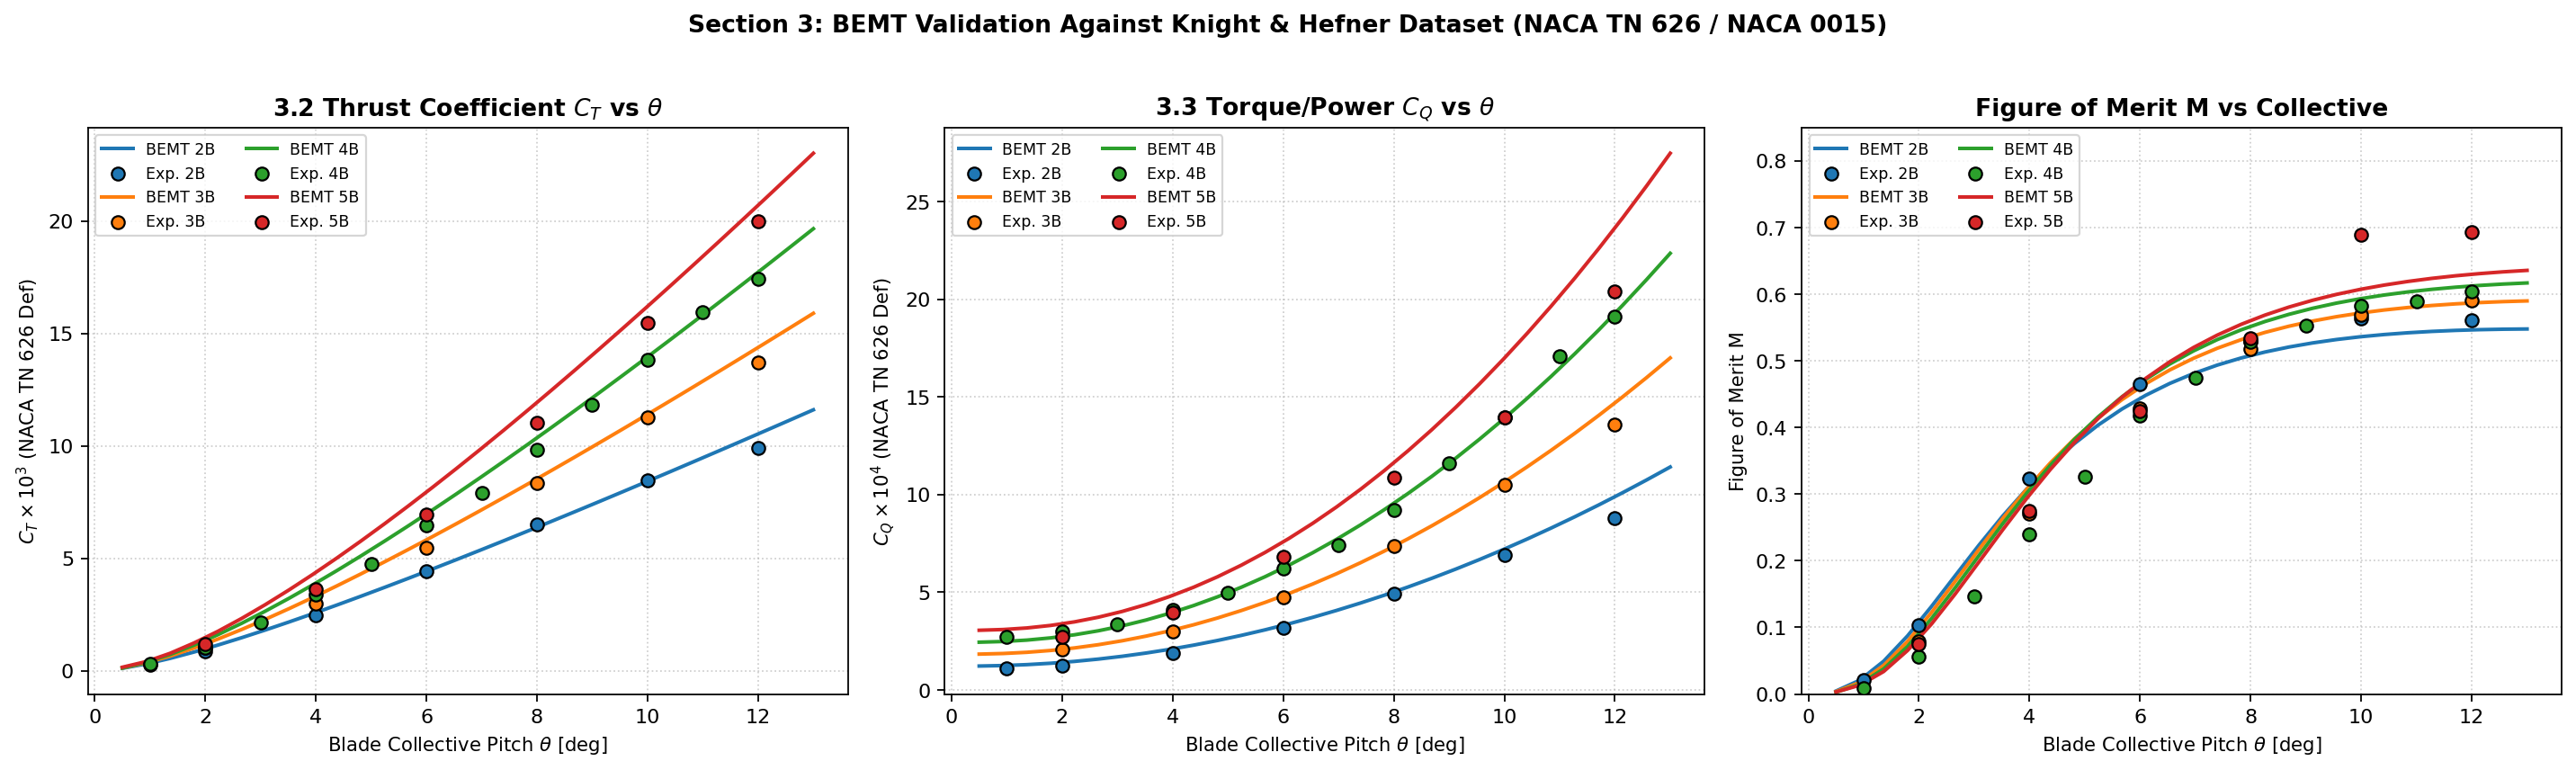

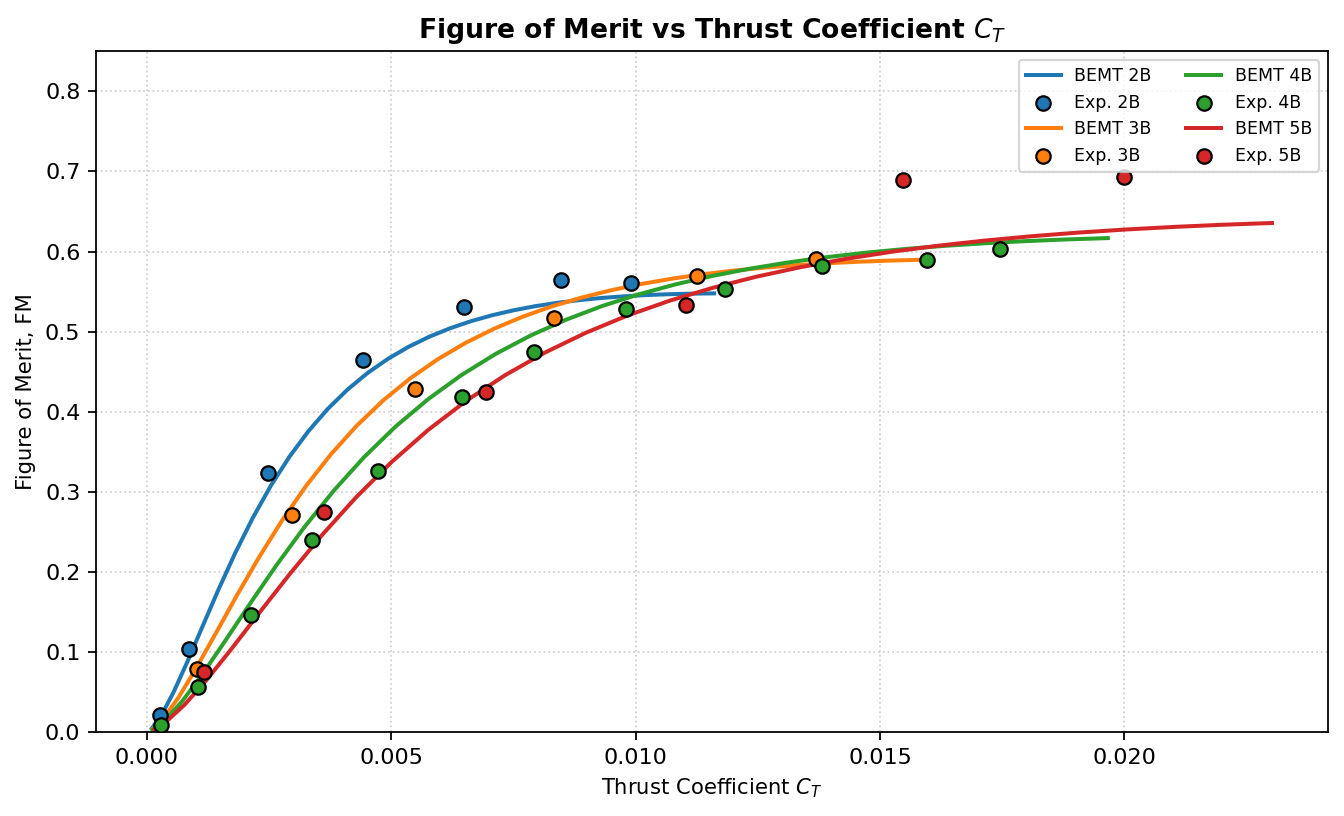

Configuration,CT RMSE,CT MAPE [%],CQ RMSE,CQ MAPE [%],FM RMSE,FM MAPE [%]
2 Blades,0.000252,6.63%,0.000046,8.60%,0.0175,6.49%
3 Blades,0.000363,7.29%,0.000047,2.54%,0.0241,8.87%
4 Blades,0.000436,13.12%,0.000027,3.30%,0.0398,24.22%
5 Blades,0.000765,12.83%,0.000192,17.35%,0.0481,9.44%


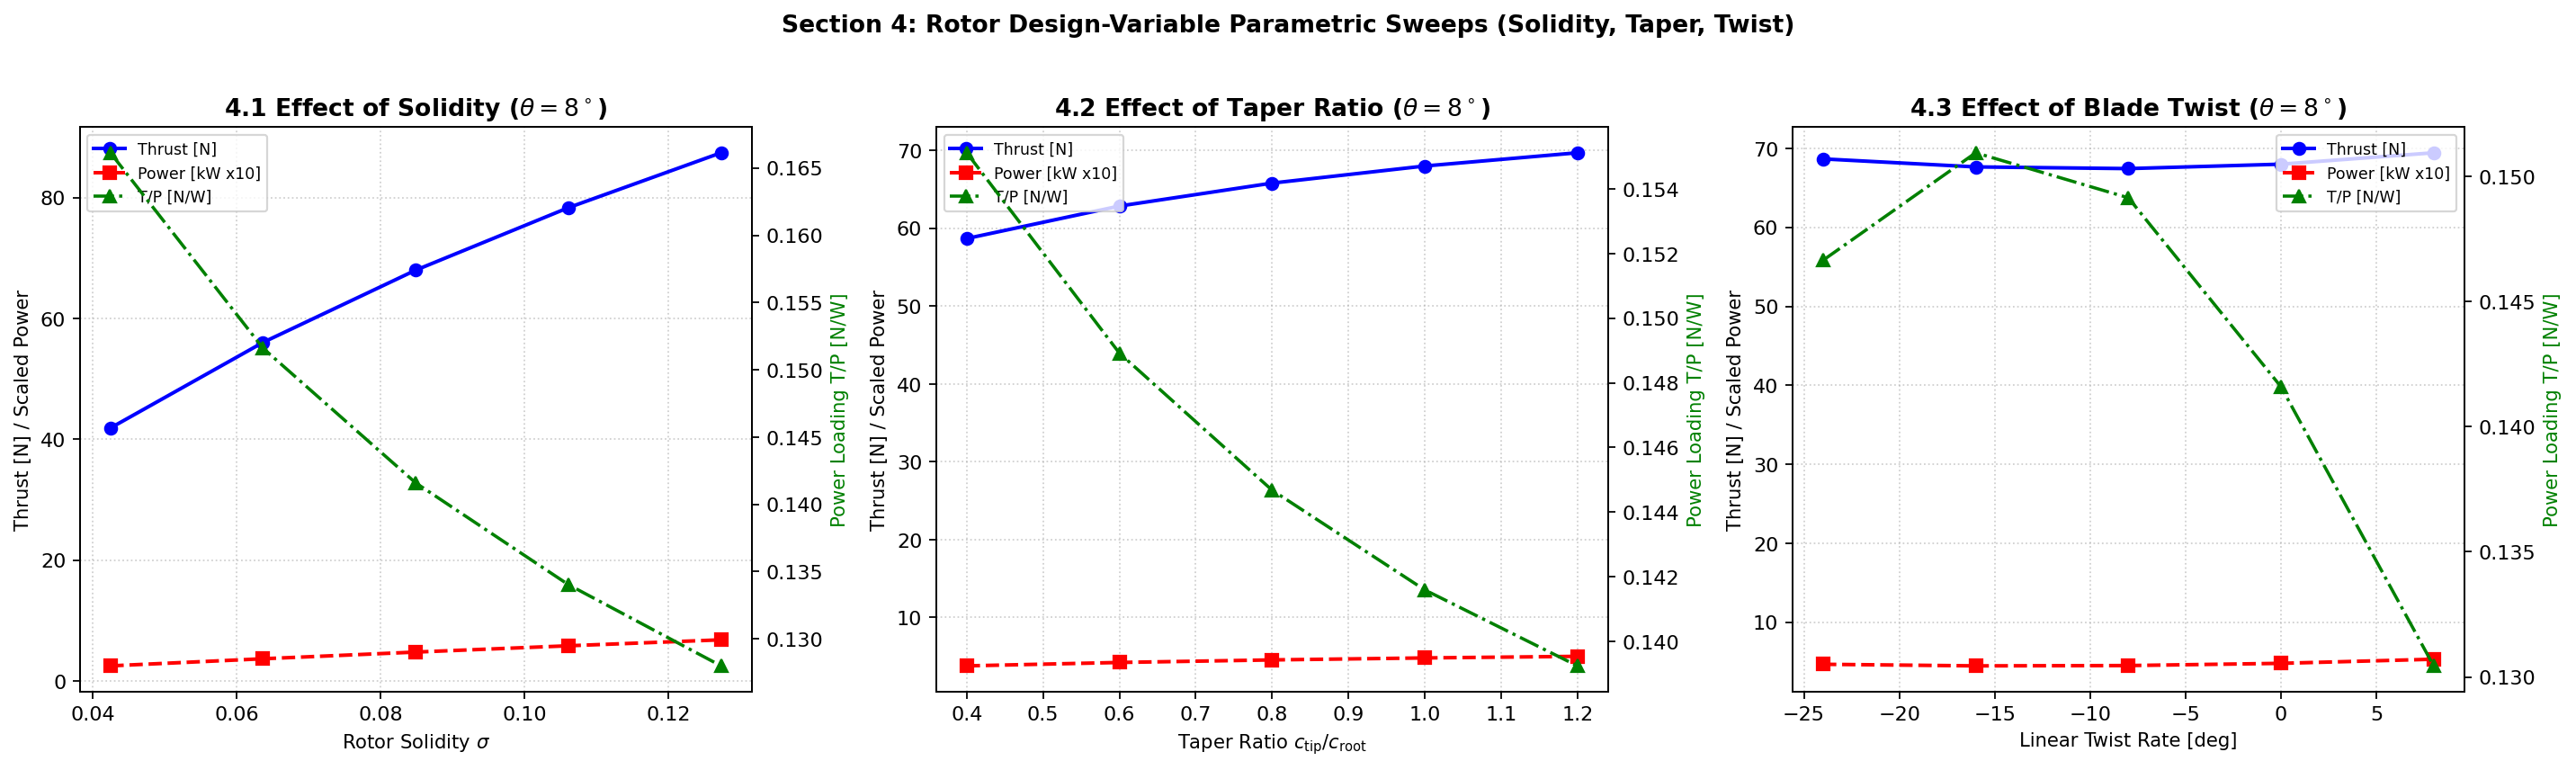

In [2]:
# CELL 3: TASK 3 & 4 - BEMT VALIDATION & DESIGN VARIABLE STUDY
# Calls main Cell 1 aeromechanics solver (run_bemt_solver)
# Airfoil equations: Cl = 5.75 * alpha, Cd = 0.0113 + 1.25 * alpha^2


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML


# 1. KNIGHT & HEFNER (NACA TN 626) EXPERIMENTAL DATASET (TABLES I - IV)

knight_exp = {
    2: {
        'theta_deg': np.array([1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0]),
        'CT_naca': np.array([0.00028, 0.000873, 0.00248, 0.00442, 0.00650, 0.00847, 0.00990]),
        'CQ_naca': np.array([0.000111, 0.000125, 0.000191, 0.000316, 0.000494, 0.000691, 0.000878])
    },
    3: {
        'theta_deg': np.array([2.0, 4.0, 6.0, 8.0, 10.0, 12.0]),
        'CT_naca': np.array([0.00102, 0.00298, 0.00548, 0.00833, 0.01125, 0.01370]),
        'CQ_naca': np.array([0.000206, 0.000300, 0.000474, 0.000735, 0.001048, 0.001357])
    },
    4: {
        'theta_deg': np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0]),
        'CT_naca': np.array([0.000287, 0.001042, 0.00214, 0.00338, 0.00473, 0.00645, 0.00792, 0.00981, 0.01182, 0.01382, 0.01596, 0.01745]),
        'CQ_naca': np.array([0.000274, 0.000300, 0.000338, 0.000410, 0.000499, 0.000620, 0.000743, 0.000920, 0.001162, 0.001395, 0.001710, 0.001910])
    },
    5: {
        'theta_deg': np.array([2.0, 4.0, 6.0, 8.0, 10.0, 12.0]),
        'CT_naca': np.array([0.001181, 0.00362, 0.00694, 0.01103, 0.01548, 0.02000]),
        'CQ_naca': np.array([0.000270, 0.000396, 0.000680, 0.001086, 0.001397, 0.002040])
    }
}


# 2. KNIGHT AIRFOIL CLASS EVALUATING MILESTONE 1 EQUATIONS

class KnightAnalyticalAirfoil:
    """
    Sectional polar using exact milestone equations:
    Cl(alpha) = 5.75 * alpha
    Cd(alpha) = 0.0113 + 1.25 * alpha^2 (alpha in radians)
    """
    def __init__(self):
        self.airfoil_name = "NACA 0015 (Knight & Hefner Equations)"
        self.alpha_stall_deg = 14.0
        self.cl_max = 5.75 * np.radians(14.0)

    def evaluate(self, alpha_rad, re_arr, mach_arr):
        cl = 5.75 * alpha_rad
        cd = 0.0113 + 1.25 * (alpha_rad ** 2)

        alpha_deg = np.degrees(alpha_rad)
        valid_mask = (alpha_deg >= -14.0) & (alpha_deg <= 14.0)
        cl_stall = (self.cl_max * 0.95) * np.sin(2.0 * alpha_rad)
        cd_stall = 0.0113 + 1.25 * (np.sin(alpha_rad) ** 2)

        cl = np.where(valid_mask, cl, cl_stall)
        cd = np.where(valid_mask, cd, cd_stall)

        beta = np.sqrt(np.maximum(0.20, 1.0 - np.clip(mach_arr, 0.0, 0.88)**2))
        return cl / beta, cd / beta, valid_mask

af_knight = KnightAnalyticalAirfoil()

# Rotor dimensions from Milestone 1 prompt
R_k = 0.762        # Radius [m]
r_root_k = 0.125   # Root cutout [m]
c_k = 0.0508       # Chord [m]
rpm_k = 960.0      # RPM
rho_val = 1.225
a_sound_val = 340.3
mu_val = 1.789e-5
A_disk_k = np.pi * (R_k ** 2)
omega_k = rpm_k * 2.0 * np.pi / 60.0
v_tip_k = omega_k * R_k


# 3. RUN BEMT SWEEP WITH MAIN SOLVER (run_bemt_solver)

theta_sweep = np.linspace(0.5, 13.0, 30)
sim_val = {}

for nb in [2, 3, 4, 5]:
    ct_list, cq_list, fm_list = [], [], []
    for th in theta_sweep:
        # Directly call Cell 1 BEMT engine
        res = run_bemt_solver(
            radius=R_k,
            root_cutout=r_root_k,
            num_blades=nb,
            c_root=c_k,
            taper=1.0,
            pitch_75_deg=th,
            twist_deg=0.0,
            rpm=rpm_k,
            v_axial_ms=0.0,
            airfoil=af_knight,
            rho=rho_val,
            a_sound=a_sound_val,
            mu=mu_val,
            num_elements=40
        )

        # NACA TN 626 coefficients (includes 1/2 factor)
        ct_naca = res.thrust_N / (0.5 * rho_val * A_disk_k * (v_tip_k ** 2))
        cq_naca = res.torque_Nm / (0.5 * rho_val * A_disk_k * (v_tip_k ** 2) * R_k)
        fm = (0.5 * (ct_naca ** 1.5) / max(cq_naca, 1e-7)) if (ct_naca > 0 and cq_naca > 0) else 0.0

        ct_list.append(ct_naca)
        cq_list.append(cq_naca)
        fm_list.append(fm)

    sim_val[nb] = {
        'CT_naca': np.array(ct_list),
        'CQ_naca': np.array(cq_list),
        'FM': np.array(fm_list)
    }


# 4. ERROR METRIC QUANTIFICATION (RMSE & MAPE)

error_metrics = []
for nb in [2, 3, 4, 5]:
    th_e = knight_exp[nb]['theta_deg']
    ct_e = knight_exp[nb]['CT_naca']
    cq_e = knight_exp[nb]['CQ_naca']
    fm_e = 0.5 * (ct_e ** 1.5) / cq_e

    ct_interp = np.interp(th_e, theta_sweep, sim_val[nb]['CT_naca'])
    cq_interp = np.interp(th_e, theta_sweep, sim_val[nb]['CQ_naca'])
    fm_interp = np.interp(th_e, theta_sweep, sim_val[nb]['FM'])

    rmse_ct = np.sqrt(np.mean((ct_interp - ct_e) ** 2))
    mape_ct = np.mean(np.abs((ct_interp - ct_e) / ct_e)) * 100.0

    rmse_cq = np.sqrt(np.mean((cq_interp - cq_e) ** 2))
    mape_cq = np.mean(np.abs((cq_interp - cq_e) / cq_e)) * 100.0

    rmse_fm = np.sqrt(np.mean((fm_interp - fm_e) ** 2))
    mape_fm = np.mean(np.abs((fm_interp - fm_e) / fm_e)) * 100.0

    error_metrics.append({
        'Configuration': f'{nb} Blades',
        'CT RMSE': f'{rmse_ct:.6f}',
        'CT MAPE [%]': f'{mape_ct:.2f}%',
        'CQ RMSE': f'{rmse_cq:.6f}',
        'CQ MAPE [%]': f'{mape_cq:.2f}%',
        'FM RMSE': f'{rmse_fm:.4f}',
        'FM MAPE [%]': f'{mape_fm:.2f}%'
    })


# 5. VALIDATION PLOTS (SECTION 3.2 & 3.3)

fig_val, axes_v = plt.subplots(1, 3, figsize=(18, 5.2), dpi=160)
colors_b = {2: '#1f77b4', 3: '#ff7f0e', 4: '#2ca02c', 5: '#d62728'}

for nb in [2, 3, 4, 5]:
    col = colors_b[nb]
    th_e = knight_exp[nb]['theta_deg']
    ct_e = knight_exp[nb]['CT_naca']
    cq_e = knight_exp[nb]['CQ_naca']
    fm_e = 0.5 * (ct_e ** 1.5) / cq_e

    # 3.2 Thrust Coefficient vs Pitch
    axes_v[0].plot(theta_sweep, sim_val[nb]['CT_naca'] * 1e3, '-', color=col, lw=1.8, label=f'BEMT {nb}B')
    axes_v[0].scatter(th_e, ct_e * 1e3, color=col, edgecolor='k', s=42, zorder=5, label=f'Exp. {nb}B')

    # 3.3 Torque Coefficient vs Pitch
    axes_v[1].plot(theta_sweep, sim_val[nb]['CQ_naca'] * 1e4, '-', color=col, lw=1.8, label=f'BEMT {nb}B')
    axes_v[1].scatter(th_e, cq_e * 1e4, color=col, edgecolor='k', s=42, zorder=5, label=f'Exp. {nb}B')

    # Figure of Merit M vs Pitch
    axes_v[2].plot(theta_sweep, sim_val[nb]['FM'], '-', color=col, lw=1.8, label=f'BEMT {nb}B')
    axes_v[2].scatter(th_e, fm_e, color=col, edgecolor='k', s=42, zorder=5, label=f'Exp. {nb}B')

axes_v[0].set_xlabel(r'Blade Collective Pitch $\theta$ [deg]', fontsize=9.5)
axes_v[0].set_ylabel(r'$C_T \times 10^3$ (NACA TN 626 Def)', fontsize=9.5)
axes_v[0].set_title(r'3.2 Thrust Coefficient $C_T$ vs $\theta$', fontweight='bold')
axes_v[0].grid(True, ls=':', alpha=0.6)
axes_v[0].legend(fontsize=7.8, ncol=2)

axes_v[1].set_xlabel(r'Blade Collective Pitch $\theta$ [deg]', fontsize=9.5)
axes_v[1].set_ylabel(r'$C_Q \times 10^4$ (NACA TN 626 Def)', fontsize=9.5)
axes_v[1].set_title(r'3.3 Torque/Power $C_Q$ vs $\theta$', fontweight='bold')
axes_v[1].grid(True, ls=':', alpha=0.6)
axes_v[1].legend(fontsize=7.8, ncol=2)

axes_v[2].set_xlabel(r'Blade Collective Pitch $\theta$ [deg]', fontsize=9.5)
axes_v[2].set_ylabel('Figure of Merit M', fontsize=9.5)
axes_v[2].set_ylim(0.0, 0.85)
axes_v[2].set_title('Figure of Merit M vs Collective', fontweight='bold')
axes_v[2].grid(True, ls=':', alpha=0.6)
axes_v[2].legend(fontsize=7.8, ncol=2)

plt.suptitle('Section 3: BEMT Validation Against Knight & Hefner Dataset (NACA TN 626 / NACA 0015)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
plt.close(fig_val)

# 3.3b Figure of Merit over the thrust range
fig_fm, ax = plt.subplots(figsize=(8.5, 5.2), dpi=160)

for nb in [2, 3, 4, 5]:
    ct_bemt, fm_bemt = sim_val[nb]['CT_naca'], sim_val[nb]['FM']
    ct_exp, cq_exp = knight_exp[nb]['CT_naca'], knight_exp[nb]['CQ_naca']
    fm_exp = 0.5 * ct_exp**1.5 / cq_exp

    ax.plot(ct_bemt, fm_bemt, '-', lw=1.8, label=f'BEMT {nb}B')
    ax.scatter(ct_exp, fm_exp, s=42, edgecolor='k', zorder=5, label=f'Exp. {nb}B')

ax.set_xlabel(r'Thrust Coefficient $C_T$', fontsize=9.5)
ax.set_ylabel('Figure of Merit, FM', fontsize=9.5)
ax.set_title(r'Figure of Merit vs Thrust Coefficient $C_T$', fontweight='bold')
ax.set_ylim(0.0, 0.85)
ax.grid(True, ls=':', alpha=0.6)
ax.legend(fontsize=7.8, ncol=2)

plt.tight_layout()
plt.show()
plt.close(fig_fm)

display(HTML('<h4>Section 3.4 Error Metric Summary (BEMT vs NACA TN 626 Exp. Data)</h4>'))
display(HTML(pd.DataFrame(error_metrics).to_html(index=False, classes='table table-sm table-striped table-bordered')))


# 6. SECTION 4: DESIGN-VARIABLE STUDY

th_base = 8.0 # deg
nb_base = 4
taper_base = 1.0
twist_base = 0.0

# 4.1 Solidity / Blade Number Variation
nb_vals = [2, 3, 4, 5, 6]
sol_T, sol_P, sol_TP = [], [], []
for nb in nb_vals:
    r = run_bemt_solver(R_k, r_root_k, nb, c_k, taper_base, th_base, twist_base, rpm_k, 0.0, af_knight, rho_val, a_sound_val, mu_val)
    sol_T.append(r.thrust_N)
    sol_P.append(r.power_kW)
    sol_TP.append(r.thrust_N / max(r.power_kW * 1000.0, 1.0))

# 4.2 Taper Ratio Variation
taper_vals = [0.4, 0.6, 0.8, 1.0, 1.2]
taper_T, taper_P, taper_TP = [], [], []
for tr in taper_vals:
    c_root_mod = (2.0 * c_k) / (1.0 + tr)
    r = run_bemt_solver(R_k, r_root_k, nb_base, c_root_mod, tr, th_base, twist_base, rpm_k, 0.0, af_knight, rho_val, a_sound_val, mu_val)
    taper_T.append(r.thrust_N)
    taper_P.append(r.power_kW)
    taper_TP.append(r.thrust_N / max(r.power_kW * 1000.0, 1.0))

# 4.3 Linear Twist Variation
twist_vals = [-24.0, -16.0, -8.0, 0.0, 8.0]
twist_T, twist_P, twist_TP = [], [], []
for tw in twist_vals:
    r = run_bemt_solver(R_k, r_root_k, nb_base, c_k, taper_base, th_base, tw, rpm_k, 0.0, af_knight, rho_val, a_sound_val, mu_val)
    twist_T.append(r.thrust_N)
    twist_P.append(r.power_kW)
    twist_TP.append(r.thrust_N / max(r.power_kW * 1000.0, 1.0))

fig_dv, axes_d = plt.subplots(1, 3, figsize=(18, 5.2), dpi=160)

# 4.1 Solidity Plot
solidities = [(nb * c_k) / (np.pi * R_k) for nb in nb_vals]
ax1 = axes_d[0]
ax1.plot(solidities, sol_T, 'b-o', lw=1.8, label='Thrust [N]')
ax1.plot(solidities, np.array(sol_P) * 10.0, 'r--s', lw=1.8, label='Power [kW x10]')
ax1_t = ax1.twinx()
ax1_t.plot(solidities, sol_TP, 'g-.^', lw=1.6, label='T/P [N/W]')
ax1.set_xlabel(r'Rotor Solidity $\sigma$', fontsize=9.5)
ax1.set_ylabel('Thrust [N] / Scaled Power', fontsize=9.5)
ax1_t.set_ylabel('Power Loading T/P [N/W]', color='g', fontsize=9.5)
ax1.set_title(r'4.1 Effect of Solidity ($\theta=8^\circ$)', fontweight='bold')
ax1.grid(True, ls=':', alpha=0.6)
lines1, labels1 = ax1.get_legend_handles_labels()
lines1_t, labels1_t = ax1_t.get_legend_handles_labels()
ax1.legend(lines1 + lines1_t, labels1 + labels1_t, fontsize=7.8, loc='upper left')

# 4.2 Taper Plot
ax2 = axes_d[1]
ax2.plot(taper_vals, taper_T, 'b-o', lw=1.8, label='Thrust [N]')
ax2.plot(taper_vals, np.array(taper_P) * 10.0, 'r--s', lw=1.8, label='Power [kW x10]')
ax2_t = ax2.twinx()
ax2_t.plot(taper_vals, taper_TP, 'g-.^', lw=1.6, label='T/P [N/W]')
ax2.set_xlabel(r'Taper Ratio $c_{\mathrm{tip}}/c_{\mathrm{root}}$', fontsize=9.5)
ax2.set_ylabel('Thrust [N] / Scaled Power', fontsize=9.5)
ax2_t.set_ylabel('Power Loading T/P [N/W]', color='g', fontsize=9.5)
ax2.set_title(r'4.2 Effect of Taper Ratio ($\theta=8^\circ$)', fontweight='bold')
ax2.grid(True, ls=':', alpha=0.6)
lines2, labels2 = ax2.get_legend_handles_labels()
lines2_t, labels2_t = ax2_t.get_legend_handles_labels()
ax2.legend(lines2 + lines2_t, labels2 + labels2_t, fontsize=7.8, loc='upper left')

# 4.3 Twist Plot
ax3 = axes_d[2]
ax3.plot(twist_vals, twist_T, 'b-o', lw=1.8, label='Thrust [N]')
ax3.plot(twist_vals, np.array(twist_P) * 10.0, 'r--s', lw=1.8, label='Power [kW x10]')
ax3_t = ax3.twinx()
ax3_t.plot(twist_vals, twist_TP, 'g-.^', lw=1.6, label='T/P [N/W]')
ax3.set_xlabel('Linear Twist Rate [deg]', fontsize=9.5)
ax3.set_ylabel('Thrust [N] / Scaled Power', fontsize=9.5)
ax3_t.set_ylabel('Power Loading T/P [N/W]', color='g', fontsize=9.5)
ax3.set_title(r'4.3 Effect of Blade Twist ($\theta=8^\circ$)', fontweight='bold')
ax3.grid(True, ls=':', alpha=0.6)
lines3, labels3 = ax3.get_legend_handles_labels()
lines3_t, labels3_t = ax3_t.get_legend_handles_labels()
ax3.legend(lines3 + lines3_t, labels3 + labels3_t, fontsize=7.8, loc='upper right')

plt.suptitle('Section 4: Rotor Design-Variable Parametric Sweeps (Solidity, Taper, Twist)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
plt.close(fig_dv)

# MILESTONE 2

## with swirl

In [3]:
# FAST VECTORIZED MILESTONE-2 ROTOR DATABASE
# Requires existing:
#   AirfoilModel
#   run_bemt_solver
#   isa_atmosphere
#
# ψ convention:
#   0°   = aft
#   90°  = right / advancing
#   180° = front
#   270° = left / retreating
#
# Reverse-flow assumption:
#   if local tangential velocity U_T < 0,
#   reverse flow is flagged and sectional aerodynamic loads are set to zero.
#   No reverse-flow airfoil polar is assumed.

import json
from functools import lru_cache
import numpy as np, pandas as pd, ipywidgets as widgets, time
from pathlib import Path
from scipy.optimize import brentq
from IPython.display import display

ROTOR={
    "airfoil":"Boeing-Vertol VR-12",
    "R_m":4.60,
    "root_cutout_m":0.46,
    "Nb":3,
    "c_root_m":0.50,
    "taper":0.75,
    "twist_deg":-30.0
}

DB_ALTITUDE_M,DB_DELTA_T_C=0.0,0.0
rho_db,a_db,T_db,mu_air_db=isa_atmosphere(DB_ALTITUDE_M,DB_DELTA_T_C)
rotor_airfoil=AirfoilModel(ROTOR["airfoil"],ncrit=9)

# DB_GRID={
#     "V_ms":np.array([0.,20.,50.,80.,120.]),
#     "flow_angle_deg":np.array([0.,20.,40.,60.,80.,90.]),
#     "rpm":np.array([200.,300.,400.,500.,535.]),
#     "theta_0_deg":np.array([0.,2.,10.,20.,40.,60.,75.]),
#     "theta_1c_deg":np.array([-6.,0.,6.]),
#     "theta_1s_deg":np.array([-6.,0.,6.])
# }

# DB_GRID={
#     "V_ms":np.array([0.,20.,40.,60.,80.,100.,120.]),
#     "flow_angle_deg":np.array([0.,15.,30.,45.,60.,75.,90.]),
#     "rpm":np.array([200.,275.,350.,425.,500.,535.]),
#     # Retain the tiltrotor's full high-axial-inflow collective range.
#     "theta_0_deg":np.array([0.,2.,5.,10.,15.,20.,30.,40.,50.,60.,75.]),
#     "theta_1c_deg":np.array([-6.,-3.,0.,3.,6.]),
#     "theta_1s_deg":np.array([-6.,-3.,0.,3.,6.])
# }

DB_GRID = {
    "V_ms": np.array([0., 20., 40., 60., 80., 100., 120.]),
    "flow_angle_deg": np.array([0., 15., 30., 45., 60., 75., 90.]),
    "rpm": np.array([200., 275., 350., 425., 500., 535.]),
    "theta_0_deg": np.array([
        0., 2., 5., 10., 15., 20.,
        30., 40., 50., 60., 75.
    ]),
    # Three points per cyclic axis are the minimum needed for a quadratic
    # cyclic surrogate while keeping the database affordable to generate.
    "theta_1c_deg": np.array([-6., 0., 6.]),
    "theta_1s_deg": np.array([-6., 0., 6.])
}

N_RADIAL,N_AZIMUTH=32,96
MAX_INFLOW_ITER,INFLOW_RELAX=32,0.40
# Stop when the induced-velocity change is small in engineering terms. A
# mixed absolute/relative tolerance avoids wasting iterations at high RPM.
INFLOW_ABS_TOL=0.01
INFLOW_TIP_REL_TOL=1.0e-4
TIP_MACH_LIMIT,EPS=0.90,1e-10
ALPHA_MIN_POLAR=-15.0
ALPHA_STALL=float(rotor_airfoil.alpha_stall_deg)

# A row may converge numerically and still lie outside the model's usable
# aerodynamic envelope.  These limits are deliberately stored with every DB
# so the lookup/mission code can reject such states instead of interpolating
# through them silently.
MAX_STALL_FRACTION_FOR_SURROGATE=0.05
MAX_POLAR_EXTRAP_FRACTION_FOR_SURROGATE=0.05
MAX_REVERSE_FLOW_FRACTION_FOR_SURROGATE=0.00

R=float(ROTOR["R_m"]); r0=float(ROTOR["root_cutout_m"]); Nb=int(ROTOR["Nb"])
c0=float(ROTOR["c_root_m"]); ctip=c0*float(ROTOR["taper"]); A=np.pi*R**2

redges=np.linspace(r0,R,N_RADIAL+1)
r=0.5*(redges[:-1]+redges[1:])
dr=np.diff(redges)
rb=r/R
chord=c0+(ctip-c0)*(r-r0)/(R-r0)

psi=np.linspace(0,2*np.pi,N_AZIMUTH,endpoint=False)
PSI,RR=np.meshgrid(psi,r,indexing="ij")
RB=RR/R
CHORD=np.broadcast_to(chord[None,:],RR.shape)
DR=np.broadcast_to(dr[None,:],RR.shape)

SINPSI=np.sin(PSI)
COSPSI=np.cos(PSI)

# Position convention:
# x forward, y right
# ψ=0 aft -> x=-r
# ψ=180 front -> x=+r. Increasing ψ is anticlockwise viewed from
# physical top (-z_s), matching the rotor convention used here.
RX=-RR*COSPSI
RY= RR*SINPSI

RE_FACTOR=rho_db*CHORD/max(mu_air_db,EPS)

# Solve all control combinations simultaneously
TH0,TH1C,TH1S=np.meshgrid(
    DB_GRID["theta_0_deg"],
    DB_GRID["theta_1c_deg"],
    DB_GRID["theta_1s_deg"],
    indexing="ij"
)

CTRL0=TH0.ravel()
CTRL1C=TH1C.ravel()
CTRL1S=TH1S.ravel()
NC=len(CTRL0)

THETA=(
    np.radians(CTRL0)[:,None,None]
    +np.radians(ROTOR["twist_deg"])*(RB[None,:,:]-0.75)
    +np.radians(CTRL1C)[:,None,None]*COSPSI[None,:,:]
    +np.radians(CTRL1S)[:,None,None]*SINPSI[None,:,:]
)

def wrap_pi(x):
    return (x+np.pi)%(2*np.pi)-np.pi

def airfoil_eval_nd(alpha,Re,Mach):
    shp=alpha.shape
    cl,cd,valid=rotor_airfoil.evaluate(alpha.ravel(),Re.ravel(),Mach.ravel())
    return (
        np.asarray(cl).reshape(shp),
        np.asarray(cd).reshape(shp),
        np.asarray(valid).reshape(shp)
    )

def prandtl_tip_loss(phi):
    s=np.maximum(np.abs(np.sin(phi)),1e-4)
    f=(Nb/2)*(R-RR[None,:,:])/np.maximum(RR[None,:,:]*s,1e-6)
    return np.clip(
        (2/np.pi)*np.arccos(np.exp(-np.clip(f,0,50))),
        0.05,1.0
    )

def nonuniform_inflow_batch(viG,Vp,Va,omega):
    """Return the prescribed first-harmonic forward-flight inflow.

    The Milestone-2 hint defines lambda_G as the total *axial* inflow
    ratio, (Va + vi_G)/(Omega R).  The algebraically rearranged expression
    for K below is exactly equivalent to the stated mu/lambda_G equation,
    but remains finite as lambda_G approaches zero.
    """
    tip=omega*R
    lambda_iG=viG/tip
    mu=Vp/tip
    lambda_G=(Va+viG)/tip

    # K = [(4/3)(mu/lambda_G)]/[1.2 + mu/lambda_G]
    #   = (4/3)mu/(1.2 lambda_G + mu)
    denominator=1.2*lambda_G+mu
    K=np.divide(
        (4.0/3.0)*mu,
        denominator,
        out=np.zeros_like(denominator),
        where=np.abs(denominator)>1e-10
    )

    return (
        lambda_iG[:,None,None]
        *(1+K[:,None,None]*RB[None,:,:]*COSPSI[None,:,:])
        *tip
    )

def glauert_target_batch(T,Vp,Va,guess):
    """
    Vectorized solution of:
    T = 2 rho A vi sqrt(Vp^2 + (Va+vi)^2)
    for positive-thrust normal-working states.
    """
    T=np.asarray(T,float)
    out=np.full_like(T,np.nan)
    good=np.isfinite(T)&(T>0)

    if not good.any():
        return out

    C=2*rho_db*A
    x=np.maximum(
        np.where(np.isfinite(guess),guess,0.0),
        np.sqrt(np.maximum(T,0)/(2*rho_db*A))*0.4
    )
    x=np.maximum(x,0.001)

    for _ in range(12):
        s=np.sqrt(Vp**2+(Va+x)**2)
        f=C*x*s-T
        df=C*(s+x*(Va+x)/np.maximum(s,EPS))
        xn=np.maximum(x-f/np.maximum(df,EPS),0.0)
        x=np.where(good,0.65*xn+0.35*x,x)

    resid=np.abs(
        C*x*np.sqrt(Vp**2+(Va+x)**2)-T
    )/np.maximum(T,1.0)

    out[good&(resid<2e-5)]=x[good&(resid<2e-5)]

    # Robust scalar fallback for rare Newton failures
    bad=np.where(good&~np.isfinite(out))[0]

    for i in bad:
        def f(z):
            return C*z*np.sqrt(Vp**2+(Va+z)**2)-T[i]

        hi=max(
            20.0,
            abs(Va)+abs(Vp)+np.sqrt(T[i]/max(rho_db*A,EPS))
        )

        while f(hi)<0 and hi<3000:
            hi*=2

        if hi<3000:
            try:
                out[i]=brentq(f,0,hi,xtol=1e-7)
            except:
                pass

    return out


def momentum_residual_fraction(T,Vp,Va,vi):
    """Relative residual of the inclined actuator-disk momentum equation."""
    T=np.asarray(T,float)
    vi=np.asarray(vi,float)
    model_T=2.0*rho_db*A*vi*np.sqrt(Vp**2+(Va+vi)**2)
    return np.abs(model_T-T)/np.maximum(np.abs(T),1.0)

@lru_cache(maxsize=None)
def milestone1_limit(Va,rpm,theta0):
    """
    Exact axial/no-cyclic recovery using existing Milestone-1 BEMT.
    """
    old=run_bemt_solver(
        radius=R,
        root_cutout=r0,
        num_blades=Nb,
        c_root=c0,
        taper=ROTOR["taper"],
        pitch_75_deg=float(theta0),
        twist_deg=ROTOR["twist_deg"],
        rpm=float(rpm),
        v_axial_ms=float(Va),
        airfoil=rotor_airfoil,
        rho=rho_db,
        a_sound=a_db,
        mu=mu_air_db,
        num_elements=N_RADIAL
    )

    om=rpm*2*np.pi/60
    tip=om*R

    mach=np.atleast_1d(np.asarray(old.mach_helical,float))
    al=np.atleast_1d(np.asarray(old.alpha_deg,float))

    stall=(al<ALPHA_MIN_POLAR)|(al>ALPHA_STALL)

    ok=np.all(np.isfinite([
        old.thrust_N,
        old.torque_Nm,
        old.power_kW
    ]))

    summary=dict(
        Fx_shaft_N=0.0,
        Fy_shaft_N=0.0,
        Fz_shaft_N=-float(old.thrust_N),

        Mx_shaft_Nm=0.0,
        My_shaft_Nm=0.0,
        # Anticlockwise rotation viewed from physical top is about -z_s;
        # the equal-and-opposite reaction applied to the aircraft is +z_s.
        Mz_shaft_Nm= float(old.torque_Nm),

        torque_Nm=float(old.torque_Nm),
        power_kW=float(old.power_kW),

        CT=float(old.CT),
        CP=float(old.CP),

        CT_disk=float(old.thrust_N)/(rho_db*A*tip**2),
        CQ_disk=float(old.torque_Nm)/(rho_db*A*tip**2*R),

        mu_advance=0.0,

        lambda_G=float(np.mean(np.abs(old.lambda_tot))),
        vi_glauert_ms=float(np.mean(old.lambda_i)*tip),
        vi_min_ms=float(np.min(old.lambda_i)*tip),
        vi_max_ms=float(np.max(old.lambda_i)*tip),

        max_Mach=float(np.max(mach)),
        advancing_tip_Mach=float(np.max(mach)),

        max_alpha_deg=float(np.max(al)),
        min_alpha_deg=float(np.min(al)),

        stall_fraction=float(np.mean(stall)),

        reverse_flow_fraction=0.0,
        reverse_flow_present=False,
        reverse_flow_model="not applicable",

        polar_extrap_fraction=float(1-old.valid_fraction),

        min_tip_loss=1.0,

        inflow_iterations=0,
        inflow_error=0.0,
        inflow_converged=True,

        momentum_residual_frac=float(
            momentum_residual_fraction(
                old.thrust_N,0.0,Va,
                np.mean(old.lambda_i)*tip
            )
        ),

        physics_valid_num=float(ok),

        tip_mach_ok=bool(
            np.max(mach)<=TIP_MACH_LIMIT
        ),

        surrogate_usable=bool(
            ok
            and np.max(mach)<=TIP_MACH_LIMIT
            and np.mean(stall)<=MAX_STALL_FRACTION_FOR_SURROGATE
            and (1-old.valid_fraction)<=MAX_POLAR_EXTRAP_FRACTION_FOR_SURROGATE
        ),

        inflow_regime="Milestone-1 axial limit",
        model_mode="Exact Milestone-1 BEMT"
    )

    profiles=dict(
        dT_dr_Npm=np.asarray(old.dt_dr,float),
        dQ_dr_N=np.asarray(old.dq_dr,float),
        vi_mean_r_ms=np.asarray(old.lambda_i,float)*tip
    )

    return summary,profiles

def evaluate_batch(Vp,Va,omega,viG,control_ids=None):
    """
    Evaluate the requested control combinations simultaneously.

    During the inflow iteration, already-converged controls are omitted.
    The final call still evaluates the complete control tensor once so the
    stored forces, moments, and radial profiles remain fully consistent.
    """

    if control_ids is None:
        control_ids=np.arange(NC,dtype=int)
    else:
        control_ids=np.asarray(control_ids,dtype=int)

    vi=nonuniform_inflow_batch(viG,Vp,Va,omega)

    # ψ=90 right/advancing; ψ=270 left/retreating
    UT2=omega*RR+Vp*SINPSI
    UT=np.broadcast_to(UT2[None,:,:],vi.shape)

    UP=Va+vi
    U=np.hypot(UT,UP)

    phi=np.arctan2(UP,UT)
    alpha=wrap_pi(THETA[control_ids]-phi)

    Re=U*RE_FACTOR[None,:,:]
    Mach=U/a_db

    CL,CD,valid=airfoil_eval_nd(alpha,Re,Mach)

    # Reverse flow occurs when local tangential velocity changes sign.
    reverse=np.broadcast_to(
        (UT2<0)[None,:,:],
        alpha.shape
    )

    # IMPORTANT:
    # No reverse-flow airfoil data are available.
    # Do NOT interpret alpha through an ordinary forward-flow polar.
    # Aerodynamic coefficients are set to zero in reverse-flow cells.
    CL=np.where(reverse,0.0,CL)
    CD=np.where(reverse,0.0,CD)

    Ftip=prandtl_tip_loss(phi)

    q=0.5*rho_db*U**2

    dL=q*CHORD[None,:,:]*CL*Ftip
    dD=q*CHORD[None,:,:]*CD

    # Redundant safety enforcement:
    # reverse-flow cells carry no aerodynamic load
    dL=np.where(reverse,0.0,dL)
    dD=np.where(reverse,0.0,dD)

    dFz=dL*np.cos(phi)-dD*np.sin(phi)
    dFt=dD*np.cos(phi)+dL*np.sin(phi)

    # Tangential unit direction for increasing (anticlockwise-from-top) ψ:
    # e_t = [sinψ, cosψ, 0]. Aerodynamic tangential force opposes it.
    dFx=-dFt*SINPSI[None,:,:]
    dFy=-dFt*COSPSI[None,:,:]

    # ``dFz`` is positive thrust magnitude (physical force is -dFz z_s).
    dMx=-RY[None,:,:]*dFz
    dMy= RX[None,:,:]*dFz
    dQ=RR[None,:,:]*dFt

    def integ(x):
        return Nb*np.mean(
            np.sum(
                x*DR[None,:,:],
                axis=2
            ),
            axis=1
        )

    return dict(
        vi=vi,
        UT=UT,
        UP=UP,
        U=U,
        phi=phi,
        alpha=alpha,
        Re=Re,
        Mach=Mach,
        CL=CL,
        CD=CD,
        valid=valid,
        reverse=reverse,
        Ftip=Ftip,

        dL=dL,
        dD=dD,
        dFz=dFz,
        dFt=dFt,

        Fx=integ(dFx),
        Fy=integ(dFy),
        Fz=integ(dFz),
        Mx=integ(dMx),
        My=integ(dMy),
        Q=integ(dQ),

        # Azimuth-averaged radial profiles for the downstream wake model.
        # dT/dr is N/m; dQ/dr is N (= N m per metre of radius).
        dT_dr_Npm=Nb*np.mean(dFz,axis=1),
        dQ_dr_N=Nb*np.mean(dQ,axis=1),
        vi_mean_r_ms=np.mean(vi,axis=1)
    )

def solve_batch(V,flow_angle,rpm):
    """
    One (V, flow angle, RPM) batch.
    Solves all control combinations simultaneously.
    """

    gamma=np.radians(flow_angle)

    Vp=V*np.cos(gamma)
    Va=V*np.sin(gamma)

    omega=rpm*2*np.pi/60
    tip=omega*R

    viG=np.full(
        NC,
        max(0.02*tip,0.1)
    )

    converged=np.zeros(NC,bool)
    unsupported=np.zeros(NC,bool)

    iteration=np.zeros(NC,int)
    final_err=np.full(NC,np.nan)

    for it in range(
        1,
        MAX_INFLOW_ITER+1
    ):
        active_ids=np.flatnonzero(~converged&~unsupported)
        if active_ids.size==0:
            break

        s=evaluate_batch(
            Vp,Va,omega,viG[active_ids],active_ids
        )

        target=glauert_target_batch(
            s["Fz"],
            Vp,
            Va,
            viG[active_ids]
        )

        valid_target=np.isfinite(target)
        bad_ids=active_ids[~valid_target]
        unsupported[bad_ids]=True
        iteration[bad_ids]=it
        viG[bad_ids]=0.0

        good_ids=active_ids[valid_target]
        if good_ids.size:
            target_good=target[valid_target]
            err_good=np.abs(target_good-viG[good_ids])
            tolerance=max(
                INFLOW_ABS_TOL,
                INFLOW_TIP_REL_TOL*tip
            )
            done=err_good<tolerance
            done_ids=good_ids[done]
            keep_ids=good_ids[~done]

            converged[done_ids]=True
            iteration[done_ids]=it
            final_err[done_ids]=err_good[done]
            viG[done_ids]=target_good[done]

            viG[keep_ids]=(
                (1-INFLOW_RELAX)*viG[keep_ids]
                +INFLOW_RELAX*target_good[~done]
            )

    iteration[
        iteration==0
    ]=MAX_INFLOW_ITER

    s=evaluate_batch(
        Vp,Va,omega,viG
    )

    Fx,Fy,T,Mx,My,Q=[
        s[k]
        for k in (
            "Fx","Fy","Fz",
            "Mx","My","Q"
        )
    ]

    P=omega*Q

    n=rpm/60
    D=2*R

    CT=T/(rho_db*n**2*D**4)
    CP=P/(rho_db*n**3*D**5)

    CTd=T/(rho_db*A*tip**2)
    CQd=Q/(rho_db*A*tip**2*R)

    alpha_deg=np.degrees(
        s["alpha"]
    )

    reverse=s["reverse"]

    # Stall is evaluated only in normal-flow cells.
    stall=(
        (
            (alpha_deg<ALPHA_MIN_POLAR)
            |
            (alpha_deg>ALPHA_STALL)
        )
        &
        (~reverse)
    )

    polar_bad=(
        (~s["valid"])
        &
        (~reverse)
    )

    reverse_fraction=np.mean(
        reverse,
        axis=(1,2)
    )

    reverse_present=(
        reverse_fraction>0.0
    )

    # Only normal-flow alpha values are physically meaningful
    # with our available polar model.
    alpha_normal=np.where(
        ~reverse,
        alpha_deg,
        np.nan
    )

    with np.errstate(
        all="ignore"
    ):
        max_alpha=np.nanmax(
            alpha_normal,
            axis=(1,2)
        )

        min_alpha=np.nanmin(
            alpha_normal,
            axis=(1,2)
        )

    # In pathological all-reverse cases:
    max_alpha=np.where(
        np.isfinite(max_alpha),
        max_alpha,
        np.nan
    )

    min_alpha=np.where(
        np.isfinite(min_alpha),
        min_alpha,
        np.nan
    )

    iad=int(
        np.argmin(
            np.abs(
                np.angle(
                    np.exp(
                        1j*(psi-np.pi/2)
                    )
                )
            )
        )
    )

    Madv=s["Mach"][:,iad,-1]

    tip_mach_ok=Madv<=TIP_MACH_LIMIT
    stall_fraction=np.mean(stall,axis=(1,2))
    polar_extrap_fraction=np.mean(polar_bad,axis=(1,2))
    momentum_residual=momentum_residual_fraction(T,Vp,Va,viG)

    ok=(
        converged
        &
        (~unsupported)
        &
        (T>0)
        &
        np.isfinite(T)
        &
        np.isfinite(Q)
        &
        np.isfinite(P)
    )

    rows=[]
    dT_profiles=np.asarray(s["dT_dr_Npm"],float).copy()
    dQ_profiles=np.asarray(s["dQ_dr_N"],float).copy()
    vi_profiles=np.asarray(s["vi_mean_r_ms"],float).copy()

    # Keep invalid states in the rectangular scalar grid, but do not provide
    # wake profiles that a downstream model might accidentally trust.
    dT_profiles[~ok,:]=np.nan
    dQ_profiles[~ok,:]=np.nan
    vi_profiles[~ok,:]=np.nan

    for j in range(NC):

        if ok[j]:
            regime="normal-working Glauert"
        elif unsupported[j]:
            regime="unsupported negative-thrust / windmill"
        else:
            regime="inflow not converged"

        rows.append(
            dict(
                V_ms=float(V),
                flow_angle_deg=float(flow_angle),

                V_inplane_ms=float(Vp),
                V_axial_ms=float(Va),

                rpm=float(rpm),

                theta_0_deg=float(CTRL0[j]),
                theta_1c_deg=float(CTRL1C[j]),
                theta_1s_deg=float(CTRL1S[j]),

                Fx_shaft_N=float(Fx[j]),
                Fy_shaft_N=float(Fy[j]),
                Fz_shaft_N=-float(T[j]),

                Mx_shaft_Nm=float(Mx[j]),
                My_shaft_Nm=float(My[j]),
                # CCW-from-top rotor reaction on the aircraft is about +z_s.
                Mz_shaft_Nm= float(Q[j]),

                torque_Nm=float(Q[j]),
                power_kW=float(P[j]/1000),

                CT=float(CT[j]),
                CP=float(CP[j]),

                CT_disk=float(CTd[j]),
                CQ_disk=float(CQd[j]),

                mu_advance=float(Vp/tip),

                lambda_G=float(
                    np.sqrt(
                        (Vp/tip)**2
                        +((Va+viG[j])/tip)**2
                    )
                ),

                vi_glauert_ms=float(
                    viG[j]
                ),

                vi_min_ms=float(
                    np.min(
                        s["vi"][j]
                    )
                ),

                vi_max_ms=float(
                    np.max(
                        s["vi"][j]
                    )
                ),

                max_Mach=float(
                    np.max(
                        s["Mach"][j]
                    )
                ),

                advancing_tip_Mach=float(
                    Madv[j]
                ),

                max_alpha_deg=float(
                    max_alpha[j]
                ) if np.isfinite(max_alpha[j]) else np.nan,

                min_alpha_deg=float(
                    min_alpha[j]
                ) if np.isfinite(min_alpha[j]) else np.nan,

                stall_fraction=float(stall_fraction[j]),

                reverse_flow_fraction=float(
                    reverse_fraction[j]
                ),

                reverse_flow_present=bool(
                    reverse_present[j]
                ),

                reverse_flow_model=(
                    "zero aerodynamic load where U_T < 0"
                ),

                polar_extrap_fraction=float(polar_extrap_fraction[j]),

                min_tip_loss=float(
                    np.min(
                        s["Ftip"][j]
                    )
                ),

                inflow_iterations=int(
                    iteration[j]
                ),

                inflow_error=float(
                    final_err[j]
                ),

                inflow_converged=bool(
                    converged[j]
                ),

                momentum_residual_frac=float(momentum_residual[j]),

                physics_valid_num=float(
                    ok[j]
                ),

                tip_mach_ok=bool(tip_mach_ok[j]),

                surrogate_usable=bool(
                    ok[j]
                    and tip_mach_ok[j]
                    and stall_fraction[j]<=MAX_STALL_FRACTION_FOR_SURROGATE
                    and polar_extrap_fraction[j]<=MAX_POLAR_EXTRAP_FRACTION_FOR_SURROGATE
                    and reverse_fraction[j]<=MAX_REVERSE_FLOW_FRACTION_FOR_SURROGATE
                ),

                inflow_regime=regime,

                model_mode=(
                    "Vectorized azimuthal blade-element + "
                    "Glauert inflow + Prandtl tip loss + "
                    "zero-load reverse-flow treatment"
                )
            )
        )

    # Exact M1 recovery for purely axial/no-cyclic cases
    if abs(Vp)<1e-10:

        axial_ids=np.where(
            np.isclose(CTRL1C,0)
            &
            np.isclose(CTRL1S,0)
        )[0]

        for j in axial_ids:

            old_cached,profiles_cached=milestone1_limit(
                float(Va),
                float(rpm),
                float(CTRL0[j])
            )
            # The cached Milestone-1 result is immutable by convention;
            # copy it before attaching the current database coordinates.
            old=dict(old_cached)
            old_profiles={
                key:np.asarray(value,float).copy()
                for key,value in profiles_cached.items()
            }

            old.update(
                V_ms=float(V),
                flow_angle_deg=float(flow_angle),
                V_inplane_ms=float(Vp),
                V_axial_ms=float(Va),

                rpm=float(rpm),

                theta_0_deg=float(CTRL0[j]),
                theta_1c_deg=0.0,
                theta_1s_deg=0.0
            )

            rows[j]=old

            if old["physics_valid_num"]>0.5:
                dT_profiles[j,:]=old_profiles["dT_dr_Npm"]
                dQ_profiles[j,:]=old_profiles["dQ_dr_N"]
                vi_profiles[j,:]=old_profiles["vi_mean_r_ms"]
            else:
                dT_profiles[j,:]=np.nan
                dQ_profiles[j,:]=np.nan
                vi_profiles[j,:]=np.nan

    return rows,dict(
        dT_dr_Npm=dT_profiles,
        dQ_dr_N=dQ_profiles,
        vi_mean_r_ms=vi_profiles
    )


# Build V / flow-angle / RPM batches
BATCHES=[]

for V in DB_GRID["V_ms"]:

    # Keep the CSV a complete Cartesian tensor.  At V=0 the angle is
    # physically degenerate, but duplicated values are required for a safe
    # RegularGridInterpolator without a loader-side repair.
    angles=DB_GRID["flow_angle_deg"]

    for ang in angles:
        for rpm in DB_GRID["rpm"]:
            BATCHES.append(
                (
                    float(V),
                    float(ang),
                    float(rpm)
                )
            )

TOTAL_BATCHES=len(BATCHES)
TOTAL_STATES=TOTAL_BATCHES*NC

# Each completed flight/RPM batch is checkpointed independently. Re-running
# this cell resumes from the first missing batch rather than discarding hours
# of valid work after an interruption.
RESUME_FROM_CHECKPOINTS=True
CHECKPOINT_DIR=Path("tiltrotor_db_checkpoints_rigid_cyclic_3x3_v1")
CHECKPOINT_DIR.mkdir(parents=True,exist_ok=True)

def checkpoint_paths(batch_index):
    stem=f"batch_{batch_index:04d}"
    return (
        CHECKPOINT_DIR/f"{stem}.csv",
        CHECKPOINT_DIR/f"{stem}_profiles.npz"
    )

def save_batch_checkpoint(batch_index,batch_rows,batch_profiles):
    csv_path,npz_path=checkpoint_paths(batch_index)
    csv_tmp=csv_path.with_suffix(".csv.tmp")
    npz_tmp=npz_path.with_suffix(".npz.tmp")
    pd.DataFrame(batch_rows).to_csv(csv_tmp,index=False)
    with npz_tmp.open("wb") as stream:
        np.savez_compressed(
            stream,
            dT_dr_Npm=np.asarray(batch_profiles["dT_dr_Npm"],float),
            dQ_dr_N=np.asarray(batch_profiles["dQ_dr_N"],float),
            vi_mean_r_ms=np.asarray(batch_profiles["vi_mean_r_ms"],float)
        )
    csv_tmp.replace(csv_path)
    npz_tmp.replace(npz_path)

def load_batch_checkpoint(batch_index,V,ang,rpm):
    if not RESUME_FROM_CHECKPOINTS:
        return None
    csv_path,npz_path=checkpoint_paths(batch_index)
    if not (csv_path.exists() and npz_path.exists()):
        return None
    frame=pd.read_csv(csv_path)
    with np.load(npz_path) as saved:
        profiles={
            key:np.asarray(saved[key],float)
            for key in ("dT_dr_Npm","dQ_dr_N","vi_mean_r_ms")
        }
    expected=(NC,N_RADIAL)
    coords_ok=(
        len(frame)==NC
        and np.allclose(frame["V_ms"].to_numpy(float),V)
        and np.allclose(frame["flow_angle_deg"].to_numpy(float),ang)
        and np.allclose(frame["rpm"].to_numpy(float),rpm)
    )
    profiles_ok=all(value.shape==expected for value in profiles.values())
    if not (coords_ok and profiles_ok):
        return None
    return frame.to_dict("records"),profiles


# Progress UI
bar=widgets.IntProgress(
    value=0,
    min=0,
    max=TOTAL_BATCHES,
    description="Database:",
    bar_style=""
)

status=widgets.HTML()

display(
    widgets.VBox(
        [
            bar,
            status
        ]
    )
)


rows=[]
profile_dT=[]
profile_dQ=[]
profile_vi=[]
zero_speed_cache={}
tic=time.perf_counter()

for ib,(V,ang,rpm) in enumerate(
    BATCHES,
    start=1
):

    try:
        restored=load_batch_checkpoint(ib,V,ang,rpm)
        if restored is not None:
            batch_rows,batch_profiles=restored
        elif np.isclose(V,0.0) and rpm in zero_speed_cache:
            cached_rows,cached_profiles=zero_speed_cache[rpm]
            batch_rows=[dict(row,flow_angle_deg=float(ang)) for row in cached_rows]
            batch_profiles={
                key:np.asarray(value,float).copy()
                for key,value in cached_profiles.items()
            }
            save_batch_checkpoint(ib,batch_rows,batch_profiles)
        else:
            batch_rows,batch_profiles=solve_batch(
                V,
                ang,
                rpm
            )
            if np.isclose(V,0.0):
                zero_speed_cache[rpm]=(
                    [dict(row) for row in batch_rows],
                    {
                        key:np.asarray(value,float).copy()
                        for key,value in batch_profiles.items()
                    }
                )
            save_batch_checkpoint(ib,batch_rows,batch_profiles)

        rows.extend(batch_rows)
        profile_dT.extend(batch_profiles["dT_dr_Npm"])
        profile_dQ.extend(batch_profiles["dQ_dr_N"])
        profile_vi.extend(batch_profiles["vi_mean_r_ms"])

    except Exception as exc:

        # Keep generation alive even if one full batch fails.
        for j in range(NC):

            rows.append(
                dict(
                    V_ms=V,
                    flow_angle_deg=ang,

                    V_inplane_ms=np.nan,
                    V_axial_ms=np.nan,

                    rpm=rpm,

                    theta_0_deg=float(CTRL0[j]),
                    theta_1c_deg=float(CTRL1C[j]),
                    theta_1s_deg=float(CTRL1S[j]),

                    Fx_shaft_N=np.nan,
                    Fy_shaft_N=np.nan,
                    Fz_shaft_N=np.nan,

                    Mx_shaft_Nm=np.nan,
                    My_shaft_Nm=np.nan,
                    Mz_shaft_Nm=np.nan,

                    torque_Nm=np.nan,
                    power_kW=np.nan,

                    CT=np.nan,
                    CP=np.nan,

                    CT_disk=np.nan,
                    CQ_disk=np.nan,

                    mu_advance=np.nan,
                    lambda_G=np.nan,

                    vi_glauert_ms=np.nan,
                    vi_min_ms=np.nan,
                    vi_max_ms=np.nan,

                    max_Mach=np.nan,
                    advancing_tip_Mach=np.nan,

                    max_alpha_deg=np.nan,
                    min_alpha_deg=np.nan,

                    stall_fraction=np.nan,

                    reverse_flow_fraction=np.nan,
                    reverse_flow_present=False,
                    reverse_flow_model=(
                        "zero aerodynamic load where U_T < 0"
                    ),

                    polar_extrap_fraction=np.nan,

                    min_tip_loss=np.nan,

                    inflow_iterations=0,
                    inflow_error=np.nan,
                    inflow_converged=False,

                    momentum_residual_frac=np.nan,

                    physics_valid_num=0.0,

                    tip_mach_ok=False,

                    surrogate_usable=False,

                    inflow_regime="solver failure",
                    model_mode="FAILED",

                    error=str(exc)
                )
            )

            profile_dT.append(np.full(N_RADIAL,np.nan))
            profile_dQ.append(np.full(N_RADIAL,np.nan))
            profile_vi.append(np.full(N_RADIAL,np.nan))

    elapsed=time.perf_counter()-tic
    rate=ib/max(elapsed,EPS)
    eta=(TOTAL_BATCHES-ib)/max(rate,EPS)

    bar.value=ib

    status.value=(
        f"<b>{ib}/{TOTAL_BATCHES} batches</b> &nbsp; "
        f"{min(ib*NC,TOTAL_STATES):,}/{TOTAL_STATES:,} states "
        f"({100*ib/TOTAL_BATCHES:.1f}%) &nbsp; "
        f"{rate:.2f} batches/s &nbsp; "
        f"ETA {eta/60:.1f} min"
    )


rotor_db=pd.DataFrame(
    rows
)

profile_dT=np.asarray(profile_dT,float)
profile_dQ=np.asarray(profile_dQ,float)
profile_vi=np.asarray(profile_vi,float)

if profile_dT.shape!=(len(rotor_db),N_RADIAL):
    raise RuntimeError(
        f"Wake-profile alignment failure: {profile_dT.shape} for "
        f"{len(rotor_db)} scalar rows"
    )

# Integral reconstruction is an internal conservation check, not merely a
# diagnostic plot.  The same radial quadrature must recover the stored scalar
# thrust and torque for every finite usable profile.
T_reconstructed=np.sum(profile_dT*dr[None,:],axis=1)
Q_reconstructed=np.sum(profile_dQ*dr[None,:],axis=1)
T_scalar=-pd.to_numeric(rotor_db["Fz_shaft_N"],errors="coerce").to_numpy(float)
Q_scalar=pd.to_numeric(rotor_db["torque_Nm"],errors="coerce").to_numpy(float)
profile_finite=(
    np.all(np.isfinite(profile_dT),axis=1)
    &np.all(np.isfinite(profile_dQ),axis=1)
    &np.isfinite(T_scalar)
    &np.isfinite(Q_scalar)
)

T_profile_error=np.full(len(rotor_db),np.nan)
Q_profile_error=np.full(len(rotor_db),np.nan)
T_profile_error[profile_finite]=np.abs(
    T_reconstructed[profile_finite]-T_scalar[profile_finite]
)/np.maximum(np.abs(T_scalar[profile_finite]),1.0)
Q_profile_error[profile_finite]=np.abs(
    Q_reconstructed[profile_finite]-Q_scalar[profile_finite]
)/np.maximum(np.abs(Q_scalar[profile_finite]),1.0)

PROFILE_INTEGRAL_TOL=2e-6
profile_integral_ok=(
    profile_finite
    &(T_profile_error<=PROFILE_INTEGRAL_TOL)
    &(Q_profile_error<=PROFILE_INTEGRAL_TOL)
)
rotor_db["wake_profile_available"]=profile_finite
rotor_db["wake_profile_integral_ok"]=profile_integral_ok
rotor_db["wake_T_integral_error_frac"]=T_profile_error
rotor_db["wake_Q_integral_error_frac"]=Q_profile_error

bad_profile_integrals=profile_finite&(~profile_integral_ok)
if np.any(bad_profile_integrals):
    bad_ids=np.where(bad_profile_integrals)[0][:10]
    raise RuntimeError(
        "Wake-profile conservation check failed before saving. "
        f"First failing row indices: {bad_ids.tolist()}"
    )

DB_FILE=Path(
    "tiltrotor_rotor_database_refined.csv"
)

rotor_db.to_csv(
    DB_FILE,
    index=False
)

PROFILE_FILE=DB_FILE.with_name(
    DB_FILE.stem+"_wake_profiles.npz"
)

profile_shape=(
    len(DB_GRID["V_ms"]),
    len(DB_GRID["flow_angle_deg"]),
    len(DB_GRID["rpm"]),
    len(DB_GRID["theta_0_deg"]),
    len(DB_GRID["theta_1c_deg"]),
    len(DB_GRID["theta_1s_deg"]),
    N_RADIAL
)

np.savez_compressed(
    PROFILE_FILE,
    V_ms=np.asarray(DB_GRID["V_ms"],float),
    flow_angle_deg=np.asarray(DB_GRID["flow_angle_deg"],float),
    rpm=np.asarray(DB_GRID["rpm"],float),
    theta_0_deg=np.asarray(DB_GRID["theta_0_deg"],float),
    theta_1c_deg=np.asarray(DB_GRID["theta_1c_deg"],float),
    theta_1s_deg=np.asarray(DB_GRID["theta_1s_deg"],float),
    r_m=np.asarray(r,float),
    r_R=np.asarray(r/R,float),
    dr_m=np.asarray(dr,float),
    dT_dr_Npm=profile_dT.reshape(profile_shape),
    dQ_dr_N=profile_dQ.reshape(profile_shape),
    vi_mean_r_ms=profile_vi.reshape(profile_shape),
    profile_integral_ok=profile_integral_ok.reshape(profile_shape[:-1])
)

elapsed=time.perf_counter()-tic

bar.bar_style="success"

status.value=(
    f"<b>Complete</b> — "
    f"{len(rotor_db):,} states in "
    f"{elapsed/60:.2f} min "
    f"({len(rotor_db)/max(elapsed,EPS):.1f} states/s)"
)


ROTOR_DB_META={
    "rotor":ROTOR.copy(),

    "altitude_m":
        DB_ALTITUDE_M,

    "rho_kg_m3":
        rho_db,

    "N_radial":
        N_RADIAL,

    "N_azimuth":
        N_AZIMUTH,

    "psi":
        "0 aft, 90 right/advancing, 180 front, 270 left/retreating; anticlockwise-positive viewed from physical top (-z_s)",

    "position":
        "x=-r*cos(psi), y=+r*sin(psi)",

    "shaft_axes":{
        "x_s":"forward in rotor disk plane",
        "y_s":"right in rotor disk plane",
        "z_s":"down along shaft (right-handed with +x_s forward and +y_s right)",
        "moments":"right-hand rule about the corresponding positive shaft axis",
        "force_reference":"net external load applied by one complete rotor to the aircraft at its hub, integrated over all blades and one revolution",
        "torque_Nm":"positive shaft-torque magnitude required for powered rotation",
        "Mz_shaft_Nm":"reaction moment applied by the rotor to the aircraft about +z_s; equals +torque_Nm for powered anticlockwise rotation viewed from physical top"
    },

    "pitch":
        "theta=theta_0.75+twist*(r/R-0.75)+theta1c*cos(psi)+theta1s*sin(psi); theta_0_deg database field is theta_0.75, the geometric pitch at r/R=0.75, inherited from Milestone 1",

    "cyclic_convention":{
        "theta_1c_deg":"lateral cyclic coefficient multiplying cos(psi)",
        "theta_1s_deg":"longitudinal cyclic coefficient multiplying sin(psi)"
    },

    "pitch_axis_x_over_c":
        0.25,

    "hub_and_blade_model":{
        "hub":"fixed hub",
        "disk":"rigid disk coincident with the shaft plane",
        "blade":"rigid blade; flapping, gimbal motion, and elastic coning neglected"
    },

    "flapping":"neglected",

    "inflow":
        "Inclined actuator-disk momentum solve for mean vi; first-harmonic skewed distribution using mu/lambda_G",

    "units":{
        "speeds":"m/s",
        "rpm":"rev/min",
        "angles":"deg at database interface",
        "forces":"N",
        "moments_and_torque":"N m",
        "power":"kW"
    },

    "surrogate_usable_rule":{
        "requires":"positive-thrust, converged normal-working inflow",
        "tip_mach_max":TIP_MACH_LIMIT,
        "stall_fraction_max":MAX_STALL_FRACTION_FOR_SURROGATE,
        "polar_extrap_fraction_max":MAX_POLAR_EXTRAP_FRACTION_FOR_SURROGATE,
        "reverse_flow_fraction_max":MAX_REVERSE_FLOW_FRACTION_FOR_SURROGATE
    },

    "tip_loss":
        "Prandtl finite-blade correction",

    "reverse_flow":
        "reverse flow detected when U_T<0; aerodynamic sectional loads set to zero because reverse-flow polar data are unavailable",

    "wake_profiles":{
        "file":PROFILE_FILE.name,
        "radial_coordinate":"r_m and r_R are blade-element midpoints",
        "dT_dr_Npm":"azimuth-averaged rotor thrust loading; radial integral equals positive thrust magnitude",
        "dQ_dr_N":"azimuth-averaged total tangential-force torque loading; radial integral equals positive powered torque_Nm",
        "vi_mean_r_ms":"azimuth-averaged induced axial velocity at the rotor disk",
        "swirl_use":"derive mean far-wake swirl from annular angular-momentum balance using dQ_dr_N; apply rotor rotation sign outside the canonical database",
        "fidelity":"steady azimuth-averaged engineering wake; individual blade vortices and blade-passage fluctuations are not resolved",
        "integral_tolerance_fraction":PROFILE_INTEGRAL_TOL
    },

    "grid":{
        k:v.tolist()
        for k,v in DB_GRID.items()
    }
}

META_FILE=DB_FILE.with_suffix(".metadata.json")
with META_FILE.open("w",encoding="utf-8") as f:
    json.dump(ROTOR_DB_META,f,indent=2)


print()
print(f"Rows               : {len(rotor_db):,}")
print(f"Control states     : {NC} simultaneously per batch")
print(f"Flight/RPM batches : {TOTAL_BATCHES}")
print(f"Blade grid         : {N_RADIAL} radial × {N_AZIMUTH} azimuth")
print(f"Valid states       : {int(rotor_db.physics_valid_num.sum()):,}")
print(f"Invalid states     : {int((rotor_db.physics_valid_num<0.5).sum()):,}")
print(f"Reverse-flow states: {int(rotor_db.reverse_flow_present.sum()):,}")
print(f"Tip Mach failures  : {int((~rotor_db.tip_mach_ok.astype(bool)).sum()):,}")
print(f"Surrogate usable   : {int(rotor_db.surrogate_usable.sum()):,}")
print(f"Wake profiles      : {int(rotor_db.wake_profile_available.sum()):,}")
print(f"Profile checks pass: {int(rotor_db.wake_profile_integral_ok.sum()):,}")
print(f"Max thrust integral error: {np.nanmax(T_profile_error):.3e}")
print(f"Max torque integral error: {np.nanmax(Q_profile_error):.3e}")
print(f"Runtime            : {elapsed/60:.2f} min")
print(f"Rate               : {len(rotor_db)/max(elapsed,EPS):.1f} states/s")
print(f"Saved              : {DB_FILE.resolve()}")
print(f"Saved wake profiles: {PROFILE_FILE.resolve()}")

display(
    rotor_db.head(12)
)



Rows               : 29,106
Control states     : 99 simultaneously per batch
Flight/RPM batches : 294
Blade grid         : 32 radial × 96 azimuth
Valid states       : 20,065
Invalid states     : 9,041
Reverse-flow states: 16,830
Tip Mach failures  : 3,267
Surrogate usable   : 1,388
Wake profiles      : 20,065
Profile checks pass: 20,065
Max thrust integral error: 1.249e-15
Max torque integral error: 2.914e-15
Runtime            : 0.09 min
Rate               : 5656.4 states/s
Saved              : C:\Users\Ayush\Documents\IITB Acads\7th sem\AE667\Assignment_2\tiltrotor_rotor_database_refined.csv
Saved wake profiles: C:\Users\Ayush\Documents\IITB Acads\7th sem\AE667\Assignment_2\tiltrotor_rotor_database_refined_wake_profiles.npz


,V_ms,flow_angle_deg,V_inplane_ms,V_axial_ms,rpm,theta_0_deg,theta_1c_deg,theta_1s_deg,Fx_shaft_N,Fy_shaft_N,...,momentum_residual_frac,physics_valid_num,tip_mach_ok,surrogate_usable,inflow_regime,model_mode,wake_profile_available,wake_profile_integral_ok,wake_T_integral_error_frac,wake_Q_integral_error_frac
0,0.0,0.0,0.0,0.0,200.0,0.0,-6.0,-6.0,2.147246e+01,2.147246e+01,...,0.005498,1.0,True,False,normal-working Glauert,Vectorized azimuthal blade-element + Glauert i...,True,True,0.000000e+00,2.054871e-16
1,0.0,0.0,0.0,0.0,200.0,0.0,-6.0,0.0,5.662137e-15,3.378438e+01,...,0.001415,1.0,True,True,normal-working Glauert,Vectorized azimuthal blade-element + Glauert i...,True,True,7.489042e-16,3.006170e-16
2,0.0,0.0,0.0,0.0,200.0,0.0,-6.0,6.0,-2.147246e+01,2.147246e+01,...,0.005498,1.0,True,False,normal-working Glauert,Vectorized azimuthal blade-element + Glauert i...,True,True,1.358782e-16,2.054871e-16
3,0.0,0.0,0.0,0.0,200.0,0.0,0.0,-6.0,3.378438e+01,2.664535e-15,...,0.001415,1.0,True,True,normal-working Glauert,Vectorized azimuthal blade-element + Glauert i...,True,True,3.744521e-16,1.503085e-16
4,0.0,0.0,0.0,0.0,200.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,...,4.213901,1.0,True,True,Milestone-1 axial limit,Exact Milestone-1 BEMT,True,True,0.000000e+00,0.000000e+00
5,0.0,0.0,0.0,0.0,200.0,0.0,0.0,6.0,-3.378438e+01,1.332268e-14,...,0.001415,1.0,True,True,normal-working Glauert,Vectorized azimuthal blade-element + Glauert i...,True,True,0.000000e+00,1.503085e-16
6,0.0,0.0,0.0,0.0,200.0,0.0,6.0,-6.0,2.147246e+01,-2.147246e+01,...,0.005498,1.0,True,False,normal-working Glauert,Vectorized azimuthal blade-element + Glauert i...,True,True,2.717564e-16,2.054871e-16
7,0.0,0.0,0.0,0.0,200.0,0.0,6.0,0.0,1.010303e-14,-3.378438e+01,...,0.001415,1.0,True,True,normal-working Glauert,Vectorized azimuthal blade-element + Glauert i...,True,True,3.744521e-16,0.000000e+00
8,0.0,0.0,0.0,0.0,200.0,0.0,6.0,6.0,-2.147246e+01,-2.147246e+01,...,0.005498,1.0,True,False,normal-working Glauert,Vectorized azimuthal blade-element + Glauert i...,True,True,1.358782e-16,0.000000e+00
9,0.0,0.0,0.0,0.0,200.0,2.0,-6.0,-6.0,1.030140e+02,1.030140e+02,...,0.001350,1.0,True,False,normal-working Glauert,Vectorized azimuthal blade-element + Glauert i...,True,True,2.532230e-16,0.000000e+00


In [4]:
%pip install anywidget

Note: you may need to restart the kernel to use updated packages.


In [5]:
"""Validity-weighted scalar-load, radial-wake, and swirl database viewer.

Place this file beside these three generator outputs:
    tiltrotor_rotor_database_refined.csv
    tiltrotor_rotor_database_refined.metadata.json
    tiltrotor_rotor_database_refined_wake_profiles.npz
Run it from a notebook cell with:
    %run tiltrotor_database_viewer_weighted.py
The viewer performs interpolation only; it never calls the BEMT solver.
"""

# FINAL INTERACTIVE ROTOR DATABASE VIEWER
# Pure interpolation from rotor_db.
# No BEMT / no solve_edgewise_rotor() calls here.
#
# Layout:
#   LEFT   -> sliders
#   MIDDLE -> output table
#   RIGHT  -> 3D rotor + velocity vectors
#
# Psi convention:
#   psi = 0 deg   -> aft
#   psi = 90 deg  -> right
#   psi = 180 deg -> front
#   psi = 270 deg -> left
# Advancing/retreating role depends on the selected rotation direction.

import itertools
import json
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import ipywidgets as widgets
import plotly.graph_objects as go
from plotly.basedatatypes import BaseFigure
from plotly.basewidget import BaseFigureWidget
from plotly.subplots import make_subplots

from scipy.interpolate import RegularGridInterpolator
from IPython.display import display

def _remove_overlapping_props_array_safe(input_data, delta_data, prop_path=()):
    """Plotly FigureWidget compatibility for array-valued browser deltas."""
    removed = []
    if isinstance(input_data, dict):
        if not isinstance(delta_data, dict):
            return removed
        for prop, delta_value in delta_data.items():
            nested = isinstance(delta_value, dict) or BaseFigure._is_dict_list(delta_value)
            if nested and prop in input_data:
                input_value = input_data[prop]
                path = prop_path + (prop,)
                removed.extend(
                    _remove_overlapping_props_array_safe(input_value, delta_value, path)
                )
                if isinstance(input_value, (dict, list)) and len(input_value) == 0:
                    input_data.pop(prop)
                    removed.append(path)
            elif prop in input_data and prop != "uid":
                input_data.pop(prop)
                removed.append(prop_path + (prop,))
    elif isinstance(input_data, list) and isinstance(delta_data, list):
        for index, delta_value in enumerate(delta_data[: len(input_data)]):
            input_value = input_data[index]
            nested = isinstance(delta_value, dict) or BaseFigure._is_dict_list(delta_value)
            if input_value is not None and nested:
                removed.extend(
                    _remove_overlapping_props_array_safe(
                        input_value, delta_value, prop_path + (index,)
                    )
                )
    return removed

# Plotly 5.x calls ``if not input_value`` inside this method. If a FigureWidget
# browser delta contains a NumPy array, that Boolean test raises the ambiguous-
# truth-value error seen in ipywidgets callbacks. Preserve Plotly's behavior but
# use an explicit emptiness test for dictionaries and lists.
BaseFigureWidget._remove_overlapping_props = staticmethod(
    _remove_overlapping_props_array_safe
)

DB_DIMS = [
    "V_ms",
    "flow_angle_deg",
    "rpm",
    "theta_0_deg",
    "theta_1c_deg",
    "theta_1s_deg",
]

LOOKUP_OUTPUTS = [
    "V_inplane_ms",
    "V_axial_ms",
    "Fx_shaft_N",
    "Fy_shaft_N",
    "Fz_shaft_N",
    "Mx_shaft_Nm",
    "My_shaft_Nm",
    "Mz_shaft_Nm",
    "torque_Nm",
    "power_kW",
    "CT",
    "CP",
    "mu_advance",
    "lambda_G",
    "vi_glauert_ms",
    "max_Mach",
    "advancing_tip_Mach",
    "max_alpha_deg",
    "min_alpha_deg",
    "stall_fraction",
    "reverse_flow_fraction",
    "polar_extrap_fraction",
    "momentum_residual_frac",
]

DB_FILE = Path("tiltrotor_rotor_database_refined.csv")
META_FILE = DB_FILE.with_suffix(".metadata.json")
PROFILE_FILE = DB_FILE.with_name(DB_FILE.stem + "_wake_profiles.npz")

if not DB_FILE.exists():
    raise FileNotFoundError(
        f"Database file not found: {DB_FILE.resolve()}\n"
        "Run the database generator first, or set DB_FILE to its CSV path."
    )
if not PROFILE_FILE.exists():
    raise FileNotFoundError(
        f"Wake-profile file not found: {PROFILE_FILE.resolve()}\n"
        "Run the swirl-capable database generator before this viewer."
    )
METADATA = {}
if META_FILE.exists():
    with META_FILE.open("r", encoding="utf-8") as f:
        METADATA = json.load(f)
if "ROTOR" in globals():
    ROTOR_VIEW = globals()["ROTOR"]
elif METADATA:
    ROTOR_VIEW = METADATA["rotor"]
else:
    raise RuntimeError(
        "Rotor geometry is unavailable. Run the generator first or keep its "
        "metadata JSON beside the CSV."
    )
if METADATA and METADATA.get("position") != "x=-r*cos(psi), y=+r*sin(psi)":
    raise RuntimeError(
        "This CSV uses the obsolete clockwise/left-advancing convention. "
        "Re-run the corrected swirl database generator before using this viewer."
    )
VALIDITY_COLUMNS = [
    "physics_valid_num",
    "inflow_converged",
    "inflow_error",
    "tip_mach_ok",
    "surrogate_usable",
    "reverse_flow_present",
    "inflow_regime",
    "model_mode",
]

required_cols = DB_DIMS + LOOKUP_OUTPUTS + VALIDITY_COLUMNS

_db = pd.read_csv(DB_FILE)

missing = [c for c in required_cols if c not in _db.columns]

if missing:
    raise RuntimeError("Database is missing required columns:\n" + ", ".join(missing))
grid_axes = {
    name: np.unique(_db[name].dropna().to_numpy(dtype=float)) for name in DB_DIMS
}

zero_speed_mask = np.isclose(_db["V_ms"].to_numpy(dtype=float), 0.0)
zero_rows = _db.loc[zero_speed_mask].copy()

if len(zero_rows) > 0:
    base_angle = float(zero_rows["flow_angle_deg"].iloc[0])
    additions = []
    for angle in grid_axes["flow_angle_deg"]:
        if np.isclose(angle, base_angle):
            continue
        temp = zero_rows.copy()
        temp["flow_angle_deg"] = float(angle)
        temp["V_inplane_ms"] = 0.0
        temp["V_axial_ms"] = 0.0
        additions.append(temp)
    if additions:
        _db = pd.concat([_db] + additions, ignore_index=True)
_db = _db.drop_duplicates(subset=DB_DIMS, keep="first").sort_values(DB_DIMS).reset_index(drop=True)

full_index = pd.MultiIndex.from_product([grid_axes[name] for name in DB_DIMS], names=DB_DIMS)

indexed = _db.set_index(DB_DIMS).reindex(full_index)

numeric_interp_cols = LOOKUP_OUTPUTS.copy()

bad_numeric = indexed[numeric_interp_cols].isna().to_numpy().any(axis=1)

if bad_numeric.any():
    n_bad = int(bad_numeric.sum())
    raise RuntimeError(f"Database grid is incomplete: {n_bad} numeric grid states are missing.")
interp_axes = tuple(grid_axes[name] for name in DB_DIMS)

grid_shape = tuple(len(grid_axes[name]) for name in DB_DIMS)

interpolators = {}
lookup_grids = {}

for name in LOOKUP_OUTPUTS:
    arr = indexed[name].to_numpy(dtype=float).reshape(grid_shape)
    lookup_grids[name] = arr
    interpolators[name] = RegularGridInterpolator(
        interp_axes, arr, method="linear", bounds_error=False, fill_value=np.nan
    )

# With three nodes on each cyclic axis, use a tensor-product quadratic in
# cyclic and retain ordinary multilinear interpolation in V, angle, RPM, and
# collective. This captures cyclic curvature without making every database
# dimension expensive.
cyclic_quadratic_available = (
    len(grid_axes["theta_1c_deg"]) == 3
    and len(grid_axes["theta_1s_deg"]) == 3
)
base_interp_axes = interp_axes[:4]
cyclic_interpolators = {}
if cyclic_quadratic_available:
    for name, arr in lookup_grids.items():
        cyclic_interpolators[name] = [
            [
                RegularGridInterpolator(
                    base_interp_axes,
                    arr[..., i_c, i_s],
                    method="linear",
                    bounds_error=False,
                    fill_value=np.nan,
                )
                for i_s in range(3)
            ]
            for i_c in range(3)
        ]
# The profile archive uses the same six-dimensional grid as the CSV, with
# radius as a final non-interpolated dimension.
with np.load(PROFILE_FILE, allow_pickle=False) as _profiles:
    profile_r_m = np.asarray(_profiles["r_m"], dtype=float)
    profile_r_R = np.asarray(_profiles["r_R"], dtype=float)
    profile_dr_m = np.asarray(_profiles["dr_m"], dtype=float)
    profile_arrays = {
        "dT_dr_Npm": np.asarray(_profiles["dT_dr_Npm"], dtype=float),
        "dQ_dr_N": np.asarray(_profiles["dQ_dr_N"], dtype=float),
        "vi_mean_r_ms": np.asarray(_profiles["vi_mean_r_ms"], dtype=float),
    }
    profile_node_ok = np.asarray(_profiles["profile_integral_ok"], dtype=bool)
surrogate_node_ok = (
    indexed["surrogate_usable"].astype(bool).to_numpy().reshape(grid_shape)
)
for _name in DB_DIMS:
    with np.load(PROFILE_FILE, allow_pickle=False) as _profiles:
        _axis = np.asarray(_profiles[_name], dtype=float)
    if _axis.shape != grid_axes[_name].shape or not np.allclose(
        _axis, grid_axes[_name], rtol=0.0, atol=1e-10
    ):
        raise RuntimeError(
            f"CSV and wake archive use different {_name} grids. " "Regenerate both files together."
        )
_expected_profile_shape = grid_shape + (profile_r_m.size,)
for _name, _array in profile_arrays.items():
    if _array.shape != _expected_profile_shape:
        raise RuntimeError(f"{_name} has shape {_array.shape}; expected {_expected_profile_shape}.")
def nearest_valid_profile_state(preferred):
    """Return the stored valid wake node nearest a preferred start state."""
    valid_indices = np.argwhere(profile_node_ok)
    if valid_indices.size == 0:
        raise RuntimeError("The wake archive contains no profile that passes its integral check.")
    score = np.zeros(valid_indices.shape[0], dtype=float)
    for axis_number, name in enumerate(DB_DIMS):
        axis = grid_axes[name]
        span = max(float(axis[-1] - axis[0]), 1.0)
        values = axis[valid_indices[:, axis_number]]
        score += ((values - float(preferred[name])) / span) ** 2
    best = valid_indices[int(np.argmin(score))]
    return {
        name: float(grid_axes[name][best[axis_number]]) for axis_number, name in enumerate(DB_DIMS)
    }
DEFAULT_STATE = nearest_valid_profile_state(
    {
        "V_ms": 60.0,
        "flow_angle_deg": 45.0,
        "rpm": 400.0,
        "theta_0_deg": 12.0,
        "theta_1c_deg": 0.0,
        "theta_1s_deg": 0.0,
    }
)

def _bracket_axis(values, x):
    """Return one exact coordinate or the two values bracketing x."""
    k = int(np.searchsorted(values, x))
    if k < len(values) and np.isclose(values[k], x, atol=1e-10, rtol=0.0):
        return [float(values[k])]
    return [float(values[k - 1]), float(values[k])]
# Engineering coverage levels. A small-weight failed corner no longer causes
# an immediate NaN cliff, but poorly supported queries are still rejected.
TRUSTED_COVERAGE = 0.98
PRELIMINARY_COVERAGE = 0.90
MINIMUM_COVERAGE = 0.75

def _weighted_corner_data(point):
    """Return every multilinear corner, its weight, and validity metadata."""
    weighted_axes = []
    for axis_number, name in enumerate(DB_DIMS):
        axis = grid_axes[name]
        value = float(point[axis_number])
        k = int(np.searchsorted(axis, value))
        if k < len(axis) and np.isclose(axis[k], value, rtol=0.0, atol=1e-10):
            weighted_axes.append([(k, 1.0)])
        else:
            lo, hi = k - 1, k
            fraction = float((value - axis[lo]) / (axis[hi] - axis[lo]))
            weighted_axes.append([(lo, 1.0 - fraction), (hi, fraction)])
    entries = []
    for combination in itertools.product(*weighted_axes):
        index = tuple(item[0] for item in combination)
        weight = float(np.prod([item[1] for item in combination]))
        coordinates = tuple(float(grid_axes[name][index[i]]) for i, name in enumerate(DB_DIMS))
        row = indexed.iloc[int(np.ravel_multi_index(index, grid_shape))]
        entries.append(
            {
                "index": index,
                "coordinates": coordinates,
                "weight": weight,
                "profile_ok": bool(profile_node_ok[index]),
                "surrogate_usable": bool(row["surrogate_usable"]),
                "row": row,
            }
        )
    return entries
def _coverage_label(coverage):
    if coverage >= TRUSTED_COVERAGE:
        return "trusted"
    if coverage >= PRELIMINARY_COVERAGE:
        return "preliminary"
    if coverage >= MINIMUM_COVERAGE:
        return "visualization_only"
    return "rejected"

def _quadratic_lagrange_weights(nodes, value):
    """Lagrange weights for the three-point cyclic axis."""
    nodes=np.asarray(nodes,float)
    value=float(value)
    weights=np.ones(3,float)
    for i in range(3):
        for j in range(3):
            if i!=j:
                weights[i]*=(value-nodes[j])/(nodes[i]-nodes[j])
    return weights

def _quadratic_cyclic_support_ok(entries):
    """Require all 3x3 cyclic nodes at every supporting base-grid corner."""
    if not cyclic_quadratic_available:
        return False
    base_indices={entry["index"][:4] for entry in entries}
    for base in base_indices:
        support=base+(slice(None),slice(None))
        if not (
            np.all(profile_node_ok[support])
            and np.all(surrogate_node_ok[support])
        ):
            return False
    return True

def _quadratic_cyclic_outputs(point):
    weights_c=_quadratic_lagrange_weights(
        grid_axes["theta_1c_deg"],point[4]
    )
    weights_s=_quadratic_lagrange_weights(
        grid_axes["theta_1s_deg"],point[5]
    )
    outputs={}
    for name,table in cyclic_interpolators.items():
        value=0.0
        for i_c in range(3):
            for i_s in range(3):
                node=float(np.asarray(table[i_c][i_s](point[:4])).reshape(-1)[0])
                value+=weights_c[i_c]*weights_s[i_s]*node
        outputs[name]=float(value)
    return outputs

def corner_audit(point, entries=None):
    """Weight-aware audit of all database vertices supporting a query."""
    entries = _weighted_corner_data(point) if entries is None else entries
    profile_coverage = float(sum(e["weight"] for e in entries if e["profile_ok"]))
    usable_coverage = float(sum(e["weight"] for e in entries if e["surrogate_usable"]))
    corners = pd.DataFrame([e["row"] for e in entries])
    excluded = []
    for e in entries:
        if e["profile_ok"]:
            continue
        row = e["row"]
        excluded.append(
            {
                **{name: e["coordinates"][i] for i, name in enumerate(DB_DIMS)},
                "weight": e["weight"],
                "physics_valid": bool(float(row["physics_valid_num"]) > 0.5),
                "inflow_converged": bool(row["inflow_converged"]),
                "inflow_regime": str(row["inflow_regime"]),
            }
        )
    return {
        "n_corners": len(entries),
        "usable_corners": int(sum(e["surrogate_usable"] for e in entries)),
        "profile_corners_ok": int(sum(e["profile_ok"] for e in entries)),
        "all_corners_usable": bool(all(e["surrogate_usable"] for e in entries)),
        "all_profile_corners_ok": bool(all(e["profile_ok"] for e in entries)),
        "profile_coverage": profile_coverage,
        "surrogate_coverage": usable_coverage,
        "coverage_class": _coverage_label(profile_coverage),
        "excluded_profile_corners": excluded,
        "any_numerically_invalid": bool((corners["physics_valid_num"] < 0.5).any()),
        "any_tip_mach_fail": bool((~corners["tip_mach_ok"].astype(bool)).any()),
        "worst_stall_fraction": float(corners["stall_fraction"].max()),
        "worst_polar_extrap_fraction": float(corners["polar_extrap_fraction"].max()),
        "worst_reverse_flow_fraction": float(corners["reverse_flow_fraction"].max()),
    }
def rotor_lookup(V_ms, flow_angle_deg, rpm, theta_0_deg, theta_1c_deg, theta_1s_deg):
    """Validity-aware interpolation of scalar rotor outputs.

    A quadratic is used in both cyclic coordinates when every supporting 3x3
    cyclic stencil is usable. Otherwise the original validity-weighted linear
    interpolation is retained.

    Nodes without finite/conservative wake profiles are excluded. Remaining
    multilinear weights are renormalized only when their total coverage is at
    least MINIMUM_COVERAGE. The audit records the excluded weight explicitly.
    """
    point = np.array(
        [V_ms, flow_angle_deg, rpm, theta_0_deg, theta_1c_deg, theta_1s_deg], dtype=float
    )
    for value, name in zip(point, DB_DIMS):
        lo, hi = grid_axes[name][0], grid_axes[name][-1]
        if not lo <= value <= hi:
            raise ValueError(f"{name}={value:g} is outside database bounds [{lo:g}, {hi:g}].")
    entries = _weighted_corner_data(point)
    valid_entries = [e for e in entries if e["profile_ok"]]
    coverage = float(sum(e["weight"] for e in valid_entries))
    result = {}
    quadratic_cyclic_used=(
        coverage>=MINIMUM_COVERAGE
        and _quadratic_cyclic_support_ok(entries)
    )
    if quadratic_cyclic_used:
        result.update(_quadratic_cyclic_outputs(point))
        scalar_fallback = False
    elif coverage >= MINIMUM_COVERAGE:
        for name in LOOKUP_OUTPUTS:
            numerator = sum(e["weight"] * float(e["row"][name]) for e in valid_entries)
            result[name] = float(numerator / coverage)
        scalar_fallback = False
    else:
        # Keep the UI responsive in unsupported cells. These ordinary tensor
        # interpolants are displayed for diagnosis only and are explicitly
        # marked rejected; they must not be used by trim/path calculations.
        for name, interp in interpolators.items():
            result[name] = float(np.asarray(interp(point)).reshape(-1)[0])
        scalar_fallback = True
    # Enforce exact kinematics at the requested point.
    vp_interp, va_interp = result["V_inplane_ms"], result["V_axial_ms"]
    gamma = np.radians(point[1])
    result["V_inplane_ms"] = float(point[0] * np.cos(gamma))
    result["V_axial_ms"] = float(point[0] * np.sin(gamma))
    result["V_inplane_interp_error_ms"] = float(vp_interp - result["V_inplane_ms"])
    result["V_axial_interp_error_ms"] = float(va_interp - result["V_axial_ms"])
    # The older CSV diagnostic used the resultant-flow magnitude. Recompute
    # the assignment's axial lambda_G without requiring a database rerun.
    tip_speed = float(point[2]) * 2.0 * np.pi / 60.0 * float(ROTOR_VIEW["R_m"])
    result["lambda_G_stored"] = result["lambda_G"]
    result["lambda_G"] = float(
        (result["V_axial_ms"] + result["vi_glauert_ms"]) / max(tip_speed, 1e-12)
    )
    audit = corner_audit(point, entries)
    result["corner_audit"] = audit
    result["valid_weight_coverage"] = coverage
    result["coverage_class"] = _coverage_label(coverage)
    result["scalar_diagnostic_fallback"] = scalar_fallback
    result["cyclic_interpolation"] = (
        "quadratic" if quadratic_cyclic_used else "validity-weighted linear"
    )
    result["exact_database_node"] = bool(
        all(len(_bracket_axis(grid_axes[name], point[i])) == 1 for i, name in enumerate(DB_DIMS))
    )
    result.update({name: float(point[i]) for i, name in enumerate(DB_DIMS)})
    return result
RHO = float(METADATA.get("rho_kg_m3", 1.225))

def wake_profile_lookup(result, rotation_sign=1.0):
    """Validity-weighted wake interpolation and developed-wake swirl.
    A low-weight failed corner is excluded and the remaining weights are
    renormalized. Queries below MINIMUM_COVERAGE are rejected by rotor_lookup.
    Radial thrust and torque are normalized to conserve the interpolated scalar
    thrust and torque exactly.
    """
    point = np.array([result[name] for name in DB_DIMS], dtype=float)
    entries = _weighted_corner_data(point)
    valid_entries = [e for e in entries if e["profile_ok"]]
    coverage = float(sum(e["weight"] for e in valid_entries))
    used_nearest_fallback = False
    fallback_state = None
    profiles: dict[str, Any]
    if coverage >= MINIMUM_COVERAGE:
        profiles = {}
        for name, array in profile_arrays.items():
            profile = np.zeros(profile_r_m.size, dtype=float)
            for entry in valid_entries:
                profile += entry["weight"] * np.asarray(array[entry["index"]], dtype=float)
            profiles[name] = profile / coverage
    else:
        # Keep the widget responsive. For display only, use the nearest valid
        # stored shape and mark it as a rejected diagnostic fallback.
        valid_indices = np.argwhere(profile_node_ok)
        if valid_indices.size:
            score = np.zeros(valid_indices.shape[0], dtype=float)
            for axis_number, name in enumerate(DB_DIMS):
                axis = grid_axes[name]
                span = max(float(axis[-1] - axis[0]), 1.0)
                values = axis[valid_indices[:, axis_number]]
                score += ((values - point[axis_number]) / span) ** 2
            nearest = tuple(valid_indices[int(np.argmin(score))])
            profiles = {
                name: np.asarray(array[nearest], dtype=float).copy()
                for name, array in profile_arrays.items()
            }
            fallback_state = {
                name: float(grid_axes[name][nearest[i]]) for i, name in enumerate(DB_DIMS)
            }
            used_nearest_fallback = True
        else:
            profiles = {
                name: np.full(profile_r_m.size, np.nan, dtype=float) for name in profile_arrays
            }
    dT_dr = profiles["dT_dr_Npm"]
    dQ_dr = profiles["dQ_dr_N"]
    vi_disk = profiles["vi_mean_r_ms"]
    thrust_scalar = abs(float(result["Fz_shaft_N"]))
    torque_scalar = abs(float(result["torque_Nm"]))
    # Preserve radial-integral conservation after validity renormalization.
    raw_T = float(np.sum(dT_dr * profile_dr_m))
    raw_Q = float(np.sum(dQ_dr * profile_dr_m))
    if np.isfinite(raw_T) and abs(raw_T) > 1e-12:
        dT_dr = dT_dr * (thrust_scalar / raw_T)
    if np.isfinite(raw_Q) and abs(raw_Q) > 1e-12:
        dQ_dr = dQ_dr * (torque_scalar / raw_Q)
    profiles["dT_dr_Npm"] = dT_dr
    profiles["dQ_dr_N"] = dQ_dr
    throughflow = np.maximum(abs(float(result["V_axial_ms"])) + 2.0 * np.abs(vi_disk), 0.5)
    denom = 2.0 * np.pi * RHO * throughflow * np.maximum(profile_r_m**2, 1e-12)
    vtheta = float(rotation_sign) * np.divide(
        dQ_dr, denom, out=np.zeros_like(dQ_dr), where=np.abs(denom) > 1e-12
    )
    thrust_integral = float(np.sum(dT_dr * profile_dr_m))
    torque_integral = float(np.sum(dQ_dr * profile_dr_m))
    def relative_error(reconstructed, scalar):
        return (reconstructed - scalar) / max(abs(scalar), 1.0)
    excluded = [e for e in entries if not e["profile_ok"]]
    profiles.update(
        {
            "vtheta_far_wake_ms": vtheta,
            "throughflow_far_wake_ms": throughflow,
            "thrust_integral_N": thrust_integral,
            "torque_integral_Nm": torque_integral,
            "thrust_scalar_N": thrust_scalar,
            "torque_scalar_Nm": torque_scalar,
            "thrust_error_frac": relative_error(thrust_integral, thrust_scalar),
            "torque_error_frac": relative_error(torque_integral, torque_scalar),
            "profile_corners_ok": len(valid_entries),
            "profile_corner_count": len(entries),
            "all_profile_corners_ok": bool(len(valid_entries) == len(entries)),
            "valid_weight_coverage": coverage,
            "excluded_weight": 1.0 - coverage,
            "coverage_class": _coverage_label(coverage),
            "used_nearest_profile_fallback": used_nearest_fallback,
            "fallback_profile_state": fallback_state,
            "profile_usable": bool(coverage >= PRELIMINARY_COVERAGE),
            "profile_visualization_only": bool(MINIMUM_COVERAGE <= coverage < PRELIMINARY_COVERAGE),
            "excluded_corners": [
                {
                    **{name: e["coordinates"][i] for i, name in enumerate(DB_DIMS)},
                    "weight": e["weight"],
                    "inflow_regime": str(e["row"]["inflow_regime"]),
                }
                for e in excluded
            ],
        }
    )
    return profiles
R = float(ROTOR_VIEW["R_m"])
ROOT = float(ROTOR_VIEW["root_cutout_m"])
CROOT = float(ROTOR_VIEW["c_root_m"])
TAPER = float(ROTOR_VIEW["taper"])
TWIST = float(ROTOR_VIEW["twist_deg"])
NB = int(ROTOR_VIEW["Nb"])
# Inherit the Milestone-1 blade convention from database metadata.  The
# fallback supports an older CSV sidecar generated before this field existed.
PITCH_AXIS_FRACTION = float(ROTOR_VIEW.get("pitch_axis_x_over_c", 0.25))

def blade_mesh(
    psi, theta0, theta1c, theta1s, rotation_sign, pitch_axis_fraction=PITCH_AXIS_FRACTION, nr=24
):
    rr = np.linspace(ROOT, R, nr)
    frac = (rr - ROOT) / (R - ROOT)
    chord = CROOT * (1.0 + (TAPER - 1.0) * frac)
    theta_deg = theta0 + TWIST * (rr / R - 0.75) + theta1c * np.cos(psi) + theta1s * np.sin(psi)
    theta = np.radians(theta_deg)
    er = np.array([-np.cos(psi), np.sin(psi), 0.0], dtype=float)
    et = np.array([rotation_sign * np.sin(psi), rotation_sign * np.cos(psi), 0.0], dtype=float)
    ez = np.array([0.0, 0.0, 1.0], dtype=float)
    thickness = 0.035
    ULE = np.zeros((nr, 3))
    UTE = np.zeros((nr, 3))
    LLE = np.zeros((nr, 3))
    LTE = np.zeros((nr, 3))
    for j in range(nr):
        centre = rr[j] * er
        chord_dir = -np.cos(theta[j]) * et + np.sin(theta[j]) * ez
        normal_dir = np.sin(theta[j]) * et + np.cos(theta[j]) * ez
        # ``centre`` is the pitch axis. c/4 is the Milestone-1 definition.
        LE = centre - pitch_axis_fraction * chord[j] * chord_dir
        TE = centre + (1.0 - pitch_axis_fraction) * chord[j] * chord_dir
        ULE[j] = LE + 0.5 * thickness * normal_dir
        UTE[j] = TE + 0.5 * thickness * normal_dir
        LLE[j] = LE - 0.5 * thickness * normal_dir
        LTE[j] = TE - 0.5 * thickness * normal_dir
    vertices = np.vstack([ULE, UTE, LLE, LTE])
    oULE = 0
    oUTE = nr
    oLLE = 2 * nr
    oLTE = 3 * nr
    I = []
    J = []
    K = []
    def add_quad(a, b, c, d):
        I.extend([a, a])
        J.extend([b, c])
        K.extend([c, d])
    for j in range(nr - 1):
        add_quad(oULE + j, oULE + j + 1, oUTE + j + 1, oUTE + j)
        add_quad(oLLE + j, oLTE + j, oLTE + j + 1, oLLE + j + 1)
        add_quad(oULE + j, oLLE + j, oLLE + j + 1, oULE + j + 1)
        add_quad(oUTE + j, oUTE + j + 1, oLTE + j + 1, oLTE + j)
    add_quad(oULE, oUTE, oLTE, oLLE)
    add_quad(oULE + nr - 1, oLLE + nr - 1, oLTE + nr - 1, oUTE + nr - 1)
    return (
        vertices[:, 0].astype(float).tolist(),
        vertices[:, 1].astype(float).tolist(),
        vertices[:, 2].astype(float).tolist(),
        [int(v) for v in I],
        [int(v) for v in J],
        [int(v) for v in K],
        ULE[:, 0].astype(float).tolist(),
        ULE[:, 1].astype(float).tolist(),
        ULE[:, 2].astype(float).tolist(),
    )
def make_output_html(r, pair):
    stall_pct = 100.0 * r["stall_fraction"]
    reverse_pct = 100.0 * r["reverse_flow_fraction"]
    audit = r["corner_audit"]
    mode = "Exact stored BEMT node" if r["exact_database_node"] else "Multilinear interpolation"
    coverage = audit["profile_coverage"]
    if coverage >= TRUSTED_COVERAGE:
        status = '<span style="font-weight:700;color:#176b32;">Trusted weighted interpolation coverage.</span>'
    elif coverage >= PRELIMINARY_COVERAGE:
        status = '<span style="font-weight:700;color:#b26a00;">Preliminary result: a small invalid-corner weight was excluded.</span>'
    elif coverage >= MINIMUM_COVERAGE:
        status = '<span style="font-weight:700;color:#d97706;">Visualization only: limited valid-corner coverage.</span>'
    else:
        status = '<span style="font-weight:700;color:#c33;">Rejected: insufficient valid-corner coverage.</span>'
    rotor_loads = [
        ("Fx,s", f'{r["Fx_shaft_N"]/1000:.2f} kN'),
        ("Fy,s", f'{r["Fy_shaft_N"]/1000:.2f} kN'),
        ("Fz,s", f'{r["Fz_shaft_N"]/1000:.2f} kN'),
        ("Mx,s @ hub", f'{r["Mx_shaft_Nm"]/1000:.2f} kN·m'),
        ("My,s @ hub", f'{r["My_shaft_Nm"]/1000:.2f} kN·m'),
        ("Mz,s @ hub", f'{r["Mz_shaft_Nm"]/1000:.2f} kN·m'),
        ("Shaft torque magnitude", f'{r["torque_Nm"]/1000:.2f} kN·m'),
        ("Power", f'{r["power_kW"]:.2f} kW'),
    ]
    Fb = pair["force_body_N"]
    Mb = pair["moment_cg_Nm"]
    aircraft_loads = [
        ("Fx,b", f"{Fb[0]/1000:.2f} kN"),
        ("Fy,b", f"{Fb[1]/1000:.2f} kN"),
        ("Fz,b", f"{Fb[2]/1000:.2f} kN"),
        ("Mx,b @ CG", f"{Mb[0]/1000:.2f} kN·m"),
        ("My,b @ CG", f"{Mb[1]/1000:.2f} kN·m"),
        ("Mz,b @ CG", f"{Mb[2]/1000:.2f} kN·m"),
        ("Combined rotor power", f'{pair["power_kW"]:.2f} kW'),
    ]
    diagnostics = [
        ("V in-plane", f'{r["V_inplane_ms"]:.2f} m/s'),
        ("V axial", f'{r["V_axial_ms"]:.2f} m/s'),
        ("Vp interpolation error", f'{r["V_inplane_interp_error_ms"]:+.2f} m/s'),
        ("Va interpolation error", f'{r["V_axial_interp_error_ms"]:+.2f} m/s'),
        ("CT", f'{r["CT"]:.2f}'),
        ("CP", f'{r["CP"]:.2f}'),
        ("μ", f'{r["mu_advance"]:.2f}'),
        ("λG", f'{r["lambda_G"]:.2f}'),
        ("Mean vi", f'{r["vi_glauert_ms"]:.2f} m/s'),
        ("Adv. tip Mach", f'{r["advancing_tip_Mach"]:.2f}'),
        ("α max", f'{r["max_alpha_deg"]:.2f}°'),
        ("α min", f'{r["min_alpha_deg"]:.2f}°'),
        ("Stall fraction", f"{stall_pct:.2f}%"),
        ("Reverse flow", f"{reverse_pct:.2f}%"),
        ("Polar extrapolation", f'{100*r["polar_extrap_fraction"]:.2f}%'),
        ("Momentum residual", f'{100*r["momentum_residual_frac"]:.2f}%'),
        ("Profile-valid corners", f'{audit["profile_corners_ok"]}/{audit["n_corners"]}'),
        ("Weighted profile coverage", f'{100*audit["profile_coverage"]:.2f}%'),
        ("Surrogate-envelope coverage", f'{100*audit["surrogate_coverage"]:.2f}%'),
        ("Coverage class", audit["coverage_class"]),
        ("Worst corner stall", f'{100*audit["worst_stall_fraction"]:.2f}%'),
        ("Worst corner reverse flow", f'{100*audit["worst_reverse_flow_fraction"]:.2f}%'),
    ]
    def table_rows(data):
        return "".join(
        f"""
        <tr>
            <td style="
                padding:4px 6px;
                border-bottom:1px solid #ddd;
            ">
                <b>{label}</b>
            </td>
            <td style="
                padding:4px 6px;
                border-bottom:1px solid #ddd;
                text-align:right;
            ">
                {value}
            </td>
        </tr>
        """
        for label, value in data
        )
    rotor_rows = table_rows(rotor_loads)
    aircraft_rows = table_rows(aircraft_loads)
    diagnostic_rows = table_rows(diagnostics)
    rotation_short = "CCW" if r["rotation_sign"] > 0 else "CW"
    return f"""
    <div style="
        font-family:Arial,sans-serif;
        font-size:12px;
        width:100%;
    ">
        <div style="
            font-size:15px;
            font-weight:700;
            margin-bottom:7px;
        ">
            {mode}
        </div>
        <div style="font-weight:700;margin:7px 0 3px;">
            Selected rotor — shaft axes, loads at hub ({rotation_short})
        </div>
        <table style="
            width:100%;
            border-collapse:collapse;
        ">
            {rotor_rows}
        </table>
        <div style="font-weight:700;margin:10px 0 3px;">
            Both rotors — aircraft body axes, moments about CG
        </div>
        <table style="width:100%;border-collapse:collapse;">
            {aircraft_rows}
        </table>
        <div style="font-size:10px;opacity:0.75;margin-top:4px;">
            +x<sub>b</sub> forward, +y<sub>b</sub> right, +z<sub>b</sub> down.
            Pair: {pair["configuration"]}. Each hub moment includes
            R<sub>bs</sub>M<sub>s</sub> + r<sub>hub/CG</sub> × F<sub>b</sub>.
        </div>
        <details style="margin-top:9px;"><summary><b>Rotor and interpolation diagnostics</b></summary>
            <table style="width:100%;border-collapse:collapse;">{diagnostic_rows}</table>
        </details>
        <div style="
            margin-top:9px;
            padding:7px;
            border:1px solid #bbb;
            border-radius:4px;
        ">
            {status}
        </div>
        <div style="
            margin-top:6px;
            font-size:10px;
            opacity:0.7;
        ">
            CSV: {DB_FILE.name}.  Green status requires every bracketing node
            to satisfy the generator's validity rule; it does not certify a
            separate BEMT solution at an interpolated point. Dashed black:
            pitch axis at {PITCH_AXIS_FRACTION:.2f}c from the leading edge,
            read from the database metadata. Collective is θ₀.₇₅: geometric
            pitch at r/R=0.75.
        </div>
    </div>
    """
slider_style = {"description_width": "165px"}

slider_layout = widgets.Layout(width="100%", margin="0 0 9px 0")

def make_slider(name, label, initial):
    vals = grid_axes[name]
    chosen = float(vals[int(np.argmin(np.abs(vals - float(initial))))])
    lo = float(vals[0])
    hi = float(vals[-1])
    preferred_steps = {
        "V_ms": 1.0,
        "flow_angle_deg": 1.0,
        "rpm": 5.0,
        "theta_0_deg": 0.5,
        "theta_1c_deg": 0.25,
        "theta_1s_deg": 0.25,
    }
    # Continuous-valued query for the surrogate, but redraw only on release.
    return widgets.FloatSlider(
        value=chosen,
        min=lo,
        max=hi,
        step=preferred_steps[name],
        description=label,
        continuous_update=False,
        readout_format=".2f",
        style=slider_style,
        layout=slider_layout,
    )
w_V = make_slider("V_ms", "Freestream velocity:", DEFAULT_STATE["V_ms"])

# Flight mechanics and nacelle tilt are independent inputs. The database
# flow angle is derived from their relative orientation at every redraw.
w_flight_path = widgets.FloatSlider(
    value=0.0,
    min=-90.0,
    max=90.0,
    step=1.0,
    description="Flight-path angle gamma:",
    continuous_update=False,
    readout_format=".1f",
    style=slider_style,
    layout=slider_layout,
)

w_nacelle = widgets.FloatSlider(
    value=float(np.clip(90.0 - DEFAULT_STATE["flow_angle_deg"], 0.0, 90.0)),
    min=0.0,
    max=90.0,
    step=1.0,
    description="Nacelle angle beta:",
    continuous_update=False,
    readout_format=".1f",
    style=slider_style,
    layout=slider_layout,
)

w_rpm = make_slider("rpm", "RPM:", DEFAULT_STATE["rpm"])

w_theta0 = make_slider("theta_0_deg", "Collective θ₀.₇₅:", DEFAULT_STATE["theta_0_deg"])

w_theta1c = make_slider("theta_1c_deg", "Lateral θ₁c:", DEFAULT_STATE["theta_1c_deg"])

w_theta1s = make_slider("theta_1s_deg", "Long. θ₁s:", DEFAULT_STATE["theta_1s_deg"])

w_azimuth = widgets.FloatSlider(
    value=0.0,
    min=0.0,
    max=360.0,
    step=2.0,
    description="Rotor azimuth:",
    continuous_update=False,
    readout_format=".0f",
    style=slider_style,
    layout=slider_layout,
)

w_rotation = widgets.ToggleButtons(
    options=[
        ("Clockwise from top", -1.0),
        ("Counter-clockwise from top", 1.0),
    ],
    value=-1.0,
    description="Rotation:",
    style=slider_style,
    layout=widgets.Layout(width="98%"),
)

w_pair_rotation = widgets.ToggleButtons(
    options=[
        ("L: CCW | R: CW", 1.0),
        ("L: CW | R: CCW", -1.0),
    ],
    value=1.0,
    description="Rotor pair:",
    style=slider_style,
    layout=widgets.Layout(width="100%", margin="0 0 9px 0"),
)

w_wing_sections = widgets.IntSlider(
    value=12,
    min=4,
    max=200,
    step=2,
    description="Wing refinement:",
    continuous_update=False,
    style=slider_style,
    layout=slider_layout,
)

stats = widgets.HTML()
wake_stats = widgets.HTML()
loading_stats = widgets.HTML()
azimuth_help = widgets.HTML()

def plotly_json_safe(values):
    """Return nested lists with non-finite floats represented as JSON null."""
    array = np.asarray(values, dtype=float)
    safe = array.astype(object)
    safe[~np.isfinite(array)] = None
    return safe.tolist()
wake_fig = go.FigureWidget(
    make_subplots(
        rows=2,
        cols=2,
        subplot_titles=(
            "Radial thrust loading",
            "Radial torque loading",
            "Disk induced velocity",
            "Derived far-wake swirl",
        ),
        horizontal_spacing=0.12,
        vertical_spacing=0.18,
    )
)

wake_fig.add_trace(
    go.Scatter(
        x=profile_r_R.tolist(),
        y=np.zeros_like(profile_r_R).tolist(),
        mode="lines+markers",
    ),
    row=1,
    col=1,
)
wake_fig.add_trace(
    go.Scatter(
        x=profile_r_R.tolist(),
        y=np.zeros_like(profile_r_R).tolist(),
        mode="lines+markers",
    ),
    row=1,
    col=2,
)
wake_fig.add_trace(
    go.Scatter(
        x=profile_r_R.tolist(),
        y=np.zeros_like(profile_r_R).tolist(),
        mode="lines+markers",
    ),
    row=2,
    col=1,
)
wake_fig.add_trace(
    go.Scatter(
        x=profile_r_R.tolist(),
        y=np.zeros_like(profile_r_R).tolist(),
        mode="lines+markers",
    ),
    row=2,
    col=2,
)
wake_fig.update_xaxes(title_text="r/R", range=[0.0, 1.02])
wake_fig.update_yaxes(title_text="dT/dr [N/m]", row=1, col=1, rangemode="tozero")
wake_fig.update_yaxes(title_text="dQ/dr [N]", row=1, col=2, rangemode="tozero")
wake_fig.update_yaxes(title_text="vᵢ [m/s]", row=2, col=1, rangemode="tozero")
wake_fig.update_yaxes(title_text="vθ [m/s]", row=2, col=2, zeroline=True)
wake_fig.update_layout(
    autosize=True,
    height=610,
    margin=dict(l=55, r=25, t=70, b=45),
    showlegend=False,
    title=dict(text="Interpolated wake profiles", x=0.5, xanchor="center"),
)

# Full azimuth-resolved rotor fields. The database stores radial means for
# loading, so thrust/torque azimuthal shapes are reconstructed from local blade
# kinematics and then normalized at every radius to recover the stored means.
heat_psi_deg = np.linspace(0.0, 360.0, 97)
heat_psi_rad = np.radians(heat_psi_deg)
heat_shape = (heat_psi_deg.size, profile_r_R.size)
disk_axis = np.linspace(-1.05, 1.05, 91)
# Screen coordinates: horizontal is aircraft/shaft right (+y_s), vertical is
# aircraft/shaft forward (+x_s). Hence "forward" is unambiguously upward.
disk_right, disk_forward = np.meshgrid(disk_axis, disk_axis)
disk_radius = np.hypot(disk_right, disk_forward)
# Rotor convention: x_s/R=-r/R*cos(psi), y_s/R=+r/R*sin(psi).
disk_psi_deg = np.mod(np.degrees(np.arctan2(disk_right, -disk_forward)), 360.0)
disk_mask = (disk_radius < profile_r_R.min()) | (disk_radius > 1.0)

disk_heatmaps = go.FigureWidget(
    make_subplots(
        rows=2,
        cols=2,
        subplot_titles=(
            "Disk loading q<sub>T</sub>",
            "Tangential loading q<sub>θ</sub>",
            "Tangential velocity Uₜ",
            "Axial velocity Uₚ",
        ),
        horizontal_spacing=0.10,
        vertical_spacing=0.14,
    )
)

_heat_specs = [
    ("RdBu_r", "qT<br>[N/m²]", 0.45, 0.79),
    ("RdBu_r", "qθ<br>[N/m²]", 1.02, 0.79),
    ("Viridis", "UT<br>[m/s]", 0.45, 0.21),
    ("RdBu_r", "UP<br>[m/s]", 1.02, 0.21),
]
for ih, (colorscale, units, cbx, cby) in enumerate(_heat_specs):
    row, col = divmod(ih, 2)
    disk_heatmaps.add_trace(
        go.Contour(
            x=disk_axis.tolist(),
            y=disk_axis.tolist(),
            z=[[None] * disk_right.shape[1] for _ in range(disk_right.shape[0])],
            colorscale=colorscale,
            contours=dict(coloring="heatmap", showlines=False),
            colorbar=dict(
                title=units,
                x=cbx,
                y=cby,
                len=0.38,
                thickness=14,
                tickformat=".2f",
                title_side="right",
            ),
            hovertemplate="right/R=%{x:.2f}<br>forward/R=%{y:.2f}<br>value=%{z:.2f}<extra></extra>",
            connectgaps=False,
        ),
        row=row + 1,
        col=col + 1,
    )
# Red translucent contours overlay the reverse-flow part of the active disk.
reverse_overlay_indices = []
for ih in range(4):
    row, col = divmod(ih, 2)
    disk_heatmaps.add_trace(
        go.Contour(
            x=disk_axis.tolist(),
            y=disk_axis.tolist(),
            z=[[None] * disk_right.shape[1] for _ in range(disk_right.shape[0])],
            zmin=0.0,
            zmax=1.0,
            autocontour=False,
            contours=dict(start=0.5, end=1.0, size=0.5, coloring="heatmap", showlines=True),
            colorscale=[
                [0.0, "rgba(255,23,68,0.0)"],
                [0.49, "rgba(255,23,68,0.0)"],
                [0.50, "rgba(255,23,68,0.25)"],
                [1.0, "rgba(255,23,68,0.25)"],
            ],
            line=dict(color="#ff1744", width=2),
            showscale=False,
            showlegend=(ih == 0),
            name="Reverse flow: UT < 0",
            hoverinfo="skip",
            connectgaps=False,
        ),
        row=row + 1,
        col=col + 1,
    )
    reverse_overlay_indices.append(len(disk_heatmaps.data) - 1)
disk_heatmaps.update_xaxes(title_text="yₛ/R (right +)", range=[-1.05, 1.05])
disk_heatmaps.update_yaxes(title_text="xₛ/R (forward up)", range=[-1.05, 1.05])
for _row in (1, 2):
    for _col in (1, 2):
        # A fixed 1:1 data scale keeps the disk circular when the window or
        # notebook column is resized.
        _axis_number = (_row - 1) * 2 + _col
        _x_anchor = "x" if _axis_number == 1 else f"x{_axis_number}"
        disk_heatmaps.update_yaxes(
            scaleanchor=_x_anchor,
            scaleratio=1.0,
            constrain="domain",
            row=_row,
            col=_col,
        )
        disk_heatmaps.add_shape(
            type="circle",
            x0=-1,
            y0=-1,
            x1=1,
            y1=1,
            line=dict(color="black", width=2),
            row=_row,
            col=_col,
        )
        disk_heatmaps.add_shape(
            type="circle",
            x0=-ROOT / R,
            y0=-ROOT / R,
            x1=ROOT / R,
            y1=ROOT / R,
            line=dict(color="black", width=1, dash="dot"),
            row=_row,
            col=_col,
        )
        # Explicit orientation labels make the physical disk convention
        # auditable regardless of subplot resizing or surrounding layout.
        for _x, _y, _text in (
            (0.0, 0.96, "FRONT / FORWARD ↑"),
            (0.0, -0.96, "AFT"),
            (-0.96, 0.0, "LEFT"),
            (0.96, 0.0, "RIGHT"),
        ):
            disk_heatmaps.add_annotation(
                x=_x,
                y=_y,
                text=_text,
                showarrow=False,
                font=dict(size=10, color="black"),
                bgcolor="rgba(255,255,255,0.72)",
                borderpad=1,
                row=_row,
                col=_col,
            )
disk_heatmaps.update_layout(
    autosize=True,
    height=940,
    margin=dict(l=35, r=35, t=120, b=35),
    title=dict(
        text="Rotor-disk field reconstruction",
        x=0.42,
        xanchor="center",
        font=dict(size=22),
    ),
    legend=dict(
        orientation="h",
        x=0.98,
        y=1.08,
        xanchor="right",
        yanchor="bottom",
        bgcolor="rgba(255,255,255,0.80)",
    ),
)

def field_to_rotor_disk(field_psi_r):
    """Map a periodic ψ×r field to the physical circular rotor disk."""
    interp = RegularGridInterpolator(
        (heat_psi_deg[:-1], profile_r_R),
        np.asarray(field_psi_r, float)[:-1, :],
        method="linear",
        bounds_error=False,
        fill_value=np.nan,
    )
    query = np.column_stack((disk_psi_deg.ravel(), disk_radius.ravel()))
    mapped = np.asarray(interp(query), float).reshape(disk_right.shape)
    mapped[disk_mask] = np.nan
    return mapped
def update_contour_trace(trace, field_psi_r):
    """Update one disk contour and rescale its colorbar to the current field."""
    mapped = np.round(field_to_rotor_disk(field_psi_r), 2)
    finite = mapped[np.isfinite(mapped)]
    trace.z = plotly_json_safe(mapped)
    if not finite.size:
        trace.zmin = None
        trace.zmax = None
        return
    zmin = float(np.min(finite))
    zmax = float(np.max(finite))
    center = 0.5 * (zmin + zmax)
    # A constant field is physically legitimate. Give it a finite display
    # range so Plotly does not magnify interpolation round-off into speckles.
    if zmax - zmin < max(0.01, 1e-8 * max(abs(center), 1.0)):
        padding = max(0.01, 0.01 * max(abs(center), 1.0))
        zmin, zmax = center - padding, center + padding
    trace.zmin = round(zmin, 2)
    trace.zmax = round(zmax, 2)
def reconstruct_disk_fields(result, wake, rotation_sign=1.0):
    """Return ψ×r fields consistent with the interpolated radial means."""
    psi = heat_psi_rad[:, None]
    rb = profile_r_R[None, :]
    radius_m = profile_r_m[None, :]
    omega = float(result["rpm"]) * 2.0 * np.pi / 60.0
    Vp = float(result["V_inplane_ms"])
    Va = float(result["V_axial_ms"])
    viG = float(result["vi_glauert_ms"])
    tip = max(omega * R, 1e-12)
    mu = Vp / tip
    lambda_G = (Va + viG) / tip
    den = 1.2 * lambda_G + mu
    Kskew = (4.0 / 3.0) * mu / den if abs(den) > 1e-12 else 0.0
    vi = viG * (1.0 + Kskew * rb * np.cos(psi))
    UT = omega * radius_m + float(rotation_sign) * Vp * np.sin(psi)
    UP = Va + vi
    U2 = UT**2 + UP**2
    phi = np.arctan2(UP, UT)
    theta = np.radians(
        float(result["theta_0_deg"])
        + TWIST * (rb - 0.75)
        + float(result["theta_1c_deg"]) * np.cos(psi)
        + float(result["theta_1s_deg"]) * np.sin(psi)
    )
    alpha = (theta - phi + np.pi) % (2 * np.pi) - np.pi
    # Lightweight reconstruction only: the authoritative radial means remain
    # those stored by BEMT. This closure supplies the missing azimuthal shape.
    CL = np.clip(5.75 * np.sin(alpha), -1.25, 1.25)
    CD = 0.011 + 1.25 * np.sin(alpha) ** 2
    chord = CROOT + (CROOT * TAPER - CROOT) * ((profile_r_m - ROOT) / max(R - ROOT, 1e-12))
    q = 0.5 * RHO * U2
    raw_T = NB * q * chord[None, :] * (CL * np.cos(phi) - CD * np.sin(phi))
    raw_Q = NB * radius_m * q * chord[None, :] * (CD * np.cos(phi) + CL * np.sin(phi))
    def normalize_columns(raw, target):
        mean = np.mean(raw, axis=0)
        scale = np.divide(
            np.asarray(target, float),
            mean,
            out=np.zeros_like(mean),
            where=np.abs(mean) > 1e-9,
        )
        return raw * scale[None, :]
    dT_dr_psi = normalize_columns(raw_T, wake["dT_dr_Npm"])
    dQ_dr_psi = normalize_columns(raw_Q, wake["dQ_dr_N"])
    # Convert radial means to local disk loading. These are actual load
    # intensities, rather than radial derivatives presented as heatmaps.
    annulus = np.maximum(2.0 * np.pi * radius_m, 1e-12)
    moment_annulus = np.maximum(2.0 * np.pi * radius_m**2, 1e-12)
    return {
        "thrust_loading_Pa": dT_dr_psi / annulus,
        "torque_loading_Pa": dQ_dr_psi / moment_annulus,
        "UT": UT,
        "UP": UP,
        "vi": vi,
        "Kskew": Kskew,
    }
ROTOR_DISK_AREA_M2 = np.pi * R**2
_solidity_r = np.linspace(ROOT, R, 200)
_solidity_chord = CROOT + (CROOT * TAPER - CROOT) * ((_solidity_r - ROOT) / max(R - ROOT, 1e-12))
ROTOR_SOLIDITY = NB * np.trapezoid(_solidity_chord, _solidity_r) / ROTOR_DISK_AREA_M2

def reverse_flow_area_percent(result, rotation_sign):
    """Area fraction with UT<0, referenced to the active annulus outside ROOT."""
    omega = abs(float(result["rpm"])) * 2.0 * np.pi / 60.0
    Vp = abs(float(result["V_inplane_ms"]))
    if omega < 1e-12:
        return 50.0 if Vp > 1e-12 else 0.0
    psi = np.linspace(0.0, 2.0 * np.pi, 2001)
    radial_limit = -float(rotation_sign) * Vp * np.sin(psi) / omega
    radial_limit = np.clip(radial_limit, ROOT, R)
    sector_area = np.where(
        radial_limit > ROOT,
        0.5 * (radial_limit**2 - ROOT**2),
        0.0,
    )
    reverse_area = float(np.trapezoid(sector_area, psi))
    active_area = np.pi * (R**2 - ROOT**2)
    return 100.0 * reverse_area / max(active_area, 1e-12)
def make_loading_html(result, reverse_area_pct):
    """Compact global rotor-loading summary using standard definitions."""
    thrust_N = abs(float(result["Fz_shaft_N"]))
    power_W = abs(float(result["power_kW"])) * 1000.0
    disk_loading = thrust_N / ROTOR_DISK_AREA_M2
    thrust_loading = thrust_N / max(power_W, 1e-12)
    power_loading = power_W / ROTOR_DISK_AREA_M2
    blade_loading = abs(float(result["CT"])) / max(ROTOR_SOLIDITY, 1e-12)
    items = (
        ("Disk loading T/A", disk_loading, "N/m²"),
        ("Thrust loading T/P", thrust_loading, "N/W"),
        ("Power loading P/A", power_loading, "W/m²"),
        ("Blade loading CT/σ", blade_loading, "dimensionless"),
    )
    cards = "".join(
        f"<div style='padding:5px 9px;border:1px solid #ccc;border-radius:4px;'>"
        f"<b>{name}</b><br>{value:.2f} {unit}</div>"
        for name, value, unit in items
    )
    return (
        "<div style='font-size:11px;display:flex;flex-wrap:wrap;gap:6px;"
        "padding:4px 8px;'>"
        + cards
        + f"<div style='padding:5px 9px;border:2px solid #ff1744;border-radius:4px;'>"
        f"<b>Reverse-flow area</b><br>{reverse_area_pct:.2f}% of active disk</div></div>"
    )
def _live_m1_value(widget_name, vehicle_key, default):
    """Read a Milestone-1 widget first, then SIZED_VEHICLE, then a fallback."""
    widget = globals().get(widget_name)
    if widget is not None and hasattr(widget, "value"):
        try:
            value = float(widget.value)
            if np.isfinite(value):
                return value
        except (TypeError, ValueError):
            pass
    vehicle = globals().get("SIZED_VEHICLE", {}) or {}
    try:
        value = float(vehicle.get(vehicle_key, default))
        return value if np.isfinite(value) else float(default)
    except (TypeError, ValueError):
        return float(default)

def milestone1_aircraft_geometry():
    """Return the current Milestone-1 sizing state for the aircraft view."""
    area = max(_live_m1_value("w_s_wing", "Wing_Area", 43.0), 1e-6)
    aspect_ratio = max(_live_m1_value("w_ar", "Aspect_Ratio", 9.3), 1e-6)
    taper = float(np.clip(_live_m1_value("w_taper_w", "Wing_Taper", 0.65), 0.05, 1.0))
    span = np.sqrt(area * aspect_ratio)
    root_chord = 2.0 * area / (span * (1.0 + taper))
    mac = (2.0 / 3.0) * root_chord * (1.0 + taper + taper**2) / (1.0 + taper)
    fuse_length = max(float(globals().get("FUSE_LEN", 15.20)), 1e-6)
    fuse_width = max(float(globals().get("FUSE_W", 2.15)), 1e-6)
    fuse_height = max(float(globals().get("FUSE_H", 2.05)), 1e-6)
    tail_arm = 0.45 * fuse_length
    vh = max(_live_m1_value("w_vh", "unused_Vh", 0.85), 1e-6)
    vv = max(_live_m1_value("w_vv", "unused_Vv", 0.075), 1e-6)
    ar_ht = max(_live_m1_value("w_ar_ht", "unused_ARht", 4.2), 1e-6)
    ar_vt = max(_live_m1_value("w_ar_vt", "unused_ARvt", 1.6), 1e-6)
    vehicle = globals().get("SIZED_VEHICLE", {}) or {}
    ht_area = (
        float(vehicle["S_htail"])
        if globals().get("w_vh") is None and "S_htail" in vehicle
        else vh * area * mac / tail_arm
    )
    vt_area = (
        float(vehicle["S_vtail"])
        if globals().get("w_vv") is None and "S_vtail" in vehicle
        else vv * area * span / tail_arm
    )
    return {
        "area": float(area), "span": float(span), "taper": taper,
        "fuselage_length": fuse_length, "fuselage_width": fuse_width,
        "fuselage_height": fuse_height, "ht_area": float(ht_area),
        "ht_span": float(np.sqrt(max(ht_area, 1e-9) * ar_ht)),
        "vt_area": float(vt_area),
        "vt_height": float(np.sqrt(max(vt_area, 1e-9) * ar_vt)),
        "tail_ac_x": -tail_arm,
    }

# Milestone 1 is authoritative inside the combined notebook. These values are
# only a live cache for the vectorized plotting routines; numerical defaults
# support running the viewer by itself.
_AIRCRAFT_GEOMETRY = milestone1_aircraft_geometry()
AIRCRAFT_SPAN = _AIRCRAFT_GEOMETRY["span"]
AIRCRAFT_AREA = _AIRCRAFT_GEOMETRY["area"]
AIRCRAFT_TAPER = _AIRCRAFT_GEOMETRY["taper"]
AIRCRAFT_CROOT = 2.0 * AIRCRAFT_AREA / (AIRCRAFT_SPAN * (1.0 + AIRCRAFT_TAPER))
AIRCRAFT_CTIP = AIRCRAFT_TAPER * AIRCRAFT_CROOT
AIRCRAFT_FUSELAGE_LENGTH = _AIRCRAFT_GEOMETRY["fuselage_length"]
AIRCRAFT_FUSELAGE_WIDTH = _AIRCRAFT_GEOMETRY["fuselage_width"]
AIRCRAFT_FUSELAGE_HEIGHT = _AIRCRAFT_GEOMETRY["fuselage_height"]
AIRCRAFT_HT_AREA = _AIRCRAFT_GEOMETRY["ht_area"]
AIRCRAFT_HT_SPAN = _AIRCRAFT_GEOMETRY["ht_span"]
AIRCRAFT_VT_AREA = _AIRCRAFT_GEOMETRY["vt_area"]
AIRCRAFT_VT_HEIGHT = _AIRCRAFT_GEOMETRY["vt_height"]
AIRCRAFT_TAIL_TAPER = 0.70
AIRCRAFT_TAIL_AC_X = _AIRCRAFT_GEOMETRY["tail_ac_x"]
AIRCRAFT_TAIL_Z = 0.15
AIRCRAFT_ROTOR_X = 1.20
AIRCRAFT_ROTOR_Z = -0.25
AIRCRAFT_WING_Z = 0.10
AIRCRAFT_WING_INCIDENCE_DEG = 2.0
WING_N_SPAN = 2 * int(w_wing_sections.value) + 1  # section edges and centres
WING_N_CHORD = 17
WING_Y = np.linspace(-AIRCRAFT_SPAN / 2, AIRCRAFT_SPAN / 2, WING_N_SPAN)
WING_ETA = np.linspace(0.0, 1.0, WING_N_CHORD)  # 0=LE, 1=TE
WING_AOA_LIMIT_DEG = 20.0

def shaft_basis(nacelle_angle_deg):
    """Return shaft basis vectors expressed in aircraft body axes."""
    beta = np.radians(float(nacelle_angle_deg))
    x_s = np.array([np.sin(beta), 0.0, np.cos(beta)])
    y_s = np.array([0.0, 1.0, 0.0])
    z_s = np.array([-np.cos(beta), 0.0, np.sin(beta)])
    return x_s, y_s, z_s

def database_flow_state(V_ms, flight_path_deg, nacelle_angle_deg):
    """Transform body-axis flight velocity into the unsigned DB flow angle."""
    gamma = np.radians(float(flight_path_deg))
    vehicle_velocity_b = float(V_ms) * np.array([np.cos(gamma), 0.0, np.sin(gamma)])
    relative_wind_b = -vehicle_velocity_b
    x_s, y_s, z_s = shaft_basis(nacelle_angle_deg)
    Vp_signed = float(np.dot(relative_wind_b, x_s))
    Va_signed = float(np.dot(relative_wind_b, z_s))
    flow_angle_deg = float(np.degrees(np.arctan2(abs(Va_signed), abs(Vp_signed))))
    return {
        "flow_angle_deg": flow_angle_deg,
        "relative_wind_b": relative_wind_b,
        "Vp_signed_ms": Vp_signed,
        "Va_signed_ms": Va_signed,
        "basis": (x_s, y_s, z_s),
    }

def _build_wing_surface_geometry():
    """Create a chordwise/spanwise wing surface grid for interaction contours."""
    yy = np.repeat(WING_Y[:, None], WING_N_CHORD, axis=1)
    chord = AIRCRAFT_CROOT + (AIRCRAFT_CTIP - AIRCRAFT_CROOT) * np.abs(WING_Y) / (AIRCRAFT_SPAN / 2)
    x_le = 0.25 * chord
    x_te = -0.75 * chord
    xx = x_le[:, None] + WING_ETA[None, :] * (x_te - x_le)[:, None]
    zz = np.full_like(xx, AIRCRAFT_WING_Z)

    ii, jj, kk = [], [], []
    for ispan in range(WING_N_SPAN - 1):
        for ichord in range(WING_N_CHORD - 1):
            a = ispan * WING_N_CHORD + ichord
            b = a + 1
            c = a + WING_N_CHORD
            d = c + 1
            ii.extend((a, a))
            jj.extend((b, d))
            kk.extend((d, c))
    return xx, yy, zz, ii, jj, kk

WING_X_GRID, WING_Y_GRID, WING_Z_GRID, WING_I, WING_J, WING_K = _build_wing_surface_geometry()
WING_POINTS = np.column_stack((WING_X_GRID.ravel(), WING_Y_GRID.ravel(), WING_Z_GRID.ravel()))

def _wing_mesh_trace():
    return go.Mesh3d(
        x=WING_X_GRID.ravel().astype(float).tolist(),
        y=WING_Y_GRID.ravel().astype(float).tolist(),
        z=WING_Z_GRID.ravel().astype(float).tolist(),
        i=WING_I,
        j=WING_J,
        k=WING_K,
        intensity=np.zeros(WING_POINTS.shape[0], dtype=float).tolist(),
        intensitymode="vertex",
        # The limits are replaced from the current AoA field on every update.
        colorscale=[[0.0, "#2166ac"], [0.5, "#b9d8ef"], [1.0, "#b2182b"]],
        cmin=-WING_AOA_LIMIT_DEG,
        cmax=WING_AOA_LIMIT_DEG,
        colorbar=dict(
            title="Effective AoA [deg]",
            len=0.55,
            thickness=14,
            tickformat=".1f",
        ),
        opacity=0.60,
        flatshading=False,
        name="Wing effective AoA",
        hovertemplate=(
            "x=%{x:.2f} m<br>y=%{y:.2f} m<br>"
            "effective AoA=%{intensity:.2f} deg<extra></extra>"
        ),
        showscale=True,
    )
CW_COLOR = "#d1495b"
CCW_COLOR = "#2468b4"

aircraft_fig = go.FigureWidget()
aircraft_fig.add_trace(_wing_mesh_trace())
# Closed elliptical fuselage, aligned with body x.
_fuse_x = np.linspace(-AIRCRAFT_FUSELAGE_LENGTH / 2, AIRCRAFT_FUSELAGE_LENGTH / 2, 34)
_fuse_phi = np.linspace(0.0, 2.0 * np.pi, 28)
_FUSE_X, _FUSE_PHI = np.meshgrid(_fuse_x, _fuse_phi)
_fuse_scale = np.sqrt(np.maximum(0.0, 1.0 - (2.0 * _FUSE_X / AIRCRAFT_FUSELAGE_LENGTH) ** 2))
_FUSE_Y = 0.5 * AIRCRAFT_FUSELAGE_WIDTH * _fuse_scale * np.cos(_FUSE_PHI)
_FUSE_Z = 0.5 * AIRCRAFT_FUSELAGE_HEIGHT * _fuse_scale * np.sin(_FUSE_PHI)
aircraft_fig.add_trace(
    go.Surface(
        x=_FUSE_X.astype(float).tolist(),
        y=_FUSE_Y.astype(float).tolist(),
        z=_FUSE_Z.astype(float).tolist(),
        surfacecolor=np.zeros_like(_FUSE_X).astype(float).tolist(),
        colorscale=[[0.0, "#777777"], [1.0, "#777777"]],
        cmin=0.0,
        cmax=1.0,
        opacity=0.78,
        showscale=False,
        name=(f"Fuselage — {AIRCRAFT_FUSELAGE_LENGTH:.2f} × "
              f"{AIRCRAFT_FUSELAGE_WIDTH:.2f} × {AIRCRAFT_FUSELAGE_HEIGHT:.2f} m"),
        hoverinfo="skip",
        showlegend=True,
    )
)
for side, rotation_sign in ((-1, 1.0), (1, -1.0)):
    color = CCW_COLOR if rotation_sign > 0 else CW_COLOR
    aircraft_fig.add_trace(
        go.Scatter3d(
            x=[],
            y=[],
            z=[],
            mode="lines",
            line=dict(color=color, width=5),
            name="CCW rotor" if rotation_sign > 0 else "CW rotor",
            hoverinfo="skip",
        )
    )
    aircraft_fig.add_trace(
        go.Scatter3d(
            x=[],
            y=[],
            z=[],
            mode="lines",
            line=dict(color=color, width=4),
            name="CCW wake" if rotation_sign > 0 else "CW wake",
            hoverinfo="skip",
        )
    )
# Local relative-wind vectors at the wing and spanwise lift-loading curve.
aircraft_fig.add_trace(
    go.Scatter3d(
        x=[],
        y=[],
        z=[],
        mode="lines",
        line=dict(color="#111", width=3),
        name="Freestream + induced + swirl",
        hoverinfo="skip",
    )
)
aircraft_fig.add_trace(
    go.Scatter3d(
        x=[],
        y=[],
        z=[],
        mode="lines",
        line=dict(color="#f2a900", width=6),
        name="Spanwise lift loading dL/dy",
        hovertemplate="y=%{y:.2f} m<br>%{text}<extra></extra>",
    )
)
aircraft_fig.add_trace(
    go.Scatter3d(
        x=[8.25, 0.0, 0.0],
        y=[0.0, -AIRCRAFT_SPAN / 2 - 0.7, AIRCRAFT_SPAN / 2 + 0.7],
        z=[0.0, 0.0, 0.0],
        mode="markers+text",
        marker=dict(size=8, symbol="diamond", color="#111"),
        text=[
            "NOSE / FORWARD +x_b ↑",
            "LEFT WING (-y_b)",
            "RIGHT WING (+y_b)",
        ],
        textposition="top center",
        name="Body-axis orientation",
        hoverinfo="skip",
    )
)

# A dark planform outline keeps the wing visible when local AoA is near the
# neutral midpoint of the diverging colorscale.
_wing_chord = AIRCRAFT_CROOT + (AIRCRAFT_CTIP - AIRCRAFT_CROOT) * np.abs(WING_Y) / (
    AIRCRAFT_SPAN / 2
)
_wing_xle = 0.25 * _wing_chord
_wing_xte = -0.75 * _wing_chord
aircraft_fig.add_trace(
    go.Scatter3d(
        x=np.r_[_wing_xle, _wing_xte[::-1], _wing_xle[0]].astype(float).tolist(),
        y=np.r_[WING_Y, WING_Y[::-1], WING_Y[0]].astype(float).tolist(),
        z=np.zeros(2 * WING_Y.size + 1).astype(float).tolist(),
        mode="lines",
        line=dict(color="#34495e", width=4),
        name="Wing outline",
        hoverinfo="skip",
        showlegend=False,
    )
)

# Boundary of the rotor slipstream footprint on the wing surface.  It is
# updated from the same wake-intersection model used to compute the AoA map.
aircraft_fig.add_trace(
    go.Scatter3d(
        x=[], y=[], z=[],
        mode="markers",
        marker=dict(size=3, color="#111111", opacity=0.75),
        name="Slipstream footprint",
        hoverinfo="skip",
        showlegend=True,
    )
)

# Spanwise wing-section boundaries.  The number of sections is controlled by
# the "Wing sections" slider.  Section aerodynamic forces are evaluated at the
# local quarter-chord (c/4) point.
aircraft_fig.add_trace(
    go.Scatter3d(
        x=[], y=[], z=[],
        mode="lines",
        line=dict(color="rgba(35,55,75,0.72)", width=3),
        name="Wing section boundaries",
        hoverinfo="skip",
        showlegend=True,
    )
)

# Quarter-chord locus / aerodynamic-centre line.
aircraft_fig.add_trace(
    go.Scatter3d(
        x=[], y=[], z=[],
        mode="lines",
        line=dict(color="#111111", width=4, dash="dash"),
        name="Quarter-chord (c/4)",
        hoverinfo="skip",
        showlegend=True,
    )
)

# One aerodynamic evaluation point per section, located at c/4.
aircraft_fig.add_trace(
    go.Scatter3d(
        x=[], y=[], z=[],
        mode="markers",
        marker=dict(
            size=6,
            color=[],
            colorscale=[[0.0, "#2166ac"], [0.5, "#b9d8ef"], [1.0, "#b2182b"]],
            cmin=-WING_AOA_LIMIT_DEG,
            cmax=WING_AOA_LIMIT_DEG,
            showscale=False,
            line=dict(color="#222222", width=1),
        ),
        text=[],
        name="Section force points @ c/4",
        hovertemplate="%{text}<extra></extra>",
        showlegend=True,
    )
)

def _tail_geometry_arrays():
    ht_root = 2.0 * AIRCRAFT_HT_AREA / (AIRCRAFT_HT_SPAN * (1.0 + AIRCRAFT_TAIL_TAPER))
    ht_tip = AIRCRAFT_TAIL_TAPER * ht_root
    ht_y = np.array([-AIRCRAFT_HT_SPAN / 2.0, 0.0, AIRCRAFT_HT_SPAN / 2.0])
    ht_chord = np.array([ht_tip, ht_root, ht_tip])
    ht_xle = AIRCRAFT_TAIL_AC_X + 0.25 * ht_chord
    ht_xte = AIRCRAFT_TAIL_AC_X - 0.75 * ht_chord
    ht = (
        np.column_stack((ht_xle, ht_xte)).ravel(),
        np.column_stack((ht_y, ht_y)).ravel(),
        np.full(6, AIRCRAFT_TAIL_Z, dtype=float),
    )
    vt_root = 2.0 * AIRCRAFT_VT_AREA / (AIRCRAFT_VT_HEIGHT * (1.0 + AIRCRAFT_TAIL_TAPER))
    vt_tip = AIRCRAFT_TAIL_TAPER * vt_root
    base_scale = np.sqrt(max(0.0, 1.0 - (2.0 * AIRCRAFT_TAIL_AC_X / AIRCRAFT_FUSELAGE_LENGTH) ** 2))
    base_z = -0.5 * AIRCRAFT_FUSELAGE_HEIGHT * base_scale
    vt = (
        np.array([
            AIRCRAFT_TAIL_AC_X + 0.25 * vt_root,
            AIRCRAFT_TAIL_AC_X - 0.75 * vt_root,
            AIRCRAFT_TAIL_AC_X + 0.25 * vt_tip,
            AIRCRAFT_TAIL_AC_X - 0.75 * vt_tip,
        ]),
        np.zeros(4),
        np.array([base_z, base_z, base_z - AIRCRAFT_VT_HEIGHT, base_z - AIRCRAFT_VT_HEIGHT]),
    )
    return ht, vt

_HT_GEOMETRY, _VT_GEOMETRY = _tail_geometry_arrays()
aircraft_fig.add_trace(
    go.Mesh3d(
        x=_HT_GEOMETRY[0].tolist(), y=_HT_GEOMETRY[1].tolist(), z=_HT_GEOMETRY[2].tolist(),
        i=[0, 0, 2, 2], j=[1, 3, 3, 5], k=[3, 2, 5, 4],
        color="#78909c", opacity=0.82, flatshading=True,
        name=f"Horizontal tail — {AIRCRAFT_HT_AREA:.2f} m², {AIRCRAFT_HT_SPAN:.2f} m span",
        hovertemplate="Horizontal tail<extra></extra>", showlegend=True,
    )
)
aircraft_fig.add_trace(
    go.Mesh3d(
        x=_VT_GEOMETRY[0].tolist(), y=_VT_GEOMETRY[1].tolist(), z=_VT_GEOMETRY[2].tolist(),
        i=[0, 0], j=[1, 3], k=[3, 2],
        color="#607d8b", opacity=0.88, flatshading=True,
        name=f"Vertical tail — {AIRCRAFT_VT_AREA:.2f} m², {AIRCRAFT_VT_HEIGHT:.2f} m high",
        hovertemplate="Vertical tail<extra></extra>", showlegend=True,
    )
)

aircraft_fig.update_layout(
    autosize=True,
    height=620,
    margin=dict(l=0, r=0, t=50, b=0),
    title=dict(text="Aircraft–propeller interaction: effective AoA and lift loading", x=0.5),
    scene=dict(
        aspectmode="data",
        xaxis_title="x body — forward [m]",
        yaxis_title="y body — right [m]",
        zaxis_title="z body — down [m]",
        # Isometric view from ahead, aircraft-right and above.
        camera=dict(
            eye=dict(x=1.45, y=1.45, z=-1.20),
            up=dict(x=1.0, y=0.0, z=0.0),
            projection=dict(type="orthographic"),
        ),
    ),
    legend=dict(
        orientation="h",
        x=0.01,
        xanchor="left",
        y=0.99,
        yanchor="top",
        bgcolor="rgba(255,255,255,0.72)",
    ),
    showlegend=True,
)

def refresh_aircraft_geometry_from_milestone1():
    """Rebuild the plotted airframe when a Milestone-1 sizing input changes."""
    global _AIRCRAFT_GEOMETRY, WING_N_SPAN
    global AIRCRAFT_SPAN, AIRCRAFT_AREA, AIRCRAFT_TAPER, AIRCRAFT_CROOT, AIRCRAFT_CTIP
    global AIRCRAFT_FUSELAGE_LENGTH, AIRCRAFT_FUSELAGE_WIDTH, AIRCRAFT_FUSELAGE_HEIGHT
    global AIRCRAFT_HT_AREA, AIRCRAFT_HT_SPAN, AIRCRAFT_VT_AREA, AIRCRAFT_VT_HEIGHT
    global AIRCRAFT_TAIL_AC_X, WING_Y, WING_X_GRID, WING_Y_GRID, WING_Z_GRID
    global WING_I, WING_J, WING_K, WING_POINTS
    new = milestone1_aircraft_geometry()
    requested_n_span = 2 * int(w_wing_sections.value) + 1
    geometry_unchanged = all(
        np.isclose(new[key], _AIRCRAFT_GEOMETRY[key], rtol=0.0, atol=1e-10)
        for key in new
    )
    if geometry_unchanged and requested_n_span == WING_N_SPAN:
        return False
    WING_N_SPAN = requested_n_span
    _AIRCRAFT_GEOMETRY = new
    AIRCRAFT_SPAN, AIRCRAFT_AREA, AIRCRAFT_TAPER = new["span"], new["area"], new["taper"]
    AIRCRAFT_CROOT = 2.0 * AIRCRAFT_AREA / (AIRCRAFT_SPAN * (1.0 + AIRCRAFT_TAPER))
    AIRCRAFT_CTIP = AIRCRAFT_TAPER * AIRCRAFT_CROOT
    AIRCRAFT_FUSELAGE_LENGTH = new["fuselage_length"]
    AIRCRAFT_FUSELAGE_WIDTH = new["fuselage_width"]
    AIRCRAFT_FUSELAGE_HEIGHT = new["fuselage_height"]
    AIRCRAFT_HT_AREA, AIRCRAFT_HT_SPAN = new["ht_area"], new["ht_span"]
    AIRCRAFT_VT_AREA, AIRCRAFT_VT_HEIGHT = new["vt_area"], new["vt_height"]
    AIRCRAFT_TAIL_AC_X = new["tail_ac_x"]

    WING_Y = np.linspace(-AIRCRAFT_SPAN / 2.0, AIRCRAFT_SPAN / 2.0, WING_N_SPAN)
    WING_X_GRID, WING_Y_GRID, WING_Z_GRID, WING_I, WING_J, WING_K = _build_wing_surface_geometry()
    WING_POINTS = np.column_stack((WING_X_GRID.ravel(), WING_Y_GRID.ravel(), WING_Z_GRID.ravel()))
    wing_trace = aircraft_fig.data[0]
    wing_trace.x = WING_X_GRID.ravel().astype(float).tolist()
    wing_trace.y = WING_Y_GRID.ravel().astype(float).tolist()
    wing_trace.z = WING_Z_GRID.ravel().astype(float).tolist()
    wing_trace.i, wing_trace.j, wing_trace.k = WING_I, WING_J, WING_K
    wing_trace.intensity = np.zeros(WING_POINTS.shape[0], dtype=float).tolist()

    fuse_x = np.linspace(-AIRCRAFT_FUSELAGE_LENGTH / 2.0, AIRCRAFT_FUSELAGE_LENGTH / 2.0, 34)
    fuse_phi = np.linspace(0.0, 2.0 * np.pi, 28)
    fuse_X, fuse_Phi = np.meshgrid(fuse_x, fuse_phi)
    fuse_scale = np.sqrt(np.maximum(0.0, 1.0 - (2.0 * fuse_X / AIRCRAFT_FUSELAGE_LENGTH) ** 2))
    fuselage_trace = aircraft_fig.data[1]
    fuselage_trace.x = fuse_X.astype(float).tolist()
    fuselage_trace.y = (0.5 * AIRCRAFT_FUSELAGE_WIDTH * fuse_scale * np.cos(fuse_Phi)).tolist()
    fuselage_trace.z = (0.5 * AIRCRAFT_FUSELAGE_HEIGHT * fuse_scale * np.sin(fuse_Phi)).tolist()
    fuselage_trace.surfacecolor = np.zeros_like(fuse_X).astype(float).tolist()
    fuselage_trace.name = (
        f"Fuselage — {AIRCRAFT_FUSELAGE_LENGTH:.2f} × {AIRCRAFT_FUSELAGE_WIDTH:.2f} × "
        f"{AIRCRAFT_FUSELAGE_HEIGHT:.2f} m"
    )

    body_axis_trace = aircraft_fig.data[8]
    body_axis_trace.x = [AIRCRAFT_FUSELAGE_LENGTH / 2.0 + 0.65, 0.0, 0.0]
    body_axis_trace.y = [0.0, -AIRCRAFT_SPAN / 2.0 - 0.7, AIRCRAFT_SPAN / 2.0 + 0.7]
    wing_chord = AIRCRAFT_CROOT + (AIRCRAFT_CTIP - AIRCRAFT_CROOT) * np.abs(WING_Y) / (AIRCRAFT_SPAN / 2.0)
    wing_xle, wing_xte = 0.25 * wing_chord, -0.75 * wing_chord
    outline = aircraft_fig.data[9]
    outline.x = np.r_[wing_xle, wing_xte[::-1], wing_xle[0]].astype(float).tolist()
    outline.y = np.r_[WING_Y, WING_Y[::-1], WING_Y[0]].astype(float).tolist()
    outline.z = np.full(2 * WING_Y.size + 1, AIRCRAFT_WING_Z, dtype=float).tolist()

    ht, vt = _tail_geometry_arrays()
    horizontal_tail, vertical_tail = aircraft_fig.data[14], aircraft_fig.data[15]
    horizontal_tail.x, horizontal_tail.y, horizontal_tail.z = [part.tolist() for part in ht]
    horizontal_tail.name = f"Horizontal tail — {AIRCRAFT_HT_AREA:.2f} m², {AIRCRAFT_HT_SPAN:.2f} m span"
    vertical_tail.x, vertical_tail.y, vertical_tail.z = [part.tolist() for part in vt]
    vertical_tail.name = f"Vertical tail — {AIRCRAFT_VT_AREA:.2f} m², {AIRCRAFT_VT_HEIGHT:.2f} m high"
    return True

def update_aircraft_context(result, wake, flow_state):
    """Update the rotor/wing interaction view.

    The wake is followed only as far as needed to reach the wing.  The same
    skewed, contracting wake model is then sampled on a 2-D wing surface grid
    to obtain local effective AoA.  This is deliberately an engineering
    interaction model rather than a free-wake CFD solution.
    """
    x_s, y_s, z_s = flow_state["basis"]
    base_wind = np.asarray(flow_state["relative_wind_b"], float)
    circle = np.linspace(0.0, 2.0 * np.pi, 145)

    rpm_now = max(abs(float(result["rpm"])), 1e-6)
    omega_now = rpm_now * 2.0 * np.pi / 60.0

    vi_profile = np.asarray(wake["vi_mean_r_ms"], float)
    vt_profile = np.abs(np.asarray(wake["vtheta_far_wake_ms"], float))
    finite_vi = np.isfinite(vi_profile)
    if np.any(finite_vi):
        r_valid = np.asarray(profile_r_m, float)[finite_vi]
        vi_valid = vi_profile[finite_vi]
        vi_rep = float(np.average(vi_valid, weights=np.maximum(r_valid, 1e-9)))
    else:
        vi_rep = 0.0

    # Developed wake convection vector.  It controls both skew and helix pitch.
    wake_convection_b = base_wind + 2.0 * vi_rep * z_s
    wake_speed = max(float(np.linalg.norm(wake_convection_b)), 1e-9)

    # Momentum-theory contraction target.  In hover this tends to R/sqrt(2).
    # Only the portion up to the wing is displayed/used.
    Va_abs = abs(float(np.dot(base_wind, z_s)))
    V_disk = max(Va_abs + abs(vi_rep), 1e-6)
    V_far = max(Va_abs + 2.0 * abs(vi_rep), V_disk)
    R_far = R * np.sqrt(V_disk / V_far)
    R_far = float(np.clip(R_far, 0.68 * R, R))
    contraction_length = max(0.75 * R, 1e-6)

    def wake_radius_at_s(s):
        s = np.maximum(np.asarray(s, float), 0.0)
        return R_far + (R - R_far) * np.exp(-s / contraction_length)

    def wake_development_at_s(s):
        # 0 at the disk, asymptotically 1 in the developed wake.
        s = np.maximum(np.asarray(s, float), 0.0)
        return 1.0 - np.exp(-s / contraction_length)

    left_sign = float(w_pair_rotation.value)
    rotor_configuration = ((-1, left_sign), (1, -left_sign))

    # Store rotor definitions because the exact same geometry is used below to
    # determine whether each wing point lies inside the slipstream.
    rotor_wakes = []
    for k, (side, rotation_sign) in enumerate(rotor_configuration):
        hub = np.array([AIRCRAFT_ROTOR_X, side * AIRCRAFT_SPAN / 2, AIRCRAFT_ROTOR_Z])
        ring = (
            hub[:, None]
            + R * np.cos(circle)[None, :] * x_s[:, None]
            + R * np.sin(circle)[None, :] * y_s[:, None]
        )
        rotor_trace = aircraft_fig.data[2 + 2 * k]
        rotor_trace.x = ring[0].astype(float).tolist()
        rotor_trace.y = ring[1].astype(float).tolist()
        rotor_trace.z = ring[2].astype(float).tolist()
        rotor_color = CCW_COLOR if rotation_sign > 0 else CW_COLOR
        rotor_trace.line.color = rotor_color
        rotor_trace.name = "CCW rotor" if rotation_sign > 0 else "CW rotor"

        # Stop the vortex visualization shortly after it reaches the wing plane.
        # This keeps the figure focused on rotor-wing interaction rather than on
        # an arbitrary far wake.
        vz = float(wake_convection_b[2])
        if abs(vz) > 1e-9:
            t_to_wing = (AIRCRAFT_WING_Z - hub[2]) / vz
        else:
            t_to_wing = np.nan
        one_rev_s = 2.0 * np.pi / omega_now
        if np.isfinite(t_to_wing) and t_to_wing > 0.0:
            t_end = max(0.45 * one_rev_s, 1.12 * t_to_wing)
        else:
            # If the wake centreline does not cross z=0 downstream, show only a
            # short local segment around the rotor.
            t_end = 1.25 * one_rev_s
        t_end = min(t_end, 3.0 * one_rev_s)
        time_since_s = np.linspace(0.0, t_end, 260)
        # At one frozen instant, older downstream vortex elements were shed at
        # earlier blade azimuths, so helix winding is opposite the rotor's
        # positive time-rotation direction.
        phase = -rotation_sign * omega_now * time_since_s
        s = wake_speed * time_since_s
        radius = wake_radius_at_s(s)
        helix = (
            hub[:, None]
            + wake_convection_b[:, None] * time_since_s[None, :]
            + radius[None, :] * np.cos(phase)[None, :] * x_s[:, None]
            + radius[None, :] * np.sin(phase)[None, :] * y_s[:, None]
        )
        wake_trace = aircraft_fig.data[3 + 2 * k]
        wake_trace.x = helix[0].astype(float).tolist()
        wake_trace.y = helix[1].astype(float).tolist()
        wake_trace.z = helix[2].astype(float).tolist()
        wake_trace.line.color = rotor_color
        wake_trace.name = "CCW wake" if rotation_sign > 0 else "CW wake"

        rotor_wakes.append((hub, rotation_sign))

    # ------------------------------------------------------------------
    # Detailed wing-surface interaction field
    # ------------------------------------------------------------------
    local_wind = np.repeat(base_wind[None, :], WING_POINTS.shape[0], axis=0)
    inside_any = np.zeros(WING_POINTS.shape[0], dtype=bool)

    for hub, rotation_sign in rotor_wakes:
        delta = WING_POINTS - hub[None, :]

        # Use the same translated rotor-plane geometry as the displayed helix.
        # Projecting onto a cylinder normal to the centreline would describe a
        # different tube whenever the wake is skewed by in-plane freestream.
        normal_convection = float(np.dot(wake_convection_b, z_s))
        if abs(normal_convection) < 1e-9:
            continue
        wake_time = (delta @ z_s) / normal_convection
        centre_delta = wake_time[:, None] * wake_convection_b[None, :]
        radial_vec = delta - centre_delta
        radial_x = radial_vec @ x_s
        radial_y = radial_vec @ y_s
        radial_m = np.hypot(radial_x, radial_y)
        downstream = wake_speed * wake_time
        local_radius = wake_radius_at_s(downstream)
        inside = (wake_time >= 0.0) & (radial_m <= local_radius)
        inside_any |= inside
        if not np.any(inside):
            continue

        # Map the contracted wake radius back to the rotor radial coordinate so
        # that the stored radial BEMT profiles can be sampled consistently.
        stream_r_R = np.clip(
            radial_m[inside] / np.maximum(local_radius[inside], 1e-9),
            profile_r_R[0],
            1.0,
        )
        vi = np.interp(stream_r_R, profile_r_R, vi_profile)
        vt = np.interp(stream_r_R, profile_r_R, vt_profile)
        development = wake_development_at_s(downstream[inside])

        # Induced axial increment grows from vi at the disk toward 2vi in the
        # developed wake.  Swirl is applied about the skewed wake centreline.
        axial_increment = vi * (1.0 + development)
        e_r = radial_vec[inside] / np.maximum(radial_m[inside, None], 1e-9)
        e_theta = rotation_sign * np.cross(z_s[None, :], e_r)
        local_wind[inside] += (
            axial_increment[:, None] * z_s[None, :]
            + vt[:, None] * e_theta
        )

    # Effective aerodynamic AoA on every wing-surface vertex.  This now varies
    # both spanwise and chordwise because each point is independently tested
    # against the skewed/contracting rotor wake.
    alpha_deg = (
        np.degrees(np.arctan2(-local_wind[:, 2], -local_wind[:, 0]))
        + AIRCRAFT_WING_INCIDENCE_DEG
    )
    speed_xz = np.hypot(local_wind[:, 0], local_wind[:, 2])

    wing_trace = aircraft_fig.data[0]
    wing_trace.intensity = plotly_json_safe(alpha_deg)
    finite_alpha = alpha_deg[np.isfinite(alpha_deg)]
    aoa_limit = max(1.0, float(np.max(np.abs(finite_alpha)))) if finite_alpha.size else 1.0
    aoa_limit = np.ceil(10.0 * aoa_limit) / 10.0
    wing_trace.cmin = -aoa_limit
    wing_trace.cmax = aoa_limit

    # Simple provisional lift estimate retained only as context.  It is based on
    # thin-airfoil Cl and will be replaced by the selected airfoil polar later.
    alpha_grid = alpha_deg.reshape(WING_N_SPAN, WING_N_CHORD)
    speed_grid = speed_xz.reshape(WING_N_SPAN, WING_N_CHORD)
    alpha_qc = alpha_grid[:, WING_N_CHORD // 4]
    speed_qc = speed_grid[:, WING_N_CHORD // 4]
    chord = AIRCRAFT_CROOT + (AIRCRAFT_CTIP - AIRCRAFT_CROOT) * np.abs(WING_Y) / (AIRCRAFT_SPAN / 2)
    cl_qc = np.clip(2.0 * np.pi * np.radians(alpha_qc), -1.4, 1.4)
    lift_per_span = 0.5 * RHO * speed_qc**2 * chord * cl_qc
    estimated_lift = float(np.trapezoid(lift_per_span, WING_Y))

    # Local-flow vectors at a sparse chord/span grid.  These expose the local
    # turning of the flow without hiding the AoA contour underneath.
    span_ids = np.arange(3, WING_N_SPAN - 3, 7)
    chord_ids = np.array([3, WING_N_CHORD // 2, WING_N_CHORD - 4])
    sample = np.array([i * WING_N_CHORD + j for i in span_ids for j in chord_ids], dtype=int)
    directions = local_wind[sample] / np.maximum(
        np.linalg.norm(local_wind[sample], axis=1)[:, None], 1e-9
    )
    vector_scale = 0.95
    origins = WING_POINTS[sample]
    endpoints = origins + vector_scale * directions
    vx, vy, vz = [], [], []
    for p0, p1 in zip(origins, endpoints):
        vx.extend((p0[0], p1[0], None))
        vy.extend((p0[1], p1[1], None))
        vz.extend((p0[2], p1[2], None))
    aircraft_fig.data[6].x = plotly_json_safe(vx)
    aircraft_fig.data[6].y = plotly_json_safe(vy)
    aircraft_fig.data[6].z = plotly_json_safe(vz)
    # Smooth spanwise loading curve at c/4. Plot displacement is normalized for
    # visibility; hover text retains the dimensional dL/dy value.
    loading_trace = aircraft_fig.data[7]
    loading_peak = max(float(np.max(np.abs(lift_per_span))), 1e-9)
    loading_trace.x = np.zeros_like(WING_Y, dtype=float).tolist()
    loading_trace.y = WING_Y.astype(float).tolist()
    loading_trace.z = (
        AIRCRAFT_WING_Z - 1.6 * lift_per_span / loading_peak
    ).astype(float).tolist()
    loading_trace.text = [f"dL/dy={value:.2f} N/m" for value in lift_per_span]

    # Extract the boundary of the in-slipstream mask on the structured wing
    # grid and draw it directly on the wing.  This makes the rotor footprint
    # auditable at a glance without covering the AoA colors.
    mask = inside_any.reshape(WING_N_SPAN, WING_N_CHORD)
    boundary = np.zeros_like(mask, dtype=bool)
    boundary[1:, :] |= mask[1:, :] != mask[:-1, :]
    boundary[:-1, :] |= mask[:-1, :] != mask[1:, :]
    boundary[:, 1:] |= mask[:, 1:] != mask[:, :-1]
    boundary[:, :-1] |= mask[:, :-1] != mask[:, 1:]
    boundary &= mask
    bx = WING_X_GRID[boundary]
    by = WING_Y_GRID[boundary]
    bz = WING_Z_GRID[boundary] - 0.012  # tiny offset toward viewer avoids z-fighting
    footprint_trace = aircraft_fig.data[10]
    footprint_trace.x = plotly_json_safe(bx)
    footprint_trace.y = plotly_json_safe(by)
    footprint_trace.z = plotly_json_safe(bz)

    # --------------------------------------------------------------
    # User-controlled spanwise wing sections
    # --------------------------------------------------------------
    # "Wing sections" means N spanwise strips across the full wing.  Each
    # section has one representative aerodynamic point at its spanwise centre
    # and at c/4.  For this unswept reference planform c/4 lies at x_b = 0.
    n_sections = int(w_wing_sections.value)
    y_edges = np.linspace(-AIRCRAFT_SPAN / 2.0, AIRCRAFT_SPAN / 2.0, n_sections + 1)
    y_centres = 0.5 * (y_edges[:-1] + y_edges[1:])
    dy_sections = np.diff(y_edges)

    # Draw chordwise section boundaries over the translucent wing.
    sx, sy, sz = [], [], []
    for y_edge in y_edges:
        c_edge = AIRCRAFT_CROOT + (AIRCRAFT_CTIP - AIRCRAFT_CROOT) * abs(y_edge) / (AIRCRAFT_SPAN / 2.0)
        x_le_edge = 0.25 * c_edge
        x_te_edge = -0.75 * c_edge
        sx.extend((x_le_edge, x_te_edge, None))
        sy.extend((y_edge, y_edge, None))
        sz.extend((AIRCRAFT_WING_Z - 0.025, AIRCRAFT_WING_Z - 0.025, None))
    section_trace = aircraft_fig.data[11]
    section_trace.x = plotly_json_safe(sx)
    section_trace.y = plotly_json_safe(sy)
    section_trace.z = plotly_json_safe(sz)

    # Quarter-chord locus.  Because the current planform is unswept and the
    # chord definition uses x_LE=+0.25c and x_TE=-0.75c, the local c/4 point is
    # exactly x_b=0 along the full span.
    qc_trace = aircraft_fig.data[12]
    qc_trace.x = [0.0, 0.0]
    qc_trace.y = [-AIRCRAFT_SPAN / 2.0, AIRCRAFT_SPAN / 2.0]
    qc_trace.z = [AIRCRAFT_WING_Z - 0.040, AIRCRAFT_WING_Z - 0.040]

    # Interpolate the locally computed quarter-chord flow to each section
    # centre and use it for the quasi-steady sectional aerodynamic force.
    # Odd grid indices are actual section centres: evaluate their local
    # wake flow directly rather than interpolating a fixed background grid.
    alpha_section = alpha_qc[1::2]
    speed_section = speed_qc[1::2]
    chord_section = (
        AIRCRAFT_CROOT
        + (AIRCRAFT_CTIP - AIRCRAFT_CROOT) * np.abs(y_centres) / (AIRCRAFT_SPAN / 2.0)
    )
    cl_section = np.clip(2.0 * np.pi * np.radians(alpha_section), -1.4, 1.4)
    dL_section = (
        0.5 * RHO * speed_section**2 * chord_section * cl_section * dy_sections
    )

    force_point_trace = aircraft_fig.data[13]
    force_point_trace.x = np.zeros_like(y_centres, dtype=float).tolist()
    force_point_trace.y = y_centres.astype(float).tolist()
    force_point_trace.z = np.full_like(
        y_centres, AIRCRAFT_WING_Z - 0.060, dtype=float
    ).tolist()
    force_point_trace.marker.color = alpha_section.astype(float).tolist()
    force_point_trace.marker.cmin = -aoa_limit
    force_point_trace.marker.cmax = aoa_limit
    force_point_trace.text = [
        (
            f"Section {j+1}/{n_sections}"
            f"<br>y={yc:.2f} m"
            f"<br>aerodynamic point = c/4"
            f"<br>effective AoA={aa:.2f} deg"
            f"<br>section lift={ll:.1f} N"
        )
        for j, (yc, aa, ll) in enumerate(zip(y_centres, alpha_section, dL_section))
    ]

    lift_text = f"{estimated_lift/1000:.2f} kN" if np.isfinite(estimated_lift) else "unavailable"
    affected_pct = 100.0 * float(np.mean(inside_any))
    aircraft_fig.layout.title.text = (
        "Aircraft–propeller interaction"
        f" — β={w_nacelle.value:.1f}°, γ={w_flight_path.value:.1f}°"
        f"<br><sup>Milestone-1 geometry: S={AIRCRAFT_AREA:.2f} m², b={AIRCRAFT_SPAN:.2f} m | "
        f"{n_sections} spanwise sections / {WING_N_SPAN} flow stations | forces evaluated at c/4 | "
        f"wing vertices in slipstream={affected_pct:.1f}% | "
        f"provisional thin-airfoil L={lift_text}</sup>"
    )

fig = go.FigureWidget()

fig.update_layout(
    autosize=True,
    height=640,
    margin=dict(l=0, r=0, t=55, b=0),
    showlegend=False,
    scene=dict(
        aspectmode="manual",
        aspectratio=dict(x=1.0, y=1.0, z=0.65),
        xaxis=dict(title="xₛ (forward)", range=[-1.30 * R, 1.30 * R]),
        yaxis=dict(title="yₛ (right)", range=[-1.30 * R, 1.30 * R]),
        zaxis=dict(title="zₛ", range=[-0.75 * R, 0.75 * R]),
        camera=dict(
            eye=dict(
                x=0.0,
                y=0.0,
                # In this right-handed shaft frame +z_s is down.  A physical
                # top-side view therefore looks from negative z_s.
                z=-2.25,
            ),
            # Plan view: +x_s (front) is screen-up and +y_s (right) is
            # screen-right. This makes the stated azimuth labels auditable.
            up=dict(x=1.0, y=0.0, z=0.0),
        ),
    ),
)

t = np.linspace(0.0, 2.0 * np.pi, 181)

fig.add_trace(
    go.Scatter3d(
        x=(R * np.cos(t)).astype(float).tolist(),
        y=(R * np.sin(t)).astype(float).tolist(),
        z=(np.zeros_like(t)).astype(float).tolist(),
        mode="lines",
        line=dict(width=2),
        hoverinfo="skip",
    )
)

hub_r = 0.12 * R

fig.add_trace(
    go.Scatter3d(
        x=(hub_r * np.cos(t)).astype(float).tolist(),
        y=(hub_r * np.sin(t)).astype(float).tolist(),
        z=(np.zeros_like(t)).astype(float).tolist(),
        mode="lines",
        line=dict(width=5),
        hoverinfo="skip",
    )
)

fig.add_trace(
    go.Scatter3d(
        x=[0.0, 0.0],
        y=[0.0, 0.0],
        z=[-0.60 * R, 0.60 * R],
        mode="lines",
        line=dict(width=6),
        hoverinfo="skip",
    )
)

psi_label_positions = [
    (-1.12 * R, 0.0, 0.05 * R, "ψ=0°<br>aft"),
    (0.0, 1.12 * R, 0.05 * R, "ψ=90°<br>right / retreating"),
    (1.12 * R, 0.0, 0.05 * R, "ψ=180°<br>front"),
    (0.0, -1.12 * R, 0.05 * R, "ψ=270°<br>left / advancing"),
]

fig.add_trace(
    go.Scatter3d(
        x=[float(p[0]) for p in psi_label_positions],
        y=[float(p[1]) for p in psi_label_positions],
        z=[float(p[2]) for p in psi_label_positions],
        text=[p[3] for p in psi_label_positions],
        mode="text",
        hoverinfo="skip",
    )
)

idx_psi_labels = len(fig.data) - 1

blade_indices = []
leading_edge_indices = []
pitch_axis_indices = []

for b in range(NB):
    psi_b = b * 2.0 * np.pi / NB
    x, y, z, I, J, K, le_x, le_y, le_z = blade_mesh(
        psi_b,
        w_theta0.value,
        w_theta1c.value,
        w_theta1s.value,
        w_rotation.value,
    )
    fig.add_trace(
        go.Mesh3d(
            x=x,
            y=y,
            z=z,
            i=I,
            j=J,
            k=K,
            opacity=0.95,
            flatshading=True,
            lighting=dict(ambient=0.8, diffuse=0.8, specular=0.15, roughness=0.8),
            hoverinfo="skip",
            showscale=False,
        )
    )
    blade_indices.append(len(fig.data) - 1)
    fig.add_trace(
        go.Scatter3d(
            x=le_x,
            y=le_y,
            z=le_z,
            mode="lines",
            line=dict(color="#d62728", width=6),
            hovertemplate="Leading edge<extra></extra>",
            showlegend=False,
        )
    )
    leading_edge_indices.append(len(fig.data) - 1)
    # Pitch-axis location is inherited from the database metadata.
    er_b = np.array(
        [
            -np.cos(psi_b),
            np.sin(psi_b),
            0.0,
        ]
    )
    fig.add_trace(
        go.Scatter3d(
            x=[float(ROOT * er_b[0]), float(R * er_b[0])],
            y=[float(ROOT * er_b[1]), float(R * er_b[1])],
            z=[0.0, 0.0],
            mode="lines",
            line=dict(color="black", width=5, dash="dash"),
            hovertemplate=(f"Pitch axis: {PITCH_AXIS_FRACTION:.2f}c from LE" "<extra></extra>"),
            showlegend=False,
        )
    )
    pitch_axis_indices.append(len(fig.data) - 1)
def make_vector_trace(width, color, label):
    return go.Scatter3d(
        x=[0.0, 0.0],
        y=[0.0, 0.0],
        z=[0.0, 0.0],
        mode="lines",
        line=dict(
            width=width,
            color=color,
        ),
        hovertemplate=label + "<extra></extra>",
        showlegend=False,
    )
def make_arrowhead_trace(color):
    return go.Cone(
        x=[0.0],
        y=[0.0],
        z=[0.0],
        u=[0.0],
        v=[0.0],
        w=[0.0],
        anchor="tip",
        sizemode="absolute",
        sizeref=1.0,
        colorscale=[[0.0, color], [1.0, color]],
        showscale=False,
        hoverinfo="skip",
        visible=False,
    )
idx_V = len(fig.data)

fig.add_trace(make_vector_trace(8, "#1f4e8c", "Freestream velocity"))

idx_V_head = len(fig.data)
fig.add_trace(make_arrowhead_trace("#1f4e8c"))

idx_Vp = len(fig.data)

fig.add_trace(make_vector_trace(5, "#e68613", "In-plane velocity component"))

idx_Vp_head = len(fig.data)
fig.add_trace(make_arrowhead_trace("#e68613"))

idx_Va = len(fig.data)

fig.add_trace(make_vector_trace(5, "#1b8a5a", "Axial velocity component"))

idx_Va_head = len(fig.data)
fig.add_trace(make_arrowhead_trace("#1b8a5a"))

def set_line(trace, p0, p1):
    trace.x = [float(p0[0]), float(p1[0])]
    trace.y = [float(p0[1]), float(p1[1])]
    trace.z = [float(p0[2]), float(p1[2])]
def set_arrow(line_trace, head_trace, p0, p1):
    """Draw a velocity vector with a scaled shaft and visible arrowhead."""
    set_line(line_trace, p0, p1)
    direction = np.asarray(p1, dtype=float) - np.asarray(p0, dtype=float)
    length = float(np.linalg.norm(direction))
    if length <= 1e-9:
        line_trace.visible = False
        head_trace.visible = False
        return
    # Arrowhead length scales with the displayed vector while staying legible.
    head_length = float(np.clip(0.22 * length, 0.045 * R, 0.18 * R))
    head_vector = direction / length * head_length
    line_trace.visible = True
    head_trace.visible = True
    head_trace.x = [float(p1[0])]
    head_trace.y = [float(p1[1])]
    head_trace.z = [float(p1[2])]
    head_trace.u = [float(head_vector[0])]
    head_trace.v = [float(head_vector[1])]
    head_trace.w = [float(head_vector[2])]
def make_wake_html(profile, rotation_label):
    coverage = float(profile["valid_weight_coverage"])
    finite = all(
        np.all(np.isfinite(profile[name]))
        for name in ("dT_dr_Npm", "dQ_dr_N", "vi_mean_r_ms", "vtheta_far_wake_ms")
    )
    if coverage >= TRUSTED_COVERAGE and finite:
        status = '<span style="color:#176b32;font-weight:700">' "Trusted wake interpolation.</span>"
    elif coverage >= PRELIMINARY_COVERAGE and finite:
        status = (
            '<span style="color:#b26a00;font-weight:700">'
            "Preliminary wake: small invalid-corner weight excluded.</span>"
        )
    elif coverage >= MINIMUM_COVERAGE and finite:
        status = (
            '<span style="color:#d97706;font-weight:700">'
            "Visualization only: limited valid-profile coverage.</span>"
        )
    else:
        status = (
            '<span style="color:#c33;font-weight:700">'
            "Wake rejected: insufficient valid-profile coverage.</span>"
        )
    excluded = profile.get("excluded_corners", [])
    if excluded:
        excluded_text = "<br>".join(
            f"Excluded {100*c['weight']:.2f}%: "
            f"V={c['V_ms']:g}, flow={c['flow_angle_deg']:g}°, RPM={c['rpm']:g}, "
            f"θ0={c['theta_0_deg']:g}°, θ1c={c['theta_1c_deg']:g}°, "
            f"θ1s={c['theta_1s_deg']:g}° — {c['inflow_regime']}"
            for c in excluded
        )
    else:
        excluded_text = "None"
    fallback = profile.get("fallback_profile_state")
    if profile.get("used_nearest_profile_fallback") and fallback:
        fallback_text = (
            "<br><b>Displayed shape fallback:</b> nearest valid stored profile at "
            f"V={fallback['V_ms']:g} m/s, flow={fallback['flow_angle_deg']:g}°, "
            f"RPM={fallback['rpm']:g}, θ0={fallback['theta_0_deg']:g}°, "
            f"θ1c={fallback['theta_1c_deg']:g}°, θ1s={fallback['theta_1s_deg']:g}°. "
            "Diagnostic only."
        )
    else:
        fallback_text = ""
    return f"""
    <div style="font-family:Arial,sans-serif;font-size:12px;line-height:1.5;
                border:1px solid #bbb;border-radius:5px;padding:9px;">
      {status}<br>
      <b>Valid weighted coverage:</b> {100*coverage:.2f}%<br>
      <b>Profile corners available:</b> {profile['profile_corners_ok']}/
      {profile['profile_corner_count']}<br>
      <b>Excluded corner weight:</b> {100*profile['excluded_weight']:.2f}%<br>
      <b>Rotation used for swirl sign:</b> {rotation_label}<br>
      {fallback_text}
      <b>Integrated thrust:</b> {profile['thrust_integral_N']/1000:.2f} kN
      &nbsp; | &nbsp; <b>Interpolated thrust magnitude:</b>
      {profile['thrust_scalar_N']/1000:.2f} kN
      &nbsp; | &nbsp; <b>error:</b> {100*profile['thrust_error_frac']:+.2f}%<br>
      <b>Integrated torque:</b> {profile['torque_integral_Nm']/1000:.2f} kN·m
      &nbsp; | &nbsp; <b>Interpolated torque:</b>
      {profile['torque_scalar_Nm']/1000:.2f} kN·m
      &nbsp; | &nbsp; <b>error:</b> {100*profile['torque_error_frac']:+.2f}%<br>
      <details style="margin-top:5px;"><summary><b>Excluded corners</b></summary>
      {excluded_text}</details>
      <span style="opacity:0.72">Profiles are validity-weighted and normalized
      to conserve interpolated thrust and torque. vθ remains a steady,
      azimuth-averaged developed-wake engineering closure.</span>
    </div>
    """
def result_for_rotation(result, rotation_sign, requested_theta1s_lateral_deg):
    """Mirror the canonical CCW result into the fixed shaft-plane frame."""
    displayed = dict(result)
    if rotation_sign < 0.0:
        # Reflection across the aircraft x-z plane: polar-vector y changes
        # sign; axial-vector x and z components change sign.
        displayed["Fy_shaft_N"] *= -1.0
        displayed["Mx_shaft_Nm"] *= -1.0
        displayed["Mz_shaft_Nm"] *= -1.0
    displayed["theta_1s_deg"] = float(requested_theta1s_lateral_deg)
    return displayed

def paired_rotor_loads_in_aircraft_axes(flow_state, database_flow_angle):
    """Return the two-rotor body-axis resultant and moment about aircraft CG."""
    x_s, y_s, z_s = flow_state["basis"]
    R_bs = np.column_stack((x_s, y_s, z_s))
    left_sign = float(w_pair_rotation.value)
    configuration = ((-1, left_sign), (1, -left_sign))
    total_force = np.zeros(3)
    total_moment_cg = np.zeros(3)
    total_power = 0.0
    rotor_items = []
    for side, rotation_sign in configuration:
        raw = rotor_lookup(
            w_V.value,
            database_flow_angle,
            w_rpm.value,
            w_theta0.value,
            w_theta1c.value,
            rotation_sign * float(w_theta1s.value),
        )
        load = result_for_rotation(raw, rotation_sign, w_theta1s.value)
        force_shaft = np.array(
            [load["Fx_shaft_N"], load["Fy_shaft_N"], load["Fz_shaft_N"]], dtype=float
        )
        moment_shaft = np.array(
            [load["Mx_shaft_Nm"], load["My_shaft_Nm"], load["Mz_shaft_Nm"]], dtype=float
        )
        force_body = R_bs @ force_shaft
        moment_hub_body = R_bs @ moment_shaft
        hub_body = np.array(
            [AIRCRAFT_ROTOR_X, side * AIRCRAFT_SPAN / 2.0, AIRCRAFT_ROTOR_Z], dtype=float
        )
        moment_cg = moment_hub_body + np.cross(hub_body, force_body)
        total_force += force_body
        total_moment_cg += moment_cg
        total_power += float(load["power_kW"])
        rotor_items.append(
            {
                "side": "left" if side < 0 else "right",
                "rotation_sign": rotation_sign,
                "load": load,
                "force_body_N": force_body,
                "moment_cg_Nm": moment_cg,
            }
        )
    label = "L: CCW | R: CW" if left_sign > 0 else "L: CW | R: CCW"
    return {
        "force_body_N": total_force,
        "moment_cg_Nm": total_moment_cg,
        "power_kW": total_power,
        "configuration": label,
        "rotors": rotor_items,
    }

def update_view(change=None):
    refresh_aircraft_geometry_from_milestone1()
    rotation_sign = float(w_rotation.value)
    flow_state = database_flow_state(w_V.value, w_flight_path.value, w_nacelle.value)
    database_flow_angle = float(
        np.clip(
            flow_state["flow_angle_deg"],
            grid_axes["flow_angle_deg"][0],
            grid_axes["flow_angle_deg"][-1],
        )
    )
    # The database is canonical CCW. Psi itself is fixed in the shaft plane,
    # so mirroring to a CW rotor requires theta_1s -> -theta_1s at lookup.
    database_theta1s = rotation_sign * float(w_theta1s.value)
    result = rotor_lookup(
        w_V.value,
        database_flow_angle,
        w_rpm.value,
        w_theta0.value,
        w_theta1c.value,
        database_theta1s,
    )
    wake = wake_profile_lookup(result, rotation_sign=rotation_sign)
    displayed_result = result_for_rotation(
        result,
        rotation_sign,
        w_theta1s.value,
    )
    displayed_result["nacelle_angle_deg"] = float(w_nacelle.value)
    displayed_result["flight_path_angle_deg"] = float(w_flight_path.value)
    displayed_result["derived_database_flow_angle_deg"] = database_flow_angle
    displayed_result["rotation_sign"] = rotation_sign
    pair_loads = paired_rotor_loads_in_aircraft_axes(flow_state, database_flow_angle)
    az0 = np.radians(float(w_azimuth.value))
    with fig.batch_update():
        right_role = "advancing" if rotation_sign > 0.0 else "retreating"
        left_role = "retreating" if rotation_sign > 0.0 else "advancing"
        label_trace = fig.data[idx_psi_labels]
        label_trace.y = [
            0.0,
            1.12 * R,
            0.0,
            -1.12 * R,
        ]
        label_trace.text = [
            "ψ=0°<br>aft",
            f"ψ=90°<br>right / {right_role}",
            "ψ=180°<br>front",
            f"ψ=270°<br>left / {left_role}",
        ]
        for b, idx in enumerate(blade_indices):
            psi_b = az0 + b * 2.0 * np.pi / NB
            x, y, z, I, J, K, le_x, le_y, le_z = blade_mesh(
                psi_b,
                w_theta0.value,
                w_theta1c.value,
                w_theta1s.value,
                rotation_sign,
            )
            tr = fig.data[idx]
            tr.x = x
            tr.y = y
            tr.z = z
            tr.i = I
            tr.j = J
            tr.k = K
            le_tr = fig.data[leading_edge_indices[b]]
            le_tr.x = le_x
            le_tr.y = le_y
            le_tr.z = le_z
            er_b = np.array(
                [
                    -np.cos(psi_b),
                    np.sin(psi_b),
                    0.0,
                ]
            )
            axis_tr = fig.data[pitch_axis_indices[b]]
            axis_tr.x = [float(ROOT * er_b[0]), float(R * er_b[0])]
            axis_tr.y = [float(ROOT * er_b[1]), float(R * er_b[1])]
            axis_tr.z = [0.0, 0.0]
            axis_tr.hovertemplate = (
                f"Pitch axis: {PITCH_AXIS_FRACTION:.2f}c from LE" "<extra></extra>"
            )
        V = float(result["V_ms"])
        if V > 1e-9:
            gamma = np.radians(float(result["flow_angle_deg"]))
            # 120 m/s occupies one rotor radius; all three arrows therefore
            # scale directly with their physical velocity magnitudes.
            L = R * V / 120.0
            direction = np.array(
                [
                    -np.cos(gamma),
                    0.0,
                    # +z_s is down: incoming axial freestream travels from
                    # the physical top side (-z_s) toward the rotor.
                    np.sin(gamma),
                ],
                dtype=float,
            )
            start = -direction * L
            hub = np.array([0.0, 0.0, 0.0], dtype=float)
            set_arrow(fig.data[idx_V], fig.data[idx_V_head], start, hub)
            Vp = float(result["V_inplane_ms"])
            Va = float(result["V_axial_ms"])
            inplane_end = start + np.array([-1.0, 0.0, 0.0], dtype=float) * L * abs(Vp) / V
            axial_end = start + np.array([0.0, 0.0, 1.0], dtype=float) * L * abs(Va) / V
            set_arrow(fig.data[idx_Vp], fig.data[idx_Vp_head], start, inplane_end)
            set_arrow(fig.data[idx_Va], fig.data[idx_Va_head], start, axial_end)
        else:
            zero = (0.0, 0.0, 0.0)
            set_arrow(fig.data[idx_V], fig.data[idx_V_head], zero, zero)
            set_arrow(fig.data[idx_Vp], fig.data[idx_Vp_head], zero, zero)
            set_arrow(fig.data[idx_Va], fig.data[idx_Va_head], zero, zero)
        fig.layout.title = dict(
            text=(
                f"V={result['V_ms']:.1f} m/s"
                f" | DB flow={result['flow_angle_deg']:.1f}°"
                f" | RPM={result['rpm']:.0f}"
                f"<br>"
                f"beta={w_nacelle.value:.1f}°"
                f" | gamma={w_flight_path.value:.1f}°"
                f" | "
                f"θ₀.₇₅={displayed_result['theta_0_deg']:.1f}°"
                f" | θ₁c={displayed_result['theta_1c_deg']:.1f}°"
                f" | θ₁s={displayed_result['theta_1s_deg']:.1f}°"
            ),
            x=0.5,
            xanchor="center",
        )
    stats.value = make_output_html(displayed_result, pair_loads)
    with wake_fig.batch_update():
        wake_fig.data[0].x = profile_r_R.tolist()
        wake_fig.data[0].y = plotly_json_safe(wake["dT_dr_Npm"])
        wake_fig.data[1].x = profile_r_R.tolist()
        wake_fig.data[1].y = plotly_json_safe(wake["dQ_dr_N"])
        wake_fig.data[2].x = profile_r_R.tolist()
        wake_fig.data[2].y = plotly_json_safe(wake["vi_mean_r_ms"])
        wake_fig.data[3].x = profile_r_R.tolist()
        wake_fig.data[3].y = plotly_json_safe(wake["vtheta_far_wake_ms"])
        rotation_short = "CCW" if w_rotation.value > 0 else "CW"
        wake_fig.layout.title.text = (
            "Interpolated wake profiles" f" — {rotation_short} viewed from physical top"
        )
    fields = reconstruct_disk_fields(displayed_result, wake, rotation_sign=rotation_sign)
    reverse_area_pct = reverse_flow_area_percent(displayed_result, rotation_sign)
    disk_ut = field_to_rotor_disk(fields["UT"])
    reverse_mask = np.where(
        np.isfinite(disk_ut),
        (disk_ut < 0.0).astype(float),
        np.nan,
    )
    with disk_heatmaps.batch_update():
        update_contour_trace(disk_heatmaps.data[0], fields["thrust_loading_Pa"])
        update_contour_trace(disk_heatmaps.data[1], fields["torque_loading_Pa"])
        update_contour_trace(disk_heatmaps.data[2], fields["UT"])
        update_contour_trace(disk_heatmaps.data[3], fields["UP"])
        for overlay_index in reverse_overlay_indices:
            disk_heatmaps.data[overlay_index].z = plotly_json_safe(reverse_mask)
        disk_heatmaps.layout.title.text = (
            "Rotor-disk fields"
            f"<br><sup>reverse area={reverse_area_pct:.2f}% | "
            f"K={fields['Kskew']:.2f} | "
            f"coverage={100*wake['valid_weight_coverage']:.2f}%</sup>"
        )
    loading_stats.value = make_loading_html(displayed_result, reverse_area_pct)
    with aircraft_fig.batch_update():
        update_aircraft_context(displayed_result, wake, flow_state)
    rotation_label = (
        "counter-clockwise viewed from physical top"
        if w_rotation.value > 0
        else "clockwise viewed from physical top"
    )
    wake_stats.value = make_wake_html(wake, rotation_label)
    azimuth_help.value = f"""
        <div style="font-size:11px;margin-top:9px;line-height:1.45;">
        ψ = 0°: aft<br>
        ψ = 90°: right / {right_role}<br>
        ψ = 180°: front<br>
        ψ = 270°: left / {left_role}<br>
        <span style="color:#d62728;font-weight:700;">Red = blade leading edge</span>
        </div>
    """
for w in [
    w_V,
    w_flight_path,
    w_nacelle,
    w_rpm,
    w_theta0,
    w_theta1c,
    w_theta1s,
    w_azimuth,
    w_rotation,
    w_pair_rotation,
    w_wing_sections,
]:
    w.observe(update_view, names="value")
for _m1_widget_name in (
    "w_s_wing", "w_ar", "w_taper_w", "w_vh", "w_vv", "w_ar_ht", "w_ar_vt"
):
    _m1_widget = globals().get(_m1_widget_name)
    if _m1_widget is not None and hasattr(_m1_widget, "observe"):
        _m1_widget.observe(update_view, names="value")
left_panel = widgets.VBox(
    [
        widgets.HTML("<h3 style='margin:0 0 8px 0'>Inputs</h3>"),
        w_V,
        w_flight_path,
        w_nacelle,
        w_rpm,
        widgets.HTML("<b>Pitch controls</b>"),
        w_theta0,
        w_theta1c,
        w_theta1s,
        widgets.HTML("<b>Visualization</b>"),
        w_azimuth,
        w_rotation,
        w_pair_rotation,
        w_wing_sections,
        azimuth_help,
    ],
    layout=widgets.Layout(
        width="18%",
        flex="0 0 18%",
        min_width="280px",
        padding="6px 8px",
    ),
)

middle_panel = widgets.VBox(
    [stats],
    layout=widgets.Layout(
        width="16%",
        flex="0 0 16%",
        min_width="210px",
        max_height="760px",
        padding="6px 8px",
        overflow_y="auto",
    ),
)

rotor_tab = widgets.VBox([fig], layout=widgets.Layout(width="100%", padding="2px"))

interpolated_tab = widgets.VBox(
    [wake_stats, wake_fig], layout=widgets.Layout(width="100%", padding="5px", overflow_y="auto")
)

heatmaps_tab = widgets.VBox(
    [
        widgets.HTML(
            "<div style='font-size:10.5px;padding:2px 8px 4px 8px;opacity:0.76;line-height:1.25'>"
            "Forward is up and right is right; every disk axis is locked 1:1. "
            "Maps use ψ=0° aft, 90° right, 180° front and 270° left. "
            "Red overlay marks reverse flow (UT&lt;0); reverse-flow percentage "
            "uses the active annulus area outside the root cutout.</div>"
        ),
        loading_stats,
        disk_heatmaps,
    ],
    layout=widgets.Layout(width="100%", padding="0 2px 2px 2px", overflow_y="auto"),
)

aircraft_propellers_tab = widgets.VBox(
    [
        widgets.HTML(
            "<div style='font-size:11px;padding:4px 8px;opacity:0.78'>"
            "Full-aircraft propeller interaction view linked to the current Milestone-1 wing, "
            "fuselage and tail sizing. The translucent blue wing is divided into the "
            "number of spanwise sections selected at left. The dynamic AoA scale uses the local flow "
            "after freestream, induced velocity and swirl are combined. Section aerodynamic forces are "
            "evaluated at the local quarter-chord (c/4); the dashed line and coloured points show those "
            "locations explicitly. The black footprint marks the skewed, contracting rotor slipstream. "
            "Wake helices are truncated near the wing because downstream wake evolution is outside the "
            "present interaction model.</div>"
        ),
        aircraft_fig,
    ],
    layout=widgets.Layout(width="100%", padding="2px", overflow_y="auto"),
)

graph_tabs = widgets.Tab(
    children=[rotor_tab, interpolated_tab, heatmaps_tab, aircraft_propellers_tab],
    layout=widgets.Layout(width="100%"),
)
for _i, _title in enumerate(("Rotor", "Interpolated", "Heatmaps", "Aircraft + Propellers")):
    graph_tabs.set_title(_i, _title)
_tab_figures = (fig, wake_fig, disk_heatmaps, aircraft_fig)
_tab_resize_revision = {"value": 0}
def resize_selected_plot(change):
    """Force a visible tab to recalculate its size after the container opens."""
    index = 0 if change.get("new") is None else int(change["new"])
    _tab_resize_revision["value"] += 1
    figure = _tab_figures[index]
    with figure.batch_update():
        figure.layout.autosize = True
        figure.layout.datarevision = _tab_resize_revision["value"]
graph_tabs.observe(resize_selected_plot, names="selected_index")
def ensure_widget_trace_lists(figure):
    """Prevent Plotly FigureWidget from retaining ambiguous NumPy arrays."""
    array_properties = ("x", "y", "z", "i", "j", "k", "u", "v", "w", "intensity")
    for trace in figure.data:
        for property_name in array_properties:
            value = getattr(trace, property_name, None)
            if isinstance(value, np.ndarray):
                setattr(trace, property_name, value.tolist())
for _widget_figure in (fig, wake_fig, disk_heatmaps, aircraft_fig):
    ensure_widget_trace_lists(_widget_figure)
right_panel = widgets.VBox(
    [graph_tabs],
    layout=widgets.Layout(
        width="66%",
        flex="1 1 66%",
        min_width="760px",
        padding="6px 0 6px 8px",
        align_items="stretch",
    ),
)

top_row = widgets.HBox(
    [left_panel, middle_panel, right_panel],
    layout=widgets.Layout(
        width="100%",
        align_items="flex-start",
        justify_content="flex-start",
        overflow="auto",
    ),
)

ui = widgets.VBox(
    [top_row],
    layout=widgets.Layout(width="100%", align_items="stretch"),
)

update_view()
display(ui)
# The first call supplies complete traces and valid color limits before display;
# this second call occurs after widget creation and expands the initially visible
# Plotly canvas to the real tab width without requiring a slider interaction.
update_view()


# Trimmed flight, trim database, and conversion corridor — rebuilt workflow

Run the cells below **in order after the rotor-database viewer**.

The architecture is now:

**rotor database → aircraft/trim model → aircraft-equilibrium feasibility rules → build/load trim database once → Section 6 tables/plots from database → Section 7 corridor from the same database → fast off-grid lookup**

Important changes:

- Section 6.1–6.3 does **not** call the nonlinear trim solver.
- Section 7 does **not** solve the corridor again.
- The nonlinear trim solver is used only in the dedicated **Build / Load Trim Database** cell.
- Once `tiltrotor_trim_database.csv` and its metadata exist and match the present model, later notebook runs load them directly.
- Partial rotor stall and reverse flow are reported as warnings/margins rather than automatic aircraft-level failure.
- Hard feasibility is based primarily on six-component aircraft equilibrium, model validity, power, tip Mach, and wing/tail limits.


**v10 speed-up:** trim-map generation now uses continuation prediction, direct physics acceptance, a four-variable symmetric longitudinal corrector, and only rare seven-variable fallback. The final map resolution remains 5° × 5 m/s.


In [6]:
# SECTION 6/7 CORE: SIX-COMPONENT AIRCRAFT TRIM MODEL
# Run after the rotor database viewer cell.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from IPython.display import display, HTML

TRIM_OUTPUT_DIR = Path("milestone2_trim_outputs")
TRIM_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def _widget_value(name, default):
    obj = globals().get(name)
    try:
        return float(obj.value)
    except Exception:
        return float(default)


def _vehicle_value(name, default):
    vehicle = globals().get("SIZED_VEHICLE", {}) or {}
    try:
        value = float(vehicle.get(name, default))
        return value if np.isfinite(value) else float(default)
    except Exception:
        return float(default)


def _global_float(name, default):
    try:
        value = float(globals().get(name, default))
        return value if np.isfinite(value) else float(default)
    except Exception:
        return float(default)


# Standard right-handed aircraft body axes:
#   +x forward, +y right/starboard, +z down.
# Positive Mx, My, Mz follow the right-hand rule. Positive My is nose-up.
# Rotor shaft loads use the convention documented by the database metadata.

_wing_area = _widget_value("w_s_wing", _vehicle_value("Wing_Area", 43.0))
_wing_ar = _widget_value("w_ar", _vehicle_value("Aspect_Ratio", 9.3))
_wing_span = np.sqrt(max(_wing_area * _wing_ar, 1e-9))
_wing_taper = _widget_value("w_taper_w", _vehicle_value("Wing_Taper", 0.65))
_wing_root_chord = 2.0 * _wing_area / (_wing_span * (1.0 + _wing_taper))
_wing_mac = (
    (2.0 / 3.0)
    * _wing_root_chord
    * (1.0 + _wing_taper + _wing_taper**2)
    / (1.0 + _wing_taper)
)
_fuselage_length = _global_float("FUSE_LEN", 15.2)
_tail_x = _global_float("AIRCRAFT_TAIL_AC_X", -0.45 * _fuselage_length)

TRIM_CFG = {
    # Aircraft and atmosphere
    "mass_kg": _vehicle_value("MTOW", 9000.0),
    "g_ms2": 9.80665,
    "rho_sl_kgm3": _global_float("RHO", 1.225),
    "power_available_kW": _widget_value(
        "w_p_inst", _vehicle_value("Installed_Power", 4300.0)
    ),

    # Wing: finite-wing lift curve, parabolic drag polar, constant Cm at AC
    "S_wing_m2": _wing_area,
    "b_wing_m": _wing_span,
    "cbar_wing_m": _wing_mac,
    "AR_wing": _wing_ar,
    "oswald_e": _vehicle_value("Oswald_e", 0.78),
    "CD0_wing": _vehicle_value("CD0", 0.040),
    "CLalpha_wing_per_rad": 5.3,
    "CLmax_wing": 1.35,
    "Cm0_wing": -0.040,
    "wing_incidence_deg": _global_float("AIRCRAFT_WING_INCIDENCE_DEG", 2.0),
    "wing_ac_body_m": np.array([
        0.0,
        0.0,
        _global_float("AIRCRAFT_WING_Z", 0.10),
    ]),

    # Horizontal tail. Positive elevator is trailing-edge down.
    "S_htail_m2": _vehicle_value("S_htail", _global_float("AIRCRAFT_HT_AREA", 8.0)),
    "CLalpha_htail_per_rad": 4.0,
    "CLmax_htail": 1.10,
    "tail_q_ratio": 0.85,
    "tail_incidence_deg": 0.0,
    "elevator_alpha_gain": 0.45,
    "htail_ac_body_m": np.array([
        _tail_x,
        0.0,
        _global_float("AIRCRAFT_TAIL_Z", 0.15),
    ]),

    # Vertical tail and lateral controls (first-order stability derivatives)
    "S_vtail_m2": _vehicle_value("S_vtail", _global_float("AIRCRAFT_VT_AREA", 5.0)),
    "CYbeta_vtail_per_rad": -2.2,
    "CYrudder_per_rad": 0.85,
    "vtail_ac_body_m": np.array([_tail_x, 0.0, -0.6]),
    "Claileron_per_rad": 0.10,

    # Fuselage and nacelle parasite drag
    "fuselage_ref_area_m2": max(0.20 * _wing_area, 1.0),
    "CD_fuselage": 0.22,
    "nacelle_ref_area_m2_total": 3.0,
    "CD_nacelle": 0.30,

    # Component locations relative to CG
    "rotor_x_m": _global_float("AIRCRAFT_ROTOR_X", 1.20),
    "rotor_z_m": _global_float("AIRCRAFT_ROTOR_Z", -0.25),
    "rotor_y_m": 0.50 * _wing_span,

    # Rotor schedule and database limits
    "rpm_hover": _widget_value("w_rpm_hov", 500.0),
    "rpm_cruise": _widget_value("w_rpm_cr", 350.0),
    "tip_mach_limit": float(
        (globals().get("METADATA", {}) or {})
        .get("surrogate_usable_rule", {})
        .get("tip_mach_max", 0.90)
    ),
    "rotor_stall_fraction_limit": 0.05,
    "polar_extrap_fraction_limit": 0.80,
    "database_coverage_min": 0.85,

    # Trim acceptance limits
    "force_residual_limit_W": 100.0,   # legacy name; value is N
    "moment_residual_limit": 100.0,       # legacy name; value is N*m

    # Documented interference simplification for this first-order trim model.
    # The detailed viewer still visualizes rotor-wake/wing interaction. The
    # trim solver uses freestream wing/tail aerodynamics to avoid counting the
    # same induced velocity twice until a validated coupled model is available.
    "trim_wake_interference": "omitted; freestream wing/tail model",
}


# Explicit absolute trim tolerances.
# These are hard acceptance limits, not fractions of aircraft weight.
TRIM_CFG["force_residual_limit_N"] = 100.0
TRIM_CFG["moment_residual_limit_Nm"] = 100.0


def _trim_objective_scales():
    # Make the optimizer objective consistent with the requested acceptance
    # tolerances: 100 N and 100 N*m each correspond to one normalized unit.
    return (
        np.full(3, TRIM_CFG["force_residual_limit_N"], dtype=float),
        np.full(3, TRIM_CFG["moment_residual_limit_Nm"], dtype=float),
    )


def _axis_bounds(name, fallback):
    try:
        axis = np.asarray(grid_axes[name], float)
        return float(axis[0]), float(axis[-1])
    except Exception:
        return tuple(map(float, fallback))


THETA0_BOUNDS = _axis_bounds("theta_0_deg", (0.0, 75.0))
THETA1C_BOUNDS = _axis_bounds("theta_1c_deg", (-6.0, 6.0))
THETA1S_BOUNDS = _axis_bounds("theta_1s_deg", (-6.0, 6.0))
RPM_BOUNDS = _axis_bounds("rpm", (200.0, 535.0))

# u = [collective, longitudinal cyclic theta1c, lateral cyclic theta1s,
#      pitch attitude, elevator, aileron, rudder] in degrees.
#
# Canonical rotor database convention:
#   theta_1c * cos(psi) -> fore/aft (longitudinal) harmonic
#   theta_1s * sin(psi) -> right/left (lateral) harmonic
# The current rotor database actually spans theta_1c = [-6, ..., +6] deg
# while theta_1s is fixed at 0 deg, so straight-flight trim must use theta_1c.

TRIM_CONTROL_NAMES = (
    "theta0_deg", "theta1c_longitudinal_deg", "theta1s_lateral_deg",
    "pitch_deg", "elevator_deg", "aileron_deg", "rudder_deg",
)
TRIM_LO = np.array([
    THETA0_BOUNDS[0], THETA1C_BOUNDS[0], THETA1S_BOUNDS[0],
    -12.0, -25.0, -20.0, -25.0,
])
TRIM_HI = np.array([
    THETA0_BOUNDS[1], THETA1C_BOUNDS[1], THETA1S_BOUNDS[1],
    18.0, 25.0, 20.0, 25.0,
])


def rpm_schedule(nacelle_angle_deg):
    """Linear conversion schedule, clipped to the generated database."""
    helicopter_fraction = np.clip(float(nacelle_angle_deg) / 90.0, 0.0, 1.0)
    rpm = (
        TRIM_CFG["rpm_cruise"]
        + helicopter_fraction
        * (TRIM_CFG["rpm_hover"] - TRIM_CFG["rpm_cruise"])
    )
    return float(np.clip(rpm, RPM_BOUNDS[0], RPM_BOUNDS[1]))


def shaft_basis_trim(nacelle_angle_deg):
    """Shaft basis expressed in +x forward, +y right, +z down body axes."""
    if "shaft_basis" in globals():
        return shaft_basis(nacelle_angle_deg)
    beta = np.radians(float(nacelle_angle_deg))
    x_s = np.array([np.sin(beta), 0.0, np.cos(beta)])
    y_s = np.array([0.0, 1.0, 0.0])
    z_s = np.array([-np.cos(beta), 0.0, np.sin(beta)])
    return x_s, y_s, z_s


def trim_flow_state(V_ms, alpha_deg, nacelle_angle_deg):
    """Map body-axis relative wind to the unsigned database flow angle."""
    alpha = np.radians(float(alpha_deg))
    vehicle_velocity_b = float(V_ms) * np.array([
        np.cos(alpha), 0.0, np.sin(alpha)
    ])
    relative_wind_b = -vehicle_velocity_b
    basis = shaft_basis_trim(nacelle_angle_deg)
    Vp_signed = float(relative_wind_b @ basis[0])
    Va_signed = float(relative_wind_b @ basis[2])
    if abs(float(V_ms)) < 1e-10:
        flow_angle = 0.0
    else:
        flow_angle = float(np.degrees(np.arctan2(abs(Va_signed), abs(Vp_signed))))
    flow_lo, flow_hi = _axis_bounds("flow_angle_deg", (0.0, 90.0))
    return {
        "flow_angle_deg": float(np.clip(flow_angle, flow_lo, flow_hi)),
        "basis": basis,
        "relative_wind_b": relative_wind_b,
        "Vp_signed_ms": Vp_signed,
        "Va_signed_ms": Va_signed,
    }


def rotor_pair_loads_trim(
    V_ms, nacelle_angle_deg, rpm,
    theta0_deg, theta1c_longitudinal_deg, theta1s_lateral_deg,
    alpha_deg,
):
    """Two counter-rotating rotor loads in body axes about aircraft CG.

    The canonical database uses theta_1c for the longitudinal harmonic and
    theta_1s for the lateral harmonic. Under reflection to the opposite rotor,
    theta_1s changes sign while theta_1c does not; the corresponding shaft
    y-force and x/z-axis reaction moments are reflected by result_for_rotation.
    """
    if "rotor_lookup" not in globals():
        raise RuntimeError("Run the database viewer cell before the trim cells.")

    flow = trim_flow_state(V_ms, alpha_deg, nacelle_angle_deg)
    R_bs = np.column_stack(flow["basis"])
    left_rotation = float(getattr(globals().get("w_pair_rotation"), "value", -1.0))
    configuration = ((-1.0, left_rotation), (1.0, -left_rotation))

    F_total = np.zeros(3)
    M_total = np.zeros(3)
    power_total = 0.0
    rotor_rows = []

    for side, rotation_sign in configuration:
        # Reflection y -> -y maps psi -> -psi. Therefore the odd sin(psi)
        # harmonic theta_1s changes sign, while the even cos(psi) harmonic
        # theta_1c is unchanged. The pilot-facing longitudinal cyclic command
        # is theta_1c; lateral cyclic theta_1s is zero in symmetric trim.
        raw = rotor_lookup(
            V_ms,
            flow["flow_angle_deg"],
            rpm,
            theta0_deg,
            theta1c_longitudinal_deg,
            rotation_sign * theta1s_lateral_deg,
        )
        if "result_for_rotation" in globals():
            load = result_for_rotation(raw, rotation_sign, theta1s_lateral_deg)
        else:
            load = dict(raw)
            if rotation_sign < 0.0:
                load["Fy_shaft_N"] *= -1.0
                load["Mx_shaft_Nm"] *= -1.0
                load["Mz_shaft_Nm"] *= -1.0

        F_s = np.array([
            load["Fx_shaft_N"], load["Fy_shaft_N"], load["Fz_shaft_N"]
        ], float)
        M_s = np.array([
            load["Mx_shaft_Nm"], load["My_shaft_Nm"], load["Mz_shaft_Nm"]
        ], float)
        F_b = R_bs @ F_s
        M_hub_b = R_bs @ M_s
        r_hub = np.array([
            TRIM_CFG["rotor_x_m"],
            side * TRIM_CFG["rotor_y_m"],
            TRIM_CFG["rotor_z_m"],
        ])
        M_cg_b = M_hub_b + np.cross(r_hub, F_b)

        F_total += F_b
        M_total += M_cg_b
        power_total += float(load["power_kW"])
        rotor_rows.append({
            "side": "left" if side < 0 else "right",
            "rotation_sign": rotation_sign,
            "raw": raw,
            "load": load,
            "F_body_N": F_b,
            "M_cg_Nm": M_cg_b,
        })

    def maximum(key, default=np.nan):
        values = [float(item["raw"].get(key, default)) for item in rotor_rows]
        finite = [value for value in values if np.isfinite(value)]
        return max(finite) if finite else float(default)

    return {
        "F_N": F_total,
        "M_Nm": M_total,
        "power_kW": power_total,
        "flow_angle_deg": flow["flow_angle_deg"],
        "coverage": min(
            float(item["raw"].get("valid_weight_coverage", 0.0))
            for item in rotor_rows
        ),
        "stall_fraction": maximum("stall_fraction", 1.0),
        "reverse_flow_fraction": maximum("reverse_flow_fraction", 1.0),
        "polar_extrap_fraction": maximum("polar_extrap_fraction", 1.0),
        "max_Mach": maximum("max_Mach", np.inf),
        "advancing_tip_Mach": maximum("advancing_tip_Mach", np.inf),
        "rotors": rotor_rows,
    }


def lift_drag_force_body(q, area, CL, CD, alpha_deg):
    """Aerodynamic force in standard body axes (+z down)."""
    alpha = np.radians(float(alpha_deg))
    drag = float(q) * float(area) * float(CD)
    lift = float(q) * float(area) * float(CL)
    velocity_hat = np.array([np.cos(alpha), 0.0, np.sin(alpha)])
    lift_hat = np.array([np.sin(alpha), 0.0, -np.cos(alpha)])
    return -drag * velocity_hat + lift * lift_hat


def aircraft_loads_total(
    V_ms, nacelle_angle_deg, controls,
    flight_path_deg=0.0, altitude_m=0.0, sideslip_deg=0.0,
):
    """Return total external aircraft loads about CG for one trim state."""
    u = np.asarray(controls, float)
    if u.shape != (7,):
        raise ValueError("controls must contain seven entries")
    theta0, theta1c, theta1s, pitch, elevator, aileron, rudder = u
    alpha = float(pitch - flight_path_deg)

    rho = TRIM_CFG["rho_sl_kgm3"]
    if "isa_atmosphere" in globals():
        try:
            rho = float(isa_atmosphere(float(altitude_m), 0.0)[0])
        except Exception:
            pass
    q = 0.5 * rho * float(V_ms) ** 2
    rpm = rpm_schedule(nacelle_angle_deg)

    components = {}
    rotor = rotor_pair_loads_trim(
        V_ms, nacelle_angle_deg, rpm,
        theta0, theta1c, theta1s, alpha,
    )
    components["rotors"] = {"F_N": rotor["F_N"], "M_Nm": rotor["M_Nm"]}

    # Wing
    alpha_w = alpha + TRIM_CFG["wing_incidence_deg"]
    CLw_raw = TRIM_CFG["CLalpha_wing_per_rad"] * np.radians(alpha_w)
    CLw = float(np.clip(CLw_raw, -TRIM_CFG["CLmax_wing"], TRIM_CFG["CLmax_wing"]))
    CDw = (
        TRIM_CFG["CD0_wing"]
        + CLw**2 / (np.pi * TRIM_CFG["AR_wing"] * TRIM_CFG["oswald_e"])
    )
    Fw = lift_drag_force_body(q, TRIM_CFG["S_wing_m2"], CLw, CDw, alpha)
    Mw = np.cross(TRIM_CFG["wing_ac_body_m"], Fw)
    Mw[1] += (
        q * TRIM_CFG["S_wing_m2"] * TRIM_CFG["cbar_wing_m"]
        * TRIM_CFG["Cm0_wing"]
    )
    components["wing"] = {"F_N": Fw, "M_Nm": Mw}

    # Horizontal tail
    alpha_t = (
        alpha + TRIM_CFG["tail_incidence_deg"]
        + TRIM_CFG["elevator_alpha_gain"] * elevator
    )
    CLt_raw = TRIM_CFG["CLalpha_htail_per_rad"] * np.radians(alpha_t)
    CLt = float(np.clip(CLt_raw, -TRIM_CFG["CLmax_htail"], TRIM_CFG["CLmax_htail"]))
    CDt = 0.012 + 0.075 * CLt**2
    Ft = lift_drag_force_body(
        TRIM_CFG["tail_q_ratio"] * q,
        TRIM_CFG["S_htail_m2"], CLt, CDt, alpha,
    )
    Mt = np.cross(TRIM_CFG["htail_ac_body_m"], Ft)
    components["horizontal_tail"] = {"F_N": Ft, "M_Nm": Mt}

    # Vertical tail and rudder
    beta = np.radians(float(sideslip_deg))
    CYv = (
        TRIM_CFG["CYbeta_vtail_per_rad"] * beta
        + TRIM_CFG["CYrudder_per_rad"] * np.radians(rudder)
    )
    Fv = np.array([
        -0.012 * q * TRIM_CFG["S_vtail_m2"],
        q * TRIM_CFG["S_vtail_m2"] * CYv,
        0.0,
    ])
    Mv = np.cross(TRIM_CFG["vtail_ac_body_m"], Fv)
    components["vertical_tail"] = {"F_N": Fv, "M_Nm": Mv}

    # Aileron rolling moment
    Maileron = np.array([
        q * TRIM_CFG["S_wing_m2"] * TRIM_CFG["b_wing_m"]
        * TRIM_CFG["Claileron_per_rad"] * np.radians(aileron),
        0.0,
        0.0,
    ])
    components["aileron"] = {"F_N": np.zeros(3), "M_Nm": Maileron}

    # Fuselage and two nacelles
    alpha_rad = np.radians(alpha)
    velocity_hat = np.array([np.cos(alpha_rad), 0.0, np.sin(alpha_rad)])
    parasite_drag = q * (
        TRIM_CFG["CD_fuselage"] * TRIM_CFG["fuselage_ref_area_m2"]
        + TRIM_CFG["CD_nacelle"] * TRIM_CFG["nacelle_ref_area_m2_total"]
    )
    Fparasite = -parasite_drag * velocity_hat
    components["parasite_drag"] = {"F_N": Fparasite, "M_Nm": np.zeros(3)}

    # Gravity resolved in body axes. Positive pitch is nose-up.
    W = TRIM_CFG["mass_kg"] * TRIM_CFG["g_ms2"]
    pitch_rad = np.radians(pitch)
    Fgravity = np.array([-W * np.sin(pitch_rad), 0.0, W * np.cos(pitch_rad)])
    components["gravity"] = {"F_N": Fgravity, "M_Nm": np.zeros(3)}

    F_total = sum((item["F_N"] for item in components.values()), np.zeros(3))
    M_total = sum((item["M_Nm"] for item in components.values()), np.zeros(3))

    rotor_vertical_support = -float(rotor["F_N"][2])
    wing_vertical_support = -float(Fw[2])
    tail_vertical_support = -float(Ft[2])

    return {
        "residual": np.r_[F_total, M_total],
        "F_N": F_total,
        "M_Nm": M_total,
        "components": components,
        "rho_kgm3": rho,
        "q_Pa": q,
        "rpm": rpm,
        "power_kW": rotor["power_kW"],
        "flow_angle_deg": rotor["flow_angle_deg"],
        "coverage": rotor["coverage"],
        "rotor_stall_fraction": rotor["stall_fraction"],
        "reverse_flow_fraction": rotor["reverse_flow_fraction"],
        "polar_extrap_fraction": rotor["polar_extrap_fraction"],
        "max_Mach": rotor["max_Mach"],
        "advancing_tip_Mach": rotor["advancing_tip_Mach"],
        "alpha_body_deg": alpha,
        "alpha_wing_deg": alpha_w,
        "CL_wing_raw": CLw_raw,
        "CL_wing": CLw,
        "CL_tail_raw": CLt_raw,
        "wing_stall": bool(abs(CLw_raw) > TRIM_CFG["CLmax_wing"]),
        "tail_stall": bool(abs(CLt_raw) > TRIM_CFG["CLmax_htail"]),
        "rotor_support_fraction": rotor_vertical_support / max(W, 1.0),
        "wing_support_fraction": wing_vertical_support / max(W, 1.0),
        "tail_support_fraction": tail_vertical_support / max(W, 1.0),
    }


def _default_trim_seed(nacelle_angle_deg, V_ms):
    helicopter_fraction = np.clip(float(nacelle_angle_deg) / 90.0, 0.0, 1.0)
    speed_fraction = np.clip(float(V_ms) / 120.0, 0.0, 1.0)
    collective = 10.0 + 13.0 * helicopter_fraction - 5.0 * speed_fraction
    pitch = 3.0 + 3.0 * helicopter_fraction
    return np.array([collective, 0.0, 0.0, pitch, -2.0, 0.0, 0.0])


def _trim_scales():
    W = TRIM_CFG["mass_kg"] * TRIM_CFG["g_ms2"]
    Mscale = W * np.array([
        max(TRIM_CFG["b_wing_m"], 1.0),
        max(TRIM_CFG["cbar_wing_m"], 1.0),
        max(TRIM_CFG["b_wing_m"], 1.0),
    ])
    return W, Mscale


def solve_trim_case(
    V_ms, nacelle_angle_deg, x0=None,
    flight_path_deg=0.0, altitude_m=0.0, sideslip_deg=0.0,
    multistart=True, max_nfev=110,
):
    """Solve bounded six-component steady trim and classify feasibility."""
    if x0 is None:
        x0 = _default_trim_seed(nacelle_angle_deg, V_ms)
    x0 = np.clip(np.asarray(x0, float), TRIM_LO, TRIM_HI)
    W, Mscale = _trim_scales()
    Fopt, Mopt = _trim_objective_scales()

    def objective(u):
        try:
            data = aircraft_loads_total(
                V_ms, nacelle_angle_deg, u,
                flight_path_deg, altitude_m, sideslip_deg,
            )
            residual = data["residual"]
            if not np.all(np.isfinite(residual)):
                return np.full(14, 1e3)

            # Six physical equilibrium residuals plus weak minimum-control
            # allocation terms. The latter choose a unique solution when
            # redundant controls can satisfy the same steady-flight loads.
            controls_regularization = np.array([
                0.002 * u[1] / max(abs(THETA1C_BOUNDS[1]), 1.0),
                0.002 * u[2] / max(abs(THETA1S_BOUNDS[1]), 1.0),
                0.001 * u[4] / 25.0,
                0.001 * u[5] / 20.0,
                0.001 * u[6] / 25.0,
            ])
            validity_penalties = np.array([
                20.0 * max(0.0, TRIM_CFG["database_coverage_min"] - data["coverage"]),
                2.0 * max(
                    0.0,
                    data["power_kW"] / max(TRIM_CFG["power_available_kW"], 1.0) - 1.0,
                ),
            ])
            return np.r_[
                residual[:3] / Fopt,
                residual[3:] / Mopt,
                controls_regularization,
                validity_penalties,
            ]
        except Exception:
            return np.full(14, 1e3)

    seeds = [x0]
    if multistart:
        seeds.extend([
            _default_trim_seed(nacelle_angle_deg, V_ms),
            np.array([8.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0]),
            np.array([28.0, 0.0, 0.0, 7.0, -5.0, 0.0, 0.0]),
        ])

    best = None
    for seed in seeds:
        solution = least_squares(
            objective,
            np.clip(seed, TRIM_LO, TRIM_HI),
            bounds=(TRIM_LO, TRIM_HI),
            max_nfev=int(max_nfev),
            xtol=2e-6,
            ftol=2e-6,
            gtol=2e-6,
            x_scale="jac",
        )
        score = float(np.linalg.norm(objective(solution.x)[:6]))
        if best is None or score < best["score"]:
            best = {"solution": solution, "score": score}

    u = np.asarray(best["solution"].x, float)
    data = aircraft_loads_total(
        V_ms, nacelle_angle_deg, u,
        flight_path_deg, altitude_m, sideslip_deg,
    )
    residual = np.asarray(data["residual"], float)
    force_fraction = np.abs(residual[:3]) / W
    moment_fraction = np.abs(residual[3:]) / Mscale

    codes = []
    if not best["solution"].success or not np.all(np.isfinite(residual)):
        codes.append("numerical_failure")
    if data["coverage"] < TRIM_CFG["database_coverage_min"]:
        codes.append("database_coverage")
    if data["reverse_flow_fraction"] > 1e-8:
        codes.append("reverse_flow")
    if data["polar_extrap_fraction"] > TRIM_CFG["polar_extrap_fraction_limit"]:
        codes.append("polar_extrapolation")
    if data["advancing_tip_Mach"] > TRIM_CFG["tip_mach_limit"]:
        codes.append("tip_mach")
    if data["wing_stall"]:
        codes.append("wing_stall")
    if data["tail_stall"]:
        codes.append("tail_stall")
    if data["power_kW"] > TRIM_CFG["power_available_kW"]:
        codes.append("power_limit")

    span = np.maximum(TRIM_HI - TRIM_LO, 1.0)
    near_bound = np.minimum(u - TRIM_LO, TRIM_HI - u) / span < 0.005
    if np.any(near_bound):
        codes.append("control_saturation")
    if (
        np.max(np.abs(residual[:3])) > TRIM_CFG["force_residual_limit_N"]
        or np.max(np.abs(residual[3:])) > TRIM_CFG["moment_residual_limit_Nm"]
    ):
        codes.append("excessive_residual")

    codes = list(dict.fromkeys(codes))
    feasible = len(codes) == 0
    return {
        "V_ms": float(V_ms),
        "nacelle_deg": float(nacelle_angle_deg),
        "flight_path_deg": float(flight_path_deg),
        "altitude_m": float(altitude_m),
        "success": bool(best["solution"].success),
        "feasible": bool(feasible),
        "failure_codes": codes,
        "failure": "OK" if feasible else "; ".join(codes),
        "u": u,
        "residual": residual,
        "force_residual_fraction_W": force_fraction,
        "moment_residual_fraction": moment_fraction,
        "rpm": data["rpm"],
        "power_kW": data["power_kW"],
        "power_margin_kW": TRIM_CFG["power_available_kW"] - data["power_kW"],
        "alpha_body_deg": data["alpha_body_deg"],
        "alpha_wing_deg": data["alpha_wing_deg"],
        "CL_wing": data["CL_wing"],
        "flow_angle_deg": data["flow_angle_deg"],
        "coverage": data["coverage"],
        "rotor_stall_fraction": data["rotor_stall_fraction"],
        "reverse_flow_fraction": data["reverse_flow_fraction"],
        "polar_extrap_fraction": data["polar_extrap_fraction"],
        "advancing_tip_Mach": data["advancing_tip_Mach"],
        "rotor_support_fraction": data["rotor_support_fraction"],
        "wing_support_fraction": data["wing_support_fraction"],
        "tail_support_fraction": data["tail_support_fraction"],
        "components": data["components"],
        "nfev": int(best["solution"].nfev),
        "optimizer_message": str(best["solution"].message),
    }


def trim_result_record(result):
    """Flatten one solution into a reproducible table row."""
    u = result["u"]
    r = result["residual"]
    return {
        "V_ms": result["V_ms"],
        "nacelle_deg": result["nacelle_deg"],
        "status": "FEASIBLE" if result["feasible"] else "FAILED",
        "failure_or_active_constraint": result["failure"],
        "pitch_deg": u[3],
        "theta0_deg": u[0],
        "theta1c_longitudinal_deg": u[1],
        "theta1s_lateral_deg": u[2],
        "elevator_deg": u[4],
        "aileron_deg": u[5],
        "rudder_deg": u[6],
        "rpm": result["rpm"],
        "power_kW": result["power_kW"],
        "power_margin_kW": result["power_margin_kW"],
        "Fx_N": r[0], "Fy_N": r[1], "Fz_N": r[2],
        "Mx_Nm": r[3], "My_Nm": r[4], "Mz_Nm": r[5],
        "max_force_residual_pct_W": 100.0 * np.max(result["force_residual_fraction_W"]),
        "max_moment_residual_pct_ref": 100.0 * np.max(result["moment_residual_fraction"]),
        "rotor_support_pct_W": 100.0 * result["rotor_support_fraction"],
        "wing_support_pct_W": 100.0 * result["wing_support_fraction"],
        "tail_support_pct_W": 100.0 * result["tail_support_fraction"],
        "alpha_wing_deg": result["alpha_wing_deg"],
        "rotor_stall_fraction": result["rotor_stall_fraction"],
        "reverse_flow_fraction": result["reverse_flow_fraction"],
        "advancing_tip_Mach": result["advancing_tip_Mach"],
        "database_coverage": result["coverage"],
        "flow_angle_deg": result["flow_angle_deg"],
        "solver_evaluations": result["nfev"],
    }


display(HTML(
    "<h3>Trim model ready</h3>"
    "<p><b>Axes:</b> x forward, y right, z down. "
    "The solver balances all six aircraft loads about the CG. "
    "θ₁c is lateral cyclic and θ₁s is longitudinal cyclic.</p>"
))
display(pd.DataFrame({
    "Quantity": [
        "Mass", "Wing area", "Wing span", "Mean chord",
        "Installed power", "Trim wake interference",
    ],
    "Value": [
        TRIM_CFG["mass_kg"], TRIM_CFG["S_wing_m2"],
        TRIM_CFG["b_wing_m"], TRIM_CFG["cbar_wing_m"],
        TRIM_CFG["power_available_kW"], TRIM_CFG["trim_wake_interference"],
    ],
    "Units": ["kg", "m²", "m", "m", "kW", "-"],
}))


,Quantity,Value,Units
0,Mass,7428.398267,kg
1,Wing area,43.0,m²
2,Wing span,19.9975,m
3,Mean chord,2.18252,m
4,Installed power,4300.0,kW
5,Trim wake interference,omitted; freestream wing/tail model,-


In [7]:
# AIRCRAFT-EQUILIBRIUM FEASIBILITY RULES
# Replaces the overly binary "any/minor rotor stall = failed" logic.
# ============================================================

TRIM_FEASIBILITY_MODEL_VERSION = "aircraft-equilibrium-v5-100N-100Nm-stall-diagnostic"

# Rotor stall and reverse flow are warning / margin metrics.
TRIM_CFG["rotor_stall_warning_fraction"] = 0.05
TRIM_CFG["rotor_stall_marginal_fraction"] = 0.25
TRIM_CFG["reverse_flow_warning_fraction"] = 0.005
TRIM_CFG["reverse_flow_marginal_fraction"] = 0.15
TRIM_CFG["control_near_limit_fraction"] = 0.01
TRIM_CFG["rotor_stall_feasibility_constraint"] = False

# Retained only for compatibility with old variable names.
TRIM_CFG["rotor_stall_fraction_limit"] = TRIM_CFG["rotor_stall_warning_fraction"]


def aircraft_support_metrics(data, controls):
    """
    Resolve all NON-GRAVITY component forces onto inertial UP.

    Body axes are +x forward, +y right, +z down.
    For pitch theta, inertial-up expressed in body axes is:
        [sin(theta), 0, -cos(theta)]

    A steady level-flight trim should therefore have total upward support
    close to 1 aircraft weight. The authoritative test remains the complete
    Fx,Fy,Fz,Mx,My,Mz residual.
    """
    controls = np.asarray(controls, float)
    pitch_deg = float(controls[3])
    theta = np.radians(pitch_deg)
    up_hat_b = np.array([np.sin(theta), 0.0, -np.cos(theta)])

    W = float(TRIM_CFG["mass_kg"] * TRIM_CFG["g_ms2"])
    components = data.get("components", {}) or {}

    def _up_fraction(name):
        try:
            F = np.asarray(components[name]["F_N"], float)
            return float(np.dot(F, up_hat_b) / W)
        except Exception:
            return np.nan

    total_non_gravity = np.zeros(3)
    for name, item in components.items():
        if name == "gravity":
            continue
        try:
            total_non_gravity += np.asarray(item["F_N"], float)
        except Exception:
            pass

    total_up = float(np.dot(total_non_gravity, up_hat_b) / W)

    return {
        "up_support_fraction_W": total_up,
        "up_support_error_fraction_W": total_up - 1.0,
        "rotor_up_support_fraction_W": _up_fraction("rotors"),
        "wing_up_support_fraction_W": _up_fraction("wing"),
        "tail_up_support_fraction_W": _up_fraction("horizontal_tail"),
        "vertical_tail_up_fraction_W": _up_fraction("vertical_tail"),
        "parasite_up_fraction_W": _up_fraction("parasite_drag"),
    }


def classify_trim_state(data, controls, solver_success=True):
    """
    Aircraft-level feasibility classification.

    HARD failures:
      - solver/numerical failure
      - >100 N force residual or >100 N*m moment residual
      - rotor database/model coverage failure
      - excessive polar extrapolation
      - advancing-tip Mach limit
      - wing/tail stall
      - installed-power limit

    DIAGNOSTICS / WARNINGS:
      - rotor stall is diagnostic only and never changes feasibility
      - reverse flow remains a warning/margin
      - controls near a bound
    """
    controls = np.asarray(controls, float)
    residual = np.asarray(data["residual"], float)

    W, Mscale = _trim_scales()
    force_fraction = np.abs(residual[:3]) / W
    moment_fraction = np.abs(residual[3:]) / Mscale

    hard_failures = []
    warnings = []

    if (not bool(solver_success)) or (not np.all(np.isfinite(residual))):
        hard_failures.append("numerical_failure")

    # Hard tolerances are absolute: 100 N force and 100 N*m moment.
    # The normalized fractions above are diagnostics only.
    if np.all(np.isfinite(residual[:3])):
        if np.max(np.abs(residual[:3])) > TRIM_CFG["force_residual_limit_N"]:
            hard_failures.append("excessive_force_residual")
    else:
        hard_failures.append("numerical_failure")

    if np.all(np.isfinite(residual[3:])):
        if np.max(np.abs(residual[3:])) > TRIM_CFG["moment_residual_limit_Nm"]:
            hard_failures.append("excessive_moment_residual")
    else:
        hard_failures.append("numerical_failure")

    if float(data.get("coverage", 0.0)) < TRIM_CFG["database_coverage_min"]:
        hard_failures.append("database_coverage")

    if float(data.get("polar_extrap_fraction", 1.0)) > TRIM_CFG["polar_extrap_fraction_limit"]:
        hard_failures.append("polar_extrapolation")

    if float(data.get("advancing_tip_Mach", np.inf)) > TRIM_CFG["tip_mach_limit"]:
        hard_failures.append("tip_mach")

    if bool(data.get("wing_stall", False)):
        hard_failures.append("wing_stall")

    if bool(data.get("tail_stall", False)):
        hard_failures.append("tail_stall")

    if float(data.get("power_kW", np.inf)) > TRIM_CFG["power_available_kW"]:
        hard_failures.append("power_limit")

    stall_fraction = float(data.get("rotor_stall_fraction", 0.0))
    reverse_fraction = float(data.get("reverse_flow_fraction", 0.0))

    # Rotor stall is diagnostic only. It never changes trim feasibility or
    # operating class, including during takeoff/hover.
    if reverse_fraction > TRIM_CFG["reverse_flow_marginal_fraction"]:
        warnings.append("high_reverse_flow_fraction")
    elif reverse_fraction > TRIM_CFG["reverse_flow_warning_fraction"]:
        warnings.append("reverse_flow_warning")

    span = np.maximum(TRIM_HI - TRIM_LO, 1.0)
    control_margin_fraction = np.minimum(
        controls - TRIM_LO,
        TRIM_HI - controls,
    ) / span
    minimum_control_margin = float(np.nanmin(control_margin_fraction))

    if minimum_control_margin < TRIM_CFG["control_near_limit_fraction"]:
        warnings.append("control_near_limit")

    support = aircraft_support_metrics(data, controls)
    if abs(support["up_support_error_fraction_W"]) > 0.05:
        warnings.append("vertical_support_mismatch")

    hard_failures = list(dict.fromkeys(hard_failures))
    warnings = list(dict.fromkeys(warnings))

    if hard_failures:
        operating_class = "FAILED"
    elif (
        reverse_fraction > TRIM_CFG["reverse_flow_marginal_fraction"]
        or minimum_control_margin < 0.002
    ):
        operating_class = "MARGINAL"
    elif warnings:
        operating_class = "CAUTION"
    else:
        operating_class = "NORMAL"

    return {
        "feasible": len(hard_failures) == 0,
        "hard_failures": hard_failures,
        "warnings": warnings,
        "operating_class": operating_class,
        "force_residual_fraction_W": force_fraction,
        "moment_residual_fraction": moment_fraction,
        "minimum_control_margin_fraction": minimum_control_margin,
        **support,
    }


def solve_trim_case(
    V_ms, nacelle_angle_deg, x0=None,
    flight_path_deg=0.0, altitude_m=0.0, sideslip_deg=0.0,
    multistart=False, max_nfev=55,
):
    """
    Bounded six-component trim.

    The optimizer closes aircraft forces/moments. Rotor-stall and reverse-flow
    fractions are deliberately NOT optimizer penalties.
    """
    if x0 is None:
        x0 = _default_trim_seed(nacelle_angle_deg, V_ms)

    x0 = np.clip(np.asarray(x0, float), TRIM_LO, TRIM_HI)
    W, Mscale = _trim_scales()
    Fopt, Mopt = _trim_objective_scales()

    def objective(u):
        try:
            data = aircraft_loads_total(
                V_ms,
                nacelle_angle_deg,
                u,
                flight_path_deg,
                altitude_m,
                sideslip_deg,
            )

            residual = np.asarray(data["residual"], float)
            if not np.all(np.isfinite(residual)):
                return np.full(14, 1e3)

            # Very weak regularization only resolves redundant controls.
            controls_regularization = np.array([
                0.002 * u[1] / max(abs(THETA1C_BOUNDS[1]), 1.0),
                0.002 * u[2] / max(abs(THETA1S_BOUNDS[1]), 1.0),
                0.001 * u[4] / 25.0,
                0.001 * u[5] / 20.0,
                0.001 * u[6] / 25.0,
            ])

            # Only hard/model-validity penalties belong here.
            coverage_penalty = 20.0 * max(
                0.0,
                TRIM_CFG["database_coverage_min"] - float(data["coverage"]),
            )
            power_penalty = 2.0 * max(
                0.0,
                float(data["power_kW"])
                / max(TRIM_CFG["power_available_kW"], 1.0)
                - 1.0,
            )
            tip_mach_penalty = 4.0 * max(
                0.0,
                float(data["advancing_tip_Mach"])
                / max(TRIM_CFG["tip_mach_limit"], 1e-6)
                - 1.0,
            )

            # Primary objective is six-component equilibrium, scaled by the
            # actual 100 N / 100 N*m acceptance tolerances.
            return np.r_[
                residual[:3] / Fopt,
                residual[3:] / Mopt,
                controls_regularization,
                [coverage_penalty, power_penalty, tip_mach_penalty],
            ]
        except Exception:
            return np.full(14, 1e3)

    seeds = [x0]
    if multistart:
        seeds.extend([
            _default_trim_seed(nacelle_angle_deg, V_ms),
            np.array([8.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0]),
            np.array([28.0, 0.0, 0.0, 7.0, -5.0, 0.0, 0.0]),
        ])

    best = None
    for seed in seeds:
        opt = least_squares(
            objective,
            np.clip(np.asarray(seed, float), TRIM_LO, TRIM_HI),
            bounds=(TRIM_LO, TRIM_HI),
            max_nfev=int(max_nfev),
            xtol=2e-6,
            ftol=2e-6,
            gtol=2e-6,
            x_scale="jac",
        )
        # Compare starts using actual six-component closure only.
        score = float(np.linalg.norm(objective(opt.x)[:6]))
        if best is None or score < best["score"]:
            best = {"solution": opt, "score": score}

    u = np.asarray(best["solution"].x, float)
    data = aircraft_loads_total(
        V_ms,
        nacelle_angle_deg,
        u,
        flight_path_deg,
        altitude_m,
        sideslip_deg,
    )

    cls = classify_trim_state(data, u, solver_success=best["solution"].success)

    return {
        "V_ms": float(V_ms),
        "nacelle_deg": float(nacelle_angle_deg),
        "flight_path_deg": float(flight_path_deg),
        "altitude_m": float(altitude_m),
        "success": bool(best["solution"].success),
        "feasible": bool(cls["feasible"]),
        "failure_codes": cls["hard_failures"],
        "failure": "OK" if cls["feasible"] else "; ".join(cls["hard_failures"]),
        "warning_codes": cls["warnings"],
        "warning": "NONE" if not cls["warnings"] else "; ".join(cls["warnings"]),
        "operating_class": cls["operating_class"],
        "feasibility_model_version": TRIM_FEASIBILITY_MODEL_VERSION,
        "u": u,
        "residual": np.asarray(data["residual"], float),
        "force_residual_fraction_W": cls["force_residual_fraction_W"],
        "moment_residual_fraction": cls["moment_residual_fraction"],
        "rpm": data["rpm"],
        "power_kW": data["power_kW"],
        "power_margin_kW": TRIM_CFG["power_available_kW"] - data["power_kW"],
        "alpha_body_deg": data["alpha_body_deg"],
        "alpha_wing_deg": data["alpha_wing_deg"],
        "CL_wing": data["CL_wing"],
        "flow_angle_deg": data["flow_angle_deg"],
        "coverage": data["coverage"],
        "rotor_stall_fraction": data["rotor_stall_fraction"],
        "reverse_flow_fraction": data["reverse_flow_fraction"],
        "polar_extrap_fraction": data["polar_extrap_fraction"],
        "advancing_tip_Mach": data["advancing_tip_Mach"],
        "rotor_support_fraction": data["rotor_support_fraction"],
        "wing_support_fraction": data["wing_support_fraction"],
        "tail_support_fraction": data["tail_support_fraction"],
        "up_support_fraction_W": cls["up_support_fraction_W"],
        "up_support_error_fraction_W": cls["up_support_error_fraction_W"],
        "rotor_up_support_fraction_W": cls["rotor_up_support_fraction_W"],
        "wing_up_support_fraction_W": cls["wing_up_support_fraction_W"],
        "tail_up_support_fraction_W": cls["tail_up_support_fraction_W"],
        "parasite_up_fraction_W": cls["parasite_up_fraction_W"],
        "minimum_control_margin_fraction": cls["minimum_control_margin_fraction"],
        "components": data["components"],
        "nfev": int(best["solution"].nfev),
        "optimizer_message": str(best["solution"].message),
    }


def trim_result_record(result):
    """Flatten one trim result into one auditable CSV row."""
    u = np.asarray(result["u"], float)
    r = np.asarray(result["residual"], float)

    return {
        "V_ms": result["V_ms"],
        "nacelle_deg": result["nacelle_deg"],
        "status": "FEASIBLE" if result["feasible"] else "FAILED",
        "operating_class": result["operating_class"],
        "warning_or_margin": result["warning"],
        "failure_or_active_constraint": result["failure"],
        "feasibility_model_version": result["feasibility_model_version"],

        "pitch_deg": u[3],
        "theta0_deg": u[0],
        "theta1c_longitudinal_deg": u[1],
        "theta1s_lateral_deg": u[2],
        "elevator_deg": u[4],
        "aileron_deg": u[5],
        "rudder_deg": u[6],

        "rpm": result["rpm"],
        "power_kW": result["power_kW"],
        "power_margin_kW": result["power_margin_kW"],

        "Fx_N": r[0], "Fy_N": r[1], "Fz_N": r[2],
        "Mx_Nm": r[3], "My_Nm": r[4], "Mz_Nm": r[5],

        "max_force_residual_pct_W":
            100.0 * np.nanmax(result["force_residual_fraction_W"]),
        "max_moment_residual_pct_ref":
            100.0 * np.nanmax(result["moment_residual_fraction"]),

        # Original body-z diagnostics retained for compatibility.
        "rotor_support_pct_W": 100.0 * result["rotor_support_fraction"],
        "wing_support_pct_W": 100.0 * result["wing_support_fraction"],
        "tail_support_pct_W": 100.0 * result["tail_support_fraction"],

        # Preferred physical load-sharing quantities.
        "total_up_support_pct_W":
            100.0 * result["up_support_fraction_W"],
        "up_support_error_pct_W":
            100.0 * result["up_support_error_fraction_W"],
        "rotor_up_support_pct_W":
            100.0 * result["rotor_up_support_fraction_W"],
        "wing_up_support_pct_W":
            100.0 * result["wing_up_support_fraction_W"],
        "tail_up_support_pct_W":
            100.0 * result["tail_up_support_fraction_W"],
        "parasite_up_pct_W":
            100.0 * result["parasite_up_fraction_W"],

        "minimum_control_margin_pct_range":
            100.0 * result["minimum_control_margin_fraction"],

        "alpha_wing_deg": result["alpha_wing_deg"],
        "rotor_stall_fraction": result["rotor_stall_fraction"],
        "rotor_stall_pct": 100.0 * result["rotor_stall_fraction"],
        "reverse_flow_fraction": result["reverse_flow_fraction"],
        "reverse_flow_pct": 100.0 * result["reverse_flow_fraction"],
        "advancing_tip_Mach": result["advancing_tip_Mach"],
        "database_coverage": result["coverage"],
        "flow_angle_deg": result["flow_angle_deg"],
        "solver_evaluations": result["nfev"],
    }


print("Aircraft-equilibrium trim logic installed.")
print("Partial rotor stall and reverse flow are warnings, not automatic failures.")
print(
    f"Aircraft mass used by trim model: {TRIM_CFG['mass_kg']:.1f} kg; "
    f"weight = {TRIM_CFG['mass_kg']*TRIM_CFG['g_ms2']/1000:.2f} kN"
)
print(
    f"Hard trim tolerances: "
    f"{TRIM_CFG['force_residual_limit_N']:.0f} N force / "
    f"{TRIM_CFG['moment_residual_limit_Nm']:.0f} N*m moment"
)
print("Rotor stall: diagnostic only; never a hard trim failure.")


Aircraft-equilibrium trim logic installed.
Partial rotor stall and reverse flow are warnings, not automatic failures.
Aircraft mass used by trim model: 7428.4 kg; weight = 72.85 kN
Hard trim tolerances: 100 N force / 100 N*m moment
Rotor stall: diagnostic only; never a hard trim failure.


In [9]:
# BUILD / LOAD THE TRIM DATABASE — FAST PREDICTOR/CORRECTOR

#
# Why this is much faster:
#   1) The final map is STILL the requested 5 deg x 5 m/s grid.
#   2) Adjacent trim points are smooth, so we first PREDICT the next controls
#      from already-converged neighbours.
#   3) If that prediction already satisfies the SAME six-component aircraft
#      feasibility checks, it is accepted immediately: ZERO optimizer calls.
#   4) If correction is needed, straight/symmetric flight solves only the four
#      longitudinal variables:
#          collective, longitudinal cyclic, pitch, elevator
#      while lateral cyclic / aileron / rudder remain zero.
#      The FULL six-component residual is still checked afterwards.
#   5) Only if that reduced correction fails do we fall back to the full
#      seven-variable trim solver.
#
# Hard aircraft-equilibrium acceptance is 100 N / 100 N*m.
# Rotor stall is diagnostic only; it is never a hard trim failure.
# The optimizer still drives all six aircraft residuals toward zero.
# ============================================================

import hashlib
import json
import time
from datetime import datetime, timezone

TRIM_ALTITUDE_M = 0.0
TRIM_FLIGHT_PATH_DEG = 0.0

# Final map resolution retained.
CORRIDOR_NACELLE_STEP_DEG = 5.0
CORRIDOR_SPEED_STEP_MS = 5.0

CORRIDOR_NACELLE_ANGLES_DEG = np.arange(
    0.0, 90.0 + 0.1, CORRIDOR_NACELLE_STEP_DEG
)
CORRIDOR_AIRSPEEDS_MS = np.arange(
    0.0, 120.0 + 0.1, CORRIDOR_SPEED_STEP_MS
)

TRIM_DATABASE_FILE = Path("tiltrotor_trim_database.csv")
TRIM_DATABASE_META_FILE = Path("tiltrotor_trim_database.metadata.json")
TRIM_DATABASE_CHECKPOINT_FILE = Path("tiltrotor_trim_database.partial.csv")

# Set True only when the aircraft/model changed and you intentionally need
# a new map.
FORCE_REBUILD_TRIM_DB = False

# Fast-solver controls.
FAST_DIRECT_ACCEPT = True
FAST_SYMMETRIC_MAX_NFEV = 16
FAST_FULL_FALLBACK_MAX_NFEV = 28


def _trim_database_signature():
    signature_data = {
        "model_version": TRIM_FEASIBILITY_MODEL_VERSION + "-fastmap-v3-relaxed-gates",
        "nacelle_grid": np.asarray(CORRIDOR_NACELLE_ANGLES_DEG, float).tolist(),
        "speed_grid": np.asarray(CORRIDOR_AIRSPEEDS_MS, float).tolist(),
        "altitude_m": float(TRIM_ALTITUDE_M),
        "flight_path_deg": float(TRIM_FLIGHT_PATH_DEG),
        "mass_kg": float(TRIM_CFG["mass_kg"]),
        "power_available_kW": float(TRIM_CFG["power_available_kW"]),
        "wing_area_m2": float(TRIM_CFG["S_wing_m2"]),
        "wing_span_m": float(TRIM_CFG["b_wing_m"]),
        "rotor_x_m": float(TRIM_CFG["rotor_x_m"]),
        "rotor_y_m": float(TRIM_CFG["rotor_y_m"]),
        "rotor_z_m": float(TRIM_CFG["rotor_z_m"]),
        "rpm_hover": float(TRIM_CFG["rpm_hover"]),
        "rpm_cruise": float(TRIM_CFG["rpm_cruise"]),
        "tip_mach_limit": float(TRIM_CFG["tip_mach_limit"]),
        "force_residual_limit_N": float(TRIM_CFG["force_residual_limit_N"]),
        "polar_extrap_fraction_limit": float(TRIM_CFG["polar_extrap_fraction_limit"]),
        "database_coverage_min": float(TRIM_CFG["database_coverage_min"]),
        "moment_residual_limit_Nm": float(TRIM_CFG["moment_residual_limit_Nm"]),
    }
    raw = json.dumps(signature_data, sort_keys=True).encode("utf-8")
    return hashlib.sha256(raw).hexdigest(), signature_data


TRIM_DB_SIGNATURE, TRIM_DB_SIGNATURE_DATA = _trim_database_signature()


def _database_is_compatible():
    if not TRIM_DATABASE_FILE.exists() or not TRIM_DATABASE_META_FILE.exists():
        return False
    try:
        meta = json.loads(TRIM_DATABASE_META_FILE.read_text(encoding="utf-8"))
        if meta.get("signature") != TRIM_DB_SIGNATURE:
            return False
        df = pd.read_csv(TRIM_DATABASE_FILE)
        required = {
            "V_ms", "nacelle_deg", "status", "operating_class",
            "warning_or_margin", "theta0_deg", "pitch_deg",
            "Fx_N", "Fy_N", "Fz_N", "Mx_Nm", "My_Nm", "Mz_Nm",
            "total_up_support_pct_W", "rotor_up_support_pct_W",
            "wing_up_support_pct_W", "rotor_stall_pct", "reverse_flow_pct",
        }
        expected = len(CORRIDOR_NACELLE_ANGLES_DEG) * len(CORRIDOR_AIRSPEEDS_MS)
        return required.issubset(df.columns) and len(df) == expected
    except Exception:
        return False


def _result_from_evaluation(V_ms, nacelle_deg, controls, data, solver_success=True,
                            nfev=0, message="accepted predictor"):
    """Create the standard trim-result dictionary from one aircraft evaluation."""
    u = np.asarray(controls, float)
    cls = classify_trim_state(data, u, solver_success=solver_success)

    return {
        "V_ms": float(V_ms),
        "nacelle_deg": float(nacelle_deg),
        "flight_path_deg": float(TRIM_FLIGHT_PATH_DEG),
        "altitude_m": float(TRIM_ALTITUDE_M),
        "success": bool(solver_success),
        "feasible": bool(cls["feasible"]),
        "failure_codes": cls["hard_failures"],
        "failure": "OK" if cls["feasible"] else "; ".join(cls["hard_failures"]),
        "warning_codes": cls["warnings"],
        "warning": "NONE" if not cls["warnings"] else "; ".join(cls["warnings"]),
        "operating_class": cls["operating_class"],
        "feasibility_model_version": TRIM_FEASIBILITY_MODEL_VERSION,
        "u": u,
        "residual": np.asarray(data["residual"], float),
        "force_residual_fraction_W": cls["force_residual_fraction_W"],
        "moment_residual_fraction": cls["moment_residual_fraction"],
        "rpm": data["rpm"],
        "power_kW": data["power_kW"],
        "power_margin_kW": TRIM_CFG["power_available_kW"] - data["power_kW"],
        "alpha_body_deg": data["alpha_body_deg"],
        "alpha_wing_deg": data["alpha_wing_deg"],
        "CL_wing": data["CL_wing"],
        "flow_angle_deg": data["flow_angle_deg"],
        "coverage": data["coverage"],
        "rotor_stall_fraction": data["rotor_stall_fraction"],
        "reverse_flow_fraction": data["reverse_flow_fraction"],
        "polar_extrap_fraction": data["polar_extrap_fraction"],
        "advancing_tip_Mach": data["advancing_tip_Mach"],
        "rotor_support_fraction": data["rotor_support_fraction"],
        "wing_support_fraction": data["wing_support_fraction"],
        "tail_support_fraction": data["tail_support_fraction"],
        "up_support_fraction_W": cls["up_support_fraction_W"],
        "up_support_error_fraction_W": cls["up_support_error_fraction_W"],
        "rotor_up_support_fraction_W": cls["rotor_up_support_fraction_W"],
        "wing_up_support_fraction_W": cls["wing_up_support_fraction_W"],
        "tail_up_support_fraction_W": cls["tail_up_support_fraction_W"],
        "parasite_up_fraction_W": cls["parasite_up_fraction_W"],
        "minimum_control_margin_fraction": cls["minimum_control_margin_fraction"],
        "components": data["components"],
        "nfev": int(nfev),
        "optimizer_message": str(message),
    }


def _evaluate_candidate(V_ms, nacelle_deg, controls):
    """One physics evaluation. Returns (result, score), never runs an optimizer."""
    try:
        u = np.clip(np.asarray(controls, float), TRIM_LO, TRIM_HI)
        data = aircraft_loads_total(
            V_ms,
            nacelle_deg,
            u,
            flight_path_deg=TRIM_FLIGHT_PATH_DEG,
            altitude_m=TRIM_ALTITUDE_M,
            sideslip_deg=0.0,
        )
        result = _result_from_evaluation(
            V_ms, nacelle_deg, u, data,
            solver_success=True, nfev=0,
            message="predictor evaluation",
        )
        Fopt, Mopt = _trim_objective_scales()
        r = np.asarray(data["residual"], float)
        score = float(np.linalg.norm(np.r_[r[:3] / Fopt, r[3:] / Mopt]))
        return result, score
    except Exception:
        return None, np.inf


def _fast_symmetric_corrector(V_ms, nacelle_deg, x0, max_nfev=16):
    """
    Fast corrector for zero-sideslip straight flight.

    Unknowns:
        theta0, theta1c, pitch, elevator

    Fixed by aircraft symmetry:
        theta1s = 0, aileron = 0, rudder = 0

    The optimizer closes Fx, Fz and My.  After convergence, the FULL
    Fx,Fy,Fz,Mx,My,Mz vector is evaluated and classified.
    """
    template = np.clip(np.asarray(x0, float).copy(), TRIM_LO, TRIM_HI)
    template[2] = 0.0  # lateral cyclic
    template[5] = 0.0  # aileron
    template[6] = 0.0  # rudder

    free_idx = np.array([0, 1, 3, 4], dtype=int)
    y0 = template[free_idx].copy()
    lo = TRIM_LO[free_idx]
    hi = TRIM_HI[free_idx]

    Fopt, Mopt = _trim_objective_scales()

    def unpack(y):
        u = template.copy()
        u[free_idx] = y
        return u

    def objective(y):
        try:
            u = unpack(y)
            data = aircraft_loads_total(
                V_ms,
                nacelle_deg,
                u,
                flight_path_deg=TRIM_FLIGHT_PATH_DEG,
                altitude_m=TRIM_ALTITUDE_M,
                sideslip_deg=0.0,
            )
            r = np.asarray(data["residual"], float)
            if not np.all(np.isfinite(r)):
                return np.full(6, 1e3)

            # Longitudinal equilibrium is sufficient to drive the symmetric
            # straight-flight correction. Lateral residuals are checked after.
            physical = np.array([
                r[0] / Fopt[0],    # Fx
                r[2] / Fopt[2],    # Fz
                r[4] / Mopt[1],    # My
            ])

            # Tiny regularization selects a smooth solution in the one redundant
            # longitudinal degree of freedom without materially changing trim.
            regularization = np.array([
                8e-4 * u[1] / max(abs(THETA1C_BOUNDS[1]), 1.0),
                4e-4 * u[4] / 25.0,
            ])

            coverage_penalty = 8.0 * max(
                0.0,
                TRIM_CFG["database_coverage_min"] - float(data["coverage"]),
            )

            return np.r_[physical, regularization, coverage_penalty]

        except Exception:
            return np.full(6, 1e3)

    opt = least_squares(
        objective,
        np.clip(y0, lo, hi),
        bounds=(lo, hi),
        max_nfev=int(max_nfev),
        xtol=1e-4,
        ftol=1e-4,
        gtol=1e-4,
        x_scale="jac",
    )

    u = unpack(opt.x)
    data = aircraft_loads_total(
        V_ms,
        nacelle_deg,
        u,
        flight_path_deg=TRIM_FLIGHT_PATH_DEG,
        altitude_m=TRIM_ALTITUDE_M,
        sideslip_deg=0.0,
    )

    return _result_from_evaluation(
        V_ms, nacelle_deg, u, data,
        solver_success=opt.success,
        nfev=opt.nfev,
        message=f"fast symmetric corrector: {opt.message}",
    )


def _candidate_controls(V_ms, nacelle_deg, speed_history, previous_angle_solutions):
    """
    Generate cheap continuation predictors, best first.

    speed_history contains already-computed solutions at the current nacelle
    angle. previous_angle_solutions contains the preceding nacelle-angle row.
    """
    candidates = []

    # 1) Linear extrapolation in speed from the last two states.
    if len(speed_history) >= 2:
        u1 = np.asarray(speed_history[-1]["u"], float)
        u0 = np.asarray(speed_history[-2]["u"], float)
        if np.all(np.isfinite(u1)) and np.all(np.isfinite(u0)):
            candidates.append(np.clip(2.0 * u1 - u0, TRIM_LO, TRIM_HI))

    # 2) Previous speed at the same nacelle angle.
    if len(speed_history) >= 1:
        u = np.asarray(speed_history[-1]["u"], float)
        if np.all(np.isfinite(u)):
            candidates.append(np.clip(u, TRIM_LO, TRIM_HI))

    # 3) Same speed at the previous nacelle-angle row.
    angle_sol = previous_angle_solutions.get(float(V_ms))
    if angle_sol is not None:
        u = np.asarray(angle_sol.get("u", np.full(7, np.nan)), float)
        if np.all(np.isfinite(u)):
            candidates.append(np.clip(u, TRIM_LO, TRIM_HI))

    # 4) Analytic/default seed.
    candidates.append(
        np.clip(_default_trim_seed(nacelle_deg, V_ms), TRIM_LO, TRIM_HI)
    )

    # Symmetric map: remove tiny accumulated lateral-control noise.
    cleaned = []
    for u in candidates:
        u = np.asarray(u, float).copy()
        u[2] = 0.0
        u[5] = 0.0
        u[6] = 0.0
        if not any(np.allclose(u, old, rtol=0.0, atol=1e-9) for old in cleaned):
            cleaned.append(u)

    return cleaned


def _failed_solution(V_ms, nacelle_deg, exc):
    u = np.full(7, np.nan)
    return {
        "V_ms": float(V_ms),
        "nacelle_deg": float(nacelle_deg),
        "flight_path_deg": float(TRIM_FLIGHT_PATH_DEG),
        "altitude_m": float(TRIM_ALTITUDE_M),
        "success": False,
        "feasible": False,
        "failure_codes": ["numerical_failure"],
        "failure": f"numerical_failure: {str(exc)[:120]}",
        "warning_codes": [],
        "warning": "NONE",
        "operating_class": "FAILED",
        "feasibility_model_version": TRIM_FEASIBILITY_MODEL_VERSION,
        "u": u,
        "residual": np.full(6, np.nan),
        "force_residual_fraction_W": np.full(3, np.nan),
        "moment_residual_fraction": np.full(3, np.nan),
        "rpm": rpm_schedule(nacelle_deg),
        "power_kW": np.nan,
        "power_margin_kW": np.nan,
        "alpha_body_deg": np.nan,
        "alpha_wing_deg": np.nan,
        "CL_wing": np.nan,
        "flow_angle_deg": np.nan,
        "coverage": 0.0,
        "rotor_stall_fraction": np.nan,
        "reverse_flow_fraction": np.nan,
        "polar_extrap_fraction": np.nan,
        "advancing_tip_Mach": np.nan,
        "rotor_support_fraction": np.nan,
        "wing_support_fraction": np.nan,
        "tail_support_fraction": np.nan,
        "up_support_fraction_W": np.nan,
        "up_support_error_fraction_W": np.nan,
        "rotor_up_support_fraction_W": np.nan,
        "wing_up_support_fraction_W": np.nan,
        "tail_up_support_fraction_W": np.nan,
        "parasite_up_fraction_W": np.nan,
        "minimum_control_margin_fraction": np.nan,
        "components": {},
        "nfev": 0,
        "optimizer_message": str(exc),
    }


def generate_trim_database_fast():
    """
    Generate the full 5-deg x 5-m/s map using predictor/corrector continuation.
    """
    rows = []
    previous_angle_solutions = {}

    stats = {
        "direct_predictor_accepts": 0,
        "symmetric_correctors": 0,
        "full_fallbacks": 0,
        "failed_exceptions": 0,
        "aircraft_candidate_evaluations": 0,
    }

    total = len(CORRIDOR_NACELLE_ANGLES_DEG) * len(CORRIDOR_AIRSPEEDS_MS)
    completed = 0
    t0 = time.perf_counter()

    try:
        import ipywidgets as widgets
        progress = widgets.IntProgress(
            value=0, min=0, max=total, description="Fast trim map:"
        )
        status_html = widgets.HTML()
        display(widgets.VBox([progress, status_html]))
    except Exception:
        progress = None
        status_html = None

    # Start in hover-like mode and march toward airplane mode.
    for nacelle_deg in CORRIDOR_NACELLE_ANGLES_DEG[::-1]:
        speed_history = []
        current_angle_solutions = {}

        for V_ms in CORRIDOR_AIRSPEEDS_MS:
            try:
                candidates = _candidate_controls(
                    V_ms, nacelle_deg,
                    speed_history,
                    previous_angle_solutions,
                )

                best_candidate_result = None
                best_candidate_score = np.inf

                # Cheap predictor tests. Stop immediately if one already meets
                # every hard feasibility criterion.
                if FAST_DIRECT_ACCEPT:
                    for candidate in candidates:
                        result, score = _evaluate_candidate(
                            V_ms, nacelle_deg, candidate
                        )
                        stats["aircraft_candidate_evaluations"] += 1

                        if result is not None and score < best_candidate_score:
                            best_candidate_result = result
                            best_candidate_score = score

                        if result is not None and result["feasible"]:
                            solution = result
                            solution["optimizer_message"] = (
                                "accepted continuation predictor; no optimizer"
                            )
                            stats["direct_predictor_accepts"] += 1
                            break
                    else:
                        solution = None
                else:
                    solution = None

                # If predictor was not already a valid trim, correct the best seed.
                if solution is None:
                    if best_candidate_result is not None:
                        seed = best_candidate_result["u"]
                    else:
                        seed = candidates[0]

                    solution = _fast_symmetric_corrector(
                        V_ms,
                        nacelle_deg,
                        seed,
                        max_nfev=FAST_SYMMETRIC_MAX_NFEV,
                    )
                    stats["symmetric_correctors"] += 1

                # The reduced solve is accepted only after the FULL six-component
                # feasibility check.  If it misses purely because residuals did
                # not close, use the original full solver once.
                retryable = {
                    "numerical_failure",
                    "excessive_force_residual",
                    "excessive_moment_residual",
                }

                if (
                    not solution["feasible"]
                    and set(solution["failure_codes"]).issubset(retryable)
                ):
                    full = solve_trim_case(
                        V_ms,
                        nacelle_deg,
                        x0=solution["u"],
                        flight_path_deg=TRIM_FLIGHT_PATH_DEG,
                        altitude_m=TRIM_ALTITUDE_M,
                        sideslip_deg=0.0,
                        multistart=False,
                        max_nfev=FAST_FULL_FALLBACK_MAX_NFEV,
                    )
                    stats["full_fallbacks"] += 1

                    # Prefer the full result when it becomes feasible or reduces
                    # the normalized six-component residual.
                    Fopt, Mopt = _trim_objective_scales()
                    old_r = np.asarray(solution["residual"], float)
                    new_r = np.asarray(full["residual"], float)
                    old_score = (
                        np.nanmax(np.abs(old_r[:3]) / Fopt)
                        + np.nanmax(np.abs(old_r[3:]) / Mopt)
                    )
                    new_score = (
                        np.nanmax(np.abs(new_r[:3]) / Fopt)
                        + np.nanmax(np.abs(new_r[3:]) / Mopt)
                    )
                    if full["feasible"] or (
                        np.isfinite(new_score)
                        and (not np.isfinite(old_score) or new_score < old_score)
                    ):
                        solution = full

            except Exception as exc:
                solution = _failed_solution(V_ms, nacelle_deg, exc)
                stats["failed_exceptions"] += 1

            # Continuation uses any finite converged control vector, including a
            # physically failed state, because it can still be a useful nearby seed.
            if np.all(np.isfinite(solution["u"])):
                speed_history.append(solution)
            else:
                speed_history.append({
                    **solution,
                    "u": _default_trim_seed(nacelle_deg, V_ms),
                })

            current_angle_solutions[float(V_ms)] = solution
            rows.append(trim_result_record(solution))

            completed += 1
            elapsed = time.perf_counter() - t0
            rate = completed / max(elapsed, 1e-9)
            remaining = (total - completed) / max(rate, 1e-9)

            if progress is not None:
                progress.value = completed
            if status_html is not None:
                status_html.value = (
                    f"<b>{completed}/{total}</b> &nbsp; "
                    f"nacelle={nacelle_deg:.0f} deg, V={V_ms:.0f} m/s &nbsp; "
                    f"{elapsed:.1f} s elapsed, ~{remaining:.1f} s remaining"
                )

        previous_angle_solutions = current_angle_solutions

        # Safe checkpoint once per nacelle row.
        checkpoint = (
            pd.DataFrame(rows)
            .sort_values(["nacelle_deg", "V_ms"])
            .reset_index(drop=True)
        )
        checkpoint.to_csv(TRIM_DATABASE_CHECKPOINT_FILE, index=False)

        elapsed = time.perf_counter() - t0
        print(
            f"Completed nacelle {nacelle_deg:5.1f} deg | "
            f"{completed:3d}/{total} states | "
            f"{elapsed:7.1f} s elapsed"
        )

    df = (
        pd.DataFrame(rows)
        .sort_values(["nacelle_deg", "V_ms"])
        .reset_index(drop=True)
    )
    df.to_csv(TRIM_DATABASE_FILE, index=False)

    elapsed_total = time.perf_counter() - t0
    metadata = {
        "database_type": "aircraft trim database",
        "generator": "fast predictor/corrector continuation",
        "model_version": TRIM_FEASIBILITY_MODEL_VERSION,
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "signature": TRIM_DB_SIGNATURE,
        "signature_data": TRIM_DB_SIGNATURE_DATA,
        "csv_file": TRIM_DATABASE_FILE.name,
        "row_count": int(len(df)),
        "feasible_count": int((df["status"] == "FEASIBLE").sum()),
        "generation_seconds": float(elapsed_total),
        "generation_stats": stats,
        "note": (
            "Full 5deg x 5m/s grid. Predictor states are accepted only if the "
            "same full six-component aircraft feasibility checks pass."
        ),
    }
    TRIM_DATABASE_META_FILE.write_text(
        json.dumps(metadata, indent=2),
        encoding="utf-8",
    )

    if TRIM_DATABASE_CHECKPOINT_FILE.exists():
        TRIM_DATABASE_CHECKPOINT_FILE.unlink()

    print()
    print("=" * 72)
    print("FAST TRIM MAP GENERATION COMPLETE")
    print("=" * 72)
    print(
        f"Hard trim tolerances: "
        f"{TRIM_CFG['force_residual_limit_N']:.0f} N force / "
        f"{TRIM_CFG['moment_residual_limit_Nm']:.0f} N*m moment"
    )
    print("Rotor stall: diagnostic only; never a hard trim failure.")
    print(f"Total states                : {total}")
    print(f"Direct predictor accepts    : {stats['direct_predictor_accepts']}")
    print(f"Reduced symmetric correctors: {stats['symmetric_correctors']}")
    print(f"Full 7-variable fallbacks   : {stats['full_fallbacks']}")
    print(f"Candidate physics evals     : {stats['aircraft_candidate_evaluations']}")
    print(f"Generation time             : {elapsed_total:.1f} s")
    print("=" * 72)

    return df


if (not FORCE_REBUILD_TRIM_DB) and _database_is_compatible():
    trim_database_df = pd.read_csv(TRIM_DATABASE_FILE)
    print("Loaded compatible trim database — map generation skipped.")
else:
    if TRIM_DATABASE_FILE.exists():
        print("Existing trim database is incompatible with the fast-map model; rebuilding once.")
    else:
        print("No compatible trim database found; generating full trim map.")
    trim_database_df = generate_trim_database_fast()

conversion_corridor_df = trim_database_df.copy()

display(HTML("<h3>Trim database ready</h3>"))
display(pd.DataFrame({
    "Quantity": [
        "Grid states",
        "Feasible",
        "Normal",
        "Caution",
        "Marginal",
        "Failed",
    ],
    "Value": [
        len(trim_database_df),
        int((trim_database_df["status"] == "FEASIBLE").sum()),
        int((trim_database_df["operating_class"] == "NORMAL").sum()),
        int((trim_database_df["operating_class"] == "CAUTION").sum()),
        int((trim_database_df["operating_class"] == "MARGINAL").sum()),
        int((trim_database_df["operating_class"] == "FAILED").sum()),
    ],
}))
print(f"CSV: {TRIM_DATABASE_FILE.resolve()}")


Existing trim database is incompatible with the fast-map model; rebuilding once.


Completed nacelle  90.0 deg |  25/475 states |    21.2 s elapsed
Completed nacelle  85.0 deg |  50/475 states |    47.4 s elapsed
Completed nacelle  80.0 deg |  75/475 states |    75.9 s elapsed
Completed nacelle  75.0 deg | 100/475 states |   107.5 s elapsed
Completed nacelle  70.0 deg | 125/475 states |   192.8 s elapsed
Completed nacelle  65.0 deg | 150/475 states |   220.8 s elapsed
Completed nacelle  60.0 deg | 175/475 states |   258.6 s elapsed
Completed nacelle  55.0 deg | 200/475 states |   290.2 s elapsed
Completed nacelle  50.0 deg | 225/475 states |   322.0 s elapsed
Completed nacelle  45.0 deg | 250/475 states |   356.1 s elapsed
Completed nacelle  40.0 deg | 275/475 states |   392.1 s elapsed
Completed nacelle  35.0 deg | 300/475 states |   418.4 s elapsed
Completed nacelle  30.0 deg | 325/475 states |   447.7 s elapsed
Completed nacelle  25.0 deg | 350/475 states |   476.3 s elapsed
Completed nacelle  20.0 deg | 375/475 states |   497.8 s elapsed
Completed nacelle  15.0 d

,Quantity,Value
0,Grid states,475
1,Feasible,67
2,Normal,26
3,Caution,36
4,Marginal,5
5,Failed,408


CSV: C:\Users\Ayush\Documents\IITB Acads\7th sem\AE667\Assignment_2\tiltrotor_trim_database.csv


In [10]:
# ============================================================
# SECTION 6.1-6.3 — DATABASE ONLY, ZERO TRIM SOLVES
# ============================================================

REQUIRED_NACELLE_ANGLES_DEG = [90.0, 60.0, 30.0, 0.0]
REQUIRED_AIRSPEEDS_MS = [0.0, 40.0, 80.0, 120.0]

def _exact_db_row(nacelle_deg, V_ms):
    mask = (
        np.isclose(trim_database_df["nacelle_deg"], float(nacelle_deg))
        & np.isclose(trim_database_df["V_ms"], float(V_ms))
    )
    rows = trim_database_df.loc[mask]
    if len(rows) != 1:
        raise RuntimeError(
            f"Expected exactly one database node at nacelle={nacelle_deg} deg, "
            f"V={V_ms} m/s; found {len(rows)}."
        )
    return rows.iloc[0]


section6_rows = []
for nacelle_deg in REQUIRED_NACELLE_ANGLES_DEG:
    for V_ms in REQUIRED_AIRSPEEDS_MS:
        section6_rows.append(_exact_db_row(nacelle_deg, V_ms).to_dict())

trim_results_df = pd.DataFrame(section6_rows)
trim_results_df.to_csv(
    TRIM_OUTPUT_DIR / "section_6_trim_results.csv",
    index=False,
)

trim_matrix_df = pd.DataFrame(
    index=[f"{n:.0f} deg" for n in REQUIRED_NACELLE_ANGLES_DEG],
    columns=[f"{v:.0f} m/s" for v in REQUIRED_AIRSPEEDS_MS],
)

for row in trim_results_df.itertuples():
    if row.status == "FAILED":
        label = "FAILED"
    elif row.operating_class == "NORMAL":
        label = "FEASIBLE"
    else:
        label = row.operating_class

    trim_matrix_df.loc[
        f"{row.nacelle_deg:.0f} deg",
        f"{row.V_ms:.0f} m/s",
    ] = label

trim_matrix_df.to_csv(
    TRIM_OUTPUT_DIR / "section_6_required_trim_matrix.csv"
)

display(HTML(
    "<h3>6.1 Required trim matrix</h3>"
    f"<p>Level flight, altitude {TRIM_ALTITUDE_M:.0f} m, "
    f"mass {TRIM_CFG['mass_kg']:.0f} kg. Values are read directly from the "
    "precomputed trim database; this cell performs no optimization.</p>"
))
display(trim_matrix_df)

display(HTML("<h3>6.2 Trim-results table</h3>"))
report_columns = [
    "V_ms", "nacelle_deg", "status", "operating_class",
    "warning_or_margin",
    "pitch_deg", "theta0_deg",
    "theta1c_longitudinal_deg", "theta1s_lateral_deg",
    "elevator_deg", "aileron_deg", "rudder_deg",
    "rpm", "power_kW",
    "Fx_N", "Fy_N", "Fz_N", "Mx_Nm", "My_Nm", "Mz_Nm",
    "total_up_support_pct_W",
    "rotor_up_support_pct_W", "wing_up_support_pct_W",
    "rotor_stall_pct", "reverse_flow_pct",
]
display(trim_results_df[report_columns].round(3))

# Section 6.3 requires at least one failed case. Prefer one from the required
# matrix; otherwise take a representative failed state from the full corridor.
required_failed = trim_results_df[trim_results_df["status"] == "FAILED"]

if len(required_failed):
    section6_failed_case_df = required_failed.head(1).copy()
else:
    full_failed = trim_database_df[trim_database_df["status"] == "FAILED"].copy()
    if len(full_failed):
        # Prefer the failed state with the smallest force residual among failed
        # points, because it is generally easier to interpret physically.
        section6_failed_case_df = (
            full_failed
            .sort_values("max_force_residual_pct_W")
            .head(1)
            .copy()
        )
    else:
        section6_failed_case_df = pd.DataFrame()

display(HTML("<h3>6.3 Failed-trim case</h3>"))
if len(section6_failed_case_df):
    display(section6_failed_case_df[[
        "V_ms", "nacelle_deg",
        "failure_or_active_constraint",
        "max_force_residual_pct_W",
        "max_moment_residual_pct_ref",
        "power_kW",
        "total_up_support_pct_W",
        "rotor_stall_pct",
        "reverse_flow_pct",
    ]].round(3))
else:
    display(HTML(
        "<p>No failed state exists anywhere on the current corridor grid. "
        "The aircraft/grid must be extended to exhibit the required failed-trim example.</p>"
    ))

print(
    f"Section 6 loaded {len(trim_results_df)} states from CSV. "
    "Nonlinear trim solves in this cell: 0"
)


,0 m/s,40 m/s,80 m/s,120 m/s
90 deg,FEASIBLE,CAUTION,FAILED,FAILED
60 deg,FAILED,FAILED,FAILED,FAILED
30 deg,FAILED,FAILED,FAILED,FAILED
0 deg,FAILED,FAILED,MARGINAL,FAILED


,V_ms,nacelle_deg,status,operating_class,warning_or_margin,pitch_deg,theta0_deg,theta1c_longitudinal_deg,theta1s_lateral_deg,elevator_deg,...,Fy_N,Fz_N,Mx_Nm,My_Nm,Mz_Nm,total_up_support_pct_W,rotor_up_support_pct_W,wing_up_support_pct_W,rotor_stall_pct,reverse_flow_pct
0,0.0,90.0,FEASIBLE,NORMAL,NONE,0.000,6.669,2.556,0.0,0.000,...,0.0,-0.000,0.0,0.000,0.0,100.000,100.000,0.000,0.393,0.000
1,40.0,90.0,FEASIBLE,CAUTION,reverse_flow_warning,-4.339,5.186,4.055,0.0,8.441,...,0.0,0.000,0.0,0.000,0.0,100.000,113.009,-12.517,8.206,1.115
2,80.0,90.0,FAILED,FAILED,reverse_flow_warning; control_near_limit,-8.908,10.753,6.000,0.0,25.000,...,0.0,433.705,0.0,126.764,0.0,99.922,238.968,-147.861,17.146,5.764
3,120.0,90.0,FAILED,FAILED,reverse_flow_warning; control_near_limit,-7.978,12.655,6.000,0.0,25.000,...,0.0,3645.371,0.0,532.157,0.0,99.681,359.963,-287.888,23.655,11.062
4,0.0,60.0,FAILED,FAILED,control_near_limit,18.000,10.573,3.616,0.0,-0.000,...,0.0,7572.979,0.0,0.038,0.0,95.677,95.677,0.000,2.910,0.000
5,40.0,60.0,FAILED,FAILED,reverse_flow_warning,9.406,6.084,0.019,0.0,-6.041,...,0.0,-5.944,0.0,-18.921,0.0,100.007,32.772,61.034,4.914,1.826
6,80.0,60.0,FAILED,FAILED,reverse_flow_warning,-1.930,14.869,-5.568,0.0,22.357,...,0.0,252.107,0.0,58.866,0.0,99.799,68.000,1.500,15.541,6.831
7,120.0,60.0,FAILED,FAILED,reverse_flow_warning; control_near_limit,-3.714,24.398,5.950,0.0,10.043,...,0.0,0.000,0.0,-0.000,0.0,100.000,175.681,-82.523,30.099,12.212
8,0.0,30.0,FAILED,FAILED,control_near_limit; vertical_support_mismatch,18.000,14.799,2.667,0.0,-0.000,...,0.0,42213.512,0.0,-1.241,0.0,55.228,55.228,0.000,6.825,0.000
9,40.0,30.0,FAILED,FAILED,reverse_flow_warning; control_near_limit; vert...,18.000,14.197,-6.000,0.0,-0.000,...,0.0,-8647.072,0.0,-6991.378,0.0,111.957,19.243,78.092,12.241,2.399


,V_ms,nacelle_deg,failure_or_active_constraint,max_force_residual_pct_W,max_moment_residual_pct_ref,power_kW,total_up_support_pct_W,rotor_stall_pct,reverse_flow_pct
2,80.0,90.0,excessive_force_residual; excessive_moment_res...,3.297,0.08,3050.022,99.922,17.146,5.764


Section 6 loaded 16 states from CSV. Nonlinear trim solves in this cell: 0


Saved: C:\Users\Ayush\Documents\IITB Acads\7th sem\AE667\Assignment_2\milestone2_trim_outputs\section_6_2_trim_controls.png


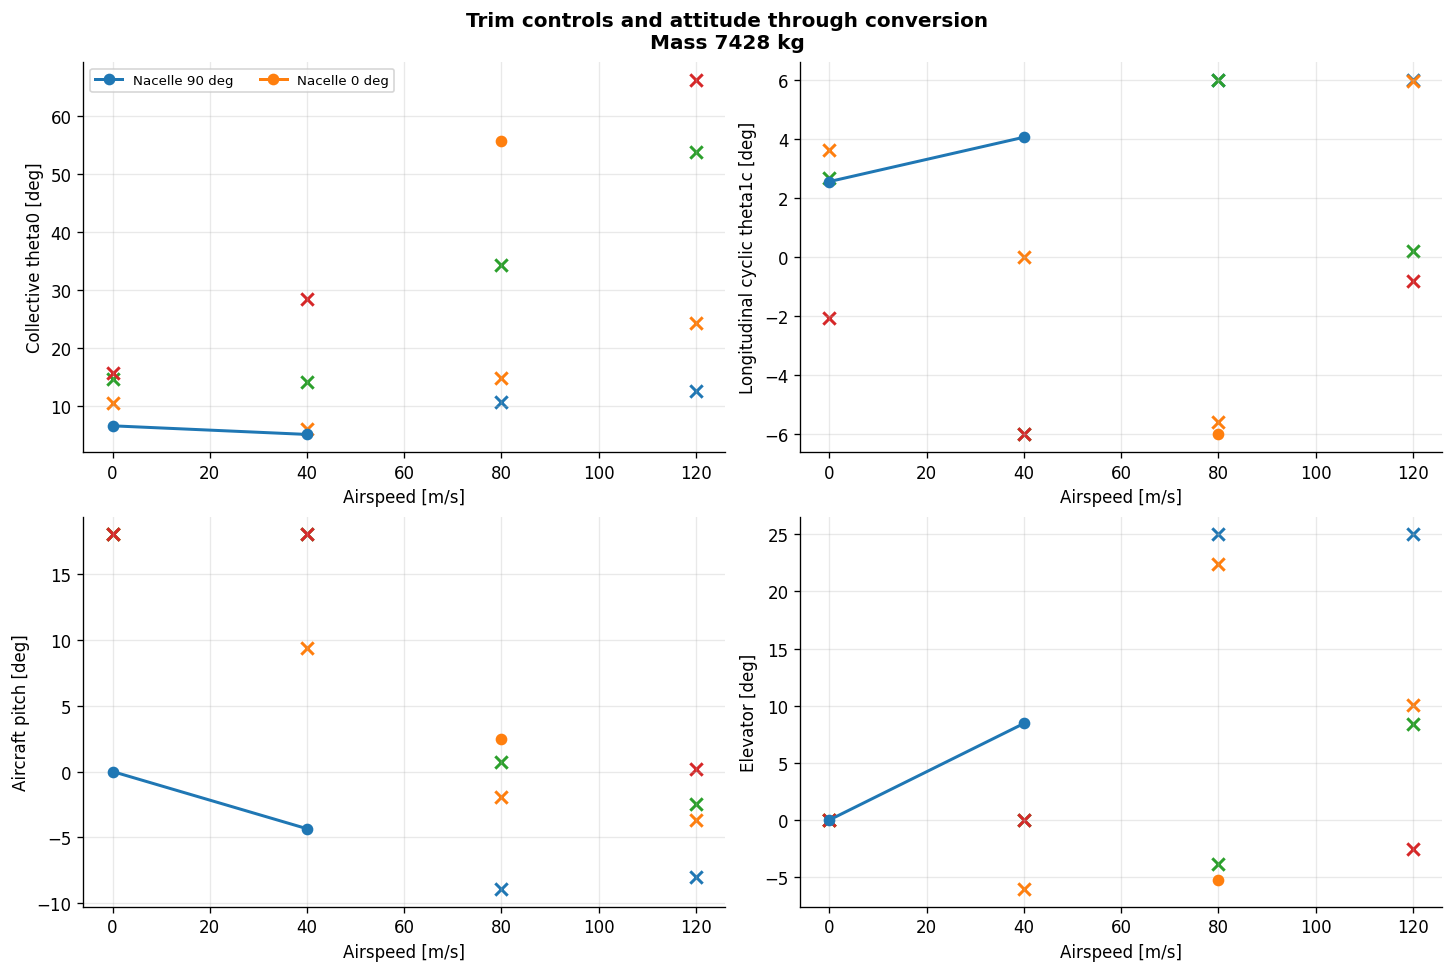

Saved: C:\Users\Ayush\Documents\IITB Acads\7th sem\AE667\Assignment_2\milestone2_trim_outputs\section_6_4_power_and_lift_sharing.png


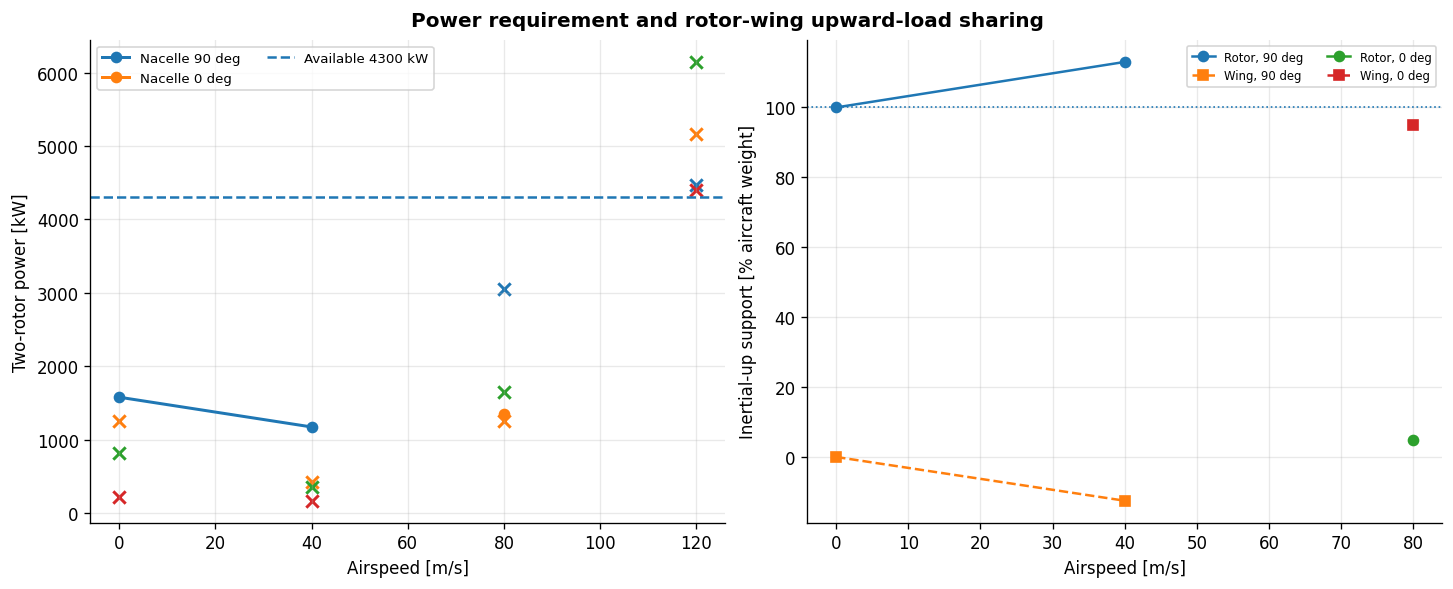

Saved: C:\Users\Ayush\Documents\IITB Acads\7th sem\AE667\Assignment_2\milestone2_trim_outputs\section_6_2_six_component_residuals.png


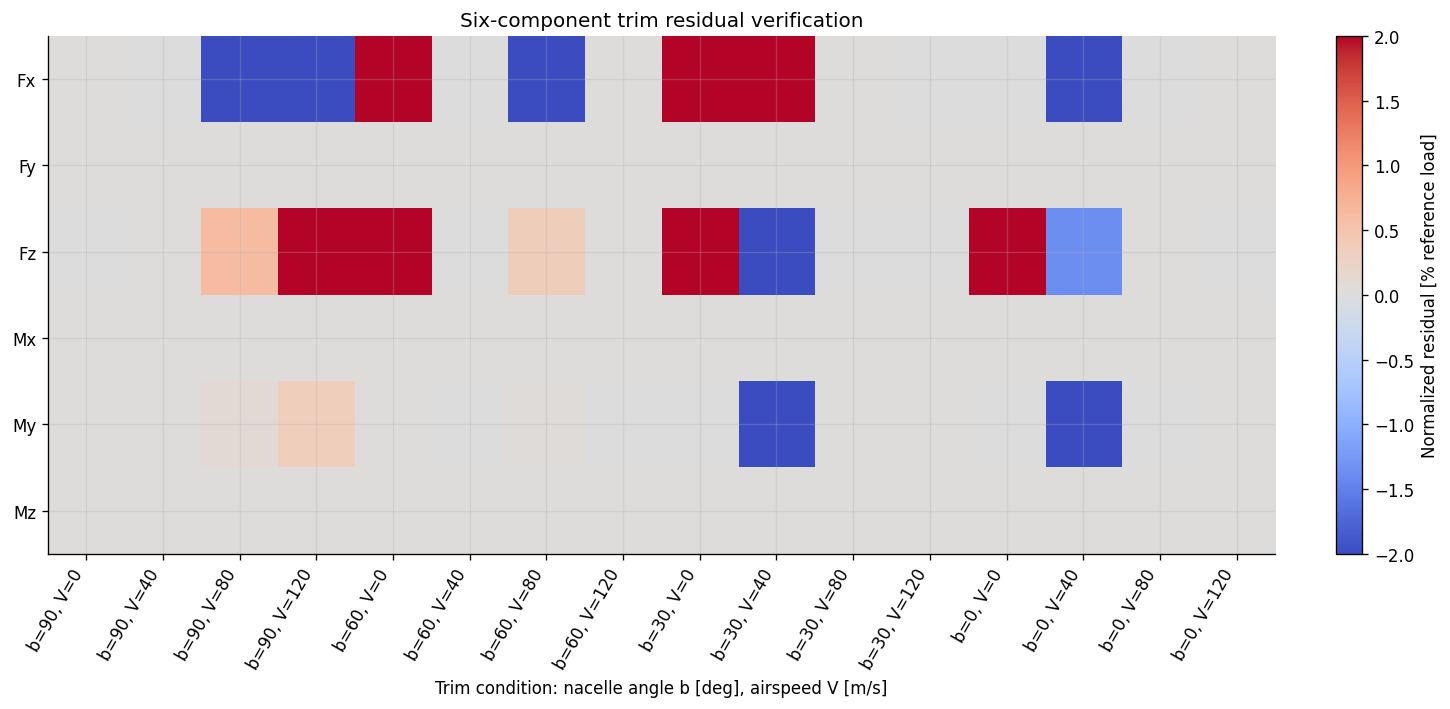

Saved: C:\Users\Ayush\Documents\IITB Acads\7th sem\AE667\Assignment_2\milestone2_trim_outputs\section_6_rotor_margin_diagnostics.png


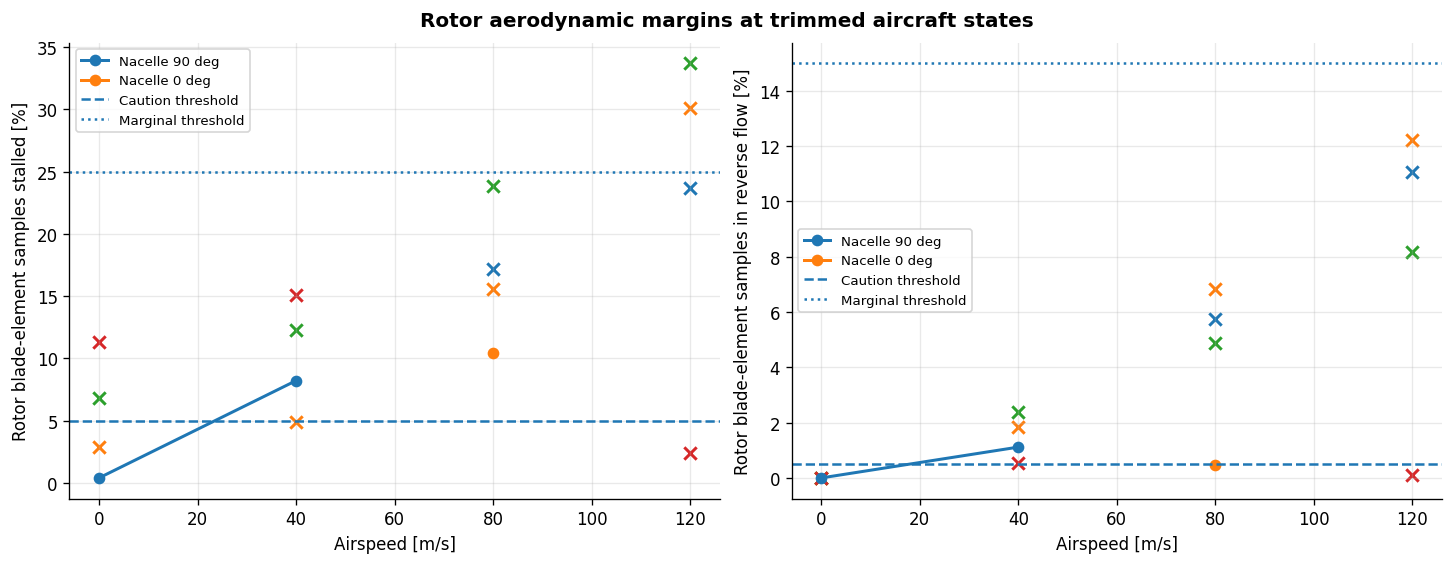

Saved: C:\Users\Ayush\Documents\IITB Acads\7th sem\AE667\Assignment_2\milestone2_trim_outputs\section_6_3_failed_trim_case.png


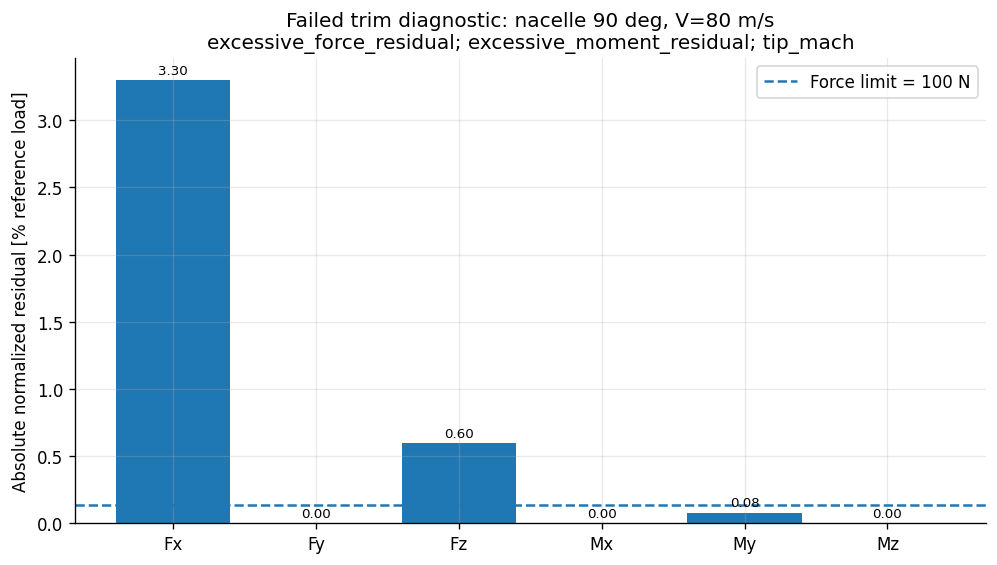

In [11]:
# ============================================================
# SECTION 6 PLOTS — DATABASE ONLY
# ============================================================

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.28,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def save_trim_figure(fig, filename):
    path = TRIM_OUTPUT_DIR / filename
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    print(f"Saved: {path.resolve()}")

def _plot_feasible_lines(ax, y_column, ylabel):
    for nacelle_deg in REQUIRED_NACELLE_ANGLES_DEG:
        group = (
            trim_results_df[
                trim_results_df["nacelle_deg"] == nacelle_deg
            ]
            .sort_values("V_ms")
        )
        valid = group[group["status"] == "FEASIBLE"]
        failed = group[group["status"] == "FAILED"]

        if len(valid):
            ax.plot(
                valid["V_ms"], valid[y_column],
                marker="o", linewidth=1.8,
                label=f"Nacelle {nacelle_deg:.0f} deg",
            )
        if len(failed) and y_column in failed.columns:
            ax.scatter(
                failed["V_ms"], failed[y_column],
                marker="x", s=55, linewidths=1.8,
            )

    ax.set_xlabel("Airspeed [m/s]")
    ax.set_ylabel(ylabel)


# 6.2 control and attitude trends
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
_plot_feasible_lines(axes[0, 0], "theta0_deg", "Collective theta0 [deg]")
_plot_feasible_lines(
    axes[0, 1], "theta1c_longitudinal_deg",
    "Longitudinal cyclic theta1c [deg]",
)
_plot_feasible_lines(axes[1, 0], "pitch_deg", "Aircraft pitch [deg]")
_plot_feasible_lines(axes[1, 1], "elevator_deg", "Elevator [deg]")
axes[0, 0].legend(fontsize=8, ncol=2)
fig.suptitle(
    "Trim controls and attitude through conversion\n"
    f"Mass {TRIM_CFG['mass_kg']:.0f} kg",
    fontweight="bold",
)
save_trim_figure(fig, "section_6_2_trim_controls.png")
plt.show()


# Power and physically resolved upward-support sharing
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

_plot_feasible_lines(axes[0], "power_kW", "Two-rotor power [kW]")
axes[0].axhline(
    TRIM_CFG["power_available_kW"],
    linestyle="--",
    label=f"Available {TRIM_CFG['power_available_kW']:.0f} kW",
)
axes[0].legend(fontsize=8, ncol=2)

for nacelle_deg in REQUIRED_NACELLE_ANGLES_DEG:
    group = trim_results_df[
        (trim_results_df["nacelle_deg"] == nacelle_deg)
        & (trim_results_df["status"] == "FEASIBLE")
    ].sort_values("V_ms")

    if len(group):
        axes[1].plot(
            group["V_ms"], group["rotor_up_support_pct_W"],
            marker="o",
            label=f"Rotor, {nacelle_deg:.0f} deg",
        )
        axes[1].plot(
            group["V_ms"], group["wing_up_support_pct_W"],
            marker="s", linestyle="--",
            label=f"Wing, {nacelle_deg:.0f} deg",
        )

axes[1].axhline(100.0, linewidth=1.0, linestyle=":")
axes[1].set_xlabel("Airspeed [m/s]")
axes[1].set_ylabel("Inertial-up support [% aircraft weight]")
axes[1].legend(fontsize=7, ncol=2)
fig.suptitle(
    "Power requirement and rotor-wing upward-load sharing",
    fontweight="bold",
)
save_trim_figure(fig, "section_6_4_power_and_lift_sharing.png")
plt.show()


# Six-component residual verification
load_labels = ["Fx", "Fy", "Fz", "Mx", "My", "Mz"]
case_labels = [
    f"b={row.nacelle_deg:.0f}, V={row.V_ms:.0f}"
    for row in trim_results_df.itertuples()
]

W_trim, Mscale_trim = _trim_scales()
normalized_residuals = np.column_stack([
    trim_results_df[["Fx_N", "Fy_N", "Fz_N"]].to_numpy(float) / W_trim,
    trim_results_df[["Mx_Nm", "My_Nm", "Mz_Nm"]].to_numpy(float)
    / Mscale_trim[None, :],
])

fig, ax = plt.subplots(figsize=(12, 5.8), constrained_layout=True)
im = ax.imshow(
    100.0 * normalized_residuals.T,
    aspect="auto", cmap="coolwarm", vmin=-2.0, vmax=2.0,
)
ax.set_yticks(range(6), load_labels)
ax.set_xticks(
    range(len(case_labels)),
    case_labels,
    rotation=60,
    ha="right",
)
ax.set_xlabel("Trim condition: nacelle angle b [deg], airspeed V [m/s]")
ax.set_title("Six-component trim residual verification")
cb = fig.colorbar(im, ax=ax)
cb.set_label("Normalized residual [% reference load]")
save_trim_figure(fig, "section_6_2_six_component_residuals.png")
plt.show()


# Rotor stall / reverse-flow are shown as margins, not binary failures.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)

_plot_feasible_lines(
    axes[0], "rotor_stall_pct",
    "Rotor blade-element samples stalled [%]",
)
axes[0].axhline(
    100.0 * TRIM_CFG["rotor_stall_warning_fraction"],
    linestyle="--", label="Caution threshold",
)
axes[0].axhline(
    100.0 * TRIM_CFG["rotor_stall_marginal_fraction"],
    linestyle=":", label="Marginal threshold",
)
axes[0].legend(fontsize=8)

_plot_feasible_lines(
    axes[1], "reverse_flow_pct",
    "Rotor blade-element samples in reverse flow [%]",
)
axes[1].axhline(
    100.0 * TRIM_CFG["reverse_flow_warning_fraction"],
    linestyle="--", label="Caution threshold",
)
axes[1].axhline(
    100.0 * TRIM_CFG["reverse_flow_marginal_fraction"],
    linestyle=":", label="Marginal threshold",
)
axes[1].legend(fontsize=8)

fig.suptitle(
    "Rotor aerodynamic margins at trimmed aircraft states",
    fontweight="bold",
)
save_trim_figure(fig, "section_6_rotor_margin_diagnostics.png")
plt.show()


# Failed-case plot, if available
if len(section6_failed_case_df):
    row = section6_failed_case_df.iloc[0]
    normalized = np.r_[
        row[["Fx_N", "Fy_N", "Fz_N"]].to_numpy(float) / W_trim,
        row[["Mx_Nm", "My_Nm", "Mz_Nm"]].to_numpy(float) / Mscale_trim,
    ]

    fig, ax = plt.subplots(figsize=(8.2, 4.6), constrained_layout=True)
    bars = ax.bar(load_labels, 100.0 * np.abs(normalized))
    force_limit_pct_W = (
        100.0 * TRIM_CFG["force_residual_limit_N"]
        / (TRIM_CFG["mass_kg"] * TRIM_CFG["g_ms2"])
    )
    ax.axhline(
        force_limit_pct_W,
        linestyle="--",
        label=f"Force limit = {TRIM_CFG['force_residual_limit_N']:.0f} N",
    )
    ax.set_ylabel("Absolute normalized residual [% reference load]")
    ax.set_title(
        "Failed trim diagnostic: "
        f"nacelle {row['nacelle_deg']:.0f} deg, "
        f"V={row['V_ms']:.0f} m/s\n"
        f"{row['failure_or_active_constraint']}"
    )
    ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8)
    ax.legend()
    save_trim_figure(fig, "section_6_3_failed_trim_case.png")
    plt.show()


Saved: C:\Users\Ayush\Documents\IITB Acads\7th sem\AE667\Assignment_2\milestone2_trim_outputs\section_7_1_conversion_corridor.png


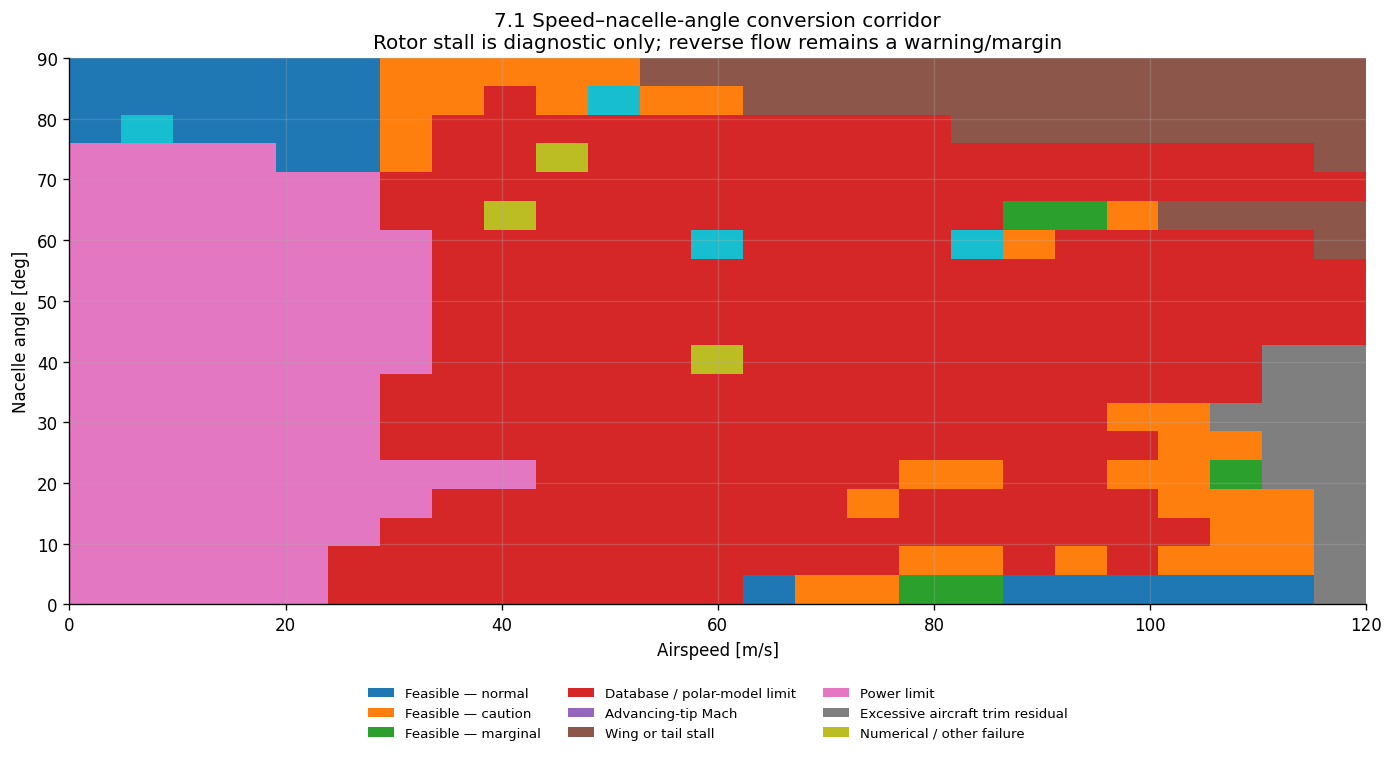

,Primary constraint,Number of grid states,Fraction [%]
0,Database / polar-model limit,245,51.58
1,Wing or tail stall,101,21.26
2,Advancing-tip Mach,40,8.42
3,Feasible — caution,36,7.58
4,Feasible — normal,26,5.47
5,Power limit,15,3.16
6,Feasible — marginal,5,1.05
7,Numerical / other failure,4,0.84
8,Excessive aircraft trim residual,3,0.63


Saved: C:\Users\Ayush\Documents\IITB Acads\7th sem\AE667\Assignment_2\milestone2_trim_outputs\section_7_total_up_support.png


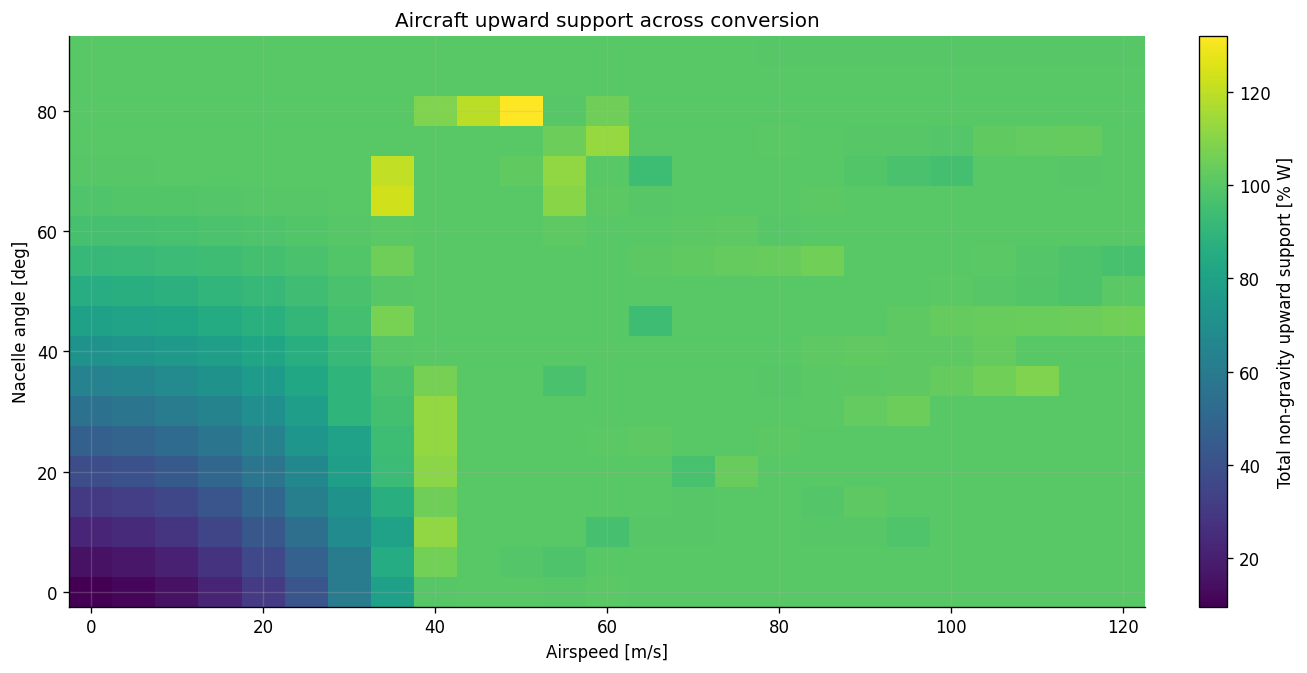

Saved: C:\Users\Ayush\Documents\IITB Acads\7th sem\AE667\Assignment_2\milestone2_trim_outputs\section_7_rotor_up_support.png


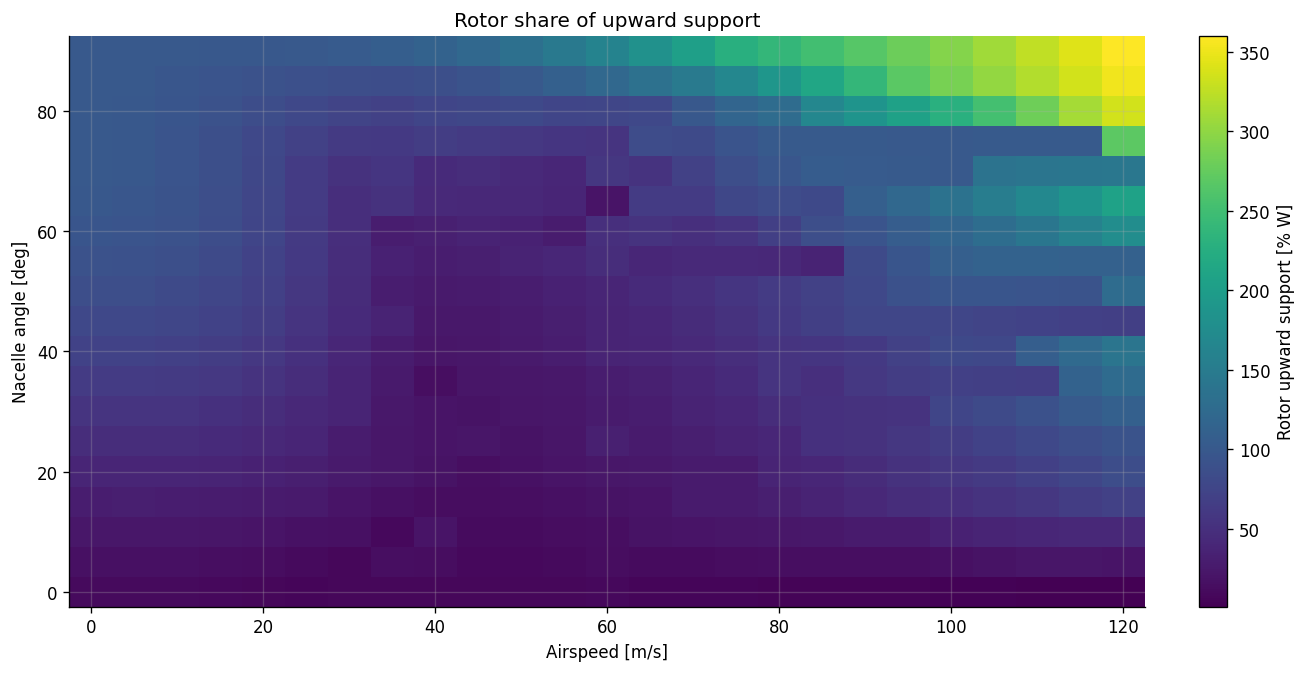

Saved: C:\Users\Ayush\Documents\IITB Acads\7th sem\AE667\Assignment_2\milestone2_trim_outputs\section_7_wing_up_support.png


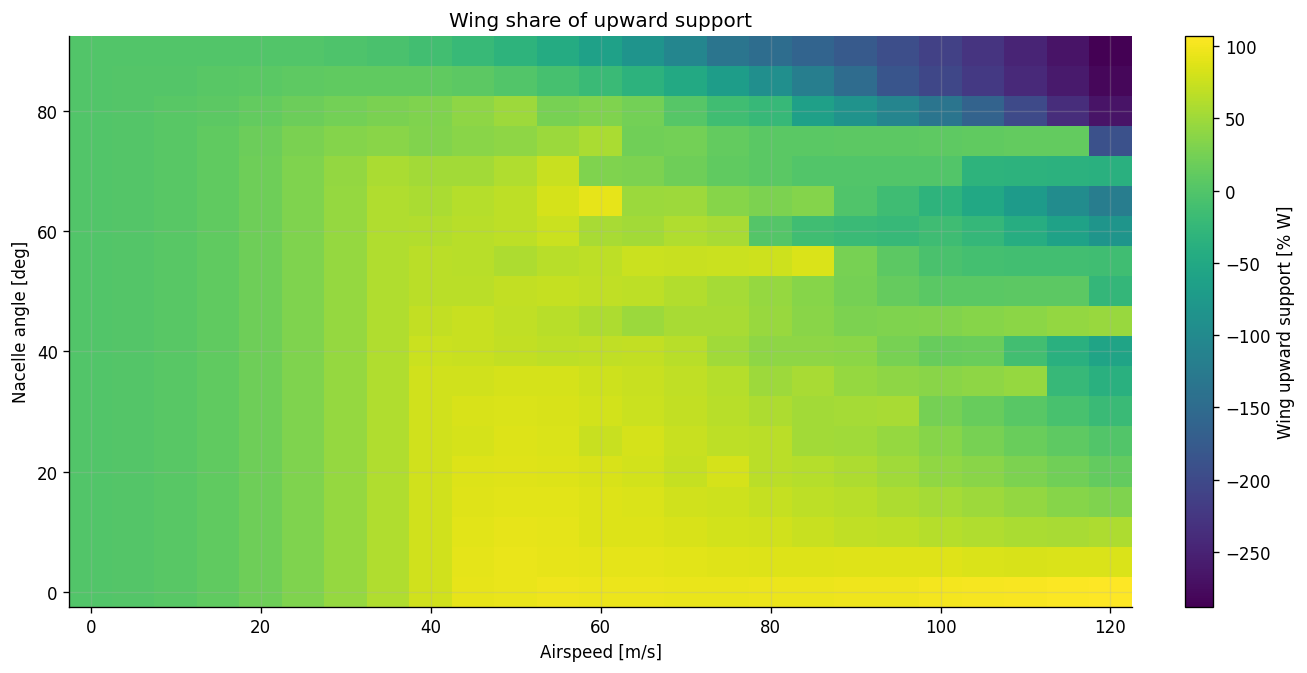

Saved: C:\Users\Ayush\Documents\IITB Acads\7th sem\AE667\Assignment_2\milestone2_trim_outputs\section_7_rotor_stall_fraction.png


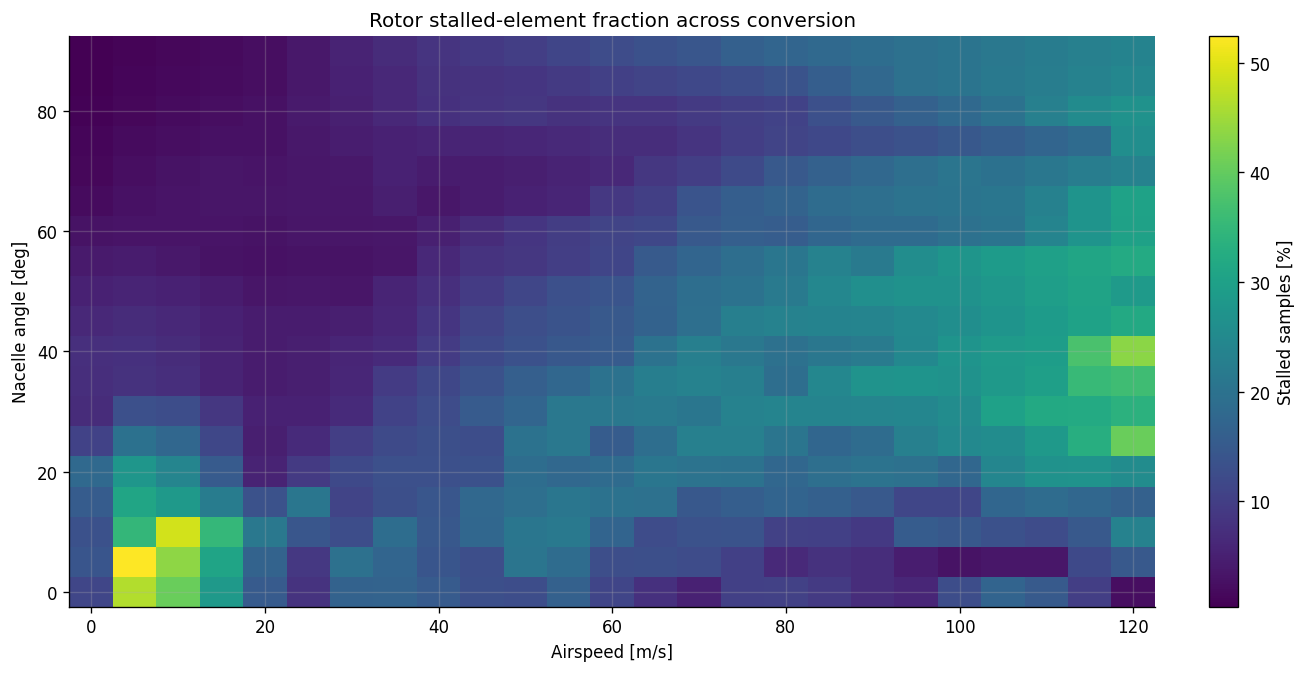

Section 7 generated entirely from trim_database_df. Nonlinear trim solves: 0


In [12]:
# ============================================================
# SECTION 7 — CONVERSION CORRIDOR FROM THE SAME TRIM DATABASE
# ZERO TRIM SOLVES
# ============================================================

from matplotlib.patches import Patch

constraint_labels = {
    0: "Feasible — normal",
    1: "Feasible — caution",
    2: "Feasible — marginal",
    3: "Database / polar-model limit",
    4: "Advancing-tip Mach",
    5: "Wing or tail stall",
    6: "Power limit",
    7: "Excessive aircraft trim residual",
    8: "Numerical / other failure",
}

def corridor_code(row):
    if row["status"] == "FEASIBLE":
        if row["operating_class"] == "NORMAL":
            return 0
        if row["operating_class"] == "CAUTION":
            return 1
        return 2

    failure = str(row["failure_or_active_constraint"])
    if "database_coverage" in failure or "polar_extrapolation" in failure:
        return 3
    if "tip_mach" in failure:
        return 4
    if "wing_stall" in failure or "tail_stall" in failure:
        return 5
    if "power_limit" in failure:
        return 6
    if (
        "excessive_force_residual" in failure
        or "excessive_moment_residual" in failure
    ):
        return 7
    return 8


corridor_df = trim_database_df.copy()
corridor_df["corridor_code"] = corridor_df.apply(corridor_code, axis=1)
corridor_df["primary_constraint"] = corridor_df["corridor_code"].map(
    constraint_labels
)

nacelle_axis = np.asarray(sorted(corridor_df["nacelle_deg"].unique()), float)
speed_axis = np.asarray(sorted(corridor_df["V_ms"].unique()), float)

corridor_grid = (
    corridor_df
    .pivot(index="nacelle_deg", columns="V_ms", values="corridor_code")
    .reindex(index=nacelle_axis, columns=speed_axis)
    .to_numpy(int)
)

fig, ax = plt.subplots(figsize=(11.5, 6.2), constrained_layout=True)
im = ax.imshow(
    corridor_grid,
    origin="lower",
    aspect="auto",
    extent=[
        speed_axis[0], speed_axis[-1],
        nacelle_axis[0], nacelle_axis[-1],
    ],
    interpolation="nearest",
    vmin=-0.5,
    vmax=max(constraint_labels) + 0.5,
    cmap="tab10",
)

ax.set_xlabel("Airspeed [m/s]")
ax.set_ylabel("Nacelle angle [deg]")
ax.set_title(
    "7.1 Speed–nacelle-angle conversion corridor\n"
    "Rotor stall is diagnostic only; reverse flow remains a warning/margin"
)

handles = [
    Patch(
        facecolor=plt.get_cmap("tab10")(i / 10),
        label=label,
    )
    for i, label in constraint_labels.items()
    if np.any(corridor_grid == i)
]
ax.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.13),
    ncol=3,
    frameon=False,
    fontsize=8,
)
save_trim_figure(fig, "section_7_1_conversion_corridor.png")
plt.show()


# Active constraint counts
constraint_counts = (
    corridor_df["primary_constraint"]
    .value_counts()
    .rename_axis("Primary constraint")
    .reset_index(name="Number of grid states")
)
constraint_counts["Fraction [%]"] = (
    100.0
    * constraint_counts["Number of grid states"]
    / len(corridor_df)
)
constraint_counts.to_csv(
    TRIM_OUTPUT_DIR / "section_7_2_active_constraint_counts.csv",
    index=False,
)

display(HTML("<h3>7.2 Active-constraint summary</h3>"))
display(constraint_counts.round(2))


# Additional performance maps: useful for interpreting HOW the aircraft flies.
def _plot_db_map(column, title, cbar_label, filename):
    grid = (
        corridor_df
        .pivot(index="nacelle_deg", columns="V_ms", values=column)
        .reindex(index=nacelle_axis, columns=speed_axis)
        .to_numpy(float)
    )

    fig, ax = plt.subplots(figsize=(10.8, 5.5), constrained_layout=True)
    mesh = ax.pcolormesh(
        speed_axis, nacelle_axis, grid,
        shading="auto",
    )
    ax.set_xlabel("Airspeed [m/s]")
    ax.set_ylabel("Nacelle angle [deg]")
    ax.set_title(title)
    cb = fig.colorbar(mesh, ax=ax)
    cb.set_label(cbar_label)
    save_trim_figure(fig, filename)
    plt.show()


_plot_db_map(
    "total_up_support_pct_W",
    "Aircraft upward support across conversion",
    "Total non-gravity upward support [% W]",
    "section_7_total_up_support.png",
)

_plot_db_map(
    "rotor_up_support_pct_W",
    "Rotor share of upward support",
    "Rotor upward support [% W]",
    "section_7_rotor_up_support.png",
)

_plot_db_map(
    "wing_up_support_pct_W",
    "Wing share of upward support",
    "Wing upward support [% W]",
    "section_7_wing_up_support.png",
)

_plot_db_map(
    "rotor_stall_pct",
    "Rotor stalled-element fraction across conversion",
    "Stalled samples [%]",
    "section_7_rotor_stall_fraction.png",
)

print("Section 7 generated entirely from trim_database_df. Nonlinear trim solves: 0")


In [13]:
# ============================================================
# FAST TRIM-DATABASE LOOKUP FOR MISSION PLANNER / OFF-GRID USE
# ============================================================

from scipy.interpolate import RegularGridInterpolator

TRIM_DB_CONTINUOUS_OUTPUTS = [
    "pitch_deg",
    "theta0_deg",
    "theta1c_longitudinal_deg",
    "theta1s_lateral_deg",
    "elevator_deg",
    "aileron_deg",
    "rudder_deg",
    "rpm",
    "power_kW",
    "power_margin_kW",
    "Fx_N", "Fy_N", "Fz_N", "Mx_Nm", "My_Nm", "Mz_Nm",
    "total_up_support_pct_W",
    "rotor_up_support_pct_W",
    "wing_up_support_pct_W",
    "tail_up_support_pct_W",
    "rotor_stall_fraction",
    "reverse_flow_fraction",
    "advancing_tip_Mach",
    "database_coverage",
    "flow_angle_deg",
]

trim_nacelle_axis = np.asarray(
    sorted(trim_database_df["nacelle_deg"].unique()), float
)
trim_speed_axis = np.asarray(
    sorted(trim_database_df["V_ms"].unique()), float
)

def _grid_for(column):
    return (
        trim_database_df
        .pivot(index="nacelle_deg", columns="V_ms", values=column)
        .reindex(index=trim_nacelle_axis, columns=trim_speed_axis)
        .to_numpy()
    )

trim_feasible_grid = (
    _grid_for("status") == "FEASIBLE"
)

trim_interpolators = {}
for name in TRIM_DB_CONTINUOUS_OUTPUTS:
    trim_interpolators[name] = RegularGridInterpolator(
        (trim_nacelle_axis, trim_speed_axis),
        _grid_for(name).astype(float),
        bounds_error=False,
        fill_value=np.nan,
    )


def _supporting_indices(axis, value):
    if value < axis[0] or value > axis[-1]:
        return None

    hi = int(np.searchsorted(axis, value, side="right"))
    if hi == 0:
        return 0, 0
    if hi >= len(axis):
        return len(axis) - 1, len(axis) - 1

    lo = hi - 1
    if np.isclose(value, axis[lo]):
        return lo, lo
    if np.isclose(value, axis[hi]):
        return hi, hi
    return lo, hi


def trim_database_lookup(V_ms, nacelle_deg, verify_physics=True):
    """
    Bilinear lookup in (nacelle angle, airspeed).

    Safety rule:
      every supporting database node must be FEASIBLE.

    Optional physics verification:
      the interpolated controls are evaluated ONCE by aircraft_loads_total()
      and checked with the same aircraft-level feasibility classifier.
      No nonlinear optimizer is called.
    """
    V_ms = float(V_ms)
    nacelle_deg = float(nacelle_deg)

    ni = _supporting_indices(trim_nacelle_axis, nacelle_deg)
    vi = _supporting_indices(trim_speed_axis, V_ms)

    result = {
        "V_ms": V_ms,
        "nacelle_deg": nacelle_deg,
        "database_feasible": False,
        "physics_verified": False,
        "surrogate_usable": False,
    }

    if ni is None or vi is None:
        result["reason"] = "outside_trim_database_domain"
        return result

    n_ids = sorted(set(ni))
    v_ids = sorted(set(vi))

    support_feasible = all(
        bool(trim_feasible_grid[i, j])
        for i in n_ids
        for j in v_ids
    )

    if not support_feasible:
        result["reason"] = "one_or_more_supporting_trim_nodes_failed"
        return result

    point = np.array([[nacelle_deg, V_ms]], float)
    values = {
        name: float(interp(point)[0])
        for name, interp in trim_interpolators.items()
    }

    controls = np.array([
        values["theta0_deg"],
        values["theta1c_longitudinal_deg"],
        values["theta1s_lateral_deg"],
        values["pitch_deg"],
        values["elevator_deg"],
        values["aileron_deg"],
        values["rudder_deg"],
    ], float)

    result.update(values)
    result["controls"] = controls
    result["database_feasible"] = True

    if not verify_physics:
        result["surrogate_usable"] = True
        result["reason"] = "database_support_only"
        return result

    try:
        data = aircraft_loads_total(
            V_ms,
            nacelle_deg,
            controls,
            flight_path_deg=TRIM_FLIGHT_PATH_DEG,
            altitude_m=TRIM_ALTITUDE_M,
        )
        cls = classify_trim_state(
            data,
            controls,
            solver_success=True,
        )

        result.update({
            "physics_verified": bool(cls["feasible"]),
            "surrogate_usable": bool(cls["feasible"]),
            "reason": (
                "OK"
                if cls["feasible"]
                else "; ".join(cls["hard_failures"])
            ),
            "warning": (
                "NONE"
                if not cls["warnings"]
                else "; ".join(cls["warnings"])
            ),
            "operating_class": cls["operating_class"],
            "verified_residual": np.asarray(data["residual"], float),
            "verified_force_residual_fraction_W":
                cls["force_residual_fraction_W"],
            "verified_moment_residual_fraction":
                cls["moment_residual_fraction"],
            "verified_power_kW": float(data["power_kW"]),
            "verified_rotor_stall_fraction":
                float(data["rotor_stall_fraction"]),
            "verified_reverse_flow_fraction":
                float(data["reverse_flow_fraction"]),
            "verified_total_up_support_fraction_W":
                float(cls["up_support_fraction_W"]),
            "verified_rotor_up_support_fraction_W":
                float(cls["rotor_up_support_fraction_W"]),
            "verified_wing_up_support_fraction_W":
                float(cls["wing_up_support_fraction_W"]),
        })

    except Exception as exc:
        result.update({
            "physics_verified": False,
            "surrogate_usable": False,
            "reason": "verification_failure",
            "detail": str(exc),
        })

    return result


print("trim_database_lookup(V_ms, nacelle_deg) is ready.")
print("It interpolates controls and performs one aircraft-load evaluation; no trim solve.")


trim_database_lookup(V_ms, nacelle_deg) is ready.
It interpolates controls and performs one aircraft-load evaluation; no trim solve.


In [14]:
# ============================================================
# OFF-GRID SURROGATE CHECK — FAST, NO NONLINEAR TRIM SOLVES
# ============================================================

validation_candidates = []

for i in range(len(trim_nacelle_axis) - 1):
    for j in range(len(trim_speed_axis) - 1):
        if np.all(trim_feasible_grid[i:i+2, j:j+2]):
            validation_candidates.append((
                0.5 * (trim_speed_axis[j] + trim_speed_axis[j+1]),
                0.5 * (trim_nacelle_axis[i] + trim_nacelle_axis[i+1]),
            ))

if len(validation_candidates) > 12:
    ids = np.unique(
        np.linspace(
            0, len(validation_candidates) - 1, 12
        ).round().astype(int)
    )
    validation_candidates = [
        validation_candidates[i] for i in ids
    ]

validation_rows = []

for V_ms, nacelle_deg in validation_candidates:
    estimate = trim_database_lookup(
        V_ms,
        nacelle_deg,
        verify_physics=True,
    )

    force_err = np.nan
    moment_err = np.nan

    if "verified_force_residual_fraction_W" in estimate:
        force_err = (
            100.0
            * float(np.max(
                estimate["verified_force_residual_fraction_W"]
            ))
        )

    if "verified_moment_residual_fraction" in estimate:
        moment_err = (
            100.0
            * float(np.max(
                estimate["verified_moment_residual_fraction"]
            ))
        )

    validation_rows.append({
        "V_ms": V_ms,
        "nacelle_deg": nacelle_deg,
        "database_support_feasible":
            estimate.get("database_feasible", False),
        "physics_verified":
            estimate.get("physics_verified", False),
        "surrogate_usable":
            estimate.get("surrogate_usable", False),
        "operating_class":
            estimate.get("operating_class", ""),
        "warning":
            estimate.get("warning", ""),
        "max_force_residual_pct_W": force_err,
        "max_moment_residual_pct_ref": moment_err,
        "verified_total_up_support_pct_W":
            100.0 * estimate.get(
                "verified_total_up_support_fraction_W",
                np.nan,
            ),
        "reason": estimate.get("reason", ""),
    })

trim_validation_df = pd.DataFrame(validation_rows)
trim_validation_df.to_csv(
    TRIM_OUTPUT_DIR / "trim_database_offgrid_validation.csv",
    index=False,
)

display(HTML("<h3>Off-grid trim-surrogate physics check</h3>"))

if len(trim_validation_df):
    display(trim_validation_df.round(3))

    print(
        f"Physics-verified off-grid points: "
        f"{int(trim_validation_df['physics_verified'].sum())}/"
        f"{len(trim_validation_df)}"
    )
else:
    display(HTML(
        "<p>No four-corner feasible interpolation cells exist on this grid.</p>"
    ))

print("Nonlinear trim solves in this validation cell: 0")


,V_ms,nacelle_deg,database_support_feasible,physics_verified,surrogate_usable,operating_class,warning,max_force_residual_pct_W,max_moment_residual_pct_ref,verified_total_up_support_pct_W,reason
0,82.5,2.5,True,False,False,FAILED,reverse_flow_warning,0.210,0.238,100.210,excessive_force_residual; excessive_moment_res...
1,112.5,2.5,True,False,False,FAILED,reverse_flow_warning,3.653,0.332,99.862,excessive_force_residual; excessive_moment_res...
2,112.5,7.5,True,False,False,FAILED,reverse_flow_warning,4.698,0.591,101.595,excessive_force_residual; excessive_moment_res...
3,107.5,17.5,True,False,False,FAILED,reverse_flow_warning; control_near_limit,0.575,0.277,100.392,excessive_force_residual; excessive_moment_res...
4,22.5,77.5,True,False,False,FAILED,NONE,0.121,0.093,99.893,excessive_moment_residual
5,12.5,82.5,True,False,False,FAILED,NONE,0.040,0.416,99.964,excessive_moment_residual
6,17.5,82.5,True,False,False,FAILED,NONE,0.054,0.391,99.993,excessive_moment_residual
7,27.5,82.5,True,False,False,FAILED,NONE,0.086,0.191,99.939,excessive_moment_residual
8,7.5,87.5,True,False,False,FAILED,NONE,0.082,0.316,100.082,excessive_moment_residual
9,17.5,87.5,True,False,False,FAILED,NONE,0.060,0.404,100.060,excessive_moment_residual


Physics-verified off-grid points: 0/12
Nonlinear trim solves in this validation cell: 0


Saved: C:\Users\Ayush\Documents\IITB Acads\7th sem\AE667\Assignment_2\milestone2_trim_outputs\section_2_2_trim_solver_logic.png


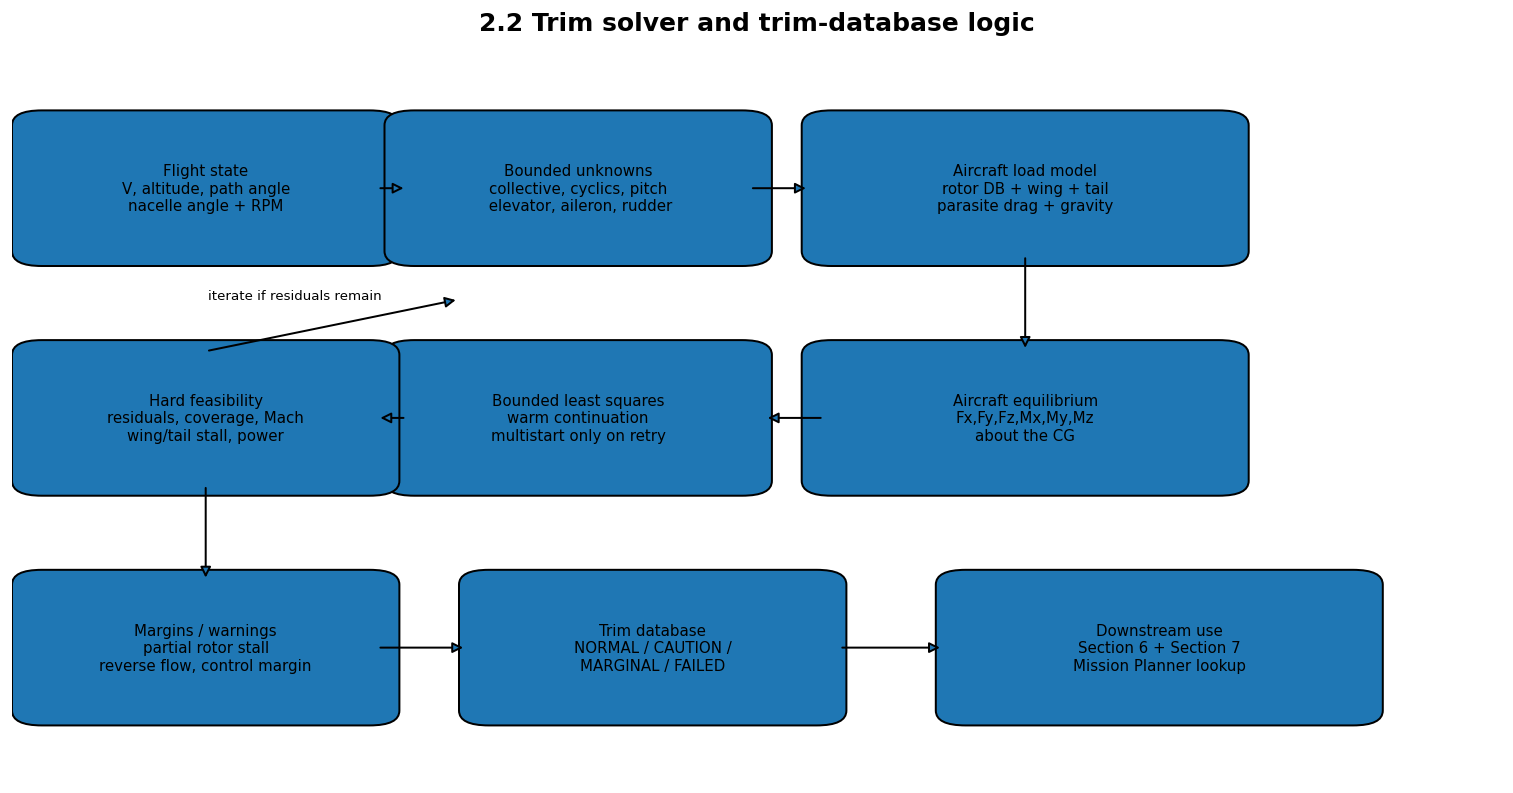

,Nacelle angle [deg],Speed range [m/s],Rotor support change [percentage points],Wing support change [percentage points],Pitch change [deg],Power change [kW]
0,90.0,0 -> 40,13.009,-12.517,-4.339,-405.134


All trim tables and figures are in: C:\Users\Ayush\Documents\IITB Acads\7th sem\AE667\Assignment_2\milestone2_trim_outputs


In [15]:
# ============================================================
# SECTION 2.2 / 6.4 — LOGIC AND PHYSICAL INTERPRETATION
# ============================================================

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def add_flow_box(ax, center, width, height, text):
    x, y = center
    box = FancyBboxPatch(
        (x - width/2, y - height/2),
        width, height,
        boxstyle="round,pad=0.015,rounding_size=0.02",
        linewidth=1.2,
    )
    ax.add_patch(box)
    ax.text(x, y, text, ha="center", va="center", fontsize=9)

def add_flow_arrow(ax, start, end):
    ax.add_patch(FancyArrowPatch(
        start, end,
        arrowstyle="-|>",
        mutation_scale=13,
        linewidth=1.2,
    ))

fig, ax = plt.subplots(figsize=(12.5, 6.5), constrained_layout=True)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

boxes = [
    ((0.13, 0.80), "Flight state\nV, altitude, path angle\nnacelle angle + RPM"),
    ((0.38, 0.80), "Bounded unknowns\ncollective, cyclics, pitch\n elevator, aileron, rudder"),
    ((0.68, 0.80), "Aircraft load model\nrotor DB + wing + tail\nparasite drag + gravity"),
    ((0.68, 0.49), "Aircraft equilibrium\nFx,Fy,Fz,Mx,My,Mz\nabout the CG"),
    ((0.38, 0.49), "Bounded least squares\nwarm continuation\nmultistart only on retry"),
    ((0.13, 0.49), "Hard feasibility\nresiduals, coverage, Mach\nwing/tail stall, power"),
    ((0.13, 0.18), "Margins / warnings\npartial rotor stall\nreverse flow, control margin"),
    ((0.43, 0.18), "Trim database\nNORMAL / CAUTION /\nMARGINAL / FAILED"),
    ((0.77, 0.18), "Downstream use\nSection 6 + Section 7\nMission Planner lookup"),
]

for center, label in boxes:
    add_flow_box(
        ax, center,
        0.23 if center[0] < 0.6 else 0.27,
        0.18,
        label,
    )

for start, end in [
    ((0.245, 0.80), (0.265, 0.80)),
    ((0.495, 0.80), (0.535, 0.80)),
    ((0.68, 0.71), (0.68, 0.58)),
    ((0.545, 0.49), (0.505, 0.49)),
    ((0.265, 0.49), (0.245, 0.49)),
    ((0.13, 0.40), (0.13, 0.27)),
    ((0.245, 0.18), (0.305, 0.18)),
    ((0.555, 0.18), (0.625, 0.18)),
]:
    add_flow_arrow(ax, start, end)

add_flow_arrow(ax, (0.13, 0.58), (0.30, 0.65))
ax.text(0.19, 0.65, "iterate if residuals remain", fontsize=8, ha="center")

ax.set_title(
    "2.2 Trim solver and trim-database logic",
    fontsize=15,
    fontweight="bold",
)
save_trim_figure(fig, "section_2_2_trim_solver_logic.png")
plt.show()


# 6.4 trend table from feasible required-matrix states
trend_rows = []

for nacelle_deg in REQUIRED_NACELLE_ANGLES_DEG:
    group = (
        trim_results_df[
            (trim_results_df["nacelle_deg"] == nacelle_deg)
            & (trim_results_df["status"] == "FEASIBLE")
        ]
        .sort_values("V_ms")
    )

    if len(group) >= 2:
        trend_rows.append({
            "Nacelle angle [deg]": nacelle_deg,
            "Speed range [m/s]":
                f"{group['V_ms'].iloc[0]:.0f} -> {group['V_ms'].iloc[-1]:.0f}",
            "Rotor support change [percentage points]":
                float(
                    group["rotor_up_support_pct_W"].iloc[-1]
                    - group["rotor_up_support_pct_W"].iloc[0]
                ),
            "Wing support change [percentage points]":
                float(
                    group["wing_up_support_pct_W"].iloc[-1]
                    - group["wing_up_support_pct_W"].iloc[0]
                ),
            "Pitch change [deg]":
                float(
                    group["pitch_deg"].iloc[-1]
                    - group["pitch_deg"].iloc[0]
                ),
            "Power change [kW]":
                float(
                    group["power_kW"].iloc[-1]
                    - group["power_kW"].iloc[0]
                ),
        })

trim_trends_df = pd.DataFrame(trend_rows)
trim_trends_df.to_csv(
    TRIM_OUTPUT_DIR / "section_6_4_trim_trends.csv",
    index=False,
)

display(HTML(
    "<h3>6.4 Physical interpretation data</h3>"
    "<p>Load sharing uses inertial-up force divided by aircraft weight. "
    "Partial rotor stall and reverse flow are retained as aerodynamic margins, "
    "while aircraft equilibrium determines whether the state can actually trim.</p>"
))
display(trim_trends_df.round(3))

print(f"All trim tables and figures are in: {TRIM_OUTPUT_DIR.resolve()}")


In [16]:

# SECTION 8 — INTERACTIVE AIRCRAFT TRIM EXPLORER
# ------------------------------------------------------------
# A database-driven GUI for inspecting every trim condition.
# Nonlinear trim solves are NOT called by this dashboard.
# One aircraft_loads_total() evaluation is optionally used only to
# visualize component forces for the selected condition.
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# ---------- Data / column helpers ----------
GUI_DF = trim_database_df.copy().sort_values(["nacelle_deg", "V_ms"]).reset_index(drop=True)
GUI_NACELLES = np.asarray(sorted(GUI_DF["nacelle_deg"].unique()), float)
GUI_SPEEDS = np.asarray(sorted(GUI_DF["V_ms"].unique()), float)

GUI_STATUS_CODE = {
    "NORMAL": 0,
    "CAUTION": 1,
    "MARGINAL": 2,
}
GUI_FAILURE_CODE = 3

GUI_HEATMAP_Z = (
    GUI_DF.assign(
        _code=GUI_DF.apply(
            lambda r: GUI_STATUS_CODE.get(str(r["operating_class"]).upper(), GUI_FAILURE_CODE)
            if str(r["status"]).upper() == "FEASIBLE"
            else GUI_FAILURE_CODE,
            axis=1,
        )
    )
    .pivot(index="nacelle_deg", columns="V_ms", values="_code")
    .reindex(index=GUI_NACELLES, columns=GUI_SPEEDS)
    .to_numpy(float)
)

GUI_COLORSCALE = [
    [0.00, "#1f8a70"], [0.20, "#1f8a70"],
    [0.34, "#e0a800"], [0.54, "#e0a800"],
    [0.68, "#c86b00"], [0.84, "#c86b00"],
    [1.00, "#c53d3d"],
]

# ---------- Compact numeric / geometry helpers ----------
def _gui_row(nacelle_deg, V_ms):
    m = (
        np.isclose(GUI_DF["nacelle_deg"].to_numpy(float), float(nacelle_deg))
        & np.isclose(GUI_DF["V_ms"].to_numpy(float), float(V_ms))
    )
    rows = GUI_DF.loc[m]
    if rows.empty:
        raise KeyError(f"No trim-database state at nacelle={nacelle_deg}, V={V_ms}.")
    return rows.iloc[0]

def _gui_fmt(x, digits=2, unit=""):
    try:
        xf = float(x)
        if not np.isfinite(xf):
            return "—"
        return f"{xf:.{digits}f}{unit}"
    except Exception:
        return "—"

def _gui_pct(x, digits=1):
    try:
        xf = float(x)
        if not np.isfinite(xf):
            return "—"
        return f"{xf:.{digits}f}%"
    except Exception:
        return "—"

def _gui_status(row):
    if str(row["status"]).upper() != "FEASIBLE":
        return "FAILED"
    return str(row["operating_class"]).upper()

def _gui_status_color(status):
    return {
        "NORMAL": "#1f8a70",
        "CAUTION": "#e0a800",
        "MARGINAL": "#c86b00",
        "FAILED": "#c53d3d",
    }.get(status, "#6b7280")

def _gui_basis(nacelle_deg):
    beta = np.radians(float(nacelle_deg))
    x_s = np.array([np.sin(beta), 0.0, np.cos(beta)])
    y_s = np.array([0.0, 1.0, 0.0])
    z_s = np.array([-np.cos(beta), 0.0, np.sin(beta)])
    return x_s, y_s, z_s

def _gui_plot_xyz(body_xyz):
    """Plot with conventional visual +Z-up while retaining body +Z-down in the model."""
    a = np.asarray(body_xyz, float)
    out = a.copy()
    out[..., 2] *= -1.0
    return out

def _gui_line_trace(points, **kwargs):
    p = np.asarray(points, float)
    q = _gui_plot_xyz(p)
    return go.Scatter3d(
        x=q[:,0], y=q[:,1], z=q[:,2],
        mode="lines",
        **kwargs,
    )

# ---------- Aircraft geometry ----------
_GUI_FUSE_L = float(globals().get("AIRCRAFT_FUSELAGE_LENGTH", 15.2))
_GUI_FUSE_W = float(globals().get("AIRCRAFT_FUSELAGE_WIDTH", 1.8))
_GUI_FUSE_H = float(globals().get("AIRCRAFT_FUSELAGE_HEIGHT", 1.9))
_GUI_SPAN = float(TRIM_CFG["b_wing_m"])
_GUI_AREA = float(TRIM_CFG["S_wing_m2"])
_GUI_CROOT = float(_wing_root_chord)
_GUI_CTIP = float(_wing_root_chord * _wing_taper)
_GUI_WING_Z = float(TRIM_CFG["wing_ac_body_m"][2])
_GUI_TAIL_X = float(TRIM_CFG["htail_ac_body_m"][0])
_GUI_TAIL_Z = float(TRIM_CFG["htail_ac_body_m"][2])
_GUI_ROTOR_X = float(TRIM_CFG["rotor_x_m"])
_GUI_ROTOR_Y = float(TRIM_CFG["rotor_y_m"])
_GUI_ROTOR_Z = float(TRIM_CFG["rotor_z_m"])
_GUI_ROTOR_R = float(globals().get("ROTOR_VIEW", {}).get("R_m", 4.60))

def _gui_fuselage_mesh():
    xx = np.linspace(-_GUI_FUSE_L/2, _GUI_FUSE_L/2, 28)
    pp = np.linspace(0, 2*np.pi, 20)
    X, P = np.meshgrid(xx, pp)
    taper = np.sqrt(np.maximum(0.0, 1.0 - (2.0*X/_GUI_FUSE_L)**2))
    Y = 0.5*_GUI_FUSE_W*taper*np.cos(P)
    Z = 0.5*_GUI_FUSE_H*taper*np.sin(P)
    q = _gui_plot_xyz(np.stack([X,Y,Z], axis=-1))
    return q[...,0], q[...,1], q[...,2]

def _gui_wing_mesh():
    ys = np.linspace(-_GUI_SPAN/2, _GUI_SPAN/2, 28)
    eta = np.linspace(0, 1, 8)
    rows = []
    for y in ys:
        frac = abs(y)/(_GUI_SPAN/2)
        chord = _GUI_CROOT + (_GUI_CTIP - _GUI_CROOT)*frac
        x_le = 0.25*chord
        x_te = -0.75*chord
        for e in eta:
            x = x_le + e*(x_te-x_le)
            rows.append((x,y,_GUI_WING_Z))
    verts = np.asarray(rows, float)
    I=[]; J=[]; K=[]
    n_eta=len(eta)
    for iy in range(len(ys)-1):
        for ie in range(n_eta-1):
            a=iy*n_eta+ie; b=a+1; c=a+n_eta; d=c+1
            I += [a,a]; J += [b,d]; K += [d,c]
    q = _gui_plot_xyz(verts)
    return q, I, J, K

def _gui_tail_mesh():
    span = float(TRIM_CFG["S_htail_m2"] * 2.0) / max(_GUI_SPAN, 1.0) * 4.0
    span = max(4.0, min(span, 8.0))
    chord = 0.9
    verts = np.array([
        [_GUI_TAIL_X+0.45, -span/2, _GUI_TAIL_Z],
        [_GUI_TAIL_X-0.45, -span/2, _GUI_TAIL_Z],
        [_GUI_TAIL_X-0.45,  span/2, _GUI_TAIL_Z],
        [_GUI_TAIL_X+0.45,  span/2, _GUI_TAIL_Z],
    ], float)
    q=_gui_plot_xyz(verts)
    return q

_GUI_FX,_GUI_FY,_GUI_FZ = _gui_fuselage_mesh()
_GUI_WV,_GUI_WI,_GUI_WJ,_GUI_WK = _gui_wing_mesh()
_GUI_TV = _gui_tail_mesh()

def _gui_rotor_circle(side, nacelle_deg, phase=0.0):
    xs, ys, zs = _gui_basis(nacelle_deg) if False else _gui_basis(nacelle_deg)
    center = np.array([_GUI_ROTOR_X, side*_GUI_ROTOR_Y, _GUI_ROTOR_Z], float)
    ang=np.linspace(0,2*np.pi,120)
    pts=center + _GUI_ROTOR_R*(np.cos(ang)[:,None]*xs + np.sin(ang)[:,None]*ys)
    return _gui_plot_xyz(pts)

def _gui_aircraft_figure(row, live_data=None):
    beta = float(row["nacelle_deg"])
    fig = go.FigureWidget()

    # Fuselage
    fig.add_trace(go.Surface(
        x=_GUI_FX, y=_GUI_FY, z=_GUI_FZ,
        colorscale=[[0,"#7b8794"],[1,"#7b8794"]],
        showscale=False, opacity=0.72, name="Fuselage",
        hoverinfo="skip",
    ))

    # Main wing
    q=_GUI_WV
    fig.add_trace(go.Mesh3d(
        x=q[:,0], y=q[:,1], z=q[:,2],
        i=_GUI_WI, j=_GUI_WJ, k=_GUI_WK,
        color="#5b6b7a", opacity=0.72,
        name="Main wing", hoverinfo="skip",
    ))

    # Tailplane
    q=_GUI_TV
    fig.add_trace(go.Mesh3d(
        x=q[:,0], y=q[:,1], z=q[:,2],
        i=[0,0], j=[1,2], k=[2,3],
        color="#75879a", opacity=0.72,
        name="Horizontal tail", hoverinfo="skip",
    ))

    # Vertical tail
    vt = np.array([
        [_GUI_TAIL_X+0.40,0,_GUI_TAIL_Z],
        [_GUI_TAIL_X-0.55,0,_GUI_TAIL_Z],
        [_GUI_TAIL_X-0.25,0,_GUI_TAIL_Z-1.9],
    ],float)
    q=_gui_plot_xyz(vt)
    fig.add_trace(go.Mesh3d(
        x=q[:,0], y=q[:,1], z=q[:,2],
        i=[0],j=[1],k=[2],
        color="#667788", opacity=0.72, name="Vertical tail", hoverinfo="skip",
    ))

    # Nacelle / rotor hubs
    xs, ys, zs = _gui_basis(beta)
    for side, name, color in [(-1,"Left","#2468b4"),(1,"Right","#d1495b")]:
        c=np.array([_GUI_ROTOR_X, side*_GUI_ROTOR_Y, _GUI_ROTOR_Z],float)
        cvis=_gui_plot_xyz(c[None,:])[0]
        fig.add_trace(go.Scatter3d(
            x=[cvis[0]-1.0*xs[0], cvis[0]+1.0*xs[0]],
            y=[cvis[1]-1.0*xs[1], cvis[1]+1.0*xs[1]],
            z=[cvis[2]+1.0*xs[2], cvis[2]-1.0*xs[2]],
            mode="lines",
            line=dict(color="#313b46",width=10),
            name=f"{name} nacelle",
            hoverinfo="skip",
        ))
        circ=_gui_rotor_circle(side,beta)
        fig.add_trace(go.Scatter3d(
            x=circ[:,0], y=circ[:,1], z=circ[:,2],
            mode="lines", line=dict(color=color,width=5),
            name=f"{name} rotor disk",
            hovertemplate=f"{name} rotor<br>nacelle={beta:.0f}°<extra></extra>",
        ))
        # Hub marker
        fig.add_trace(go.Scatter3d(
            x=[cvis[0]], y=[cvis[1]], z=[cvis[2]],
            mode="markers", marker=dict(size=5,color=color),
            name=f"{name} hub", showlegend=False, hoverinfo="skip",
        ))

    # Body axes near CG
    axes = [
        (np.array([0,0,0]), np.array([4,0,0]), "x body", "#333333"),
        (np.array([0,0,0]), np.array([0,4,0]), "y body", "#333333"),
        (np.array([0,0,0]), np.array([0,0,-4]), "z down", "#333333"),
    ]
    for p0,p1,label,color in axes:
        q=_gui_plot_xyz(np.vstack([p0,p1]))
        fig.add_trace(go.Scatter3d(
            x=q[:,0],y=q[:,1],z=q[:,2],mode="lines+text",
            line=dict(color=color,width=3), text=["",label],
            textposition="top center", name=label, showlegend=False,
        ))

    # Force vectors from component loads when live_data is available.
    if live_data is not None:
        W = float(TRIM_CFG["mass_kg"]*TRIM_CFG["g_ms2"])
        base=np.array([0.0,0.0,0.0])
        component_map=[
            ("rotors", live_data["components"]["rotors"]["F_N"], "#2468b4"),
            ("wing", live_data["components"]["wing"]["F_N"], "#1f8a70"),
            ("tail", live_data["components"]["horizontal_tail"]["F_N"], "#c86b00"),
            ("gravity", live_data["components"]["gravity"]["F_N"], "#777777"),
        ]
        for label,F,color in component_map:
            F=np.asarray(F,float)
            n=np.linalg.norm(F)
            if not np.isfinite(n) or n < 1e-6: continue
            length=7.0*n/max(1.35*W,1.0)
            vec=F/n*length
            q=_gui_plot_xyz(np.vstack([base,vec]))
            fig.add_trace(go.Scatter3d(
                x=q[:,0],y=q[:,1],z=q[:,2],
                mode="lines+markers",
                line=dict(color=color,width=7),
                marker=dict(size=2),
                name=f"{label} force",
            ))

    # Flight-velocity arrow
    V=float(row["V_ms"])
    if V > 0.1:
        vhat=np.array([1.0,0.0,0.0])
        q=_gui_plot_xyz(np.vstack([[0,0,1.2],[6.5*vhat[0],6.5*vhat[1],1.2]]))
        fig.add_trace(go.Scatter3d(
            x=q[:,0],y=q[:,1],z=q[:,2],
            mode="lines+markers",
            line=dict(color="#111111",width=5,dash="dash"),
            marker=dict(size=3),
            name=f"Flight velocity {V:.0f} m/s",
        ))

    fig.update_layout(
        height=620,
        margin=dict(l=0,r=0,t=36,b=0),
        title=dict(
            text=(
                f"Aircraft trim condition — nacelle {beta:.0f}° | "
                f"V = {V:.0f} m/s | pitch = {float(row['pitch_deg']):.2f}°"
            ),
            x=0.5,
        ),
        scene=dict(
            aspectmode="data",
            xaxis=dict(title="Body x [m] (+forward)", backgroundcolor="#f8fafc"),
            yaxis=dict(title="Body y [m] (+right)", backgroundcolor="#f8fafc"),
            zaxis=dict(title="Visual z [m] (+up)", backgroundcolor="#f8fafc"),
            camera=dict(eye=dict(x=1.65,y=1.55,z=0.95)),
        ),
        legend=dict(orientation="h",yanchor="bottom",y=0.99,xanchor="center",x=0.5),
    )
    return fig

# ---------- Dashboard widgets ----------
nac_idx = widgets.IntSlider(
    value=len(GUI_NACELLES)-1, min=0, max=len(GUI_NACELLES)-1, step=1,
    description="Nacelle index", continuous_update=False,
    layout=widgets.Layout(width="340px"),
)
spd_idx = widgets.IntSlider(
    value=0, min=0, max=len(GUI_SPEEDS)-1, step=1,
    description="Speed index", continuous_update=False,
    layout=widgets.Layout(width="340px"),
)
nac_value = widgets.Label()
spd_value = widgets.Label()
play = widgets.Play(
    value=0, min=0, max=len(GUI_SPEEDS)-1, step=1, interval=700,
    description="Play speed", disabled=False,
)
widgets.jslink((play, "value"), (spd_idx, "value"))

show_forces = widgets.Checkbox(
    value=True, description="Show component force vectors"
)
live_verify = widgets.Checkbox(
    value=True, description="Live component-load evaluation"
)

gui_out = widgets.Output()
gui_map_out = widgets.Output()

# persistent 3D figure replaced on every selection; map figure persists.
gui_map_fig = go.FigureWidget(
    data=[go.Heatmap(
        z=GUI_HEATMAP_Z,
        x=GUI_SPEEDS,
        y=GUI_NACELLES,
        colorscale=GUI_COLORSCALE,
        zmin=0, zmax=3,
        showscale=False,
        hovertemplate=(
            "V=%{x:.0f} m/s<br>"
            "Nacelle=%{y:.0f}°<br>"
            "Code=%{z:.0f}<extra></extra>"
        ),
    )]
)
gui_map_fig.update_layout(
    height=340,
    margin=dict(l=55,r=15,t=40,b=45),
    title="Complete trim corridor — click any cell to inspect",
    xaxis_title="Airspeed [m/s]",
    yaxis_title="Nacelle angle [deg]",
    paper_bgcolor="white",
    plot_bgcolor="white",
)

gui_current = {"row": None, "live": None, "fig": None, "key": None}

def _gui_cards(row, live=None):
    status=_gui_status(row)
    color=_gui_status_color(status)
    failed = status == "FAILED"
    reason = str(row.get("failure_or_active_constraint", row.get("warning_or_margin","")))
    card_style=(
        f"padding:10px 12px;border-radius:10px;background:{color};"
        "color:white;font-weight:700;text-align:center;"
    )
    status_html=f"<div style='{card_style}'>STATUS<br><span style='font-size:18px'>{status}</span></div>"
    metrics=[
        ("RPM", _gui_fmt(row["rpm"],0)),
        ("Power", _gui_fmt(row["power_kW"],1," kW")),
        ("Power margin", _gui_fmt(row["power_margin_kW"],1," kW")),
        ("Pitch", _gui_fmt(row["pitch_deg"],2,"°")),
        ("Collective", _gui_fmt(row["theta0_deg"],2,"°")),
        ("Long. cyclic", _gui_fmt(row["theta1c_longitudinal_deg"],2,"°")),
        ("Lateral cyclic", _gui_fmt(row["theta1s_lateral_deg"],2,"°")),
        ("Elevator", _gui_fmt(row["elevator_deg"],2,"°")),
        ("Aileron", _gui_fmt(row["aileron_deg"],2,"°")),
        ("Rudder", _gui_fmt(row["rudder_deg"],2,"°")),
        ("Rotor stall", _gui_pct(row["rotor_stall_pct"],2)),
        ("Reverse flow", _gui_pct(row["reverse_flow_pct"],2)),
        ("Tip Mach", _gui_fmt(row["advancing_tip_Mach"],3)),
        ("Rotor support", _gui_pct(row["rotor_up_support_pct_W"],1)),
        ("Wing support", _gui_pct(row["wing_up_support_pct_W"],1)),
        ("Max |F| residual", _gui_pct(row["max_force_residual_pct_W"],3)),
        ("Max |M| residual", _gui_pct(row["max_moment_residual_pct_ref"],3)),
    ]
    table_rows="".join(
        f"<tr><td style='padding:3px 14px 3px 0;color:#64748b'>{k}</td>"
        f"<td style='padding:3px 0;font-weight:600'>{v}</td></tr>"
        for k,v in metrics
    )
    reason_html=(
        f"<div style='margin-top:10px;padding:8px;background:#f8fafc;"
        f"border-radius:8px;color:#475569'><b>{'Failure' if failed else 'Constraint / warning'}:</b> {reason}</div>"
    )
    # Add live residual/component information when available.
    live_html=""
    if live is not None:
        rr=np.asarray(live["residual"],float)
        live_html=(
            "<div style='margin-top:10px;padding:8px;background:#f8fafc;border-radius:8px'>"
            "<b>Live aircraft residual</b><br>"
            f"Fx {rr[0]:.1f} N &nbsp; Fy {rr[1]:.1f} N &nbsp; Fz {rr[2]:.1f} N<br>"
            f"Mx {rr[3]:.1f} N·m &nbsp; My {rr[4]:.1f} N·m &nbsp; Mz {rr[5]:.1f} N·m"
            "</div>"
        )
    return (
        "<div style='font-family:Arial,sans-serif'>"
        f"{status_html}"
        "<div style='margin-top:9px'>"
        "<table style='width:100%;border-collapse:collapse;font-size:13px'>"
        f"{table_rows}</table></div>{reason_html}{live_html}</div>"
    )

def _gui_update(*_):
    nac=float(GUI_NACELLES[int(nac_idx.value)])
    V=float(GUI_SPEEDS[int(spd_idx.value)])
    nac_value.value=f"Selected nacelle: {nac:.0f}°"
    spd_value.value=f"Selected speed: {V:.0f} m/s"

    row=_gui_row(nac,V)

    live=None
    if live_verify.value:
        try:
            controls=np.array([
                row["theta0_deg"],
                row["theta1c_longitudinal_deg"],
                row["theta1s_lateral_deg"],
                row["pitch_deg"],
                row["elevator_deg"],
                row["aileron_deg"],
                row["rudder_deg"],
            ],float)
            live=aircraft_loads_total(
                V,nac,controls,
                flight_path_deg=TRIM_FLIGHT_PATH_DEG,
                altitude_m=TRIM_ALTITUDE_M,
            )
        except Exception as exc:
            live=None

    with gui_out:
        clear_output(wait=True)
        live_for_render = live if show_forces.value else None
        fig=_gui_aircraft_figure(row, live_for_render)
        display(fig)
        display(HTML(_gui_cards(row,live)))

    gui_current.update({"row":row,"live":live,"fig":fig,"key":(nac,V)})

def _gui_map_click(trace, points, selector):
    if not points.point_inds:
        return
    p=points.point_inds[0]
    nac=float(GUI_NACELLES[int(round(p.y))]) if hasattr(p,"y") and p.y is not None else None
    V=float(GUI_SPEEDS[int(round(p.x))]) if hasattr(p,"x") and p.x is not None else None
    # Plotly Heatmap returns actual x/y values in customdata-ish form depending version.
    try:
        V=float(points.xs[0])
        nac=float(points.ys[0])
    except Exception:
        pass
    if nac is None or V is None:
        return
    ni=int(np.argmin(np.abs(GUI_NACELLES-nac)))
    vi=int(np.argmin(np.abs(GUI_SPEEDS-V)))
    nac_idx.value=ni
    spd_idx.value=vi

gui_map_fig.data[0].on_click(_gui_map_click)

def _gui_toggle(change):
    _gui_update()

nac_idx.observe(_gui_update, names="value")
spd_idx.observe(_gui_update, names="value")
show_forces.observe(_gui_update, names="value")
live_verify.observe(_gui_update, names="value")

# ---------- Layout ----------
title = HTML(
    "<div style='font-family:Arial,sans-serif;padding:8px 0 4px'>"
    "<h2 style='margin:0'>Tiltrotor Trim Explorer</h2>"
    "<div style='color:#64748b'>"
    "Database-driven inspection of the complete 5° nacelle × 5 m/s trim map. "
    "Click the corridor or play through speed."
    "</div></div>"
)

controls_box = widgets.VBox([
    title,
    widgets.HBox([nac_idx, nac_value]),
    widgets.HBox([spd_idx, spd_value, play]),
    widgets.HBox([show_forces, live_verify]),
    widgets.HTML(
        "<div style='font-size:12px;color:#64748b;margin-top:4px'>"
        "Status: normal / caution / marginal / failed. "
        "The heatmap is the complete database, not a sampled subset."
        "</div>"
    ),
], layout=widgets.Layout(
    padding="8px", border="1px solid #e2e8f0",
    border_radius="10px", width="100%",
))

display(controls_box)

# Put the map first so every condition is visible immediately.
display(gui_map_fig)
display(HTML(
    "<div style='font-family:Arial,sans-serif;font-size:12px;color:#64748b;"
    "margin:3px 0 8px'>"
    "Click a cell above to inspect its full trim state."
    "</div>"
))
display(gui_out)

# Initial render.
_gui_update()

print(
    f"Interactive trim explorer ready: {len(GUI_DF):,} database states "
    f"({len(GUI_NACELLES)} nacelle angles × {len(GUI_SPEEDS)} speeds)."
)


TraitError: The 'children' trait of a VBox instance contains an Instance of a TypedTuple which expected a Widget, not the HTML <IPython.core.display.HTML object>.